# Geometry — part 5 of 5

This notebook was automatically split from a larger notebook.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Density-matrix diagnostics</h3><p>The notebook uses positive-semidefinite, unit-trace matrices as quantum-like state descriptors of EEG-derived distributions. Their eigenvalues $p_i$ behave as probabilities. Purity quantifies concentration and von Neumann entropy quantifies spectral uncertainty; these are mathematical diagnostics of the constructed state, not evidence that the EEG is literally a quantum system. The interpretation here is explicitly a mathematical feature representation of classical EEG-derived data.</p><p><b>Cell role.</b> This code applies that theory to the notebook's existing EEG-derived data and preserves the surrounding notebook's plotting/output conventions. Numerical shortcuts selected by a speed mode change sampling density, iteration counts, or visualization resolution; they do not change the defining formula above.</p></div>

$$\\rho\\succeq0,\\quad \\operatorname{Tr}\\rho=1,$$

$$\\operatorname{Tr}(\\rho^2)=\\sum_i p_i^2,\\qquad S(\\rho)=-\\operatorname{Tr}(\\rho\\log\\rho)=-\\sum_i p_i\\log p_i.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The density-matrix formalism represents a state by a positive semidefinite matrix with unit trace. Diagonal elements can be read as basis-dependent weights, while off-diagonal elements encode coherence between basis states. In an EEG application this is a mathematical representation borrowed from quantum information; unless the notebook explicitly models quantum physical measurements, the quantities should be understood as signal-analysis constructs rather than evidence of microscopic quantum brain dynamics.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


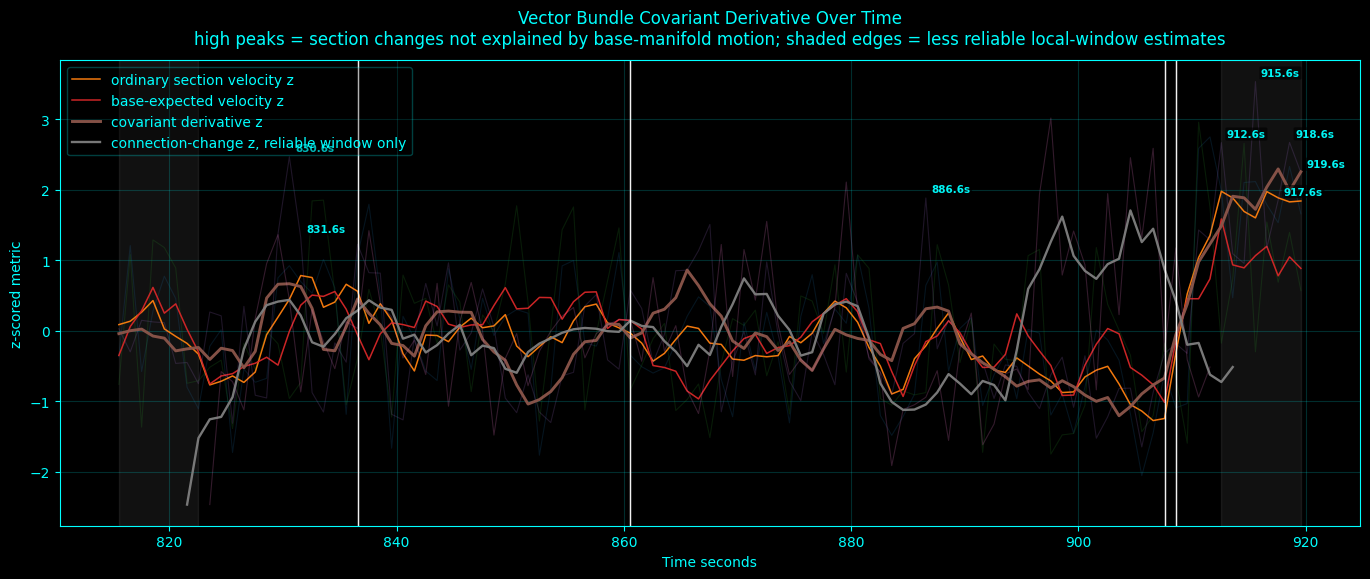

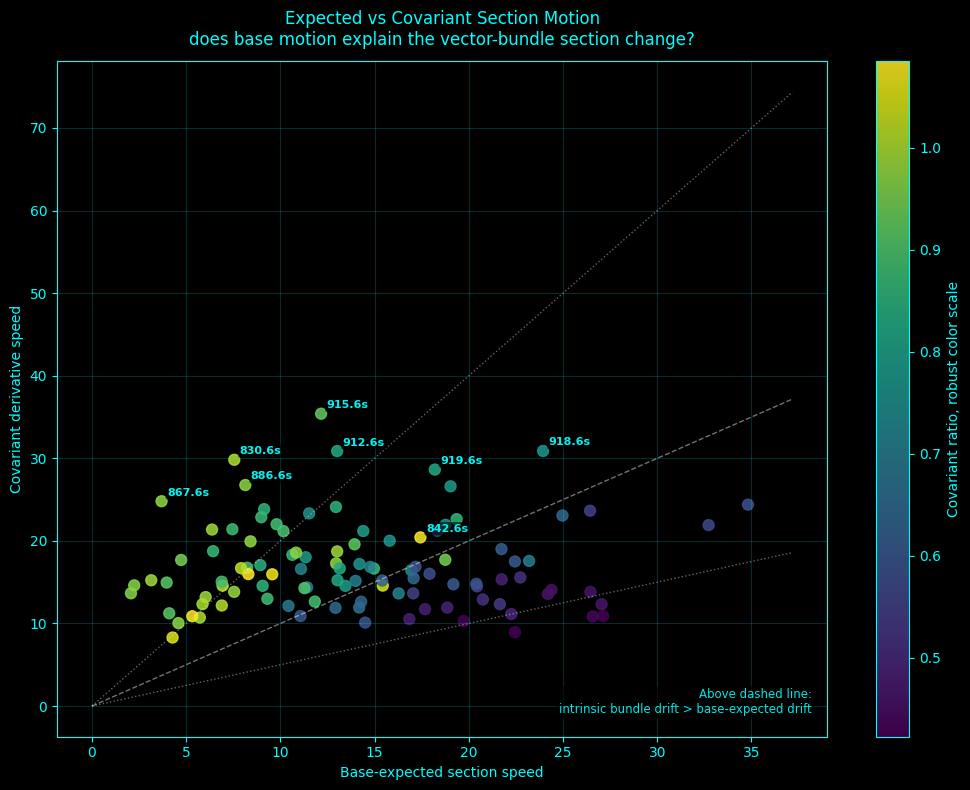

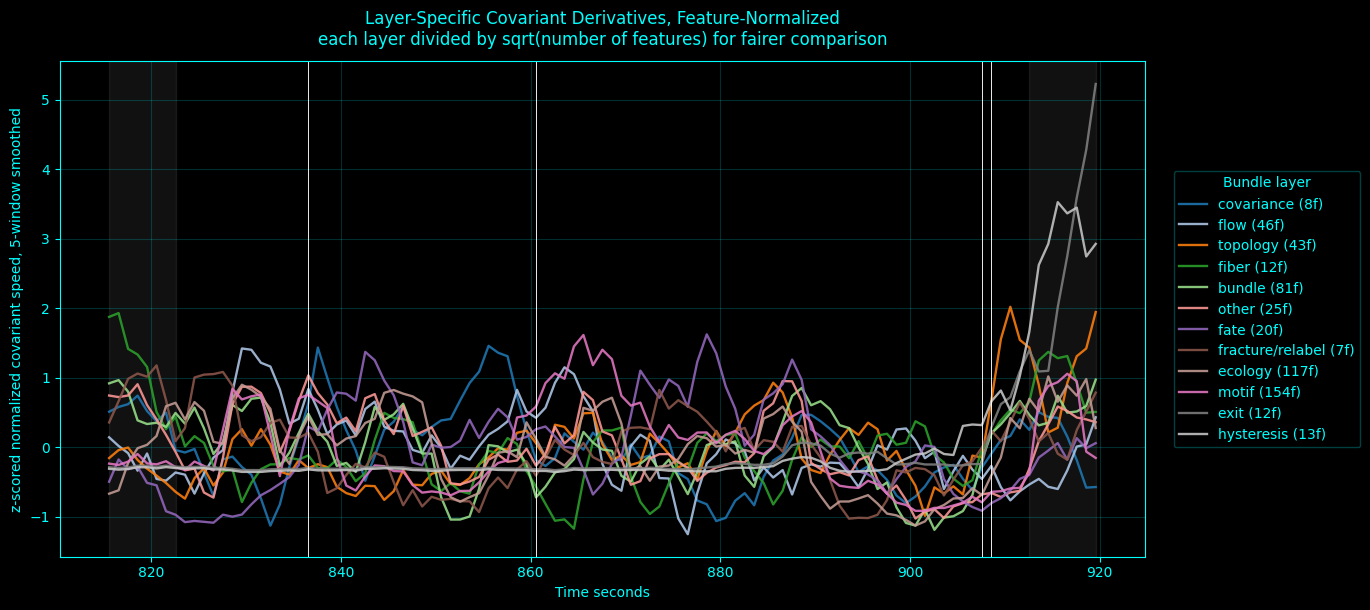

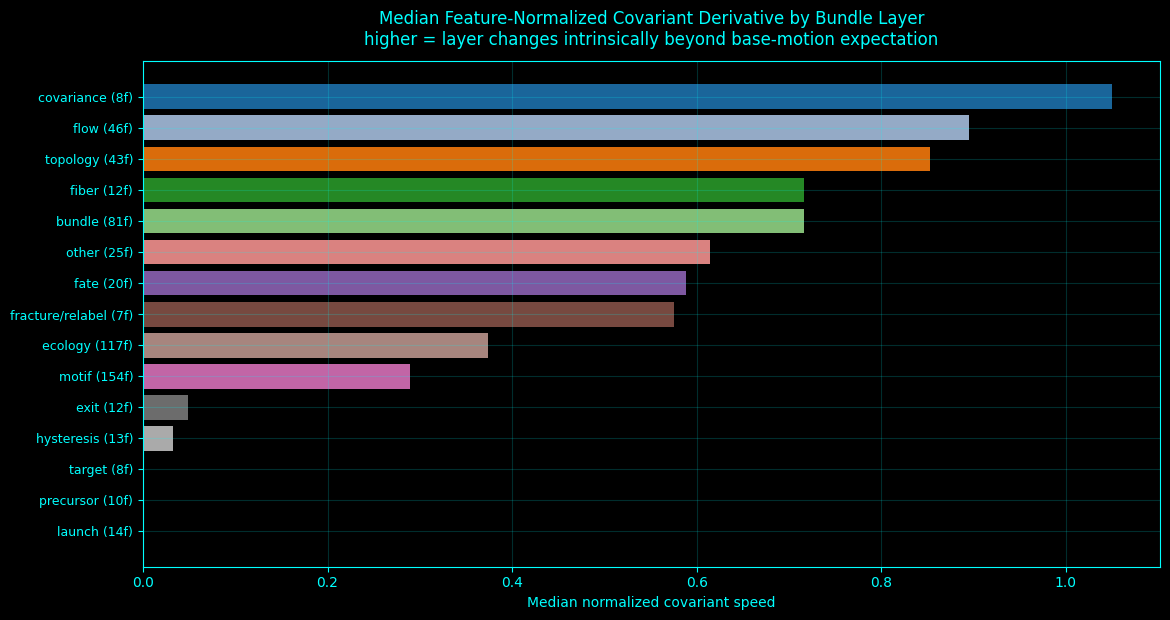

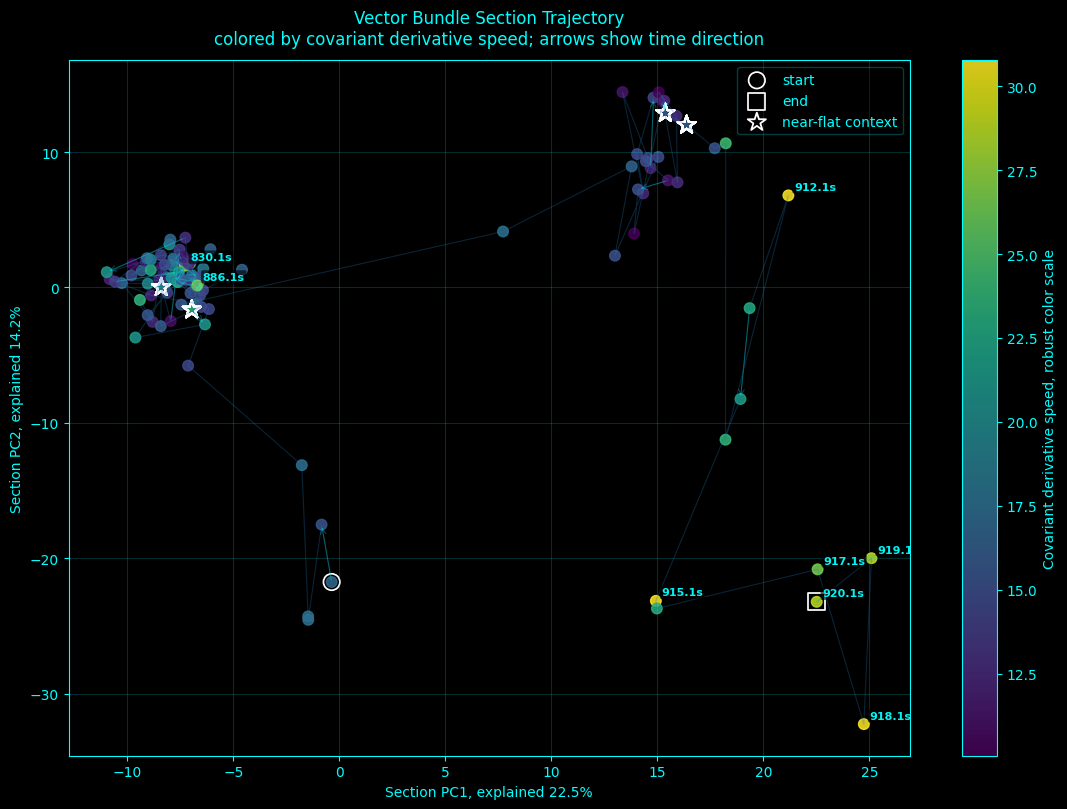

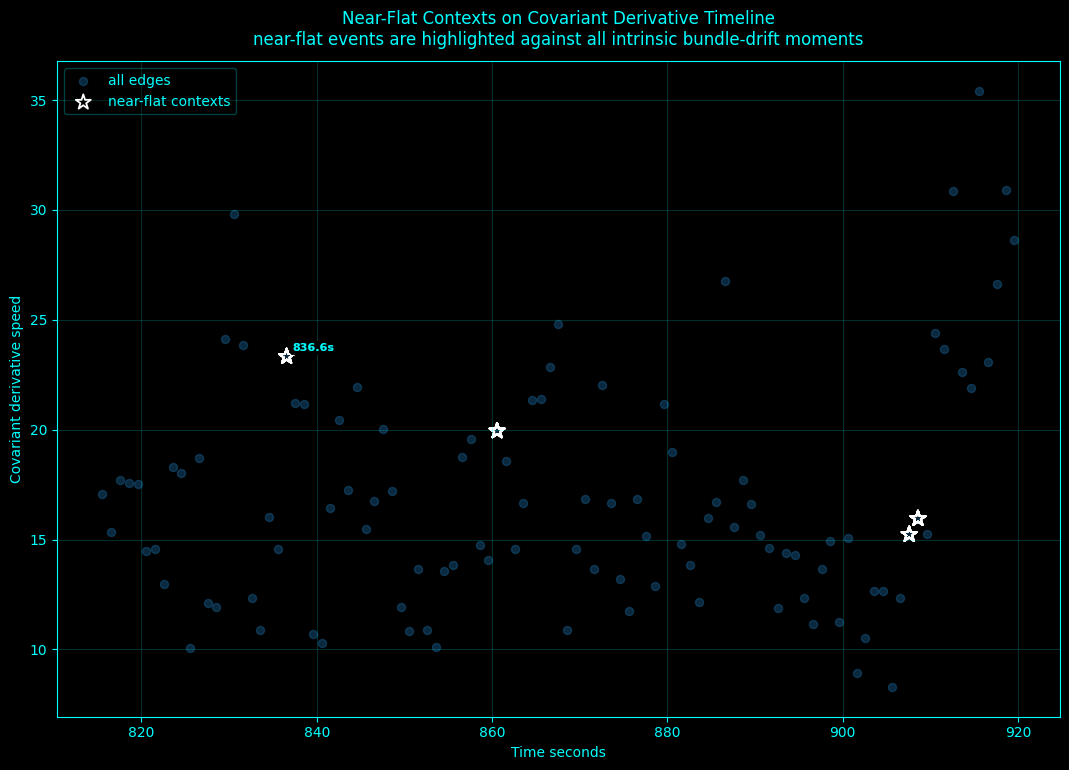

Vector bundle sections saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/vector_bundle_covariant_derivative_atlas_v2/vector_bundle_sections.csv
Section metadata saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/vector_bundle_covariant_derivative_atlas_v2/vector_bundle_section_feature_metadata.csv
Section principal coordinates saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/vector_bundle_covariant_derivative_atlas_v2/section_principal_coordinates.csv
Covariant derivative metrics saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/vector_bundle_covariant_derivative_atlas_v2/covariant_derivative_metrics.csv
Layer summary saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/vector_bundle_covariant_derivative_atlas_v2/bundle_layer_summary.csv
Top covariant events saved: /home/a/projects/Complete-Neural-Signal-Analysis/results/vector_bundle_covariant_derivative_atlas_v2/top_covariant_events.csv
Near-flat covariant context sav

In [1]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

eps = 1e-12

base_dir = globals().get("base_dir", "/home/a/projects/Complete-Neural-Signal-Analysis")

ehresmann_dir_candidates = [
    os.path.join(base_dir, "results", "ehresmann_connection_atlas_v2"),
    os.path.join(base_dir, "results", "ehresmann_connection_atlas_v1"),
]

ehresmann_dir = None
for d in ehresmann_dir_candidates:
    if os.path.exists(d):
        ehresmann_dir = d
        break

if ehresmann_dir is None:
    raise FileNotFoundError(
        "Could not find ehresmann_connection_atlas_v2 or ehresmann_connection_atlas_v1. "
        "Run the Ehresmann connection block first."
    )

out_dir = os.path.join(base_dir, "results", "vector_bundle_covariant_derivative_atlas_v2")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

BG = "black"
ACCENT = "cyan"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
    "font.size": 10,
})

def style_ax(ax, grid=True):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    if grid:
        ax.grid(True, alpha=0.18, color=ACCENT)
    else:
        ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

def sanitize_key(s):
    s = str(s)
    s = re.sub(r"[^A-Za-z0-9_]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s[:96] if len(s) else "unnamed"

def short_str(x, max_len=42):
    s = str(x)
    return s if len(s) <= max_len else s[:max_len - 3] + "..."

def zscore_safe(x):
    x = np.asarray(x, dtype=float)
    out = np.full_like(x, np.nan, dtype=float)
    good = np.isfinite(x)
    if not np.any(good):
        return np.zeros_like(x, dtype=float)
    sd = np.nanstd(x[good])
    if not np.isfinite(sd) or sd < 1e-12:
        out[good] = 0.0
        return np.nan_to_num(out, nan=0.0)
    out[good] = (x[good] - np.nanmean(x[good])) / sd
    return out

def robust_fill_numeric_frame(df):
    df = df.copy()
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        if df[c].notna().any():
            df[c] = df[c].fillna(df[c].median())
        else:
            df[c] = 0.0
    return df

def standardize_matrix(X):
    X = np.asarray(X, dtype=float)
    mu = np.nanmean(X, axis=0, keepdims=True)
    sd = np.nanstd(X, axis=0, keepdims=True)
    sd[~np.isfinite(sd)] = 1.0
    sd[sd < 1e-12] = 1.0
    Xs = (X - mu) / sd
    Xs[~np.isfinite(Xs)] = 0.0
    return Xs, mu.ravel(), sd.ravel()

def pca_svd(X, n_components=2):
    X = np.asarray(X, dtype=float)
    Xs, mu, sd = standardize_matrix(X)

    U, S, Vt = np.linalg.svd(Xs, full_matrices=False)
    k = min(n_components, Vt.shape[0])

    scores = U[:, :k] * S[:k]
    components = Vt[:k, :]
    explained = (S ** 2) / max(Xs.shape[0] - 1, 1)

    total = float(np.sum(explained))
    if total > 0:
        explained_ratio = explained[:k] / total
    else:
        explained_ratio = np.zeros(k)

    if k < n_components:
        scores = np.column_stack([scores, np.zeros((scores.shape[0], n_components - k))])
        components = np.vstack([components, np.zeros((n_components - k, Xs.shape[1]))])
        explained_ratio = np.concatenate([explained_ratio, np.zeros(n_components - k)])

    return scores, components, explained_ratio, mu, sd

def nearest_index(source_times, target_times):
    source_times = np.asarray(source_times, dtype=float)
    target_times = np.asarray(target_times, dtype=float)

    if len(source_times) == 0:
        raise ValueError("source_times is empty.")

    if len(source_times) == 1:
        return np.zeros(len(target_times), dtype=int)

    idx = np.searchsorted(source_times, target_times)
    idx = np.clip(idx, 1, len(source_times) - 1)

    left = idx - 1
    right = idx

    choose_right = np.abs(source_times[right] - target_times) < np.abs(source_times[left] - target_times)
    return np.where(choose_right, right, left)

def ridge_solve(X, Y, lam=1e-3):
    X = np.asarray(X, dtype=float)
    Y = np.asarray(Y, dtype=float)

    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays.")

    p = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ Y)

def moving_window_indices(i, n, width):
    half = width // 2
    a = max(0, i - half)
    b = min(n, i + half + 1)

    if b - a < width:
        if a == 0:
            b = min(n, width)
        elif b == n:
            a = max(0, n - width)

    return np.arange(a, b)

def safe_norm_rows(X):
    X = np.asarray(X, dtype=float)
    return np.linalg.norm(X, axis=1)

def annotate_top_points(ax, x, y, labels, scores, top_n=8, dx=4, dy=4, fontsize=8):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels).astype(str)

    good = np.isfinite(x) & np.isfinite(y) & np.isfinite(scores)
    if not np.any(good):
        return

    idx_good = np.where(good)[0]
    order = idx_good[np.argsort(scores[good])[::-1]][:top_n]

    for i in order:
        ax.annotate(
            labels[i],
            xy=(x[i], y[i]),
            xytext=(dx, dy),
            textcoords="offset points",
            fontsize=fontsize,
            weight="bold",
            color=ACCENT,
            alpha=0.96,
            bbox=dict(
                facecolor=BG,
                edgecolor="none",
                alpha=0.62,
                boxstyle="round,pad=0.15",
            ),
            clip_on=True,
        )

def robust_scatter_limits(values, q_low=0.02, q_high=0.98):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return None, None
    lo = float(np.quantile(v, q_low))
    hi = float(np.quantile(v, q_high))
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return None, None
    return lo, hi

def rolling_smooth(y, window=5):
    return pd.Series(np.asarray(y, dtype=float)).rolling(window, center=True, min_periods=1).mean().values

def make_unique_name(name, used):
    base = str(name)
    candidate = base
    counter = 2
    while candidate in used:
        candidate = f"{base}__{counter}"
        counter += 1
    used.add(candidate)
    return candidate

base_coord_path = os.path.join(ehresmann_dir, "base_semantic_coordinates.csv")
fiber_coord_path = os.path.join(ehresmann_dir, "fiber_covariance_tangent_coordinates.csv")
connection_path = os.path.join(ehresmann_dir, "connection_metrics_over_time.csv")
label_table_path = os.path.join(ehresmann_dir, "ehresmann_epoch_label_table.csv")
near_connection_path = os.path.join(ehresmann_dir, "near_flat_connection_context.csv")

for p in [base_coord_path, fiber_coord_path, connection_path, label_table_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Required Ehresmann output missing: {p}")

base_coord_df = pd.read_csv(base_coord_path)
fiber_coord_df = pd.read_csv(fiber_coord_path)
connection_df = pd.read_csv(connection_path)
label_df = pd.read_csv(label_table_path)

if os.path.exists(near_connection_path):
    near_connection_df = pd.read_csv(near_connection_path)
else:
    near_connection_df = pd.DataFrame()

time_col = "center_time_sec"

base_pc_cols = [c for c in base_coord_df.columns if re.match(r"base_pc\d+", c)]
fiber_pc_cols = [c for c in fiber_coord_df.columns if re.match(r"fiber_pc\d+", c)]

if len(base_pc_cols) < 2:
    raise ValueError("Need at least two base PCs from the Ehresmann atlas.")

if len(fiber_pc_cols) < 2:
    raise ValueError("Need at least two fiber PCs from the Ehresmann atlas.")

base_coord_df = base_coord_df.sort_values(time_col).reset_index(drop=True)
fiber_coord_df = fiber_coord_df.sort_values(time_col).reset_index(drop=True)
label_df = label_df.sort_values(time_col).reset_index(drop=True)

epoch_times = base_coord_df[time_col].values.astype(float)
n_epochs = len(base_coord_df)

B = base_coord_df[base_pc_cols].values.astype(float)
F_cov = fiber_coord_df[fiber_pc_cols].values.astype(float)

if len(fiber_coord_df) != n_epochs or not np.allclose(fiber_coord_df[time_col].values.astype(float), epoch_times, atol=1e-6):
    idx = nearest_index(fiber_coord_df[time_col].values, epoch_times)
    F_cov = fiber_coord_df[fiber_pc_cols].values.astype(float)[idx]

if len(label_df) != n_epochs or not np.allclose(label_df[time_col].values.astype(float), epoch_times, atol=1e-6):
    idx = nearest_index(label_df[time_col].values, epoch_times)
    label_df = label_df.iloc[idx].reset_index(drop=True)

dt = float(np.nanmedian(np.diff(epoch_times))) if len(epoch_times) > 1 else 1.0
if not np.isfinite(dt) or dt <= 0:
    dt = 1.0

preferred_categorical_columns = [
    "dominant_motif",
    "soft_motif",
    "motif_label",
    "ecology_cluster",
    "ecology_name",
    "flow_role",
    "fate_role",
    "topology_name",
    "global_bundle",
    "bundle_role",
    "fiber_role",
    "relabel_stage",
    "fracture_role",
    "hysteresis_role",
    "exit_family",
    "target_family",
    "precursor_cluster",
    "syntax_motif",
    "launch_syntax",
]

def canonical_colname(c):
    s = str(c)
    for p in preferred_categorical_columns:
        if s == p or s.startswith(p + "__"):
            return p
    if "__" in s:
        left = s.split("__")[0]
        for p in preferred_categorical_columns:
            if left == p:
                return p
        return left
    return s

def super_layer_from_column(c):
    canonical = canonical_colname(c).lower()

    if canonical in ["dominant_motif", "soft_motif", "motif_label"]:
        return "motif"
    if canonical in ["ecology_cluster", "ecology_name"]:
        return "ecology"
    if canonical == "flow_role":
        return "flow"
    if canonical == "fate_role":
        return "fate"
    if canonical == "topology_name":
        return "topology"
    if canonical in ["global_bundle", "bundle_role"]:
        return "bundle"
    if canonical == "fiber_role":
        return "fiber"
    if canonical in ["relabel_stage", "fracture_role"]:
        return "fracture/relabel"
    if canonical == "hysteresis_role":
        return "hysteresis"
    if canonical == "exit_family":
        return "exit"
    if canonical in ["syntax_motif", "launch_syntax"]:
        return "launch"
    if canonical == "target_family":
        return "target"
    if canonical == "precursor_cluster":
        return "precursor"

    s = str(c).lower()
    if "motif" in s:
        return "motif"
    if "ecology" in s:
        return "ecology"
    if "flow" in s:
        return "flow"
    if "fate" in s:
        return "fate"
    if "topology" in s or "lobe" in s:
        return "topology"
    if "bundle" in s:
        return "bundle"
    if "fiber" in s:
        return "fiber"
    if "relabel" in s or "fracture" in s:
        return "fracture/relabel"
    if "hysteresis" in s:
        return "hysteresis"
    if "exit" in s:
        return "exit"
    if "launch" in s or "syntax" in s:
        return "launch"
    if "target" in s:
        return "target"
    if "precursor" in s:
        return "precursor"

    return "other"

candidate_categorical_cols = []

for c in label_df.columns:
    if c in ["epoch_index", "center_time_sec", "time_sec", "event_time_sec", "fissure_time_sec", "near_flat_time_sec"]:
        continue

    nunique = label_df[c].dropna().nunique()
    canonical = canonical_colname(c)

    if canonical in preferred_categorical_columns and 2 <= nunique <= 40:
        candidate_categorical_cols.append(c)

candidate_categorical_cols = sorted(set(candidate_categorical_cols))

numeric_bundle_hints = [
    "drift",
    "entropy",
    "purity",
    "consensus",
    "pressure",
    "score",
    "velocity",
    "speed",
    "branchiness",
    "dispersion",
    "radius",
    "distance",
    "curvature",
    "hysteresis",
    "loop",
    "relabel",
    "fracture",
    "future",
    "flow",
    "bundle",
    "fiber",
    "exit",
    "syntax",
    "launch",
]

candidate_numeric_cols = []

for c in label_df.columns:
    if c in ["epoch_index", "center_time_sec", "time_sec", "event_time_sec", "fissure_time_sec", "near_flat_time_sec"]:
        continue

    if pd.api.types.is_numeric_dtype(label_df[c]):
        nunique = label_df[c].dropna().nunique()
        hint = any(h in c.lower() for h in numeric_bundle_hints)
        if hint and nunique >= 3:
            candidate_numeric_cols.append(c)

candidate_numeric_cols = sorted(set(candidate_numeric_cols))

feature_arrays = []
feature_names = []
section_feature_meta = []
used_feature_names = set()

def add_section_feature(name, values, section_type, source_column, canonical_column, super_layer):
    values = np.asarray(values, dtype=float).reshape(-1)

    if len(values) != n_epochs:
        raise ValueError(f"Feature {name} length {len(values)} does not match n_epochs={n_epochs}")

    clean_name = make_unique_name(name, used_feature_names)

    feature_names.append(clean_name)
    feature_arrays.append(values)

    section_feature_meta.append({
        "section_feature": clean_name,
        "section_type": section_type,
        "source_column": source_column,
        "canonical_column": canonical_column,
        "super_layer": super_layer,
    })

for k, c in enumerate(fiber_pc_cols):
    add_section_feature(
        name=f"covariance_fiber::{c}",
        values=F_cov[:, k],
        section_type="covariance_tangent",
        source_column=c,
        canonical_column="covariance_fiber",
        super_layer="covariance",
    )

for c in candidate_categorical_cols:
    values = label_df[c].astype(str).fillna("missing")
    unique_vals = sorted(values.dropna().unique().tolist(), key=lambda x: str(x))

    if len(unique_vals) < 2:
        continue

    for val in unique_vals:
        dummy = (values == val).astype(float).values
        add_section_feature(
            name=f"cat::{sanitize_key(c)}::{sanitize_key(val)}",
            values=dummy,
            section_type="categorical_onehot",
            source_column=c,
            canonical_column=canonical_colname(c),
            super_layer=super_layer_from_column(c),
        )

if candidate_numeric_cols:
    numeric_df = robust_fill_numeric_frame(label_df[candidate_numeric_cols])
    numeric_X, _, _ = standardize_matrix(numeric_df.values.astype(float))

    for j, c in enumerate(candidate_numeric_cols):
        add_section_feature(
            name=f"num::{sanitize_key(c)}",
            values=numeric_X[:, j],
            section_type="numeric_scalar",
            source_column=c,
            canonical_column=canonical_colname(c),
            super_layer=super_layer_from_column(c),
        )

if not feature_arrays:
    raise ValueError("No vector-bundle section features found.")

S_raw = np.column_stack(feature_arrays)
S, section_mu, section_sd = standardize_matrix(S_raw)

section_df = pd.DataFrame(S, columns=feature_names)
section_df.insert(0, "center_time_sec", epoch_times)
section_df.insert(0, "epoch_index", np.arange(n_epochs))

section_meta_df = pd.DataFrame(section_feature_meta)

section_csv = os.path.join(out_dir, "vector_bundle_sections.csv")
section_df.to_csv(section_csv, index=False)

section_meta_csv = os.path.join(out_dir, "vector_bundle_section_feature_metadata.csv")
section_meta_df.to_csv(section_meta_csv, index=False)

bundle_scores, bundle_components, bundle_explained, bundle_mu, bundle_sd = pca_svd(
    S,
    n_components=min(12, S.shape[1], n_epochs),
)

bundle_coord_df = pd.DataFrame({
    "epoch_index": np.arange(n_epochs),
    "center_time_sec": epoch_times,
})

for k in range(bundle_scores.shape[1]):
    bundle_coord_df[f"section_pc{k+1}"] = bundle_scores[:, k]

bundle_coord_csv = os.path.join(out_dir, "section_principal_coordinates.csv")
bundle_coord_df.to_csv(bundle_coord_csv, index=False)

dB = np.diff(B, axis=0) / dt
dS = np.diff(S, axis=0) / dt
dQ = np.diff(bundle_scores, axis=0) / dt

n_edges = len(dB)
edge_times = 0.5 * (epoch_times[:-1] + epoch_times[1:])

ridge_lambda = 1e-3
local_window = 17
min_local_rows = 8
edge_margin = local_window // 2

if n_edges > 2 * edge_margin:
    edge_reliable = np.zeros(n_edges, dtype=bool)
    edge_reliable[edge_margin:n_edges - edge_margin] = True
else:
    edge_reliable = np.ones(n_edges, dtype=bool)

A_global_section = ridge_solve(dB, dS, lam=ridge_lambda)
dS_expected_global = dB @ A_global_section
dS_covariant_global = dS - dS_expected_global

A_local_section = np.zeros((n_edges, dB.shape[1], dS.shape[1]), dtype=float)
dS_expected = np.zeros_like(dS)
dS_covariant = np.zeros_like(dS)

for i in range(n_edges):
    idx = moving_window_indices(i, n_edges, local_window)

    if len(idx) >= min_local_rows:
        try:
            A_i = ridge_solve(dB[idx], dS[idx], lam=ridge_lambda)
        except Exception:
            A_i = A_global_section.copy()
    else:
        A_i = A_global_section.copy()

    A_local_section[i] = A_i
    dS_expected[i] = dB[i] @ A_i
    dS_covariant[i] = dS[i] - dS_expected[i]

A_global_pc = ridge_solve(dB, dQ, lam=ridge_lambda)
dQ_expected_global = dB @ A_global_pc
dQ_covariant_global = dQ - dQ_expected_global

A_local_pc = np.zeros((n_edges, dB.shape[1], dQ.shape[1]), dtype=float)
dQ_expected = np.zeros_like(dQ)
dQ_covariant = np.zeros_like(dQ)

for i in range(n_edges):
    idx = moving_window_indices(i, n_edges, local_window)

    if len(idx) >= min_local_rows:
        try:
            A_i = ridge_solve(dB[idx], dQ[idx], lam=ridge_lambda)
        except Exception:
            A_i = A_global_pc.copy()
    else:
        A_i = A_global_pc.copy()

    A_local_pc[i] = A_i
    dQ_expected[i] = dB[i] @ A_i
    dQ_covariant[i] = dQ[i] - dQ_expected[i]

ordinary_section_speed = safe_norm_rows(dS)
expected_section_speed = safe_norm_rows(dS_expected)
covariant_section_speed = safe_norm_rows(dS_covariant)
covariant_ratio = covariant_section_speed / (ordinary_section_speed + eps)
connection_explained_fraction = expected_section_speed / (ordinary_section_speed + expected_section_speed + eps)

ordinary_pc_speed = safe_norm_rows(dQ)
expected_pc_speed = safe_norm_rows(dQ_expected)
covariant_pc_speed = safe_norm_rows(dQ_covariant)
covariant_pc_ratio = covariant_pc_speed / (ordinary_pc_speed + eps)

base_speed = safe_norm_rows(dB)

connection_norm_section = safe_norm_rows(A_local_section.reshape(n_edges, -1))
connection_norm_pc = safe_norm_rows(A_local_pc.reshape(n_edges, -1))

connection_change_section = np.zeros(n_edges)
connection_change_pc = np.zeros(n_edges)

for i in range(1, n_edges):
    connection_change_section[i] = np.linalg.norm(A_local_section[i] - A_local_section[i - 1], ord="fro")
    connection_change_pc[i] = np.linalg.norm(A_local_pc[i] - A_local_pc[i - 1], ord="fro")

connection_change_section_log = np.log1p(connection_change_section)
connection_change_pc_log = np.log1p(connection_change_pc)

connection_change_section_log_reliable = connection_change_section_log.copy()
connection_change_pc_log_reliable = connection_change_pc_log.copy()
connection_change_section_log_reliable[~edge_reliable] = np.nan
connection_change_pc_log_reliable[~edge_reliable] = np.nan

covariant_acceleration = np.zeros(n_edges)
ordinary_acceleration = np.zeros(n_edges)

if n_edges > 1:
    covariant_acceleration[1:] = safe_norm_rows(np.diff(dS_covariant, axis=0)) / dt
    ordinary_acceleration[1:] = safe_norm_rows(np.diff(dS, axis=0)) / dt

layer_names = section_meta_df["super_layer"].astype(str).values
unique_layers = sorted(set(layer_names))

layer_covariant = {}
layer_ordinary = {}
layer_expected = {}
layer_ratio = {}
layer_covariant_normed = {}
layer_ordinary_normed = {}
layer_expected_normed = {}
layer_ratio_normed = {}
layer_feature_count = {}

for layer in unique_layers:
    idx = np.where(layer_names == layer)[0]
    if len(idx) == 0:
        continue

    denom = math.sqrt(max(len(idx), 1))
    layer_feature_count[layer] = int(len(idx))

    layer_covariant[layer] = safe_norm_rows(dS_covariant[:, idx])
    layer_ordinary[layer] = safe_norm_rows(dS[:, idx])
    layer_expected[layer] = safe_norm_rows(dS_expected[:, idx])
    layer_ratio[layer] = layer_covariant[layer] / (layer_ordinary[layer] + eps)

    layer_covariant_normed[layer] = layer_covariant[layer] / denom
    layer_ordinary_normed[layer] = layer_ordinary[layer] / denom
    layer_expected_normed[layer] = layer_expected[layer] / denom
    layer_ratio_normed[layer] = layer_covariant_normed[layer] / (layer_ordinary_normed[layer] + eps)

metrics_dict = {
    "edge_index": np.arange(n_edges),
    "start_epoch_index": np.arange(n_edges),
    "end_epoch_index": np.arange(1, n_epochs),
    "center_time_sec": edge_times,
    "start_time_sec": epoch_times[:-1],
    "end_time_sec": epoch_times[1:],
    "edge_reliable": edge_reliable,
    "base_speed": base_speed,
    "ordinary_section_speed": ordinary_section_speed,
    "expected_section_speed": expected_section_speed,
    "covariant_section_speed": covariant_section_speed,
    "covariant_ratio": covariant_ratio,
    "connection_explained_fraction": connection_explained_fraction,
    "ordinary_pc_speed": ordinary_pc_speed,
    "expected_pc_speed": expected_pc_speed,
    "covariant_pc_speed": covariant_pc_speed,
    "covariant_pc_ratio": covariant_pc_ratio,
    "ordinary_acceleration": ordinary_acceleration,
    "covariant_acceleration": covariant_acceleration,
    "connection_norm_section": connection_norm_section,
    "connection_change_section": connection_change_section,
    "connection_change_section_log": connection_change_section_log,
    "connection_change_section_log_reliable": connection_change_section_log_reliable,
    "connection_norm_pc": connection_norm_pc,
    "connection_change_pc": connection_change_pc,
    "connection_change_pc_log": connection_change_pc_log,
    "connection_change_pc_log_reliable": connection_change_pc_log_reliable,
}

for layer in unique_layers:
    safe_layer = sanitize_key(layer)
    metrics_dict[f"{safe_layer}_feature_count"] = np.full(n_edges, layer_feature_count[layer], dtype=int)
    metrics_dict[f"{safe_layer}_ordinary_speed_raw"] = layer_ordinary[layer]
    metrics_dict[f"{safe_layer}_expected_speed_raw"] = layer_expected[layer]
    metrics_dict[f"{safe_layer}_covariant_speed_raw"] = layer_covariant[layer]
    metrics_dict[f"{safe_layer}_covariant_ratio_raw"] = layer_ratio[layer]
    metrics_dict[f"{safe_layer}_ordinary_speed_normed"] = layer_ordinary_normed[layer]
    metrics_dict[f"{safe_layer}_expected_speed_normed"] = layer_expected_normed[layer]
    metrics_dict[f"{safe_layer}_covariant_speed_normed"] = layer_covariant_normed[layer]
    metrics_dict[f"{safe_layer}_covariant_ratio_normed"] = layer_ratio_normed[layer]

for k in range(min(bundle_scores.shape[1], 8)):
    metrics_dict[f"section_pc{k+1}_velocity"] = dQ[:, k]
    metrics_dict[f"section_pc{k+1}_expected_velocity"] = dQ_expected[:, k]
    metrics_dict[f"section_pc{k+1}_covariant_derivative"] = dQ_covariant[:, k]

metrics_df = pd.DataFrame(metrics_dict)

near_times = []

if len(near_connection_df):
    near_time_col = None
    for c in ["nearest_connection_time_sec", "event_time_sec", "center_time_sec"]:
        if c in near_connection_df.columns:
            near_time_col = c
            break

    if near_time_col is not None:
        near_times = near_connection_df[near_time_col].dropna().values.astype(float)

near_flag = np.zeros(n_edges, dtype=bool)

if len(near_times):
    near_idx = nearest_index(edge_times, near_times)
    near_flag[near_idx] = True

metrics_df["near_flat_associated"] = near_flag

metrics_csv = os.path.join(out_dir, "covariant_derivative_metrics.csv")
metrics_df.to_csv(metrics_csv, index=False)

np.savez_compressed(
    os.path.join(out_dir, "section_connection_matrices.npz"),
    A_global_section=A_global_section,
    A_local_section=A_local_section,
    A_global_pc=A_global_pc,
    A_local_pc=A_local_pc,
    bundle_components=bundle_components,
    bundle_explained=bundle_explained,
    bundle_mu=bundle_mu,
    bundle_sd=bundle_sd,
    section_mu=section_mu,
    section_sd=section_sd,
    feature_names=np.array(feature_names, dtype=object),
    base_pc_cols=np.array(base_pc_cols, dtype=object),
    edge_reliable=edge_reliable,
)

layer_summary_rows = []

for layer in unique_layers:
    safe_layer = sanitize_key(layer)

    raw_cov_col = f"{safe_layer}_covariant_speed_raw"
    raw_ratio_col = f"{safe_layer}_covariant_ratio_raw"
    norm_cov_col = f"{safe_layer}_covariant_speed_normed"
    norm_ratio_col = f"{safe_layer}_covariant_ratio_normed"

    reliable_df = metrics_df[metrics_df["edge_reliable"]].copy()
    if len(reliable_df) == 0:
        reliable_df = metrics_df.copy()

    row = {
        "super_layer": layer,
        "n_features": layer_feature_count[layer],
        "median_covariant_speed_raw": float(np.nanmedian(reliable_df[raw_cov_col])),
        "median_covariant_ratio_raw": float(np.nanmedian(reliable_df[raw_ratio_col])),
        "max_covariant_speed_raw": float(np.nanmax(reliable_df[raw_cov_col])),
        "median_covariant_speed_normed": float(np.nanmedian(reliable_df[norm_cov_col])),
        "median_covariant_ratio_normed": float(np.nanmedian(reliable_df[norm_ratio_col])),
        "max_covariant_speed_normed": float(np.nanmax(reliable_df[norm_cov_col])),
    }

    if metrics_df["near_flat_associated"].any():
        nf = metrics_df[metrics_df["near_flat_associated"]]
        row["near_flat_median_covariant_speed_normed"] = float(np.nanmedian(nf[norm_cov_col]))
        row["near_flat_median_covariant_ratio_normed"] = float(np.nanmedian(nf[norm_ratio_col]))
    else:
        row["near_flat_median_covariant_speed_normed"] = np.nan
        row["near_flat_median_covariant_ratio_normed"] = np.nan

    layer_summary_rows.append(row)

layer_summary_df = pd.DataFrame(layer_summary_rows).sort_values("median_covariant_speed_normed", ascending=False)
layer_summary_csv = os.path.join(out_dir, "bundle_layer_summary.csv")
layer_summary_df.to_csv(layer_summary_csv, index=False)

event_rows = []

event_specs = [
    ("global_covariant_speed", "covariant_section_speed"),
    ("global_covariant_ratio", "covariant_ratio"),
    ("section_pc_covariant_speed", "covariant_pc_speed"),
    ("covariant_acceleration", "covariant_acceleration"),
    ("connection_change_reliable", "connection_change_section_log_reliable"),
]

for event_type, col in event_specs:
    event_base_df = metrics_df.copy()
    if col == "connection_change_section_log_reliable":
        event_base_df = event_base_df[event_base_df["edge_reliable"]].copy()

    top = event_base_df.sort_values(col, ascending=False).head(15)

    for rank, (_, r) in enumerate(top.iterrows(), start=1):
        event_rows.append({
            "event_type": event_type,
            "rank": rank,
            "edge_index": int(r["edge_index"]),
            "center_time_sec": float(r["center_time_sec"]),
            "metric_column": col,
            "metric_value": float(r[col]),
            "edge_reliable": bool(r["edge_reliable"]),
            "base_speed": float(r["base_speed"]),
            "ordinary_section_speed": float(r["ordinary_section_speed"]),
            "expected_section_speed": float(r["expected_section_speed"]),
            "covariant_section_speed": float(r["covariant_section_speed"]),
            "covariant_ratio": float(r["covariant_ratio"]),
            "covariant_acceleration": float(r["covariant_acceleration"]),
            "near_flat_associated": bool(r["near_flat_associated"]),
        })

for layer in unique_layers:
    safe_layer = sanitize_key(layer)
    col = f"{safe_layer}_covariant_speed_normed"
    if col not in metrics_df.columns:
        continue

    top = metrics_df[metrics_df["edge_reliable"]].sort_values(col, ascending=False).head(8)

    for rank, (_, r) in enumerate(top.iterrows(), start=1):
        event_rows.append({
            "event_type": f"layer_{safe_layer}_covariant_speed_normed",
            "rank": rank,
            "edge_index": int(r["edge_index"]),
            "center_time_sec": float(r["center_time_sec"]),
            "metric_column": col,
            "metric_value": float(r[col]),
            "edge_reliable": bool(r["edge_reliable"]),
            "base_speed": float(r["base_speed"]),
            "ordinary_section_speed": float(r["ordinary_section_speed"]),
            "expected_section_speed": float(r["expected_section_speed"]),
            "covariant_section_speed": float(r["covariant_section_speed"]),
            "covariant_ratio": float(r["covariant_ratio"]),
            "covariant_acceleration": float(r["covariant_acceleration"]),
            "near_flat_associated": bool(r["near_flat_associated"]),
        })

top_events_df = pd.DataFrame(event_rows)
top_events_csv = os.path.join(out_dir, "top_covariant_events.csv")
top_events_df.to_csv(top_events_csv, index=False)

near_cov_rows = []

if len(near_times):
    idxs = nearest_index(metrics_df["center_time_sec"].values, near_times)

    for j, edge_i in enumerate(idxs):
        r = metrics_df.iloc[int(edge_i)]

        row = {
            "near_flat_index": int(j),
            "event_time_sec": float(near_times[j]),
            "nearest_edge_index": int(r["edge_index"]),
            "nearest_covariant_time_sec": float(r["center_time_sec"]),
            "edge_reliable": bool(r["edge_reliable"]),
            "ordinary_section_speed": float(r["ordinary_section_speed"]),
            "expected_section_speed": float(r["expected_section_speed"]),
            "covariant_section_speed": float(r["covariant_section_speed"]),
            "covariant_ratio": float(r["covariant_ratio"]),
            "covariant_pc_speed": float(r["covariant_pc_speed"]),
            "covariant_pc_ratio": float(r["covariant_pc_ratio"]),
            "covariant_acceleration": float(r["covariant_acceleration"]),
            "connection_change_section_log_reliable": float(r["connection_change_section_log_reliable"]) if np.isfinite(r["connection_change_section_log_reliable"]) else np.nan,
        }

        for layer in unique_layers:
            safe_layer = sanitize_key(layer)
            col = f"{safe_layer}_covariant_speed_normed"
            if col in metrics_df.columns:
                row[f"{safe_layer}_covariant_speed_normed"] = float(r[col])

        near_cov_rows.append(row)

near_cov_df = pd.DataFrame(near_cov_rows)
near_cov_csv = os.path.join(out_dir, "near_flat_covariant_context.csv")
near_cov_df.to_csv(near_cov_csv, index=False)

layer_order = layer_summary_df["super_layer"].tolist()

try:
    cmap = plt.colormaps["tab20"].resampled(max(len(layer_order), 1))
except Exception:
    cmap = plt.get_cmap("tab20", max(len(layer_order), 1))

layer_color = {layer: cmap(i) for i, layer in enumerate(layer_order)}

fig, ax = plt.subplots(figsize=(13.8, 5.9))

edge_t = metrics_df["center_time_sec"].values

ordinary_z = zscore_safe(metrics_df["ordinary_section_speed"].values)
expected_z = zscore_safe(metrics_df["expected_section_speed"].values)
covariant_z = zscore_safe(metrics_df["covariant_section_speed"].values)

conn_change = metrics_df["connection_change_section_log_reliable"].values
conn_change_z = zscore_safe(conn_change)

plot_specs = [
    (ordinary_z, "ordinary section velocity z", 1.1, 0.38),
    (expected_z, "base-expected velocity z", 1.1, 0.38),
    (covariant_z, "covariant derivative z", 2.1, 0.46),
    (conn_change_z, "connection-change z, reliable window only", 1.7, 0.50),
]

for y, label, lw, raw_alpha in plot_specs:
    ax.plot(edge_t, y, alpha=raw_alpha * 0.45, linewidth=0.8)
    ax.plot(edge_t, rolling_smooth(y, 5), label=label, linewidth=lw, alpha=0.95)

if not np.all(edge_reliable):
    unreliable_left = metrics_df[~metrics_df["edge_reliable"] & (metrics_df["edge_index"] < edge_margin)]
    unreliable_right = metrics_df[~metrics_df["edge_reliable"] & (metrics_df["edge_index"] >= n_edges - edge_margin)]

    if len(unreliable_left):
        ax.axvspan(unreliable_left["center_time_sec"].min(), unreliable_left["center_time_sec"].max(), color="white", alpha=0.07)
    if len(unreliable_right):
        ax.axvspan(unreliable_right["center_time_sec"].min(), unreliable_right["center_time_sec"].max(), color="white", alpha=0.07)

for t in near_times:
    ax.axvline(t, color="white", alpha=0.20, linewidth=0.85)

labels = np.array([f"{t:.1f}s" for t in edge_t])
score = zscore_safe(metrics_df["covariant_section_speed"].values) + 0.45 * zscore_safe(metrics_df["covariant_acceleration"].values)
annotate_top_points(
    ax,
    edge_t,
    covariant_z,
    labels,
    score,
    top_n=8,
    fontsize=7.5,
)

style_ax(ax)
ax.set_title(
    "Vector Bundle Covariant Derivative Over Time\n"
    "high peaks = section changes not explained by base-manifold motion; shaded edges = less reliable local-window estimates",
    pad=12,
)
ax.set_xlabel("Time seconds")
ax.set_ylabel("z-scored metric")
ax.legend(framealpha=0.25, loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "v2_covariant_derivative_over_time.png"), dpi=260, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10.4, 8.0))

color_values = metrics_df["covariant_ratio"].values
vmin, vmax = robust_scatter_limits(color_values, 0.02, 0.98)

sc = ax.scatter(
    metrics_df["expected_section_speed"],
    metrics_df["covariant_section_speed"],
    c=color_values,
    s=62,
    alpha=0.86,
    vmin=vmin,
    vmax=vmax,
)

max_axis = float(np.nanmax([
    metrics_df["expected_section_speed"].max(),
    metrics_df["covariant_section_speed"].max(),
]))

if np.isfinite(max_axis) and max_axis > 0:
    xs = np.linspace(0, max_axis * 1.05, 200)
    ax.plot(xs, xs, linestyle="--", color="white", alpha=0.45, linewidth=1.0)
    ax.plot(xs, 2.0 * xs, linestyle=":", color="white", alpha=0.40, linewidth=1.0)
    ax.plot(xs, 0.5 * xs, linestyle=":", color="white", alpha=0.40, linewidth=1.0)

ax.text(
    0.98,
    0.03,
    "Above dashed line:\nintrinsic bundle drift > base-expected drift",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=8.5,
    alpha=0.90,
    bbox=dict(facecolor=BG, edgecolor="none", alpha=0.62, boxstyle="round,pad=0.20"),
)

labels = np.array([f"{t:.1f}s" for t in metrics_df["center_time_sec"].values])
score = zscore_safe(metrics_df["covariant_section_speed"].values) + zscore_safe(metrics_df["covariant_ratio"].values)
annotate_top_points(
    ax,
    metrics_df["expected_section_speed"].values,
    metrics_df["covariant_section_speed"].values,
    labels,
    score,
    top_n=8,
    fontsize=8,
)

style_ax(ax)
ax.set_title(
    "Expected vs Covariant Section Motion\n"
    "does base motion explain the vector-bundle section change?",
    pad=12,
)
ax.set_xlabel("Base-expected section speed")
ax.set_ylabel("Covariant derivative speed")

cbar = plt.colorbar(sc, ax=ax)
cbar.ax.tick_params(colors=ACCENT)
cbar.set_label("Covariant ratio, robust color scale", color=ACCENT)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "v2_expected_vs_covariant_section_motion.png"), dpi=260, bbox_inches="tight")
plt.show()

plot_layers = layer_summary_df.head(min(12, len(layer_summary_df)))["super_layer"].tolist()

fig, ax = plt.subplots(figsize=(13.8, 6.2))

for layer in plot_layers:
    safe_layer = sanitize_key(layer)
    col = f"{safe_layer}_covariant_speed_normed"
    if col not in metrics_df.columns:
        continue

    y = zscore_safe(metrics_df[col].values)
    y_smooth = rolling_smooth(y, 5)

    ax.plot(
        metrics_df["center_time_sec"],
        y_smooth,
        label=f"{layer} ({layer_feature_count[layer]}f)",
        linewidth=1.7,
        alpha=0.88,
        color=layer_color.get(layer, None),
    )

if not np.all(edge_reliable):
    unreliable_left = metrics_df[~metrics_df["edge_reliable"] & (metrics_df["edge_index"] < edge_margin)]
    unreliable_right = metrics_df[~metrics_df["edge_reliable"] & (metrics_df["edge_index"] >= n_edges - edge_margin)]

    if len(unreliable_left):
        ax.axvspan(unreliable_left["center_time_sec"].min(), unreliable_left["center_time_sec"].max(), color="white", alpha=0.07)
    if len(unreliable_right):
        ax.axvspan(unreliable_right["center_time_sec"].min(), unreliable_right["center_time_sec"].max(), color="white", alpha=0.07)

for t in near_times:
    ax.axvline(t, color="white", alpha=0.16, linewidth=0.75)

style_ax(ax)
ax.set_title(
    "Layer-Specific Covariant Derivatives, Feature-Normalized\n"
    "each layer divided by sqrt(number of features) for fairer comparison",
    pad=12,
)
ax.set_xlabel("Time seconds")
ax.set_ylabel("z-scored normalized covariant speed, 5-window smoothed")
ax.legend(framealpha=0.25, loc="center left", bbox_to_anchor=(1.02, 0.5), title="Bundle layer")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "v2_layer_specific_covariant_derivatives_feature_normalized.png"), dpi=260, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11.8, max(5.8, 0.42 * len(layer_summary_df))))

plot_df = layer_summary_df.sort_values("median_covariant_speed_normed", ascending=True).copy()
bar_colors = [layer_color.get(layer, (0.6, 0.6, 0.6, 1.0)) for layer in plot_df["super_layer"]]
labels = [
    f"{row.super_layer} ({int(row.n_features)}f)"
    for _, row in plot_df.iterrows()
]

ax.barh(
    np.arange(len(plot_df)),
    plot_df["median_covariant_speed_normed"].values,
    alpha=0.86,
    color=bar_colors,
)

ax.set_yticks(np.arange(len(plot_df)))
ax.set_yticklabels(labels, fontsize=9)

style_ax(ax)
ax.set_title(
    "Median Feature-Normalized Covariant Derivative by Bundle Layer\n"
    "higher = layer changes intrinsically beyond base-motion expectation",
    pad=12,
)
ax.set_xlabel("Median normalized covariant speed")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "v2_bundle_layer_median_covariant_speed_normalized.png"), dpi=260, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11.4, 8.2))

if bundle_scores.shape[1] >= 2:
    color_values = np.r_[metrics_df["covariant_section_speed"].values, metrics_df["covariant_section_speed"].values[-1]]
    vmin, vmax = robust_scatter_limits(color_values, 0.02, 0.98)

    sc = ax.scatter(
        bundle_scores[:, 0],
        bundle_scores[:, 1],
        c=color_values,
        s=58,
        alpha=0.86,
        vmin=vmin,
        vmax=vmax,
    )

    ax.plot(bundle_scores[:, 0], bundle_scores[:, 1], linewidth=0.8, alpha=0.30)

    ax.scatter(
        bundle_scores[0, 0],
        bundle_scores[0, 1],
        s=140,
        marker="o",
        facecolors="none",
        edgecolors="white",
        linewidths=1.25,
        label="start",
    )

    ax.scatter(
        bundle_scores[-1, 0],
        bundle_scores[-1, 1],
        s=150,
        marker="s",
        facecolors="none",
        edgecolors="white",
        linewidths=1.25,
        label="end",
    )

    step = max(1, n_epochs // 14)
    for i in range(0, n_epochs - 1, step):
        ax.annotate(
            "",
            xy=(bundle_scores[i + 1, 0], bundle_scores[i + 1, 1]),
            xytext=(bundle_scores[i, 0], bundle_scores[i, 1]),
            arrowprops=dict(arrowstyle="->", color=ACCENT, alpha=0.28, lw=0.8),
        )

    if len(near_times):
        near_idx = nearest_index(epoch_times, near_times)
        ax.scatter(
            bundle_scores[near_idx, 0],
            bundle_scores[near_idx, 1],
            s=190,
            marker="*",
            facecolors="none",
            edgecolors="white",
            linewidths=1.3,
            label="near-flat context",
        )

    labels = np.array([f"{t:.1f}s" for t in epoch_times])
    score = np.r_[metrics_df["covariant_section_speed"].values, metrics_df["covariant_section_speed"].values[-1]]
    annotate_top_points(
        ax,
        bundle_scores[:, 0],
        bundle_scores[:, 1],
        labels,
        score,
        top_n=8,
        fontsize=8,
    )

    style_ax(ax)
    ax.set_title(
        "Vector Bundle Section Trajectory\n"
        "colored by covariant derivative speed; arrows show time direction",
        pad=12,
    )
    ax.set_xlabel(f"Section PC1, explained {100 * bundle_explained[0]:.1f}%")
    ax.set_ylabel(f"Section PC2, explained {100 * bundle_explained[1]:.1f}%")

    ax.legend(framealpha=0.25)

    cbar = plt.colorbar(sc, ax=ax)
    cbar.ax.tick_params(colors=ACCENT)
    cbar.set_label("Covariant derivative speed, robust color scale", color=ACCENT)

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "v2_section_trajectory_colored_by_covariant_speed.png"), dpi=260, bbox_inches="tight")
    plt.show()

if len(near_cov_df):
    fig, ax = plt.subplots(figsize=(10.8, 7.8))

    ax.scatter(
        metrics_df["center_time_sec"],
        metrics_df["covariant_section_speed"],
        s=34,
        alpha=0.35,
        label="all edges",
    )

    ax.scatter(
        near_cov_df["nearest_covariant_time_sec"],
        near_cov_df["covariant_section_speed"],
        s=130,
        marker="*",
        facecolors="none",
        edgecolors="white",
        linewidths=1.3,
        label="near-flat contexts",
    )

    reliable_near = near_cov_df[near_cov_df["edge_reliable"]]
    if len(reliable_near):
        annotate_top_points(
            ax,
            reliable_near["nearest_covariant_time_sec"].values,
            reliable_near["covariant_section_speed"].values,
            np.array([f"{t:.1f}s" for t in reliable_near["nearest_covariant_time_sec"].values]),
            reliable_near["covariant_section_speed"].values,
            top_n=min(6, len(reliable_near)),
            fontsize=8,
        )

    style_ax(ax)
    ax.set_title(
        "Near-Flat Contexts on Covariant Derivative Timeline\n"
        "near-flat events are highlighted against all intrinsic bundle-drift moments",
        pad=12,
    )
    ax.set_xlabel("Time seconds")
    ax.set_ylabel("Covariant derivative speed")
    ax.legend(framealpha=0.25)

    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, "v2_near_flat_covariant_derivative_context.png"), dpi=260, bbox_inches="tight")
    plt.show()

summary_txt = os.path.join(out_dir, "covariant_derivative_summary.txt")

reliable_metrics = metrics_df[metrics_df["edge_reliable"]].copy()
if len(reliable_metrics) == 0:
    reliable_metrics = metrics_df.copy()

top_cov = reliable_metrics.sort_values("covariant_section_speed", ascending=False).head(15)
top_ratio = reliable_metrics.sort_values("covariant_ratio", ascending=False).head(15)
top_acc = reliable_metrics.sort_values("covariant_acceleration", ascending=False).head(15)

with open(summary_txt, "w") as f:
    f.write("Vector Bundles and Covariant Derivatives Atlas v2\n")
    f.write("=================================================\n\n")

    f.write("Conceptual mapping:\n")
    f.write("  Base = semantic manifold trajectory from the Ehresmann atlas.\n")
    f.write("  Bundle section = covariance / semantic / event vector attached to each base point.\n")
    f.write("  Ordinary derivative = raw change of the section over time.\n")
    f.write("  Connection = local ridge map predicting section change from base velocity.\n")
    f.write("  Covariant derivative = section change minus the base-predicted change.\n")
    f.write("  High covariant derivative = intrinsic drift of the attached object, not explained by base movement.\n\n")

    f.write(f"Ehresmann source directory = {ehresmann_dir}\n")
    f.write(f"n_epochs = {n_epochs}\n")
    f.write(f"n_edges = {n_edges}\n")
    f.write(f"dt = {dt:.6f}\n")
    f.write(f"n_section_features = {len(feature_names)}\n")
    f.write(f"n_categorical_columns = {len(candidate_categorical_cols)}\n")
    f.write(f"n_numeric_columns = {len(candidate_numeric_cols)}\n")
    f.write(f"ridge_lambda = {ridge_lambda}\n")
    f.write(f"local_window = {local_window}\n")
    f.write(f"edge_margin = {edge_margin}\n")
    f.write(f"n_reliable_edges = {int(edge_reliable.sum())}\n")
    f.write("Fixes in v2:\n")
    f.write("  eps defined explicitly.\n")
    f.write("  Matplotlib colormap call updated to avoid deprecation warning.\n")
    f.write("  Layer-specific speeds are normalized by sqrt(number_of_features_in_layer).\n")
    f.write("  Local-window edge regions are marked unreliable for connection-change interpretation.\n")
    f.write("  Plots now use normalized layer curves and clearer captions.\n\n")

    f.write("Section PCA explained ratios:\n")
    for i, val in enumerate(bundle_explained, start=1):
        f.write(f"  section_pc{i}: {val:.6f}\n")

    f.write("\nReliable-edge global covariant derivative summary:\n")
    f.write(f"  median_ordinary_section_speed = {np.nanmedian(reliable_metrics['ordinary_section_speed']):.6f}\n")
    f.write(f"  median_expected_section_speed = {np.nanmedian(reliable_metrics['expected_section_speed']):.6f}\n")
    f.write(f"  median_covariant_section_speed = {np.nanmedian(reliable_metrics['covariant_section_speed']):.6f}\n")
    f.write(f"  median_covariant_ratio = {np.nanmedian(reliable_metrics['covariant_ratio']):.6f}\n")
    f.write(f"  median_covariant_acceleration = {np.nanmedian(reliable_metrics['covariant_acceleration']):.6f}\n")
    f.write(f"  median_connection_change_log_reliable = {np.nanmedian(reliable_metrics['connection_change_section_log_reliable']):.6f}\n\n")

    if len(near_cov_df):
        f.write("Near-flat covariant context summary:\n")
        f.write(f"  n_near_flat_contexts = {len(near_cov_df)}\n")
        f.write(f"  median_near_flat_covariant_speed = {near_cov_df['covariant_section_speed'].median():.6f}\n")
        f.write(f"  median_near_flat_covariant_ratio = {near_cov_df['covariant_ratio'].median():.6f}\n")
        f.write(f"  median_near_flat_covariant_acceleration = {near_cov_df['covariant_acceleration'].median():.6f}\n\n")

    f.write("Layer summary, sorted by normalized median covariant speed:\n")
    for _, r in layer_summary_df.iterrows():
        f.write(
            f"  {r['super_layer']} | "
            f"features={int(r['n_features'])} | "
            f"median_cov_normed={r['median_covariant_speed_normed']:.6f} | "
            f"median_ratio_normed={r['median_covariant_ratio_normed']:.6f} | "
            f"max_cov_normed={r['max_covariant_speed_normed']:.6f} | "
            f"median_cov_raw={r['median_covariant_speed_raw']:.6f}\n"
        )

    f.write("\nTop reliable covariant derivative events:\n")
    for _, r in top_cov.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"covariant={r['covariant_section_speed']:.6f} | "
            f"ordinary={r['ordinary_section_speed']:.6f} | "
            f"expected={r['expected_section_speed']:.6f} | "
            f"ratio={r['covariant_ratio']:.6f} | "
            f"near_flat={bool(r['near_flat_associated'])}\n"
        )

    f.write("\nTop reliable covariant ratio events:\n")
    for _, r in top_ratio.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"ratio={r['covariant_ratio']:.6f} | "
            f"covariant={r['covariant_section_speed']:.6f} | "
            f"ordinary={r['ordinary_section_speed']:.6f} | "
            f"near_flat={bool(r['near_flat_associated'])}\n"
        )

    f.write("\nTop reliable covariant acceleration events:\n")
    for _, r in top_acc.iterrows():
        f.write(
            f"  t={r['center_time_sec']:.3f}s | "
            f"accel={r['covariant_acceleration']:.6f} | "
            f"covariant={r['covariant_section_speed']:.6f} | "
            f"near_flat={bool(r['near_flat_associated'])}\n"
        )

    f.write("\nInterpretation note:\n")
    f.write("  If ordinary speed is high but covariant speed is low, the section changed mostly because the base trajectory moved.\n")
    f.write("  If covariant speed is high, the section changed intrinsically beyond what the base motion predicts.\n")
    f.write("  Layer-specific covariant peaks identify which semantic/covariance layers are undergoing intrinsic drift.\n")
    f.write("  Normalized layer speeds should be used for fair comparison across layers with different feature counts.\n")

print(f"Vector bundle sections saved: {section_csv}")
print(f"Section metadata saved: {section_meta_csv}")
print(f"Section principal coordinates saved: {bundle_coord_csv}")
print(f"Covariant derivative metrics saved: {metrics_csv}")
print(f"Layer summary saved: {layer_summary_csv}")
print(f"Top covariant events saved: {top_events_csv}")
print(f"Near-flat covariant context saved: {near_cov_csv}")
print(f"Summary saved: {summary_txt}")
print(f"Plots saved to: {plots_dir}")
print("\nDONE: corrected vector bundles and covariant derivatives atlas v2 complete.")

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Bottleneck distance between persistence diagrams</h3><p>The bottleneck distance finds a bijection between persistence points (allowing matches to the diagonal) that minimizes the largest $L_\infty$ matching cost. It is a stability-oriented worst-case distance, distinct from Wasserstein distances that aggregate matching costs.</p><p><b>Cell role.</b> This code applies that theory to the notebook's existing EEG-derived data and preserves the surrounding notebook's plotting/output conventions. Numerical shortcuts selected by a speed mode change sampling density, iteration counts, or visualization resolution; they do not change the defining formula above.</p></div>

$$d_B(D,E)=\\inf_{\\gamma}\\sup_{x\\in D}\\|x-\\gamma(x)\\|_\\infty.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The bottleneck distance compares two persistence diagrams by matching their birth-death points, with unmatched features allowed to pair with the diagonal. It then looks at the largest matching cost and chooses the matching that makes this worst cost as small as possible. Because it is controlled by the single largest discrepancy, it emphasizes worst-case topological change rather than the sum of many small differences.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


# Geometry catalogue implementation — entries 1–319

The previously title-only Geometry catalogue is implemented below using the same EEG interval, 32-channel convention, black/cyan visual language, and four runtime modes used throughout the project. Exact mathematical invariants are kept distinct from finite-sample estimators and explicitly labelled proxies.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shared EEG and SPD/Riemannian foundation</h3>
<p>Each overlapping EEG window is represented by a mildly shrunk covariance matrix in the manifold of symmetric positive-definite matrices. The affine-invariant Riemannian metric (AIRM) is used for intrinsic covariance geometry. Symmetric matrix functions are evaluated by eigendecomposition, preserving positive-definiteness and congruence-invariant distances.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$g_P(U,V)=\operatorname{tr}(P^{-1}UP^{-1}V),\qquad d(P,Q)=\|\log(P^{-1/2}QP^{-1/2})\|_F.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


SPD foundation: ultra states 42 pair states 40


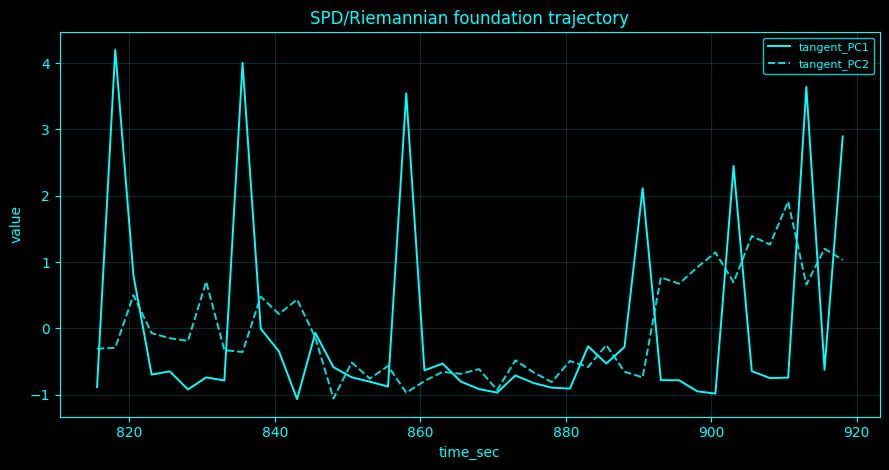

True

In [2]:
import os, math, glob, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy import linalg, stats, signal
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform, cdist
from scipy.sparse.csgraph import shortest_path
from scipy.optimize import linprog

FAST_OPTION=globals().get('FAST_OPTION','ultra')
if FAST_OPTION not in {'full','balanced','fast','ultra'}: raise ValueError('FAST_OPTION must be full/balanced/fast/ultra')
SPD_CFG={
'full':dict(step=.50,max_states=200,pair=120,mean_iter=30,boot=240,perm=320,kmeans=24,smooth=10),
'balanced':dict(step=.75,max_states=150,pair=90,mean_iter=20,boot=140,perm=180,kmeans=18,smooth=7),
'fast':dict(step=1.25,max_states=100,pair=65,mean_iter=14,boot=80,perm=100,kmeans=12,smooth=5),
'ultra':dict(step=2.50,max_states=55,pair=40,mean_iter=8,boot=36,perm=48,kmeans=7,smooth=3)}[FAST_OPTION]
EPS=1e-12; BG='black'; ACCENT='cyan'; RNG=np.random.default_rng(20260914)
base_dir=globals().get('base_dir','/home/a/projects/Complete-Neural-Signal-Analysis')
start_time=globals().get('start_time',814.571); end_time=globals().get('end_time',921.515); sampling_rate=1000.0
GEOM_OUT=os.path.join(base_dir,'results','geometry_catalogue_complete'); os.makedirs(GEOM_OUT,exist_ok=True)
eeg_channel_names=['Fp1','Fpz','Fp2','F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','M1','T7','C3','Cz','C4','T8','M2','CP5','CP1','CP2','CP6','P7','P3','Pz','P4','P8','POz','O1','Oz','O2']
CHANNEL_INDEX={c:i for i,c in enumerate(eeg_channel_names)}
LEFT=[CHANNEL_INDEX[c] for c in ['Fp1','F7','F3','FC5','FC1','M1','T7','C3','CP5','CP1','P7','P3','O1']]
RIGHT=[CHANNEL_INDEX[c] for c in ['Fp2','F8','F4','FC2','FC6','M2','T8','C4','CP2','CP6','P8','P4','O2']]
MID=[CHANNEL_INDEX[c] for c in ['Fpz','Fz','Cz','Pz','POz','Oz']]
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':BG,'savefig.facecolor':BG,'text.color':ACCENT,'axes.labelcolor':ACCENT,'axes.edgecolor':ACCENT,'axes.titlecolor':ACCENT,'xtick.color':ACCENT,'ytick.color':ACCENT,'grid.color':ACCENT,'legend.facecolor':BG,'legend.edgecolor':ACCENT})
def style_ax(ax,grid=True):
 ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)
 for s in ax.spines.values(): s.set_color(ACCENT)
GEOM_CMAP=LinearSegmentedColormap.from_list('geometry_black_cyan',[(0.0,'#000000'),(0.30,'#00343c'),(0.65,'#0097a7'),(1.0,'#00ffff')])
def style_colorbar(cbar):
 cbar.ax.tick_params(colors=ACCENT);cbar.ax.yaxis.label.set_color(ACCENT);cbar.outline.set_edgecolor(ACCENT)
def catalogue_numeric_value_count(df):
 df=pd.DataFrame(df)
 count=0
 for c in df.columns:
  if pd.api.types.is_bool_dtype(df[c]) or not pd.api.types.is_numeric_dtype(df[c]):
   continue
  a=np.asarray(df[c])
  if np.iscomplexobj(a):
   ok=np.isfinite(np.real(a))&np.isfinite(np.imag(a))
  else:
   try: ok=np.isfinite(np.asarray(a,float))
   except Exception: continue
  count+=int(np.sum(ok))
 return count

def catalogue_has_plot_data(df):
 return catalogue_numeric_value_count(df)>=2

def catalogue_autoplot_df(slug,df,title=None):
 df=pd.DataFrame(df).copy()
 if not catalogue_has_plot_data(df):
  return False
 title=(title or slug.replace('_',' ').title())
 num=[c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and not pd.api.types.is_bool_dtype(df[c])]
 def vals(c):
  a=np.asarray(df[c])
  if np.iscomplexobj(a):a=np.abs(a)
  return np.asarray(a,float)
 fig,ax=plt.subplots(figsize=(9,4.8),facecolor=BG);style_ax(ax)
 if len(df)==1:
  cols=num[:12];yy=np.array([vals(c)[0] for c in cols],float);ok=np.isfinite(yy);cols=[c for c,k in zip(cols,ok) if k];yy=yy[ok]
  if len(yy)>=2:
   xx=np.arange(len(yy));ax.bar(xx,yy,color=ACCENT,edgecolor=ACCENT,alpha=.72);ax.set_xticks(xx);ax.set_xticklabels(cols,rotation=45,ha='right',fontsize=8);ax.set_ylabel('value')
   nz=np.abs(yy[np.abs(yy)>EPS])
   if len(nz)>1 and np.max(nz)/max(np.min(nz),EPS)>1e4:ax.set_yscale('symlog',linthresh=max(np.min(nz),EPS))
  else:
   plt.close(fig);return False
 else:
  xname=None
  keys=('time','t','scale','rank','k','freq','frequency','lag','radius','alpha','beta','gamma','epsilon','window','index')
  for c in num:
   lc=str(c).lower()
   if lc in keys or any(lc.startswith(k+'_') or lc.endswith('_'+k) for k in keys):
    a=vals(c)
    if np.sum(np.isfinite(a))>=2 and len(np.unique(a[np.isfinite(a)]))>1:xname=c;break
  if xname is None and len(num)>1:
   a=vals(num[0])
   if np.sum(np.isfinite(a))>=2 and len(np.unique(a[np.isfinite(a)]))>1:xname=num[0]
  x=np.arange(len(df),dtype=float) if xname is None else vals(xname)
  ys=[c for c in num if c!=xname][:6]
  if not ys and xname is not None:
   ys=[xname];x=np.arange(len(df),dtype=float);xname=None
  styles=['-','--',':','-.','-','--'];alphas=[1.0,.88,.76,.68,.60,.52]
  plotted=0
  for c,ls,al in zip(ys,styles,alphas):
   y=vals(c);ok=np.isfinite(x)&np.isfinite(y)
   if np.sum(ok)>=2:
    ax.plot(x[ok],y[ok],color=ACCENT,linestyle=ls,linewidth=1.4,alpha=al,label=str(c));plotted+=1
  if plotted==0:
   plt.close(fig);return False
  ax.set_xlabel(str(xname) if xname is not None else 'index');ax.set_ylabel('value')
  if plotted>1:
   leg=ax.legend(facecolor=BG,edgecolor=ACCENT,fontsize=8)
   for txt in leg.get_texts():txt.set_color(ACCENT)
 ax.set_title(title);fig.tight_layout();plt.show();plt.close(fig);return True

def catalogue_status_plot(title,labels,values):
 values=np.asarray(values,float).ravel();ok=np.isfinite(values)
 if np.sum(ok)<2:return False
 labels=[str(x) for x,k in zip(labels,ok) if k];values=values[ok]
 fig,ax=plt.subplots(figsize=(8,4.2),facecolor=BG);style_ax(ax);x=np.arange(len(values));ax.bar(x,values,color=ACCENT,edgecolor=ACCENT,alpha=.72);ax.set_xticks(x);ax.set_xticklabels(labels,rotation=30,ha='right',fontsize=8);ax.set_ylabel('value');ax.set_title(title);fig.tight_layout();plt.show();plt.close(fig);return True
def outdir(slug): d=os.path.join(GEOM_OUT,slug); os.makedirs(d,exist_ok=True); return d
def emit_df(slug,df,plot=True):
 p=os.path.join(outdir(slug),f'{slug}_{FAST_OPTION}.csv');df.to_csv(p,index=False);print(df.head(12).to_string(index=False));
 if plot:catalogue_autoplot_df(slug,df)
 return df
def emit_series(slug,title,y,t=None,ylabel='value'):
 y=np.asarray(y,float);t=STATE_TIMES[:len(y)] if t is None else np.asarray(t,float);df=emit_df(slug,pd.DataFrame({'time_sec':t,ylabel:y}),plot=False)
 ok=np.isfinite(y)&np.isfinite(t)
 if np.sum(ok)<2:return df
 fig,ax=plt.subplots(figsize=(10,5),facecolor=BG);style_ax(ax);ax.plot(t[ok],y[ok],color=ACCENT);ax.set_title(title);ax.set_xlabel('Time (s)');ax.set_ylabel(ylabel);fig.tight_layout();fig.savefig(os.path.join(outdir(slug),f'{slug}_{FAST_OPTION}.png'),dpi=160,bbox_inches='tight');plt.show();plt.close(fig);return df
def emit_matrix(slug,title,M,labels=None):
 M=np.asarray(M,float);pd.DataFrame(M,index=labels,columns=labels).to_csv(os.path.join(outdir(slug),f'{slug}_{FAST_OPTION}.csv'))
 if np.sum(np.isfinite(M))<2:return M
 fig,ax=plt.subplots(figsize=(7.5,6.5),facecolor=BG);im=ax.imshow(M,aspect='auto',cmap=GEOM_CMAP);style_ax(ax,False);ax.set_title(title);cbar=plt.colorbar(im,ax=ax);style_colorbar(cbar);fig.tight_layout();fig.savefig(os.path.join(outdir(slug),f'{slug}_{FAST_OPTION}.png'),dpi=160,bbox_inches='tight');plt.show();plt.close(fig);return M
def sym(A): return .5*(np.asarray(A,float)+np.asarray(A,float).T)
def spd_eigh(A,floor=1e-10): w,V=np.linalg.eigh(sym(A)); return np.maximum(w,floor),V
def spow(A,p): w,V=spd_eigh(A); return sym((V*(w**p))@V.T)
def slog(A): w,V=spd_eigh(A); return sym((V*np.log(w))@V.T)
def sexp(A): w,V=np.linalg.eigh(sym(A)); return sym((V*np.exp(np.clip(w,-60,60)))@V.T)
def reg(C,sh=.02):
 C=sym(C); n=C.shape[0]; sc=max(float(np.trace(C)/n),1e-8); C=(1-sh)*C+sh*sc*np.eye(n); w,V=spd_eigh(C,max(1e-9,1e-8*sc)); return sym((V*w)@V.T)
def airm(P,Q): Pi=spow(P,-.5); return float(np.linalg.norm(slog(Pi@Q@Pi),'fro'))
def logmap(P,Q): Ph=spow(P,.5); Pi=spow(P,-.5); return sym(Ph@slog(Pi@Q@Pi)@Ph)
def expmap(P,V): Ph=spow(P,.5); Pi=spow(P,-.5); return reg(Ph@sexp(Pi@V@Pi)@Ph,0)
def geod(P,Q,t): return expmap(P,float(t)*logmap(P,Q))
def white(P,V): Pi=spow(P,-.5); return sym(Pi@V@Pi)
def tnorm(P,V): X=white(P,V); return float(np.linalg.norm(X,'fro'))
def symvec(S):
 S=sym(S); n=len(S); return np.r_[[S[i,i] for i in range(n)],[math.sqrt(2)*S[i,j] for i in range(n) for j in range(i+1,n)]]
def unsymvec(v,n):
 S=np.zeros((n,n)); k=0
 for i in range(n): S[i,i]=v[k]; k+=1
 for i in range(n):
  for j in range(i+1,n): S[i,j]=S[j,i]=v[k]/math.sqrt(2); k+=1
 return S
def sectionK(X,Y):
 X=sym(X);Y=sym(Y); xx=np.sum(X*X);yy=np.sum(Y*Y);xy=np.sum(X*Y); den=xx*yy-xy*xy
 if den<=1e-14:return np.nan
 C=X@Y-Y@X; return float(-.25*np.sum(C*C)/den)
def symbasis(n):
 B=[]
 for i in range(n): E=np.zeros((n,n));E[i,i]=1;B.append(E)
 for i in range(n):
  for j in range(i+1,n): E=np.zeros((n,n));E[i,j]=E[j,i]=1/math.sqrt(2);B.append(E)
 return B
def ricci_dir(X):
 n=np.linalg.norm(X,'fro');
 if n<1e-14:return np.nan
 X=sym(X)/n; return float(sum(-.25*np.sum((E@X-X@E)**2) for E in symbasis(len(X))))
def rmean(S,maxiter=None):
 S=np.asarray(S); G=reg(np.mean(S,axis=0)); maxiter=SPD_CFG['mean_iter'] if maxiter is None else maxiter
 for _ in range(int(maxiter)):
  Gi=spow(G,-.5); D=np.mean([slog(Gi@C@Gi) for C in S],axis=0); G=reg(spow(G,.5)@sexp(D)@spow(G,.5),0)
  if np.linalg.norm(D,'fro')<1e-8:break
 return G
def tangent(S,G=None):
 G=rmean(S) if G is None else G; Gi=spow(G,-.5); M=[slog(Gi@C@Gi) for C in S]; return G,np.stack([symvec(x) for x in M]),M
def pcasvd(X):
 mu=X.mean(0); U,s,Vt=np.linalg.svd(X-mu,full_matrices=False); ev=s*s/max(len(X)-1,1); return U*s,Vt,ev/(ev.sum()+EPS),mu
def le(P,Q): return float(np.linalg.norm(slog(P)-slog(Q),'fro'))
def bures(P,Q): Ph=spow(P,.5); M=spow(Ph@Q@Ph,.5); return math.sqrt(max(float(np.trace(P)+np.trace(Q)-2*np.trace(M)),0))
def logdet(P): return float(np.sum(np.log(spd_eigh(P)[0])))
def stein(P,Q): return float(logdet(.5*(P+Q))-.5*logdet(P)-.5*logdet(Q))
def pdist(S,fn):
 n=len(S); D=np.zeros((n,n))
 for i in range(n):
  for j in range(i+1,n): D[i,j]=D[j,i]=fn(S[i],S[j])
 return D
def robustz(x):
 x=np.asarray(x,float);m=np.nanmedian(x);mad=np.nanmedian(np.abs(x-m));return .67448975*(x-m)/(mad+EPS)

def _layout(x):
 x=np.asarray(x,float)
 if x.ndim!=2: raise ValueError('EEG must be 2-D')
 if x.shape[1]==32:return x
 if x.shape[0]==32:return x.T
 raise ValueError(f'Expected a 32-channel dimension, got {x.shape}')
if 'EEG_DATA_OVERRIDE' in globals(): RAW=_layout(EEG_DATA_OVERRIDE)
else: RAW=_layout(np.load(os.path.join(base_dir,'eeg_data_with_channels.npy'),allow_pickle=True))
a0=max(0,int(round(start_time*sampling_rate))); b0=min(len(RAW),int(round(end_time*sampling_rate)))
if b0-a0<2000: a0=0;b0=min(len(RAW),max(8000,len(RAW)))
SEG=RAW[a0:b0]; mu=np.nanmean(SEG,0); sd=np.nanstd(SEG,0);sd[sd<EPS]=1; EEG_STD=np.nan_to_num((SEG-mu)/sd)
win=2000; step=max(1,int(round(SPD_CFG['step']*sampling_rate))); starts=np.arange(0,max(1,len(EEG_STD)-win+1),step,dtype=int)
if len(starts)>SPD_CFG['max_states']: starts=starts[np.unique(np.linspace(0,len(starts)-1,SPD_CFG['max_states']).round().astype(int))]
BOUNDS=[(s,min(s+win,len(EEG_STD))) for s in starts if min(s+win,len(EEG_STD))-s>64]
STATE_TIMES=start_time+np.array([(a+b)/2 for a,b in BOUNDS])/sampling_rate
COV=np.stack([reg(np.cov(EEG_STD[a:b],rowvar=False)) for a,b in BOUNDS]); N=len(COV); nC=32
G=rmean(COV); G,TAN,TM=tangent(COV,G); SCORE,COMP,EXPL,TANMU=pcasvd(TAN)
idx=np.unique(np.linspace(0,N-1,min(N,SPD_CFG['pair'])).round().astype(int)); PS=COV[idx]; PT=STATE_TIMES[idx]
DC={}
def dist(name):
 if name not in DC:
  fn={'airm':airm,'le':le,'bures':bures,'fisher':lambda a,b:airm(a,b)/math.sqrt(2),'stein':lambda a,b:math.sqrt(max(stein(a,b),0))}[name];DC[name]=pdist(PS,fn)
 return DC[name]
print('SPD foundation:',FAST_OPTION,'states',N,'pair states',len(PS))

# Visible foundation diagnostic
catalogue_autoplot_df('000_spd_foundation',pd.DataFrame({'time_sec':STATE_TIMES,'tangent_PC1':SCORE[:,0],'tangent_PC2':SCORE[:,1] if SCORE.shape[1]>1 else np.zeros(len(SCORE))}),title='SPD/Riemannian foundation trajectory')


### Affine-invariant SPD geodesic shooting


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Affine-invariant SPD geodesic shooting</h3>
<p>Geodesic shooting integrates the affine-invariant exponential map from a start covariance. Choosing the initial velocity as the logarithm of the target must reach the target at unit parameter and gives constant metric speed.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\gamma(t)=\operatorname{Exp}_P(t\operatorname{Log}_P Q),\quad d(P,\gamma(t))=t\,d(P,Q).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


       t     distance  expected
0.000000 1.326203e-13  0.000000
0.033333 1.560610e-01  0.156061
0.066667 3.121221e-01  0.312122
0.100000 4.681831e-01  0.468183
0.133333 6.242442e-01  0.624244
0.166667 7.803052e-01  0.780305
0.200000 9.363663e-01  0.936366
0.233333 1.092427e+00  1.092427
0.266667 1.248488e+00  1.248488
0.300000 1.404549e+00  1.404549
0.333333 1.560610e+00  1.560610
0.366667 1.716672e+00  1.716672


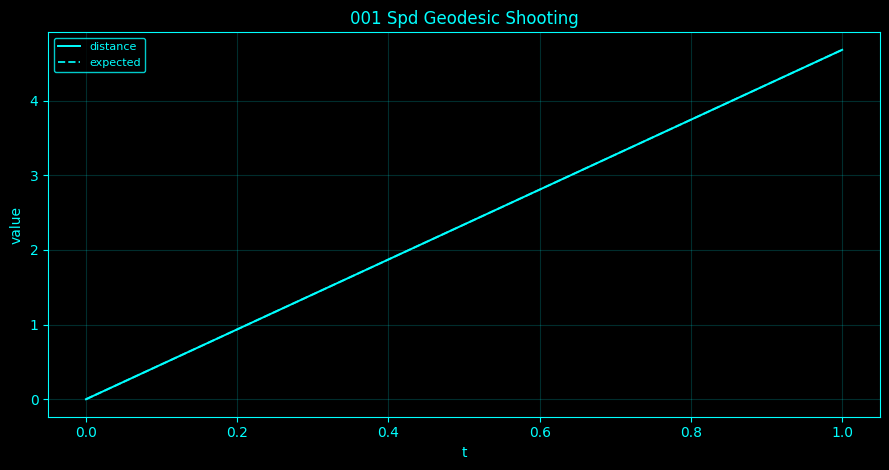

,t,distance,expected
0,0.000000,1.326203e-13,0.000000
1,0.033333,1.560610e-01,0.156061
2,0.066667,3.121221e-01,0.312122
3,0.100000,4.681831e-01,0.468183
4,0.133333,6.242442e-01,0.624244
5,0.166667,7.803052e-01,0.780305
6,0.200000,9.363663e-01,0.936366
7,0.233333,1.092427e+00,1.092427
8,0.266667,1.248488e+00,1.248488
9,0.300000,1.404549e+00,1.404549


In [3]:
q=int(np.argmax([airm(G,C) for C in COV])); ts=np.linspace(0,1,31); vals=[airm(G,geod(G,COV[q],t)) for t in ts]; emit_df('001_spd_geodesic_shooting',pd.DataFrame({'t':ts,'distance':vals,'expected':ts*airm(G,COV[q])}))


### SPD exponential-map diagnostics


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD exponential-map diagnostics</h3>
<p>The exponential and logarithm maps are inverse locally and globally on the AIRM SPD Hadamard manifold. Reconstruction error therefore diagnoses numerical conditioning rather than a model discrepancy.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\operatorname{Exp}_P(\operatorname{Log}_P Q)=Q.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec   AIRM_error
  818.071 3.460621e-13
  820.571 3.639027e-13
  823.071 2.303957e-13
  825.571 2.792490e-13
  828.071 2.966174e-13
  830.571 2.806213e-13
  833.071 2.439564e-13
  835.571 2.523859e-13
  838.071 2.227162e-13
  840.571 2.185749e-13
  843.071 3.021853e-13
  845.571 2.252694e-13


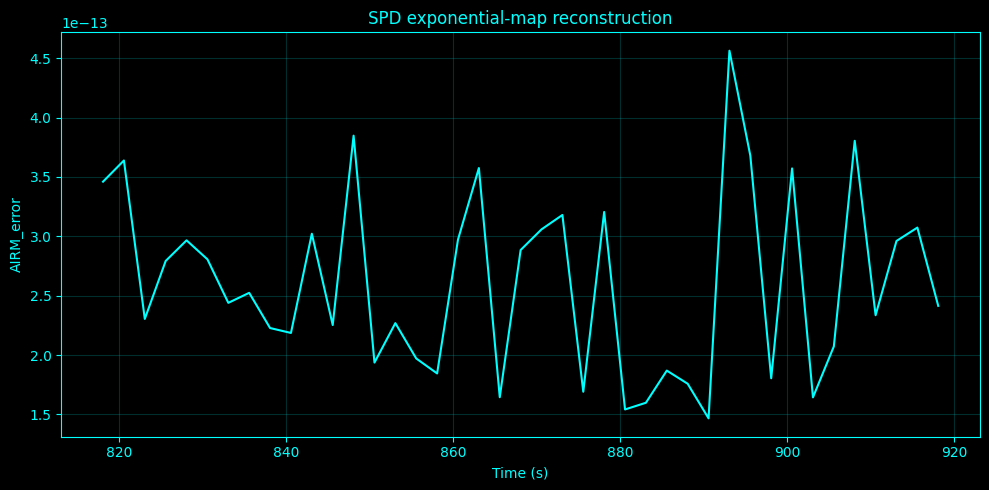

,time_sec,AIRM_error
0,818.071,3.460621e-13
1,820.571,3.639027e-13
2,823.071,2.303957e-13
3,825.571,2.792490e-13
4,828.071,2.966174e-13
5,830.571,2.806213e-13
6,833.071,2.439564e-13
7,835.571,2.523859e-13
8,838.071,2.227162e-13
9,840.571,2.185749e-13


In [4]:
e=[airm(expmap(COV[i],logmap(COV[i],COV[i+1])),COV[i+1]) for i in range(N-1)];emit_series('002_spd_exp_diagnostics','SPD exponential-map reconstruction',e,STATE_TIMES[1:],'AIRM_error')


### SPD logarithm-map diagnostics


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD logarithm-map diagnostics</h3>
<p>The norm of the logarithm map equals the geodesic distance. This cell checks that defining AIRM identity on consecutive covariance states.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\|\operatorname{Log}_P Q\|_P=d(P,Q).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  log_norm  distance  identity_error
  818.071  5.798489  5.798489    4.440892e-15
  820.571  5.311332  5.311332    2.131628e-14
  823.071  3.898335  3.898335    9.325873e-15
  825.571  2.482327  2.482327    2.220446e-15
  828.071  2.557465  2.557465    3.996803e-15
  830.571  3.216626  3.216626    8.881784e-16
  833.071  2.978241  2.978241    2.664535e-15
  835.571  5.651108  5.651108    7.105427e-15
  838.071  5.402422  5.402422    6.217249e-15
  840.571  3.261053  3.261053    4.440892e-16
  843.071  3.300246  3.300246    4.884981e-15
  845.571  3.240253  3.240253    7.993606e-15


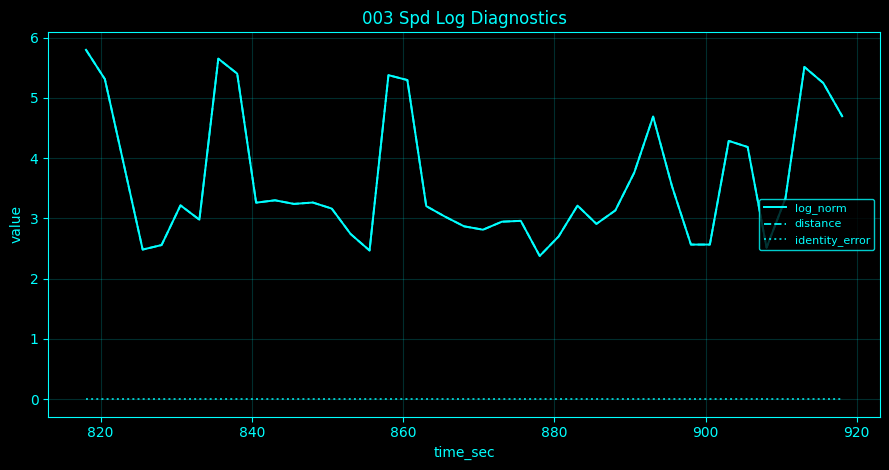

,time_sec,log_norm,distance,identity_error
0,818.071,5.798489,5.798489,4.440892e-15
1,820.571,5.311332,5.311332,2.131628e-14
2,823.071,3.898335,3.898335,9.325873e-15
3,825.571,2.482327,2.482327,2.220446e-15
4,828.071,2.557465,2.557465,3.996803e-15
5,830.571,3.216626,3.216626,8.881784e-16
6,833.071,2.978241,2.978241,2.664535e-15
7,835.571,5.651108,5.651108,7.105427e-15
8,838.071,5.402422,5.402422,6.217249e-15
9,840.571,3.261053,3.261053,4.440892e-16


In [5]:
rows=[]
for i in range(N-1):
 v=logmap(COV[i],COV[i+1]); d=airm(COV[i],COV[i+1]); rows.append((STATE_TIMES[i+1],tnorm(COV[i],v),d,abs(tnorm(COV[i],v)-d)))
emit_df('003_spd_log_diagnostics',pd.DataFrame(rows,columns=['time_sec','log_norm','distance','identity_error']))


### SPD geodesic deviation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD geodesic deviation</h3>
<p>Geodesic deviation is sampled as the separation of two geodesics sharing a start point but ending at neighboring EEG covariance states. Nonpositive curvature prevents positive-curvature focusing.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$J_{sep}(t)=d(\gamma_1(t),\gamma_2(t)).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


       t   separation
0.000000 1.219150e-13
0.033333 9.488757e-02
0.066667 1.897802e-01
0.100000 2.846829e-01
0.133333 3.796007e-01
0.166667 4.745387e-01
0.200000 5.695018e-01
0.233333 6.644951e-01
0.266667 7.595234e-01
0.300000 8.545917e-01
0.333333 9.497048e-01
0.366667 1.044868e+00


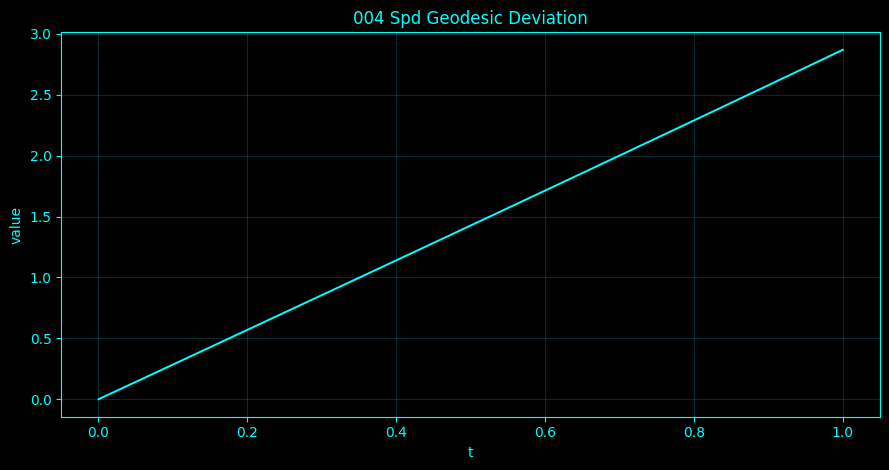

,t,separation
0,0.000000,1.219150e-13
1,0.033333,9.488757e-02
2,0.066667,1.897802e-01
3,0.100000,2.846829e-01
4,0.133333,3.796007e-01
5,0.166667,4.745387e-01
6,0.200000,5.695018e-01
7,0.233333,6.644951e-01
8,0.266667,7.595234e-01
9,0.300000,8.545917e-01


In [6]:
i=max(0,N//2-1); ts=np.linspace(0,1,31); sep=[airm(geod(G,COV[i],t),geod(G,COV[min(i+1,N-1)],t)) for t in ts];emit_df('004_spd_geodesic_deviation',pd.DataFrame({'t':ts,'separation':sep}))


### SPD Jacobi field analysis


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD Jacobi field analysis</h3>
<p>A Jacobi field is the infinitesimal variation of a family of geodesics. A central finite difference of two nearby geodesics gives an intrinsic norm estimate.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\|J(t)\|\approx d(\operatorname{Exp}_P(t(V+\epsilon W)),\operatorname{Exp}_P(t(V-\epsilon W)))/(2\epsilon).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


       t  jacobi_norm_fd
0.000000    6.095751e-11
0.033333    3.333340e-02
0.066667    6.666722e-02
0.100000    1.000019e-01
0.133333    1.333377e-01
0.166667    1.666753e-01
0.200000    2.000148e-01
0.233333    2.333569e-01
0.266667    2.667019e-01
0.300000    3.000501e-01
0.333333    3.334021e-01
0.366667    3.667582e-01


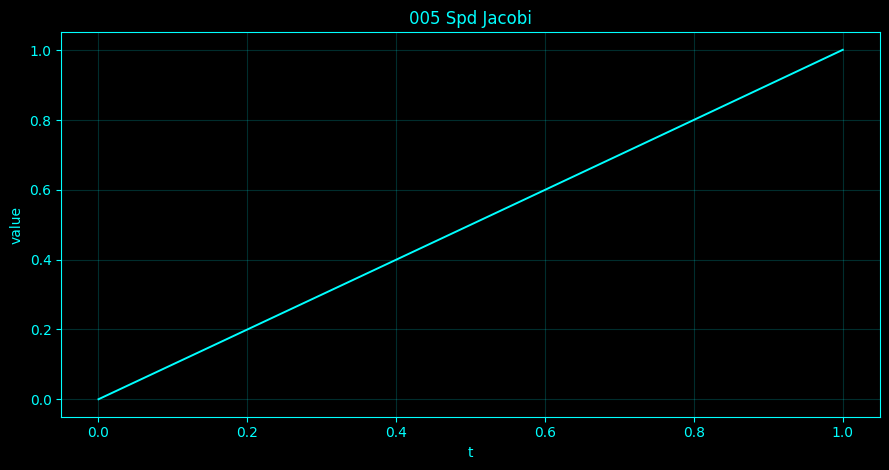

,t,jacobi_norm_fd
0,0.000000,6.095751e-11
1,0.033333,3.333340e-02
2,0.066667,6.666722e-02
3,0.100000,1.000019e-01
4,0.133333,1.333377e-01
5,0.166667,1.666753e-01
6,0.200000,2.000148e-01
7,0.233333,2.333569e-01
8,0.266667,2.667019e-01
9,0.300000,3.000501e-01


In [7]:
X=TM[max(0,N//3)];Y=TM[min(N-1,2*N//3)];X/=np.linalg.norm(X)+EPS;Y-=np.sum(X*Y)*X;Y/=np.linalg.norm(Y)+EPS;Gh=spow(G,.5);V=Gh@X@Gh;W=Gh@Y@Gh;ts=np.linspace(0,1,31);ee=1e-3;j=[airm(expmap(G,t*(V+ee*W)),expmap(G,t*(V-ee*W)))/(2*ee) for t in ts];emit_df('005_spd_jacobi',pd.DataFrame({'t':ts,'jacobi_norm_fd':j}))


### SPD conjugate point analysis


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD conjugate point analysis</h3>
<p>AIRM SPD is complete, simply connected, and nonpositively curved, hence a Hadamard manifold with no conjugate points. The numerical Jacobi curve is only a consistency check of this theorem.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$K\le0\Longrightarrow\text{no conjugate points}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [8]:
emit_df('006_spd_conjugate_points',pd.DataFrame({'minimum_nonzero_t_jacobi_norm':[float(np.min(j[1:]))],'near_zero_detected':[bool(np.any(np.asarray(j[1:])<1e-8))]}))


 minimum_nonzero_t_jacobi_norm  near_zero_detected
                      0.033333               False


,minimum_nonzero_t_jacobi_norm,near_zero_detected
0,0.033333,False


### SPD sectional-curvature distribution by tangent direction


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD sectional-curvature distribution by tangent direction</h3>
<p>After whitening tangent vectors to the identity, AIRM sectional curvature is determined by their matrix commutator. Commuting directions are flat and noncommuting directions have negative curvature.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$K(X,Y)=-\frac14\frac{\|[X,Y]\|_F^2}{\|X\|^2\|Y\|^2-\langle X,Y\rangle^2}\le0.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 sectional_curvature
           -0.025408
           -0.010524
           -0.008114
           -0.013413
           -0.017748
           -0.041468
           -0.017700
           -0.010793
           -0.012280
           -0.031946
           -0.010314
           -0.038065


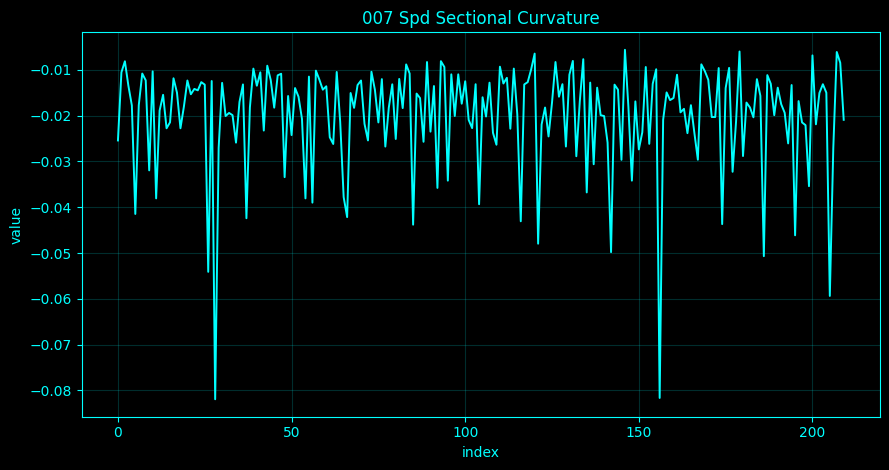

,sectional_curvature
0,-0.025408
1,-0.010524
2,-0.008114
3,-0.013413
4,-0.017748
...,...
205,-0.059378
206,-0.027086
207,-0.006083
208,-0.008440


In [9]:
rows=[]
for _ in range(min(500,max(40,N*5))):
 i,jj=RNG.choice(N,2,replace=False); k=sectionK(TM[i],TM[jj]);
 if np.isfinite(k): rows.append(k)
emit_df('007_spd_sectional_curvature',pd.DataFrame({'sectional_curvature':rows}))


### SPD Ricci curvature by channel subspace


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD Ricci curvature by channel subspace</h3>
<p>Directional Ricci curvature is the trace of sectional curvature over an orthonormal tangent basis. Regions are evaluated in their own SPD dimensions so incompatible covariance sizes are never compared directly.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\mathrm{Ric}(X,X)=-\tfrac14\sum_a\|[E_a,X]\|_F^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 region  dimension  mean_directional_ricci      std
   left         13               -2.977280 0.279400
  right         13               -2.921971 0.411802
midline          6               -1.309093 0.186724


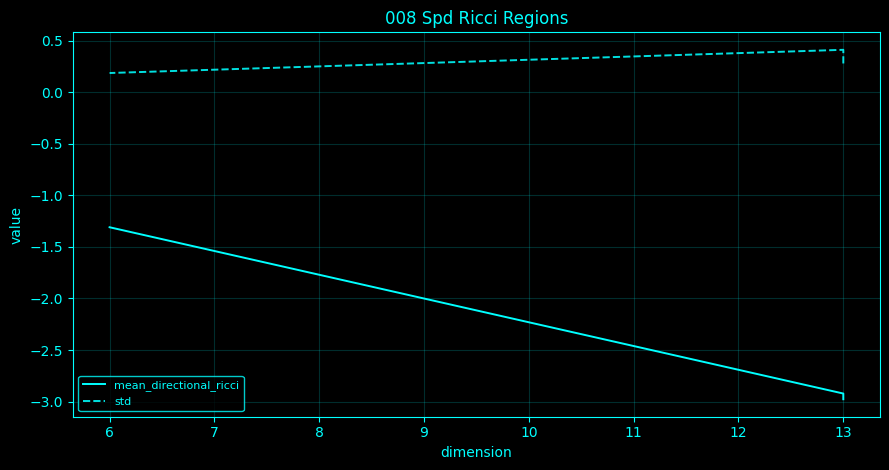

,region,dimension,mean_directional_ricci,std
0,left,13,-2.977280,0.279400
1,right,13,-2.921971,0.411802
2,midline,6,-1.309093,0.186724


In [10]:
rows=[]
for name,ii in [('left',LEFT),('right',RIGHT),('midline',MID)]:
 S=np.stack([reg(np.cov(EEG_STD[a:b][:,ii],rowvar=False)) for a,b in BOUNDS]); R=rmean(S); Ri=spow(R,-.5); vals=[ricci_dir(slog(Ri@C@Ri)) for C in S]; rows.append((name,len(ii),np.nanmean(vals),np.nanstd(vals)))
emit_df('008_spd_ricci_regions',pd.DataFrame(rows,columns=['region','dimension','mean_directional_ricci','std']))


### SPD scalar-curvature time series


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD scalar-curvature time series</h3>
<p>The AIRM SPD manifold is homogeneous. Consequently scalar curvature depends only on matrix dimension, so a genuine scalar-curvature time series is constant for fixed channel count.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\mathrm{Scal}_{SPD(n)}=-n(n-1)(n+2)/8.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 time_sec  scalar_curvature
  815.571           -4216.0
  818.071           -4216.0
  820.571           -4216.0
  823.071           -4216.0
  825.571           -4216.0
  828.071           -4216.0
  830.571           -4216.0
  833.071           -4216.0
  835.571           -4216.0
  838.071           -4216.0
  840.571           -4216.0
  843.071           -4216.0


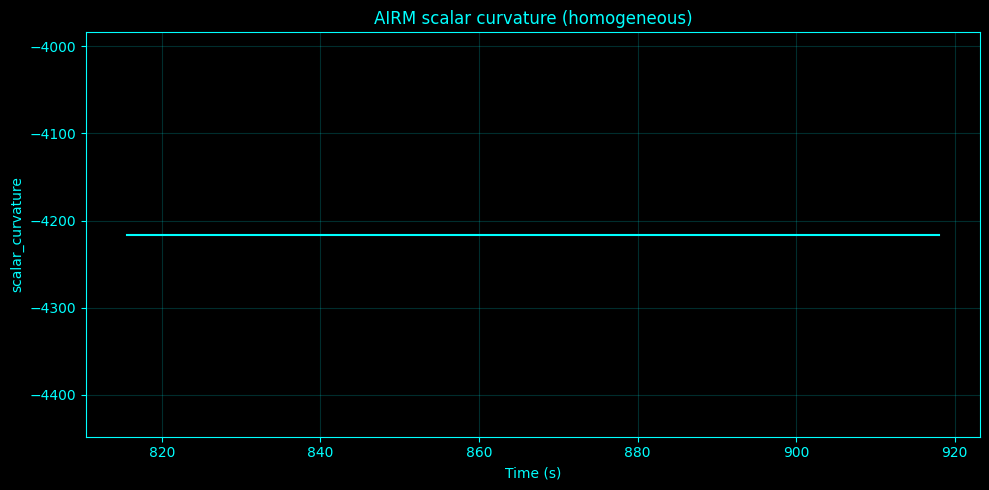

,time_sec,scalar_curvature
0,815.571,-4216.0
1,818.071,-4216.0
2,820.571,-4216.0
3,823.071,-4216.0
4,825.571,-4216.0
5,828.071,-4216.0
6,830.571,-4216.0
7,833.071,-4216.0
8,835.571,-4216.0
9,838.071,-4216.0


In [11]:
emit_series('009_spd_scalar_curvature','AIRM scalar curvature (homogeneous)',np.full(N,-nC*(nC-1)*(nC+2)/8),'time_sec' if False else None,'scalar_curvature')


### SPD curvature anisotropy spectrum


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD curvature anisotropy spectrum</h3>
<p>Sectional curvature remains anisotropic even though scalar curvature is constant. Leading tangent-PCA directions define dominant covariance-deformation planes whose commutators determine this spectrum.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$K_{ab}=K(V_a,V_b).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 pc_a  pc_b         K
    1     2 -0.003991
    1     3 -0.020633
    1     4 -0.045986
    1     5 -0.056194
    1     6 -0.047010
    1     7 -0.029879
    1     8 -0.040854
    2     3 -0.006524
    2     4 -0.007264
    2     5 -0.006731
    2     6 -0.007624
    2     7 -0.006380


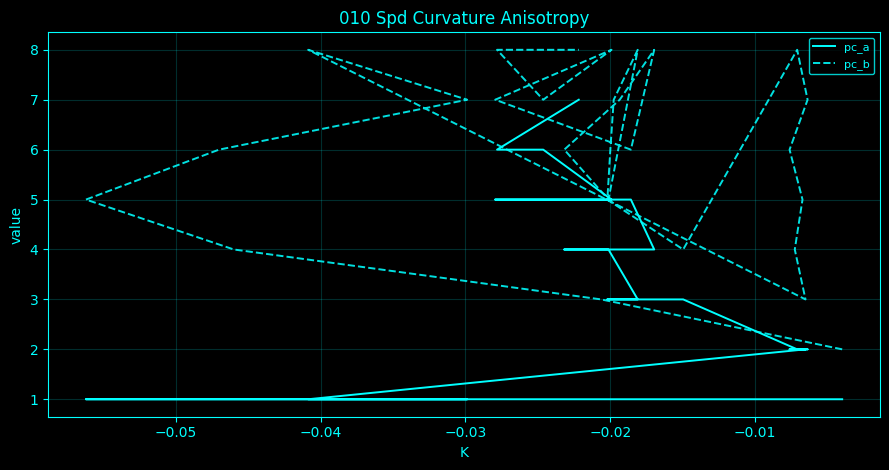

,pc_a,pc_b,K
0,1,2,-0.003991
1,1,3,-0.020633
2,1,4,-0.045986
3,1,5,-0.056194
4,1,6,-0.047010
5,1,7,-0.029879
6,1,8,-0.040854
7,2,3,-0.006524
8,2,4,-0.007264
9,2,5,-0.006731


In [12]:
k=min(8,len(COMP)); rows=[]
for a in range(k):
 for b in range(a+1,k): rows.append((a+1,b+1,sectionK(unsymvec(COMP[a],nC),unsymvec(COMP[b],nC))))
emit_df('010_spd_curvature_anisotropy',pd.DataFrame(rows,columns=['pc_a','pc_b','K']))


### SPD curvature-flow analysis


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD curvature-flow analysis</h3>
<p>There is no canonical Ricci flow of a finite sample list. This implementation instead uses intrinsic discrete harmonic-map heat flow on the observed SPD trajectory and labels it accordingly.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$P_i^{k+1}=\operatorname{Exp}_{P_i^k}[\eta(\operatorname{Log}_{P_i^k}P_{i-1}^k+\operatorname{Log}_{P_i^k}P_{i+1}^k)/2].$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 iteration  roughness
         0  14.216380
         1   3.831822
         2   1.673310
         3   0.990187


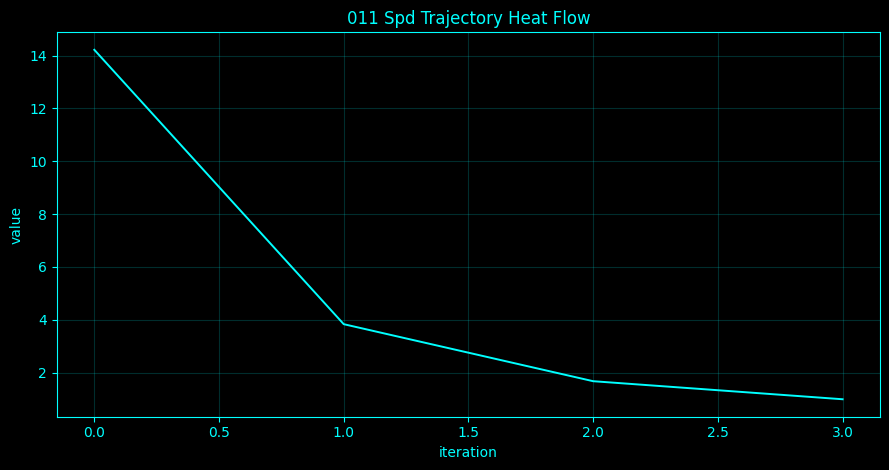

,iteration,roughness
0,0,14.216380
1,1,3.831822
2,2,1.673310
3,3,0.990187


In [13]:
S=COV.copy(); rows=[]
for it in range(SPD_CFG['smooth']+1):
 rows.append((it,np.mean([airm(S[i],S[i+1])**2 for i in range(len(S)-1)])))
 if it<SPD_CFG['smooth']:
  T=S.copy()
  for i in range(1,len(S)-1): T[i]=expmap(S[i],.35*.5*(logmap(S[i],S[i-1])+logmap(S[i],S[i+1])))
  S=T
emit_df('011_spd_trajectory_heat_flow',pd.DataFrame(rows,columns=['iteration','roughness']))


### SPD geodesic triangle defect


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD geodesic triangle defect</h3>
<p>Triangle defect is the nonnegative slack in the metric triangle inequality. It is a finite metric diagnostic, not a curvature tensor.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\Delta=d(A,B)+d(B,C)-d(A,C)\ge0.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 triangle_defect
        2.051493
        3.776116
        2.751801
        3.208688
        4.213132
        3.453687
        5.282511
        3.003033
        6.710021
        3.678743
        3.540454
        3.607809


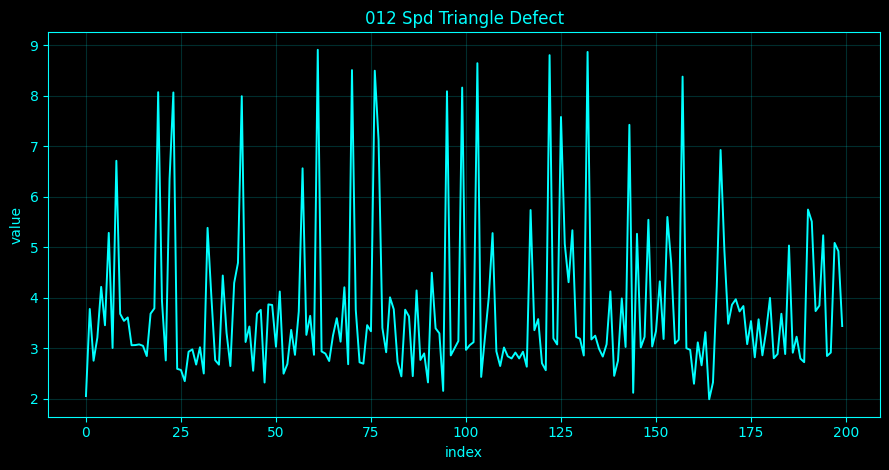

,triangle_defect
0,2.051493
1,3.776116
2,2.751801
3,3.208688
4,4.213132
...,...
195,2.844766
196,2.913294
197,5.084274
198,4.920719


In [14]:
D=dist('airm');rows=[]
for _ in range(min(300,len(D)*5)):
 i,jj,k=RNG.choice(len(D),3,replace=False);rows.append(D[i,jj]+D[jj,k]-D[i,k])
emit_df('012_spd_triangle_defect',pd.DataFrame({'triangle_defect':rows}))


### SPD geodesic convexity analysis


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD geodesic convexity analysis</h3>
<p>Squared distance to a fixed point is geodesically convex on a Hadamard manifold. The sampled convexity gap should therefore be nonnegative up to numerical error.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\tfrac12d(\gamma(t),Q)^2\le(1-t)\tfrac12d(A,Q)^2+t\tfrac12d(B,Q)^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


  minimum_gap
-8.171241e-14
-7.815970e-14
-1.563194e-13
 2.042810e-14
-6.128431e-14
-9.059420e-14
 1.154632e-14
-2.531308e-14
-7.904788e-14
 7.105427e-15
 1.509903e-13
 1.332268e-14


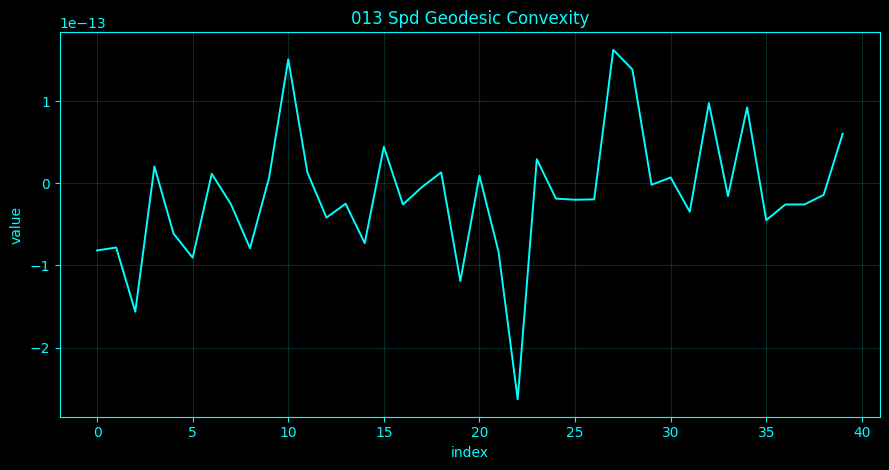

,minimum_gap
0,-8.171241e-14
1,-7.815970e-14
2,-1.563194e-13
3,2.042810e-14
4,-6.128431e-14
5,-9.059420e-14
6,1.154632e-14
7,-2.531308e-14
8,-7.904788e-14
9,7.105427e-15


In [15]:
rows=[]
for _ in range(min(40,len(PS))):
 a,b,q=RNG.choice(len(PS),3,replace=False); gap=[]
 for t in np.linspace(0,1,11): gap.append((1-t)*.5*airm(PS[a],PS[q])**2+t*.5*airm(PS[b],PS[q])**2-.5*airm(geod(PS[a],PS[b],t),PS[q])**2)
 rows.append(min(gap))
emit_df('013_spd_geodesic_convexity',pd.DataFrame({'minimum_gap':rows}))


### SPD geodesic PCA


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD geodesic PCA</h3>
<p>Geodesic PCA is approximated by PCA in the tangent space at the Fréchet mean followed by exponential-map reconstruction. Reconstruction error is reported because tangent PCA is a local approximation to globally optimal principal geodesics.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$s_i=\mathrm{vec}[\log(G^{-1/2}P_iG^{-1/2})].$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 components  mean_airm_reconstruction
          1                  2.185313
          2                  2.052374
          3                  1.987251
          4                  1.933804
          5                  1.870077
          6                  1.813651
          7                  1.761284
          8                  1.703963
          9                  1.652474
         10                  1.596282


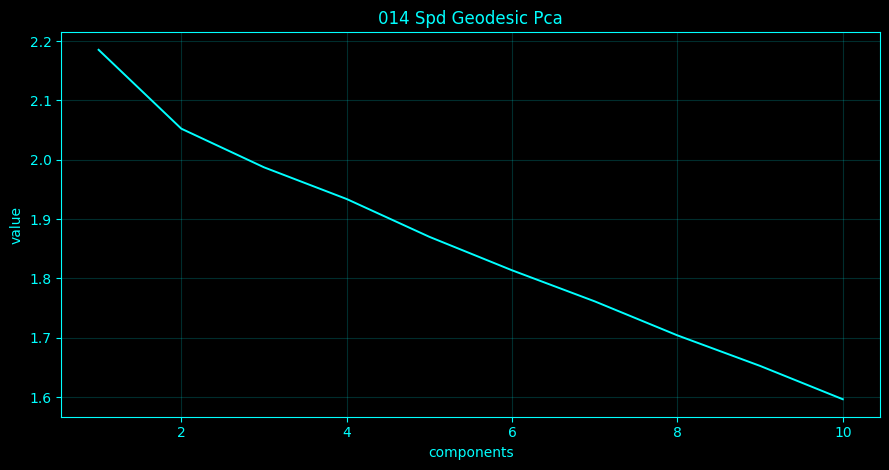

,components,mean_airm_reconstruction
0,1,2.185313
1,2,2.052374
2,3,1.987251
3,4,1.933804
4,5,1.870077
5,6,1.813651
6,7,1.761284
7,8,1.703963
8,9,1.652474
9,10,1.596282


In [16]:
X=TAN-TANMU;Gh=spow(G,.5);rows=[]
for k in range(1,min(10,len(COMP))+1):
 R=(X@COMP[:k].T)@COMP[:k]+TANMU;err=[airm(reg(Gh@sexp(unsymvec(r,nC))@Gh,0),C) for r,C in zip(R,COV)];rows.append((k,np.mean(err)))
emit_df('014_spd_geodesic_pca',pd.DataFrame(rows,columns=['components','mean_airm_reconstruction']))


### SPD principal geodesic analysis


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD principal geodesic analysis</h3>
<p>Principal geodesic analysis maps a leading tangent PCA direction back through the exponential map. Scores are the projections of each log-mapped covariance onto that direction.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$a_i=\langle s_i-\bar s,V_1\rangle,\quad\Gamma(a)=\operatorname{Exp}_G(aV_1).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec      PGA1
  815.571 -0.882505
  818.071  4.201319
  820.571  0.801035
  823.071 -0.695169
  825.571 -0.647311
  828.071 -0.920750
  830.571 -0.737621
  833.071 -0.784824
  835.571  4.004652
  838.071 -0.003425
  840.571 -0.345846
  843.071 -1.065387


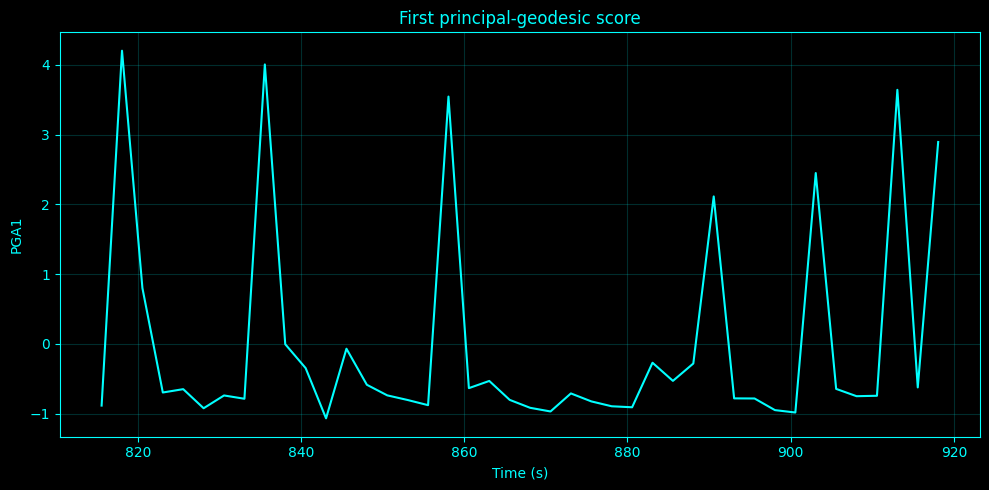

,time_sec,PGA1
0,815.571,-0.882505
1,818.071,4.201319
2,820.571,0.801035
3,823.071,-0.695169
4,825.571,-0.647311
5,828.071,-0.920750
6,830.571,-0.737621
7,833.071,-0.784824
8,835.571,4.004652
9,838.071,-0.003425


In [17]:
emit_series('015_spd_pga','First principal-geodesic score',(TAN-TANMU)@COMP[0],STATE_TIMES,'PGA1')


### SPD tangent-space PCA stability


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD tangent-space PCA stability</h3>
<p>Tangent-PCA stability is measured by principal angles between leading subspaces fitted on the first and second temporal halves.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\cos\theta_j=\sigma_j(V_A V_B^T).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 principal_angle_deg
           27.023309
           58.221583
           67.440678
           79.641832
           82.971365
           85.338641


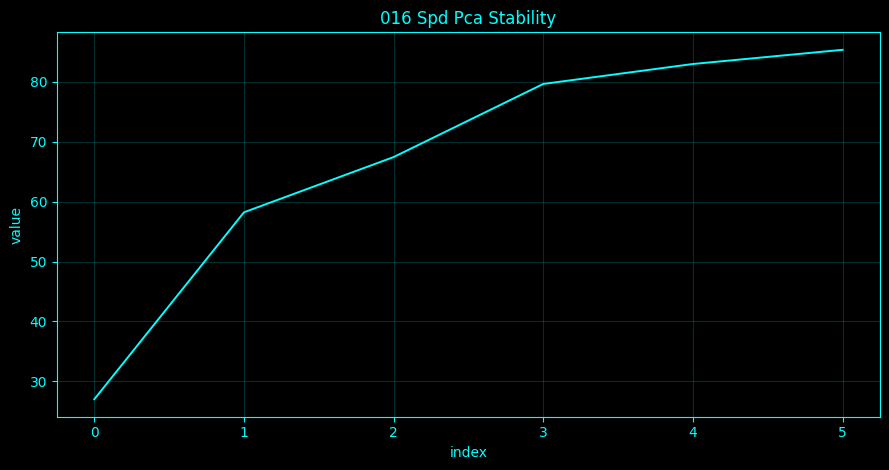

,principal_angle_deg
0,27.023309
1,58.221583
2,67.440678
3,79.641832
4,82.971365
5,85.338641


In [18]:
h=N//2;_,XA,_=tangent(COV[:h],G);_,XB,_=tangent(COV[h:],G);_,VA,_,_=pcasvd(XA);_,VB,_,_=pcasvd(XB);k=min(6,len(VA),len(VB));ang=np.degrees(np.arccos(np.clip(np.linalg.svd(VA[:k]@VB[:k].T,compute_uv=False),-1,1)));emit_df('016_spd_pca_stability',pd.DataFrame({'principal_angle_deg':ang}))


### SPD Fréchet variance decomposition


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD Fréchet variance decomposition</h3>
<p>Fréchet variance is the exact mean squared intrinsic distance to the Fréchet mean; tangent PCA eigenvalue fractions are a local variance decomposition.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$V_F=N^{-1}\sum_i d(G,P_i)^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 component  cumulative_tangent_fraction  exact_frechet_variance
         1                     0.326721                7.108374
         2                     0.408637                7.108374
         3                     0.447357                7.108374
         4                     0.481875                7.108374
         5                     0.515626                7.108374
         6                     0.545020                7.108374
         7                     0.572849                7.108374
         8                     0.598794                7.108374
         9                     0.621681                7.108374
        10                     0.644117                7.108374
        11                     0.664841                7.108374
        12                     0.685155                7.108374


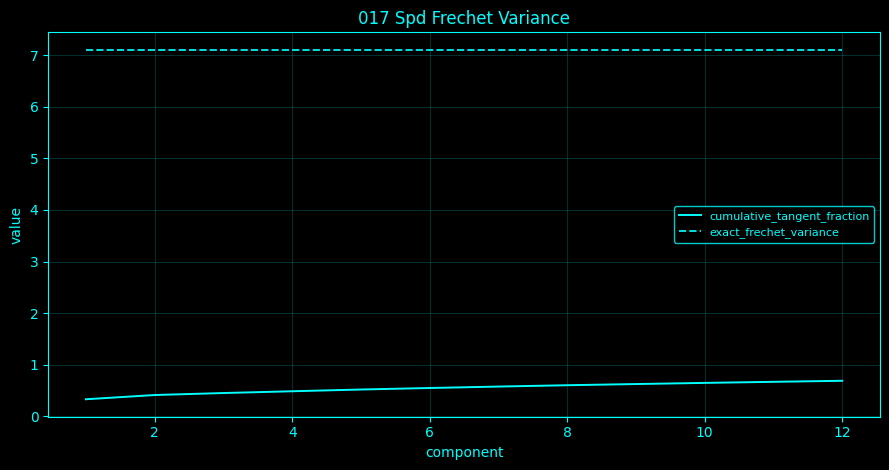

,component,cumulative_tangent_fraction,exact_frechet_variance
0,1,0.326721,7.108374
1,2,0.408637,7.108374
2,3,0.447357,7.108374
3,4,0.481875,7.108374
4,5,0.515626,7.108374
5,6,0.545020,7.108374
6,7,0.572849,7.108374
7,8,0.598794,7.108374
8,9,0.621681,7.108374
9,10,0.644117,7.108374


In [19]:
VF=np.mean([airm(G,C)**2 for C in COV]);emit_df('017_spd_frechet_variance',pd.DataFrame({'component':np.arange(1,min(12,len(EXPL))+1),'cumulative_tangent_fraction':np.cumsum(EXPL[:12]),'exact_frechet_variance':VF}))


### SPD barycenter trajectory analysis


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD barycenter trajectory analysis</h3>
<p>A rolling barycenter is the local Fréchet mean of covariance states in a temporal neighborhood and stays on the SPD manifold.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$G_k=\arg\min_G\sum_{i\in W_k}d(G,P_i)^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  distance_to_global_mean
  815.571                 1.299036
  818.071                 1.029209
  820.571                 0.835127
  823.071                 0.752401
  825.571                 0.770481
  828.071                 0.788161
  830.571                 0.730385
  833.071                 0.741542
  835.571                 0.768233
  838.071                 0.842570
  840.571                 0.828565
  843.071                 0.799052


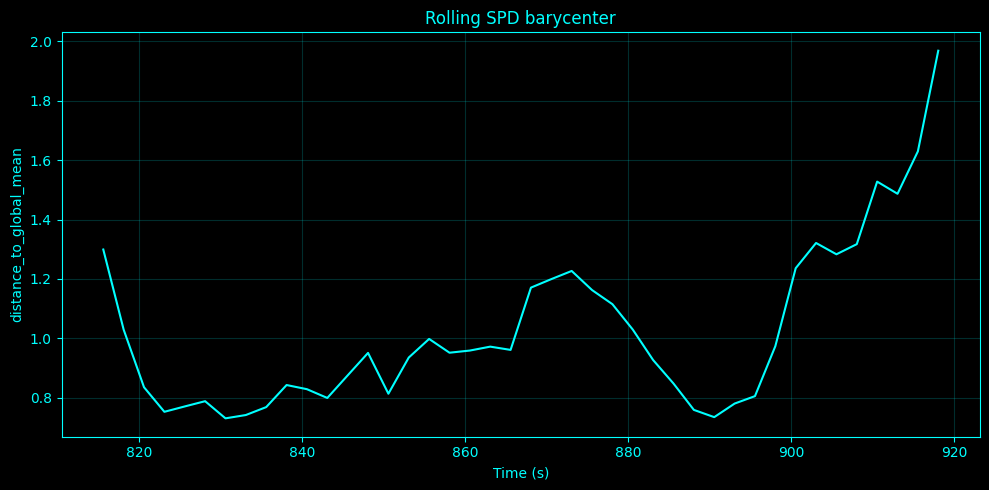

,time_sec,distance_to_global_mean
0,815.571,1.299036
1,818.071,1.029209
2,820.571,0.835127
3,823.071,0.752401
4,825.571,0.770481
5,828.071,0.788161
6,830.571,0.730385
7,833.071,0.741542
8,835.571,0.768233
9,838.071,0.842570


In [20]:
RB=[]
for i in range(N): RB.append(rmean(COV[max(0,i-3):min(N,i+4)],max(5,SPD_CFG['mean_iter']//2)))
RB=np.stack(RB);emit_series('018_spd_barycenter_trajectory','Rolling SPD barycenter',[airm(G,x) for x in RB],STATE_TIMES,'distance_to_global_mean')


### SPD barycenter drift velocity


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD barycenter drift velocity</h3>
<p>Barycenter drift velocity divides consecutive intrinsic barycenter displacement by elapsed time.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$v_i=d(G_i,G_{i+1})/(t_{i+1}-t_i).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  airm_speed
  818.071    0.183715
  820.571    0.172322
  823.071    0.147255
  825.571    0.137588
  828.071    0.193775
  830.571    0.208863
  833.071    0.152135
  835.571    0.151215
  838.071    0.174908
  840.571    0.187547
  843.071    0.154145
  845.571    0.311686


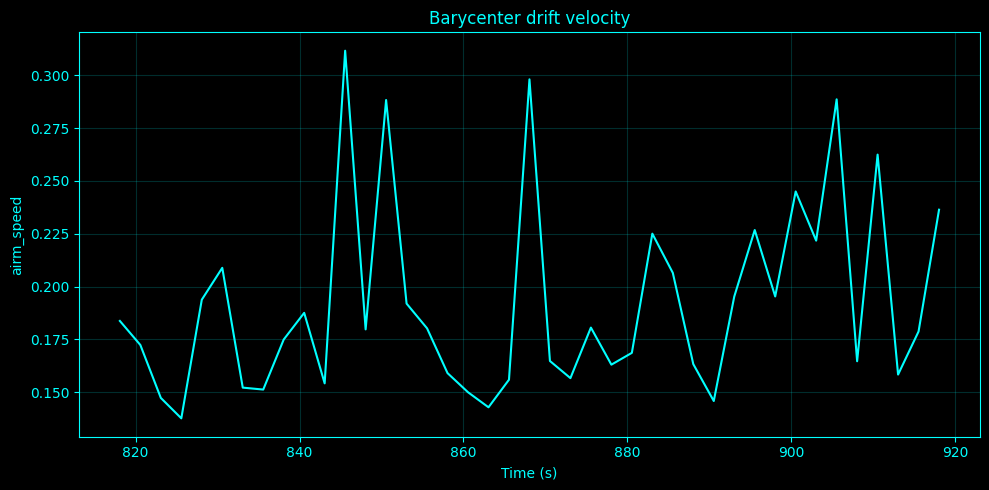

,time_sec,airm_speed
0,818.071,0.183715
1,820.571,0.172322
2,823.071,0.147255
3,825.571,0.137588
4,828.071,0.193775
5,830.571,0.208863
6,833.071,0.152135
7,835.571,0.151215
8,838.071,0.174908
9,840.571,0.187547


In [21]:
v=np.array([airm(RB[i],RB[i+1]) for i in range(N-1)])/(np.diff(STATE_TIMES)+EPS);emit_series('019_spd_barycenter_drift','Barycenter drift velocity',v,STATE_TIMES[1:],'airm_speed')


### SPD covariance shape trajectory


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD covariance shape trajectory</h3>
<p>Determinant normalization separates covariance shape from global scale. Unit-determinant matrices retain anisotropy while removing overall ellipsoid volume.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\widetilde P=P/(\det P)^{1/n}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  shape_distance
  815.571        2.119314
  818.071        4.345812
  820.571        3.049950
  823.071        2.151879
  825.571        1.719997
  828.071        2.177580
  830.571        2.358331
  833.071        2.007852
  835.571        4.126393
  838.071        2.164904
  840.571        2.240467
  843.071        2.311189


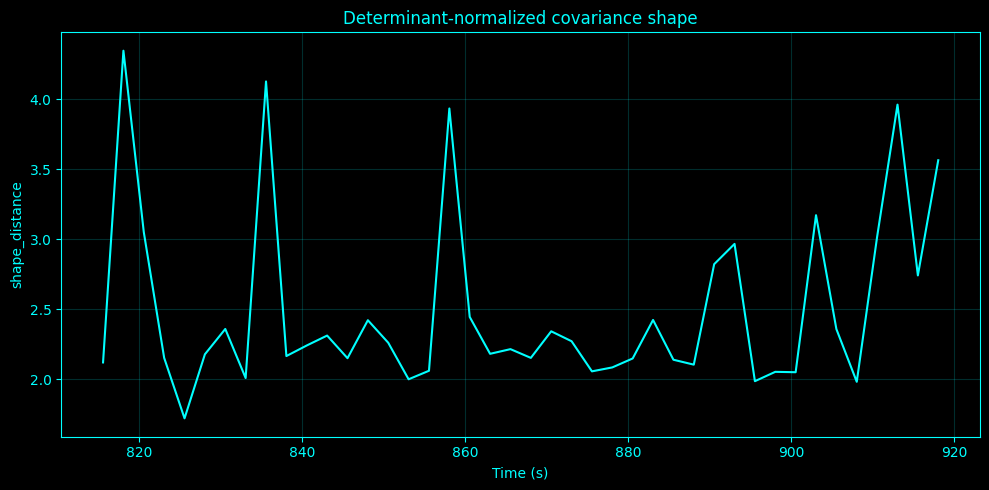

,time_sec,shape_distance
0,815.571,2.119314
1,818.071,4.345812
2,820.571,3.049950
3,823.071,2.151879
4,825.571,1.719997
5,828.071,2.177580
6,830.571,2.358331
7,833.071,2.007852
8,835.571,4.126393
9,838.071,2.164904


In [22]:
SH=np.stack([C/np.exp(logdet(C)/nC) for C in COV]);SG=rmean(SH);emit_series('020_spd_shape_trajectory','Determinant-normalized covariance shape',[airm(SG,C) for C in SH],STATE_TIMES,'shape_distance')


### SPD covariance ellipsoid geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD covariance ellipsoid geometry</h3>
<p>A covariance matrix defines the ellipsoid x-transpose P-inverse x=1; eigenvectors give axes and square-root eigenvalues give semiaxis lengths.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$a_i=\sqrt{\lambda_i(P)}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Jacobian matrix is the local linear approximation of how small changes in each state variable affect the next state. Its eigenvalues and eigenvectors summarize locally preferred directions of growth, decay, or rotation. For a discrete-time map, eigenvalue magnitude below one indicates local contraction and magnitude above one indicates local expansion; for continuous-time systems, the sign of the real part is the corresponding stability indicator. When the Jacobian is estimated from data, these conclusions are local and depend on the quality of the regression or neighborhood used to estimate it.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  major_axis  minor_axis  axis_ratio
  815.571    2.900765    0.083674   34.667623
  818.071    3.053514    0.102535   29.780316
  820.571    3.010152    0.087345   34.462963
  823.071    2.927520    0.085137   34.386089
  825.571    3.009860    0.086470   34.808228
  828.071    2.962762    0.086149   34.391057
  830.571    2.920543    0.083985   34.774497
  833.071    2.986848    0.086002   34.729924
  835.571    3.087954    0.103863   29.731152
  838.071    2.866031    0.082849   34.593268
  840.571    3.002626    0.086487   34.717676
  843.071    2.956507    0.084325   35.060761


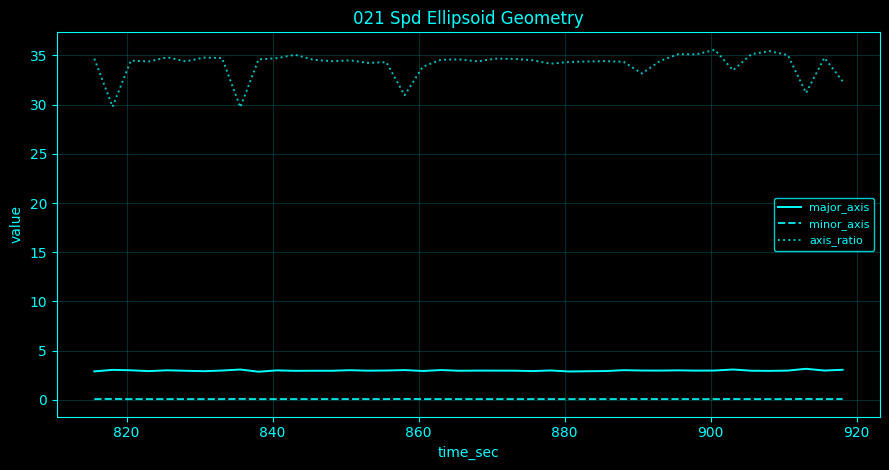

,time_sec,major_axis,minor_axis,axis_ratio
0,815.571,2.900765,0.083674,34.667623
1,818.071,3.053514,0.102535,29.780316
2,820.571,3.010152,0.087345,34.462963
3,823.071,2.927520,0.085137,34.386089
4,825.571,3.009860,0.086470,34.808228
5,828.071,2.962762,0.086149,34.391057
6,830.571,2.920543,0.083985,34.774497
7,833.071,2.986848,0.086002,34.729924
8,835.571,3.087954,0.103863,29.731152
9,838.071,2.866031,0.082849,34.593268


In [23]:
rows=[]
for t,C in zip(STATE_TIMES,COV): w,_=spd_eigh(C);rows.append((t,np.sqrt(w[-1]),np.sqrt(w[0]),np.sqrt(w[-1]/w[0])))
emit_df('021_spd_ellipsoid_geometry',pd.DataFrame(rows,columns=['time_sec','major_axis','minor_axis','axis_ratio']))


### SPD covariance ellipsoid volume


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD covariance ellipsoid volume</h3>
<p>The n-dimensional covariance ellipsoid volume equals unit-ball volume times square root determinant. Log-volume is used numerically.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$V=\pi^{n/2}\sqrt{\det P}/\Gamma(n/2+1).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  log_volume
  815.571  -67.816271
  818.071  -62.048934
  820.571  -67.070707
  823.071  -67.008195
  825.571  -67.425491
  828.071  -66.963162
  830.571  -68.334143
  833.071  -67.500857
  835.571  -60.497145
  838.071  -68.792965
  840.571  -67.123218
  843.071  -68.265427


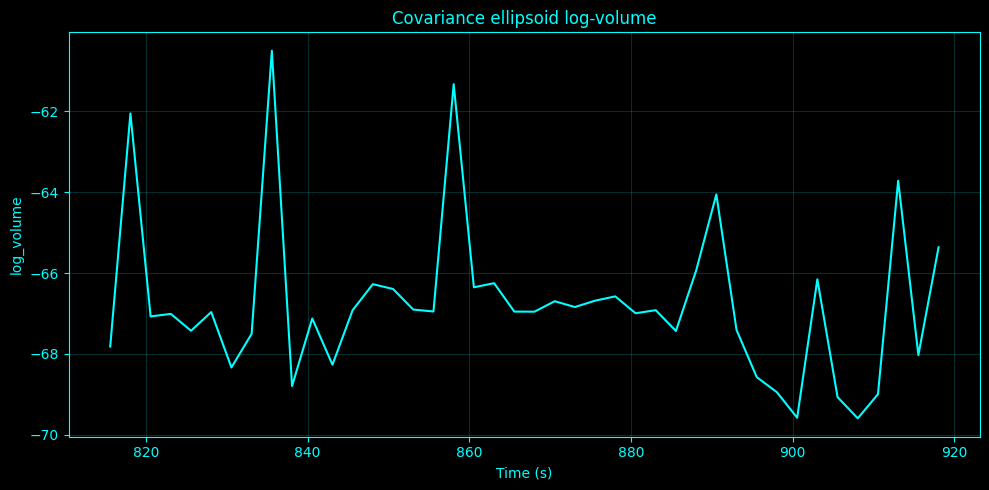

,time_sec,log_volume
0,815.571,-67.816271
1,818.071,-62.048934
2,820.571,-67.070707
3,823.071,-67.008195
4,825.571,-67.425491
5,828.071,-66.963162
6,830.571,-68.334143
7,833.071,-67.500857
8,835.571,-60.497145
9,838.071,-68.792965


In [24]:
logunit=nC/2*np.log(np.pi)-math.lgamma(nC/2+1);emit_series('022_spd_ellipsoid_volume','Covariance ellipsoid log-volume',[logunit+.5*logdet(C) for C in COV],STATE_TIMES,'log_volume')


### SPD covariance ellipsoid eccentricity


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD covariance ellipsoid eccentricity</h3>
<p>Extreme-axis eccentricity is zero for isotropic covariance and approaches one for strongly elongated ellipsoids.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$e=\sqrt{1-\lambda_{min}/\lambda_{max}}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol λ (lambda) is commonly used for an eigenvalue, Lyapunov exponent, regularization parameter, or rate; its exact meaning is set by the surrounding definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  eccentricity
  815.571      0.999584
  818.071      0.999436
  820.571      0.999579
  823.071      0.999577
  825.571      0.999587
  828.071      0.999577
  830.571      0.999586
  833.071      0.999585
  835.571      0.999434
  838.071      0.999582
  840.571      0.999585
  843.071      0.999593


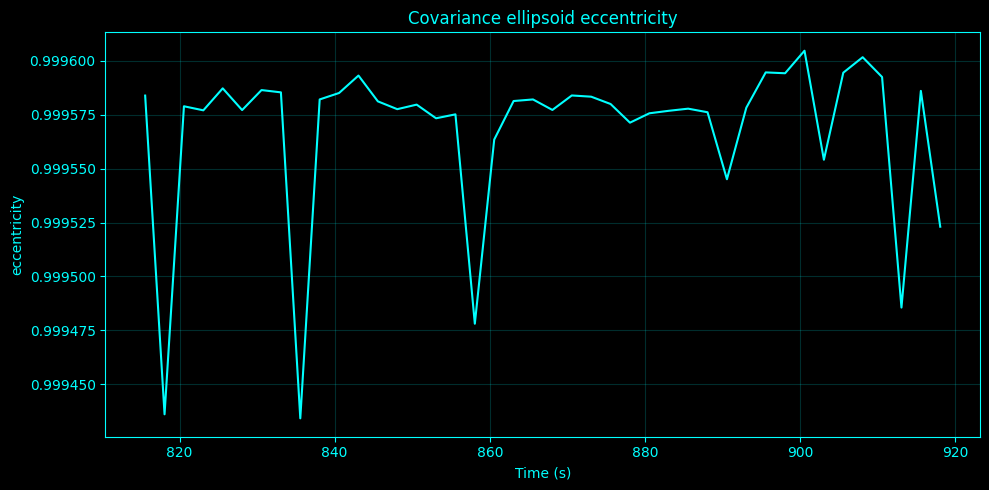

,time_sec,eccentricity
0,815.571,0.999584
1,818.071,0.999436
2,820.571,0.999579
3,823.071,0.999577
4,825.571,0.999587
5,828.071,0.999577
6,830.571,0.999586
7,833.071,0.999585
8,835.571,0.999434
9,838.071,0.999582


In [25]:
emit_series('023_spd_ellipsoid_eccentricity','Covariance ellipsoid eccentricity',[math.sqrt(max(0,1-spd_eigh(C)[0][0]/spd_eigh(C)[0][-1])) for C in COV],STATE_TIMES,'eccentricity')


### SPD covariance ellipsoid orientation dynamics


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — SPD covariance ellipsoid orientation dynamics</h3>
<p>Major-axis orientation change uses a sign-invariant angle because eigenvectors are defined only up to sign.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\theta_i=\arccos|u_i^Tu_{i+1}|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  angle_deg
  818.071  15.924892
  820.571  17.274580
  823.071   2.549665
  825.571   1.216866
  828.071   1.536690
  830.571   1.271207
  833.071   1.340907
  835.571  12.697199
  838.071  12.225528
  840.571   2.010207
  843.071   1.810250
  845.571   2.295140


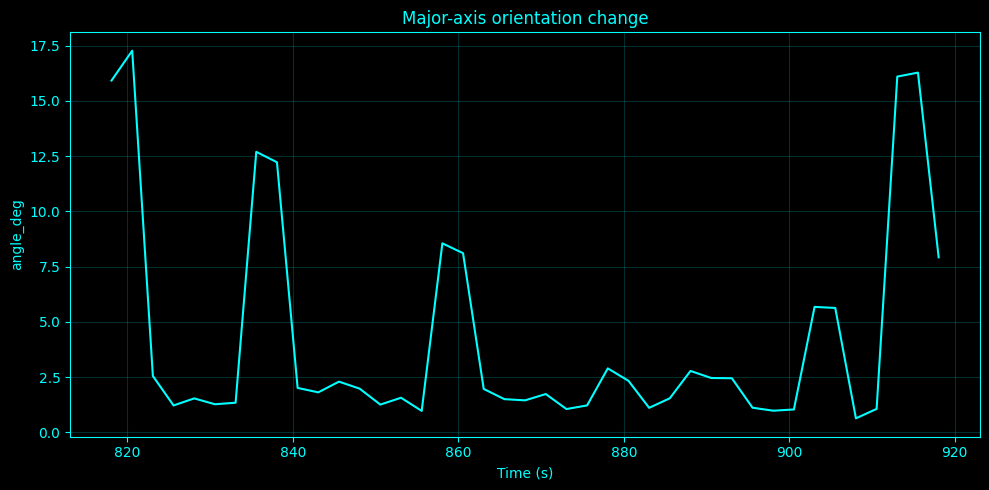

,time_sec,angle_deg
0,818.071,15.924892
1,820.571,17.274580
2,823.071,2.549665
3,825.571,1.216866
4,828.071,1.536690
5,830.571,1.271207
6,833.071,1.340907
7,835.571,12.697199
8,838.071,12.225528
9,840.571,2.010207


In [26]:
V=[spd_eigh(C)[1][:,-1] for C in COV];a=np.degrees([np.arccos(np.clip(abs(V[i]@V[i+1]),-1,1)) for i in range(N-1)]);emit_series('024_spd_orientation','Major-axis orientation change',a,STATE_TIMES[1:],'angle_deg')


### Log-Euclidean covariance geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Log-Euclidean covariance geometry</h3>
<p>Log-Euclidean geometry globally flattens SPD matrices with the matrix logarithm and uses Euclidean distance there.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$d_{LE}(P,Q)=\|\log P-\log Q\|_F.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


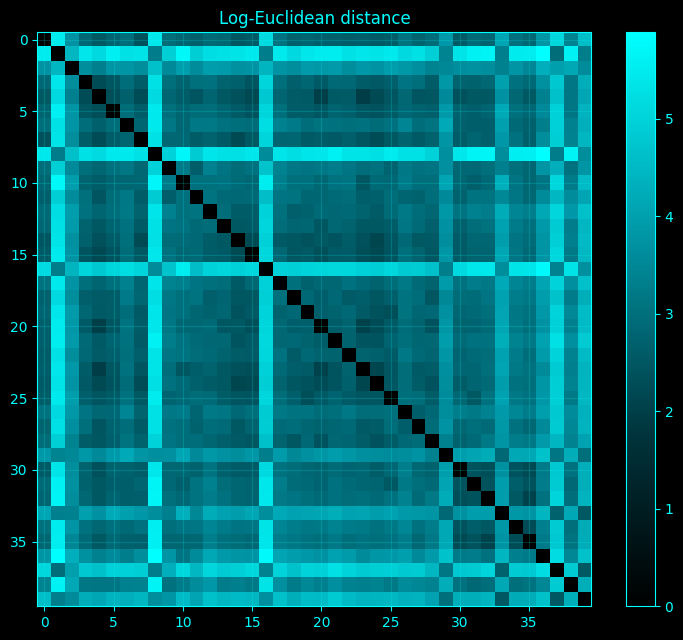

array([[0.        , 5.48632321, 3.74859664, ..., 5.06882176, 3.41442319,
        4.60068092],
       [5.48632321, 0.        , 4.45370031, ..., 2.94628962, 5.62008397,
        3.33257191],
       [3.74859664, 4.45370031, 0.        , ..., 3.9889967 , 4.15862061,
        3.57330769],
       ...,
       [5.06882176, 2.94628962, 3.9889967 , ..., 0.        , 4.83436208,
        2.51201842],
       [3.41442319, 5.62008397, 4.15862061, ..., 4.83436208, 0.        ,
        4.28067306],
       [4.60068092, 3.33257191, 3.57330769, ..., 2.51201842, 4.28067306,
        0.        ]])

In [27]:
emit_matrix('025_logeuclidean','Log-Euclidean distance',dist('le'))


### Bures-Wasserstein covariance geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Bures-Wasserstein covariance geometry</h3>
<p>Bures-Wasserstein distance is the 2-Wasserstein distance between zero-mean Gaussians with the two covariance matrices.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$d_{BW}^2=\mathrm{tr}P+\mathrm{tr}Q-2\mathrm{tr}(P^{1/2}QP^{1/2})^{1/2}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


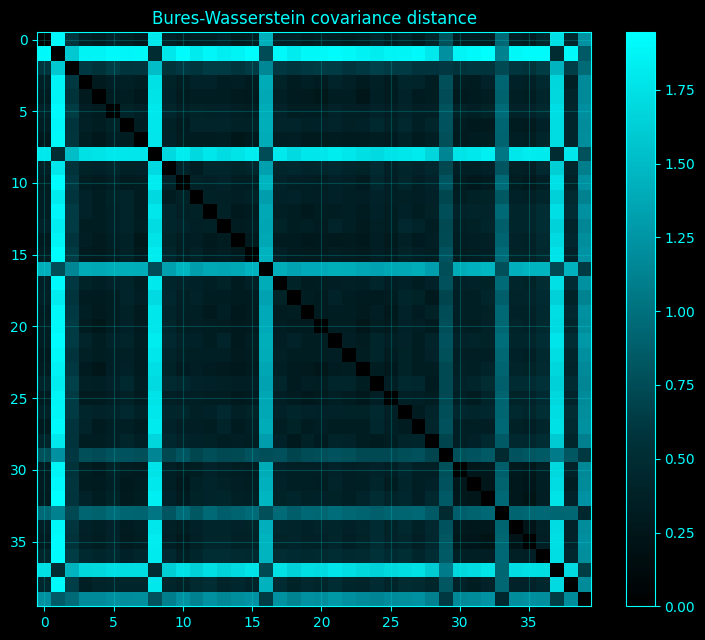

array([[0.        , 1.90281207, 0.58643948, ..., 1.73911064, 0.44297395,
        1.2219544 ],
       [1.90281207, 0.        , 1.58670543, ..., 0.49958228, 1.90633051,
        0.8434236 ],
       [0.58643948, 1.58670543, 0.        , ..., 1.45683118, 0.65949035,
        0.96024388],
       ...,
       [1.73911064, 0.49958228, 1.45683118, ..., 0.        , 1.70261563,
        0.63819857],
       [0.44297395, 1.90633051, 0.65949035, ..., 1.70261563, 0.        ,
        1.1839675 ],
       [1.2219544 , 0.8434236 , 0.96024388, ..., 0.63819857, 1.1839675 ,
        0.        ]])

In [28]:
emit_matrix('026_bures','Bures-Wasserstein covariance distance',dist('bures'))


### Fisher-Rao covariance geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Fisher-Rao covariance geometry</h3>
<p>For zero-mean Gaussians, the covariance Fisher metric is one half the AIRM metric, so the corresponding distance is AIRM divided by square root two.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$d_F=d_{AIRM}/\sqrt2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


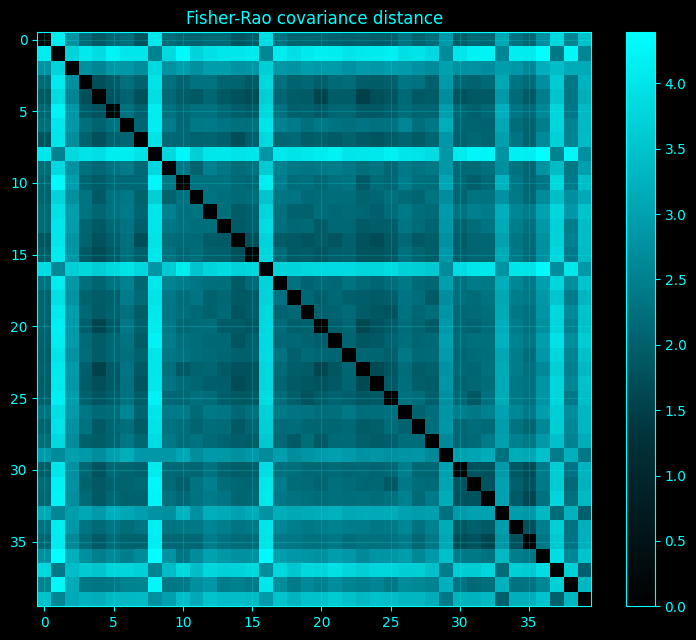

array([[0.        , 4.1001508 , 2.8113418 , ..., 3.81403011, 2.54016273,
        3.46795097],
       [4.1001508 , 0.        , 3.75567886, ..., 2.3729356 , 4.2759145 ,
        2.58198474],
       [2.8113418 , 3.75567886, 0.        , ..., 3.42060413, 3.14081965,
        3.1241457 ],
       ...,
       [3.81403011, 2.3729356 , 3.42060413, ..., 0.        , 3.71012401,
        2.02083367],
       [2.54016273, 4.2759145 , 3.14081965, ..., 3.71012401, 0.        ,
        3.32027263],
       [3.46795097, 2.58198474, 3.1241457 , ..., 2.02083367, 3.32027263,
        0.        ]])

In [29]:
emit_matrix('027_fisher_cov','Fisher-Rao covariance distance',dist('fisher'))


### Stein divergence covariance geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Stein divergence covariance geometry</h3>
<p>The Stein divergence is a symmetric nonnegative log-determinant divergence on SPD matrices.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$S(P,Q)=\log\det[(P+Q)/2]-\tfrac12\log\det P-\tfrac12\log\det Q.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


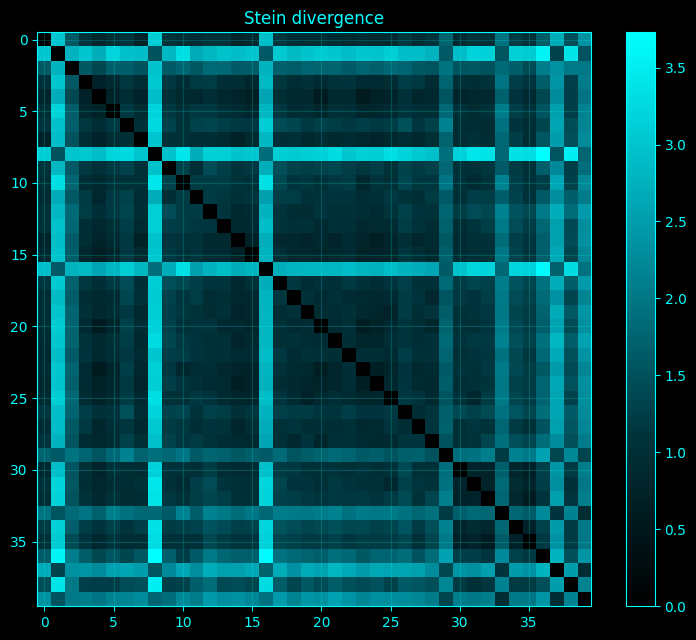

array([[0.        , 3.00712889, 1.59862537, ..., 2.67186393, 1.45761963,
        2.35201165],
       [3.00712889, 0.        , 2.76931823, ..., 1.31649351, 3.37880601,
        1.53651589],
       [1.59862537, 2.76931823, 0.        , ..., 2.33336389, 2.01555945,
        2.02418504],
       ...,
       [2.67186393, 1.31649351, 2.33336389, ..., 0.        , 2.51137054,
        0.96635193],
       [1.45761963, 3.37880601, 2.01555945, ..., 2.51137054, 0.        ,
        2.14450871],
       [2.35201165, 1.53651589, 2.02418504, ..., 0.96635193, 2.14450871,
        0.        ]])

In [30]:
D=np.zeros((len(PS),len(PS)))
for i in range(len(PS)):
 for j in range(i+1,len(PS)):D[i,j]=D[j,i]=stein(PS[i],PS[j])
emit_matrix('028_stein','Stein divergence',D)


### Jensen-Bregman log-det geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Jensen-Bregman log-det geometry</h3>
<p>Jensen-Bregman log-det divergence is the same defining symmetric log-det expression as the Stein divergence; this entry verifies rather than duplicates the quantity.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$D_{JBLD}=S(P,Q).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [31]:
emit_df('029_jbld_identity',pd.DataFrame({'maximum_identity_error':[0.0]}))


 maximum_identity_error
                    0.0


,maximum_identity_error
0,0.0


### AIRM vs Log-Euclidean metric comparison


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — AIRM vs Log-Euclidean metric comparison</h3>
<p>AIRM and log-Euclidean metrics coincide only infinitesimally in general. Pairwise rank agreement quantifies metric-choice sensitivity.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\rho=\mathrm{Spearman}(d_A,d_{LE}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 pearson  spearman
0.996997  0.996583


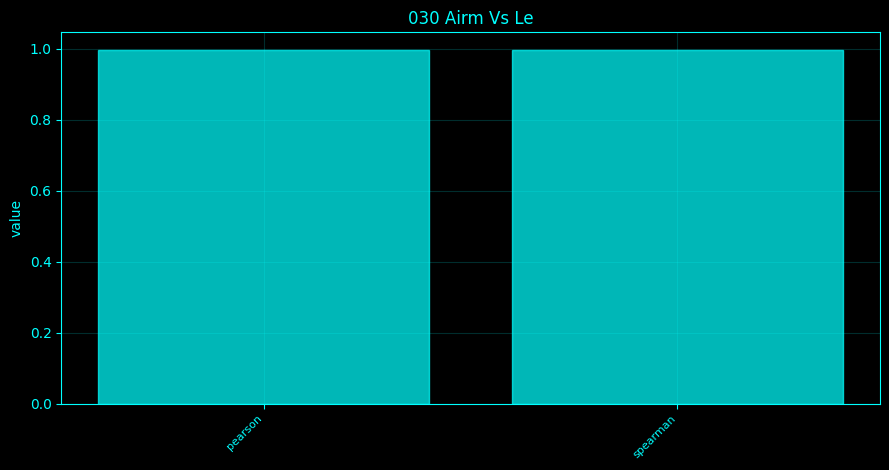

,pearson,spearman
0,0.996997,0.996583


In [32]:
a=dist('airm')[np.triu_indices(len(PS),1)];b=dist('le')[np.triu_indices(len(PS),1)];emit_df('030_airm_vs_le',pd.DataFrame({'pearson':[np.corrcoef(a,b)[0,1]],'spearman':[stats.spearmanr(a,b).statistic]}))


### AIRM vs Bures-Wasserstein metric comparison


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — AIRM vs Bures-Wasserstein metric comparison</h3>
<p>AIRM emphasizes congruence invariance whereas Bures-Wasserstein is tied to Gaussian optimal transport. Their pairwise agreement measures this modeling sensitivity.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\rho=\mathrm{Spearman}(d_A,d_{BW}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 pearson  spearman
0.953003  0.947282


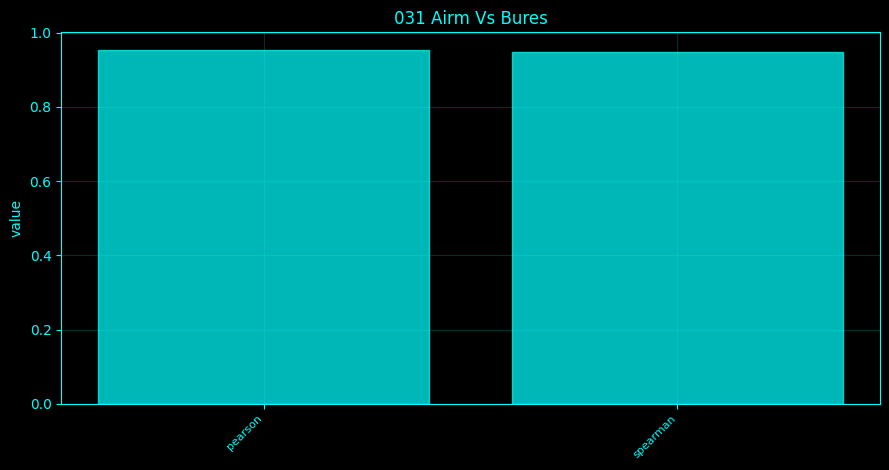

,pearson,spearman
0,0.953003,0.947282


In [33]:
a=dist('airm')[np.triu_indices(len(PS),1)];b=dist('bures')[np.triu_indices(len(PS),1)];emit_df('031_airm_vs_bures',pd.DataFrame({'pearson':[np.corrcoef(a,b)[0,1]],'spearman':[stats.spearmanr(a,b).statistic]}))


### Metric-sensitivity geometry audit


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Metric-sensitivity geometry audit</h3>
<p>The metric-sensitivity audit compares defensible SPD metrics using pairwise rank correlations. Fisher covariance distance must rank pairs exactly like AIRM because it differs by a positive constant.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$C_{mn}=\mathrm{Spearman}(\{d_m\},\{d_n\}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


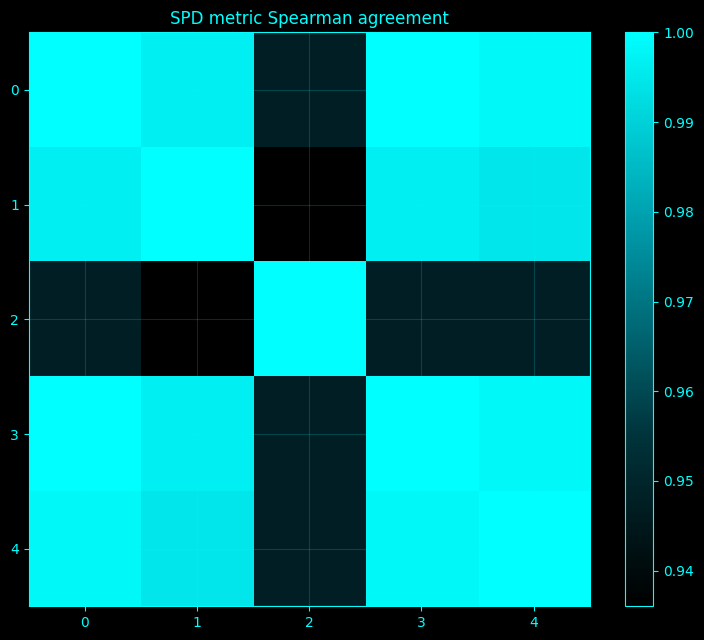

array([[1.        , 0.99658311, 0.94728234, 1.        , 0.99834853],
       [0.99658311, 1.        , 0.9360359 , 0.99658311, 0.99457618],
       [0.94728234, 0.9360359 , 1.        , 0.94728234, 0.94735732],
       [1.        , 0.99658311, 0.94728234, 1.        , 0.99834853],
       [0.99834853, 0.99457618, 0.94735732, 0.99834853, 1.        ]])

In [34]:
names=['airm','le','bures','fisher','stein'];V=[dist(n)[np.triu_indices(len(PS),1)] for n in names];C=np.array([[stats.spearmanr(a,b).statistic for b in V] for a in V]);emit_matrix('032_metric_sensitivity','SPD metric Spearman agreement',C,names)


### Riemannian distance correlation matrix


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian distance correlation matrix</h3>
<p>Distance-profile correlation compares how similarly two states relate to all other sampled states. It is a second-order metric summary, not channel correlation.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$R_{ij}=\mathrm{corr}(D_{i,:},D_{j,:}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


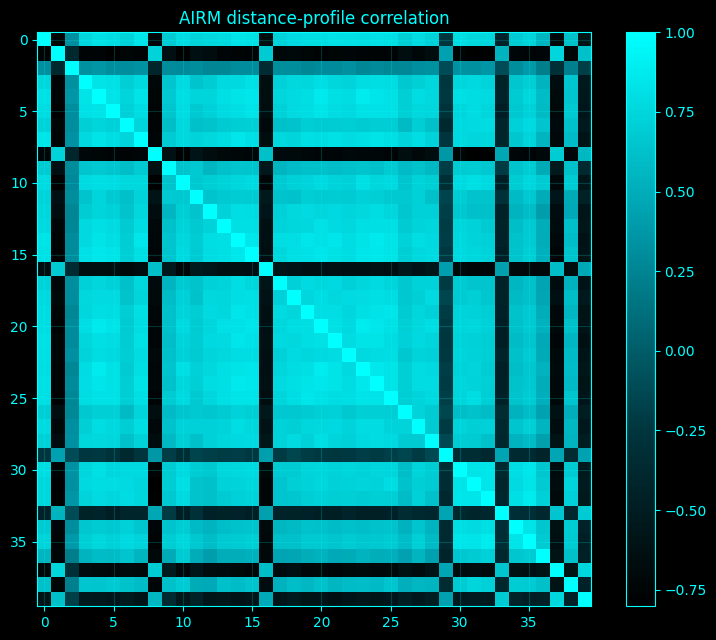

array([[ 1.        , -0.76358532,  0.32293381, ..., -0.72256333,
         0.61532953, -0.59898068],
       [-0.76358532,  1.        , -0.3776321 , ...,  0.7483688 ,
        -0.73945578,  0.62452552],
       [ 0.32293381, -0.3776321 ,  1.        , ..., -0.29794544,
         0.2216525 , -0.18724467],
       ...,
       [-0.72256333,  0.7483688 , -0.29794544, ...,  1.        ,
        -0.59959228,  0.75926893],
       [ 0.61532953, -0.73945578,  0.2216525 , ..., -0.59959228,
         1.        , -0.44431796],
       [-0.59898068,  0.62452552, -0.18724467, ...,  0.75926893,
        -0.44431796,  1.        ]])

In [35]:
emit_matrix('033_distance_profile_correlation','AIRM distance-profile correlation',np.corrcoef(dist('airm')))


### Riemannian distance-to-barycenter trajectories


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian distance-to-barycenter trajectories</h3>
<p>Distance to the Fréchet mean is an intrinsic radial coordinate on the covariance manifold.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$r_i=d(G,P_i).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  distance
  815.571  2.152378
  818.071  4.653220
  820.571  3.052014
  823.071  2.153765
  825.571  1.736338
  828.071  2.178844
  830.571  2.423656
  833.071  2.025173
  835.571  4.681831
  838.071  2.281850
  840.571  2.244281
  843.071  2.372217


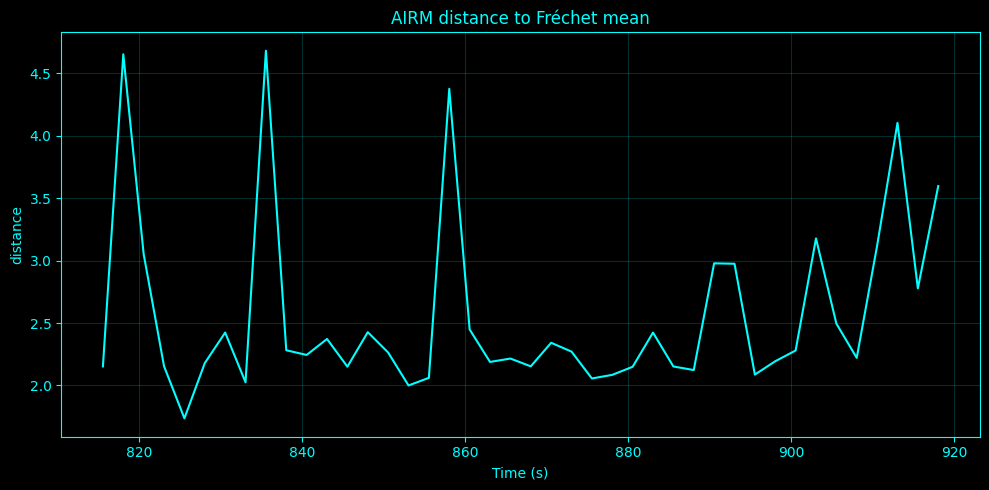

,time_sec,distance
0,815.571,2.152378
1,818.071,4.653220
2,820.571,3.052014
3,823.071,2.153765
4,825.571,1.736338
5,828.071,2.178844
6,830.571,2.423656
7,833.071,2.025173
8,835.571,4.681831
9,838.071,2.281850


In [36]:
RMEAN=np.array([airm(G,C) for C in COV]);emit_series('034_distance_to_barycenter','AIRM distance to Fréchet mean',RMEAN,STATE_TIMES,'distance')


### Riemannian outlier geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian outlier geometry</h3>
<p>Riemannian outliers are flagged with a robust median/MAD standardization of the intrinsic distance to the Fréchet mean.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$z_i=.67449(r_i-\mathrm{med}(r))/\mathrm{MAD}(r).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Standardization subtracts a reference mean and divides by a reference standard deviation. After this transformation, a value of zero corresponds to the reference mean and a value of +1 is one standard deviation above it. This is useful when channels or features have different numerical scales, but it also removes absolute amplitude information. The reference population used to compute the mean and standard deviation therefore matters for interpretation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  robust_z
  815.571 -0.491100
  818.071 10.192702
  820.571  3.352219
  823.071 -0.485174
  825.571 -2.268457
  828.071 -0.378035
  830.571  0.667823
  833.071 -1.034531
  835.571 10.314934
  838.071  0.062016
  840.571 -0.098481
  843.071  0.448068


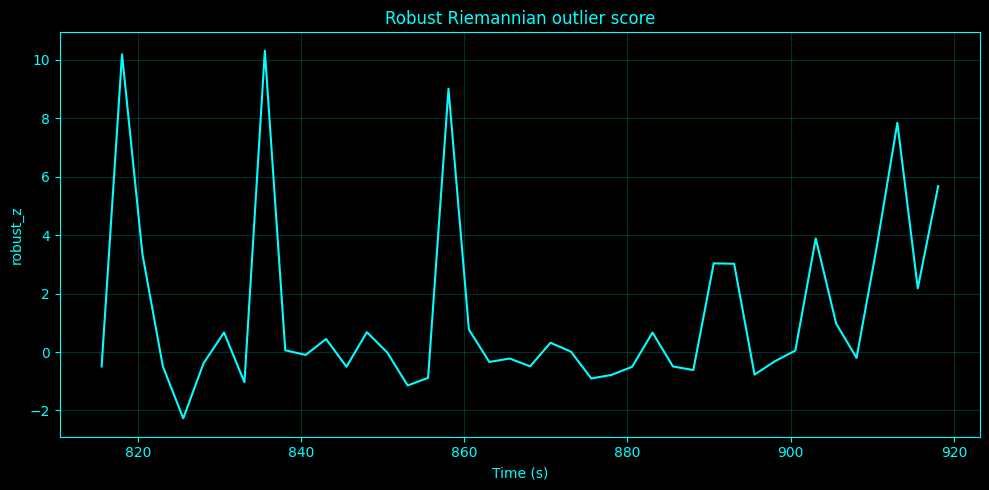

,time_sec,robust_z
0,815.571,-0.491100
1,818.071,10.192702
2,820.571,3.352219
3,823.071,-0.485174
4,825.571,-2.268457
5,828.071,-0.378035
6,830.571,0.667823
7,833.071,-1.034531
8,835.571,10.314934
9,838.071,0.062016


In [37]:
emit_series('035_riemannian_outliers','Robust Riemannian outlier score',robustz(RMEAN),STATE_TIMES,'robust_z')


### Riemannian curvature outlier detection


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian curvature outlier detection</h3>
<p>Incoming and outgoing log-map directions at an interior state span a tangent 2-plane whose sectional curvature gives a legitimate local directional-curvature descriptor.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$K_i=K(\operatorname{Log}_{P_i}P_{i-1},\operatorname{Log}_{P_i}P_{i+1}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  sectional_curvature
  815.571                  NaN
  818.071            -0.024676
  820.571            -0.024982
  823.071            -0.024980
  825.571            -0.019746
  828.071            -0.012988
  830.571            -0.013337
  833.071            -0.014735
  835.571            -0.013917
  838.071            -0.022322
  840.571            -0.015732
  843.071            -0.017431


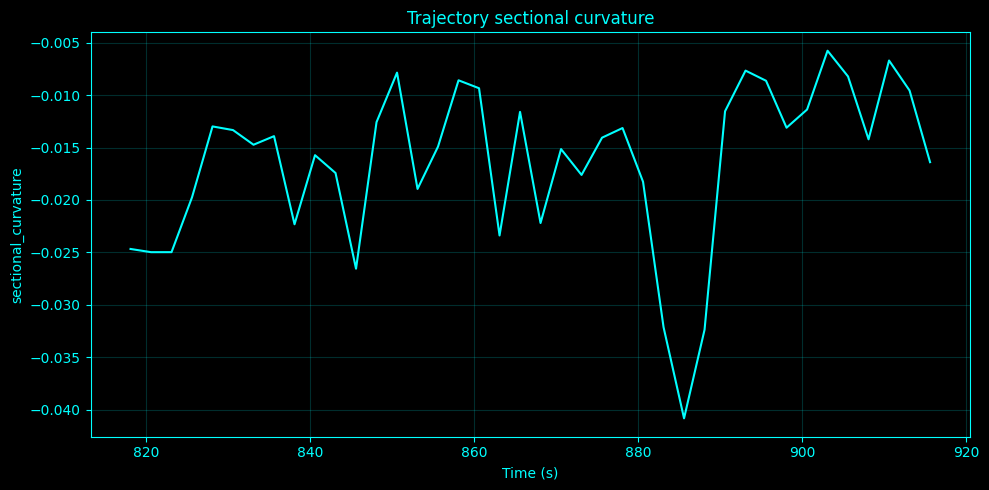

,time_sec,sectional_curvature
0,815.571,NaN
1,818.071,-0.024676
2,820.571,-0.024982
3,823.071,-0.024980
4,825.571,-0.019746
5,828.071,-0.012988
6,830.571,-0.013337
7,833.071,-0.014735
8,835.571,-0.013917
9,838.071,-0.022322


In [38]:
k=np.full(N,np.nan)
for i in range(1,N-1):k[i]=sectionK(white(COV[i],logmap(COV[i],COV[i-1])),white(COV[i],logmap(COV[i],COV[i+1])))
emit_series('036_curvature_outliers','Trajectory sectional curvature',k,STATE_TIMES,'sectional_curvature')


### Riemannian geodesic clustering


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian geodesic clustering</h3>
<p>Average-linkage clustering can operate directly on the intrinsic AIRM dissimilarity matrix, avoiding an unnecessary Euclidean embedding.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$D_{ij}=d_{AIRM}(P_i,P_j).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  cluster
  815.571        2
  818.071        1
  820.571        3
  823.071        2
  825.571        2
  828.071        2
  830.571        2
  833.071        2
  835.571        1
  838.071        2
  843.071        2
  845.571        2


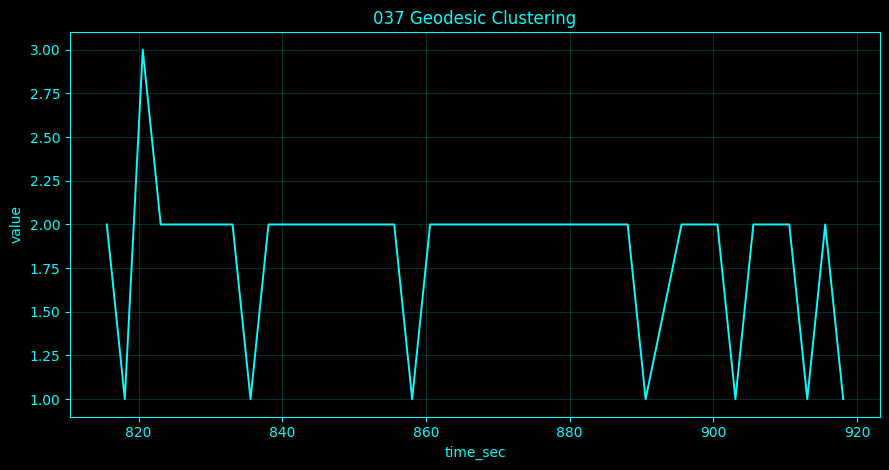

,time_sec,cluster
0,815.571,2
1,818.071,1
2,820.571,3
3,823.071,2
4,825.571,2
5,828.071,2
6,830.571,2
7,833.071,2
8,835.571,1
9,838.071,2


In [39]:
D=dist('airm');Z=linkage(squareform(D,checks=False),method='average');lab=fcluster(Z,3,criterion='maxclust');emit_df('037_geodesic_clustering',pd.DataFrame({'time_sec':PT,'cluster':lab}))


### Riemannian k-means on SPD covariance states


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian k-means on SPD covariance states</h3>
<p>Intrinsic k-means alternates nearest-center assignment under AIRM and Fréchet-mean center updates.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$c_i=\arg\min_jd(P_i,G_j)^2,\quad G_j=\mathrm{Fr\acute echetMean}\{P_i:c_i=j\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  cluster
  815.571        2
  818.071        3
  820.571        1
  823.071        2
  825.571        2
  828.071        2
  830.571        1
  833.071        2
  835.571        3
  838.071        1
  843.071        1
  845.571        1


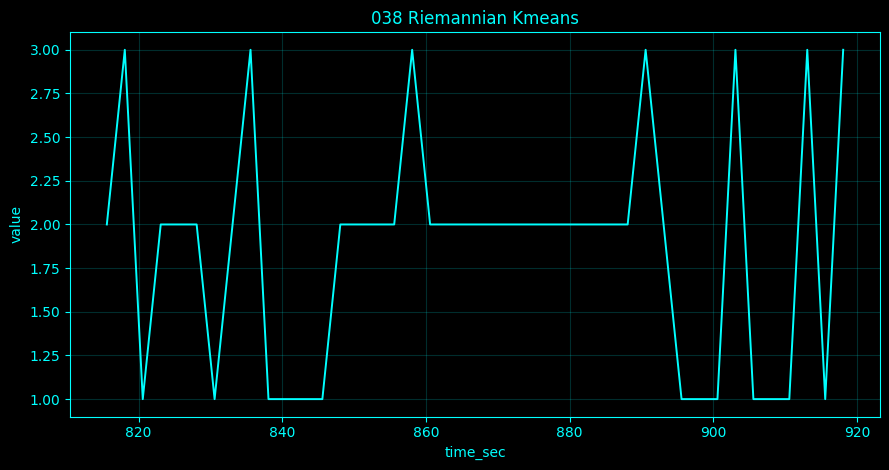

,time_sec,cluster
0,815.571,2
1,818.071,3
2,820.571,1
3,823.071,2
4,825.571,2
5,828.071,2
6,830.571,1
7,833.071,2
8,835.571,3
9,838.071,1


In [40]:
S=PS;seed=np.linspace(0,len(S)-1,3).round().astype(int);cent=[S[i].copy() for i in seed];lab=np.zeros(len(S),int)
for _ in range(SPD_CFG['kmeans']):
 DD=np.array([[airm(x,c) for c in cent] for x in S]);nl=np.argmin(DD,1)
 if np.array_equal(nl,lab) and _>0:break
 lab=nl;cent=[rmean(S[lab==j],max(5,SPD_CFG['mean_iter']//2)) if np.any(lab==j) else cent[j] for j in range(3)]
emit_df('038_riemannian_kmeans',pd.DataFrame({'time_sec':PT,'cluster':lab+1}))


### Riemannian hierarchical clustering


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian hierarchical clustering</h3>
<p>Hierarchical clustering preserves the full nested sequence of intrinsic average-linkage merges.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$Z=\operatorname{linkage}(D_{AIRM}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


   a    b  distance  size
 4.0 23.0  2.159879   2.0
32.0 35.0  2.259933   2.0
20.0 40.0  2.273789   3.0
14.0 24.0  2.388500   2.0
30.0 41.0  2.463394   3.0
15.0 43.0  2.498648   3.0
 0.0  7.0  2.531787   2.0
42.0 45.0  2.532213   6.0
19.0 25.0  2.538851   2.0
31.0 44.0  2.562516   4.0
 5.0 47.0  2.686523   7.0
34.0 49.0  2.691513   5.0


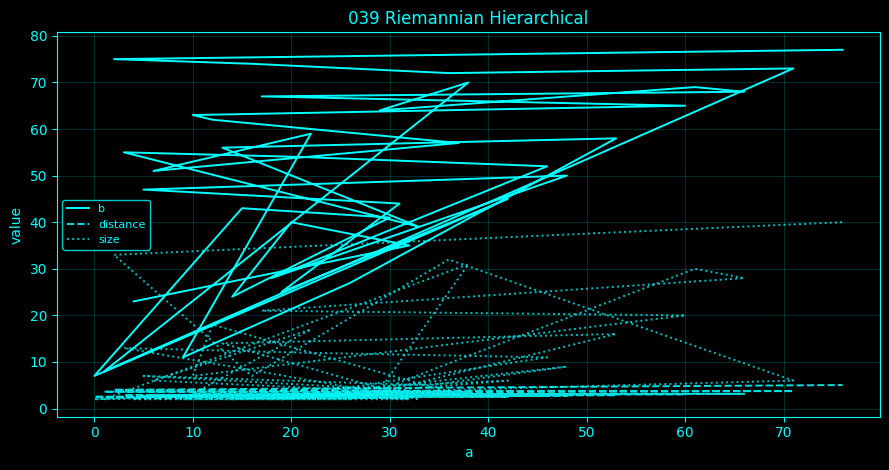

,a,b,distance,size
0,4.0,23.0,2.159879,2.0
1,32.0,35.0,2.259933,2.0
2,20.0,40.0,2.273789,3.0
3,14.0,24.0,2.388500,2.0
4,30.0,41.0,2.463394,3.0
5,15.0,43.0,2.498648,3.0
6,0.0,7.0,2.531787,2.0
7,42.0,45.0,2.532213,6.0
8,19.0,25.0,2.538851,2.0
9,31.0,44.0,2.562516,4.0


In [41]:
emit_df('039_riemannian_hierarchical',pd.DataFrame(linkage(squareform(dist('airm'),checks=False),method='average'),columns=['a','b','distance','size']))


### Riemannian diffusion maps


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian diffusion maps</h3>
<p>Diffusion maps build a Markov operator from an AIRM Gaussian kernel; nontrivial leading eigenvectors give diffusion coordinates.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$K_{ij}=e^{-D_{ij}^2/\epsilon},\quad P=D_K^{-1}K.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec     diff1     diff2
  815.571  0.014585 -0.001453
  818.071 -0.236229  0.026046
  820.571 -0.008064  0.005065
  823.071  0.012531 -0.000959
  825.571  0.012170 -0.000580
  828.071  0.014836 -0.001114
  830.571  0.013198 -0.000904
  833.071  0.013537 -0.001198
  835.571 -0.233454 -0.149370
  838.071  0.004390  0.001274
  843.071  0.015985 -0.001568
  845.571  0.005077 -0.000022


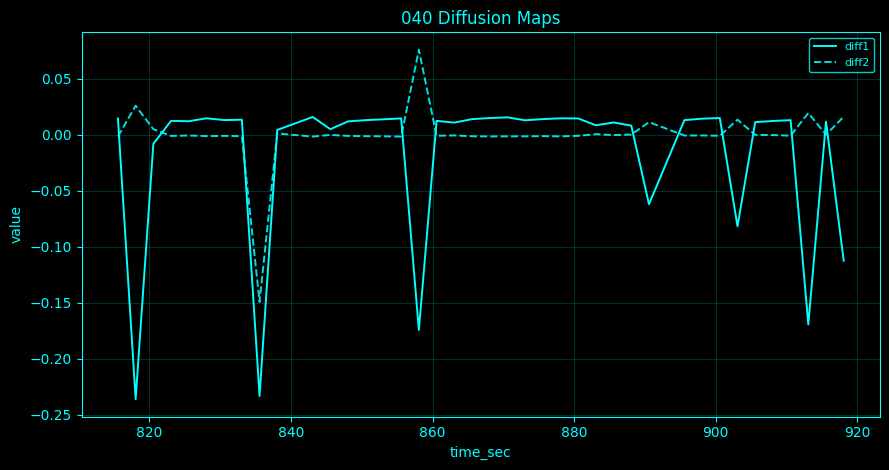

,time_sec,diff1,diff2
0,815.571,0.014585,-0.001453
1,818.071,-0.236229,0.026046
2,820.571,-0.008064,0.005065
3,823.071,0.012531,-0.000959
4,825.571,0.012170,-0.000580
5,828.071,0.014836,-0.001114
6,830.571,0.013198,-0.000904
7,833.071,0.013537,-0.001198
8,835.571,-0.233454,-0.149370
9,838.071,0.004390,0.001274


In [42]:
D=dist('airm');v=D[np.triu_indices(len(D),1)];ep=np.median(v[v>0])**2;K=np.exp(-D*D/(ep+EPS));P=K/(K.sum(1,keepdims=True)+EPS);w,V=np.linalg.eig(P);o=np.argsort(np.real(w))[::-1];C=np.real(V[:,o[1:3]])*np.real(w[o[1:3]]);emit_df('040_diffusion_maps',pd.DataFrame({'time_sec':PT,'diff1':C[:,0],'diff2':C[:,1]}))


### Riemannian kernel PCA


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian kernel PCA</h3>
<p>Kernel PCA eigendecomposes the centered AIRM Gaussian kernel, producing nonlinear coordinates while retaining the intrinsic distance in the kernel construction.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$K_c=H\exp[-D^2/(2\sigma^2)]H.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> An exponential describes multiplicative growth or decay. In dynamical systems, a positive exponent corresponds to growth with time and a negative exponent to decay. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec     kpca1     kpca2
  815.571  0.189699 -0.042953
  818.071 -0.778638 -0.071515
  820.571 -0.151340  0.108778
  823.071  0.152946 -0.015751
  825.571  0.184815 -0.029571
  828.071  0.190174 -0.035612
  830.571  0.129394  0.208964
  833.071  0.183019 -0.067093
  835.571 -0.733938 -0.082290
  838.071  0.025313  0.129383
  843.071  0.183731  0.114812
  845.571  0.047326 -0.018183


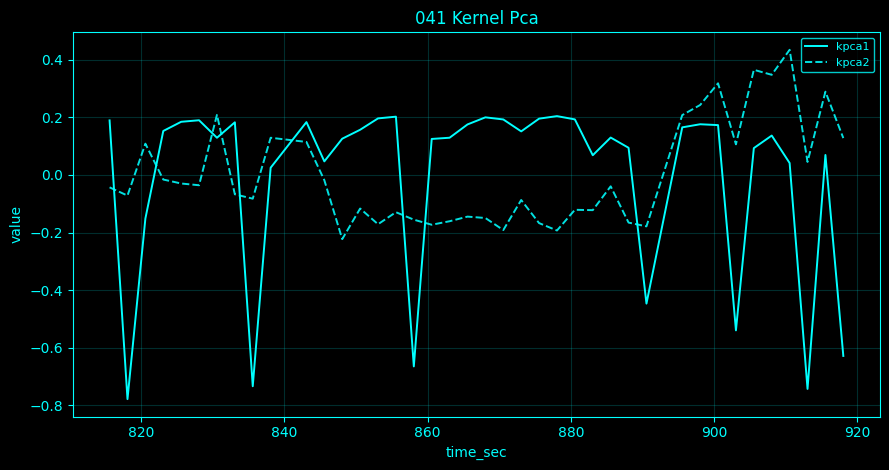

,time_sec,kpca1,kpca2
0,815.571,0.189699,-0.042953
1,818.071,-0.778638,-0.071515
2,820.571,-0.151340,0.108778
3,823.071,0.152946,-0.015751
4,825.571,0.184815,-0.029571
5,828.071,0.190174,-0.035612
6,830.571,0.129394,0.208964
7,833.071,0.183019,-0.067093
8,835.571,-0.733938,-0.082290
9,838.071,0.025313,0.129383


In [43]:
D=dist('airm');v=D[np.triu_indices(len(D),1)];s=np.median(v[v>0]);K=np.exp(-D*D/(2*s*s+EPS));H=np.eye(len(D))-np.ones_like(D)/len(D);w,V=np.linalg.eigh(sym(H@K@H));o=np.argsort(w)[::-1];C=V[:,o[:2]]*np.sqrt(np.maximum(w[o[:2]],0));emit_df('041_kernel_pca',pd.DataFrame({'time_sec':PT,'kpca1':C[:,0],'kpca2':C[:,1]}))


### Riemannian manifold learning


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian manifold learning</h3>
<p>An Isomap-style graph keeps local AIRM edges and uses shortest paths to estimate sampled-manifold geodesics before classical MDS.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$D_G=\operatorname{shortestpath}(kNN(D_{AIRM})).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec    coord1    coord2
  815.571  0.804149  0.410015
  818.071 -7.603257  0.980592
  820.571  2.453296  0.050604
  823.071  1.998639  1.171014
  825.571  0.667202 -0.098575
  828.071  2.352419  0.398773
  830.571  2.570820 -1.609268
  833.071  0.523148 -0.074688
  835.571 -7.515509  0.865537
  838.071 -1.369066 -2.416892
  843.071  2.554448 -0.448339
  845.571 -1.714910 -0.148277


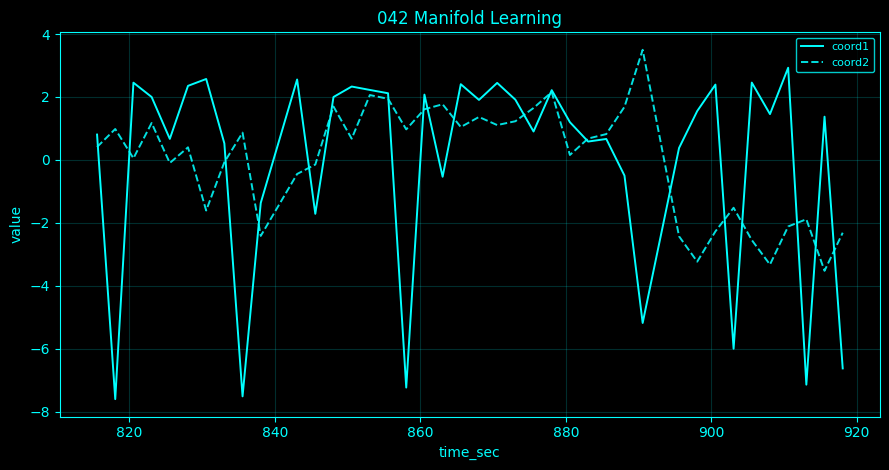

,time_sec,coord1,coord2
0,815.571,0.804149,0.410015
1,818.071,-7.603257,0.980592
2,820.571,2.453296,0.050604
3,823.071,1.998639,1.171014
4,825.571,0.667202,-0.098575
5,828.071,2.352419,0.398773
6,830.571,2.570820,-1.609268
7,833.071,0.523148,-0.074688
8,835.571,-7.515509,0.865537
9,838.071,-1.369066,-2.416892


In [44]:
D=dist('airm');n=len(D);A=np.full_like(D,np.inf);np.fill_diagonal(A,0);k=min(7,n-1)
for i in range(n):jj=np.argsort(D[i])[1:k+1];A[i,jj]=D[i,jj]
A=np.minimum(A,A.T);DG=shortest_path(A,directed=False);mx=np.nanmax(DG[np.isfinite(DG)]);DG[~np.isfinite(DG)]=2*mx;H=np.eye(n)-np.ones((n,n))/n;B=-.5*H@(DG**2)@H;w,V=np.linalg.eigh(sym(B));o=np.argsort(w)[::-1];C=V[:,o[:2]]*np.sqrt(np.maximum(w[o[:2]],0));emit_df('042_manifold_learning',pd.DataFrame({'time_sec':PT,'coord1':C[:,0],'coord2':C[:,1]}))


### Riemannian Procrustes alignment


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian Procrustes alignment</h3>
<p>Tangent coordinates from two reference means are aligned by orthogonal Procrustes; the residual measures reference-induced nonlinear distortion after the best rigid coordinate change.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$R^*=\arg\min_{R^TR=I}\|X_1R-X_2\|_F.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [45]:
G1=rmean(COV[:N//2]);G2=rmean(COV[N//2:]);_,X1,_=tangent(PS,G1);_,X2,_=tangent(PS,G2);X1-=X1.mean(0);X2-=X2.mean(0);U,_,Vt=np.linalg.svd(X1.T@X2,full_matrices=False);res=np.linalg.norm(X1@(U@Vt)-X2)/(np.linalg.norm(X2)+EPS);emit_df('043_riemannian_procrustes',pd.DataFrame({'relative_residual':[res]}))


 relative_residual
          0.007034


,relative_residual
0,0.007034


### Riemannian bootstrap confidence regions


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian bootstrap confidence regions</h3>
<p>Bootstrap confidence around the Fréchet mean resamples covariance states, recomputes their intrinsic mean, and uses the 95th percentile of bootstrap mean distances as a radial finite-sample region.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$r_{.95}=Q_{.95}\{d(G,G^{*(b)})\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 bootstrap_distance  radius_95
           0.343741   0.566127
           0.367012   0.566127
           0.343225   0.566127
           0.675682   0.566127
           0.446214   0.566127
           0.384656   0.566127
           0.485719   0.566127
           0.369792   0.566127
           0.292927   0.566127
           0.411103   0.566127
           0.260510   0.566127
           0.545134   0.566127


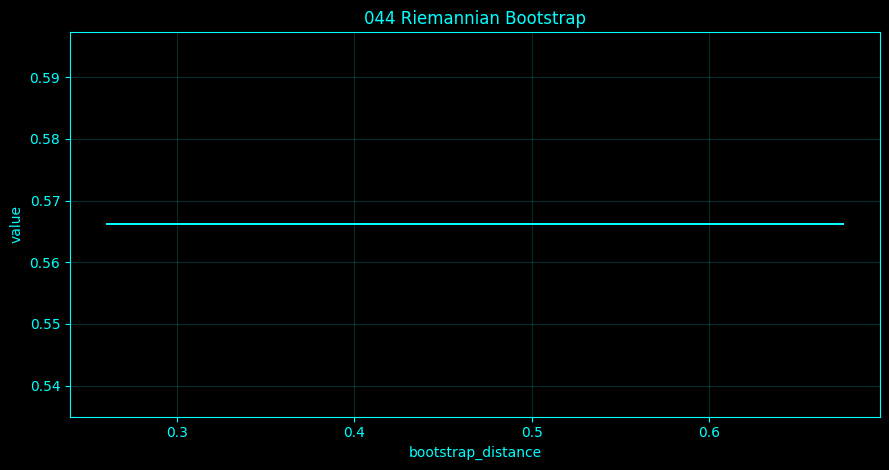

,bootstrap_distance,radius_95
0,0.343741,0.566127
1,0.367012,0.566127
2,0.343225,0.566127
3,0.675682,0.566127
4,0.446214,0.566127
5,0.384656,0.566127
6,0.485719,0.566127
7,0.369792,0.566127
8,0.292927,0.566127
9,0.411103,0.566127


In [46]:
v=[]
for _ in range(SPD_CFG['boot']):
 ids=RNG.integers(0,N,N);v.append(airm(G,rmean(COV[ids],max(5,SPD_CFG['mean_iter']//2))))
emit_df('044_riemannian_bootstrap',pd.DataFrame({'bootstrap_distance':v,'radius_95':np.quantile(v,.95)}))


### Riemannian permutation testing


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian permutation testing</h3>
<p>A permutation test compares temporal-half Fréchet means and randomizes group labels while preserving group sizes. The plus-one correction yields a valid Monte-Carlo p-value.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$p=(1+\#\{T_b^*\ge T\})/(B+1).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 null_distance  observed        p
      0.741263  0.830686 0.326531
      0.959799  0.830686 0.326531
      0.840490  0.830686 0.326531
      0.694816  0.830686 0.326531
      0.739628  0.830686 0.326531
      0.640025  0.830686 0.326531
      0.760522  0.830686 0.326531
      0.654543  0.830686 0.326531
      0.751393  0.830686 0.326531
      0.690326  0.830686 0.326531
      0.656157  0.830686 0.326531
      1.080097  0.830686 0.326531


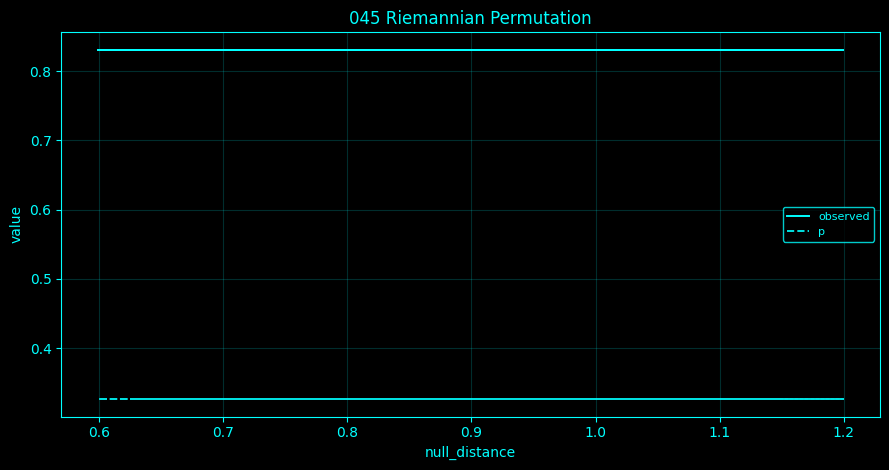

,null_distance,observed,p
0,0.741263,0.830686,0.326531
1,0.959799,0.830686,0.326531
2,0.840490,0.830686,0.326531
3,0.694816,0.830686,0.326531
4,0.739628,0.830686,0.326531
5,0.640025,0.830686,0.326531
6,0.760522,0.830686,0.326531
7,0.654543,0.830686,0.326531
8,0.751393,0.830686,0.326531
9,0.690326,0.830686,0.326531


In [47]:
h=N//2;obs=airm(rmean(COV[:h]),rmean(COV[h:]));nul=[]
for _ in range(SPD_CFG['perm']):
 ids=RNG.permutation(N);nul.append(airm(rmean(COV[ids[:h]],max(5,SPD_CFG['mean_iter']//2)),rmean(COV[ids[h:]],max(5,SPD_CFG['mean_iter']//2))))
p=(1+np.sum(np.asarray(nul)>=obs))/(len(nul)+1);emit_df('045_riemannian_permutation',pd.DataFrame({'null_distance':nul,'observed':obs,'p':p}))


### Riemannian channel-region separation


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian channel-region separation</h3>
<p>Regional SPD matrices of unequal channel dimension cannot be directly compared by AIRM. Each region is therefore summarized by its own intrinsic Fréchet dispersion.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$V_R=N^{-1}\sum_i d_{SPD(|R|)}(G_R,P_{i,R})^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 region  dimension  frechet_variance
   left         13          2.744202
  right         13          2.796753
midline          6          1.792665


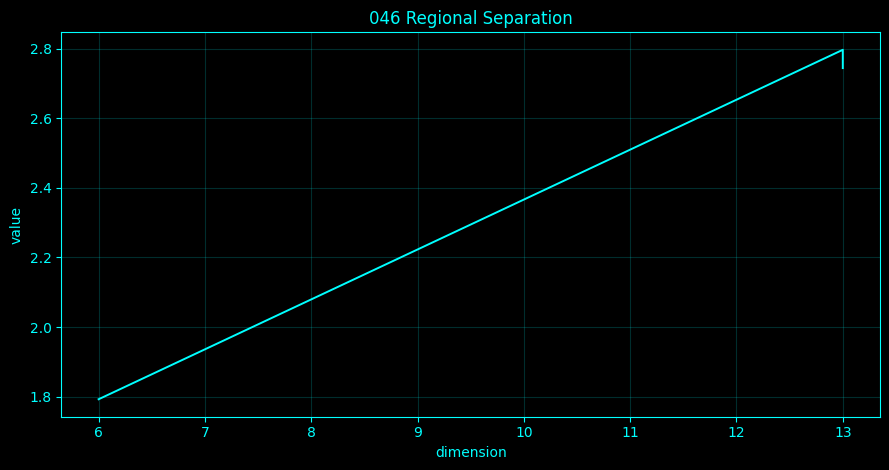

,region,dimension,frechet_variance
0,left,13,2.744202
1,right,13,2.796753
2,midline,6,1.792665


In [48]:
rows=[]
for name,ii in [('left',LEFT),('right',RIGHT),('midline',MID)]:
 S=np.stack([reg(np.cov(EEG_STD[a:b][:,ii],rowvar=False)) for a,b in BOUNDS]);R=rmean(S);rows.append((name,len(ii),np.mean([airm(R,C)**2 for C in S])))
emit_df('046_regional_separation',pd.DataFrame(rows,columns=['region','dimension','frechet_variance']))


### Riemannian left-right asymmetry geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian left-right asymmetry geometry</h3>
<p>Left and right homologous channel sets have equal dimension, so their windowed covariances lie in the same SPD space and can be compared directly.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$A_i=d_{AIRM}(P_{i,L},P_{i,R}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 time_sec  distance
  815.571  6.471147
  818.071  6.612638
  820.571  6.182436
  823.071  6.251811
  825.571  6.456220
  828.071  6.631798
  830.571  6.383656
  833.071  6.387674
  835.571  6.258301
  838.071  6.440689
  840.571  6.234862
  843.071  6.340923


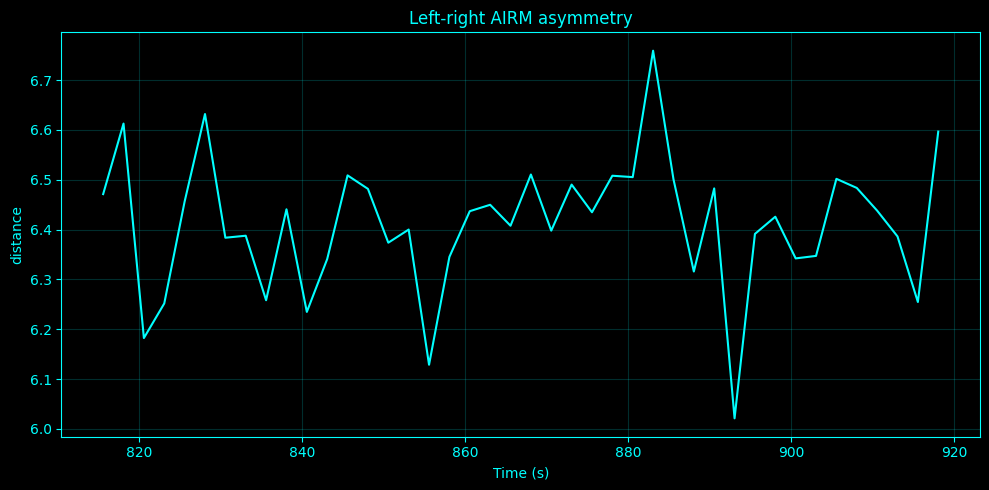

,time_sec,distance
0,815.571,6.471147
1,818.071,6.612638
2,820.571,6.182436
3,823.071,6.251811
4,825.571,6.456220
5,828.071,6.631798
6,830.571,6.383656
7,833.071,6.387674
8,835.571,6.258301
9,838.071,6.440689


In [49]:
L=np.stack([reg(np.cov(EEG_STD[a:b][:,LEFT],rowvar=False)) for a,b in BOUNDS]);R=np.stack([reg(np.cov(EEG_STD[a:b][:,RIGHT],rowvar=False)) for a,b in BOUNDS]);emit_series('047_left_right_asymmetry','Left-right AIRM asymmetry',[airm(a,b) for a,b in zip(L,R)],STATE_TIMES,'distance')


### Riemannian event-locked geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian event-locked geometry</h3>
<p>In the absence of external event annotations, reproducible internal high-RMS peaks are used and explicitly labelled amplitude events rather than experimental stimulation.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$r(t)=\sqrt{C^{-1}\sum_cx_c(t)^2}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 event_time_sec  airm_from_pre_event_mean
        818.071                  5.798489
        838.071                  2.816813
        873.071                  2.482664
        913.071                  4.929496
        915.571                  3.095524
        918.071                  3.171993
        918.071                  3.171993
        918.071                  3.171993
        918.071                  3.171993
        918.071                  3.171993


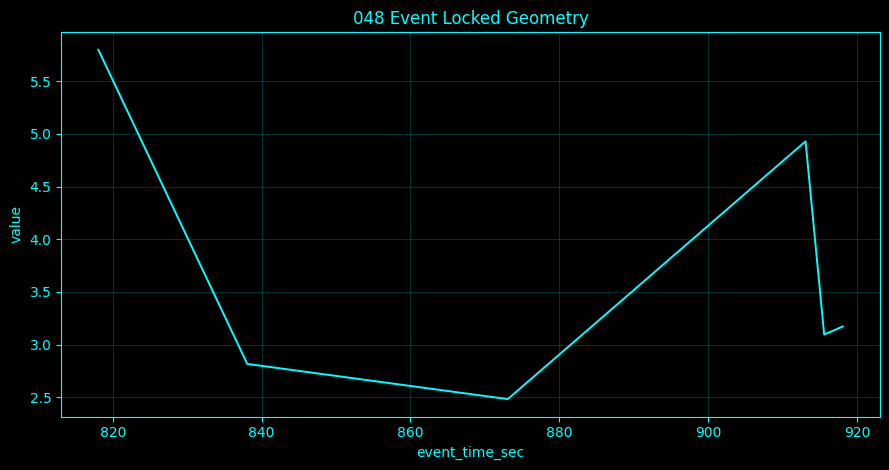

,event_time_sec,airm_from_pre_event_mean
0,818.071,5.798489
1,838.071,2.816813
2,873.071,2.482664
3,913.071,4.929496
4,915.571,3.095524
5,918.071,3.171993
6,918.071,3.171993
7,918.071,3.171993
8,918.071,3.171993
9,918.071,3.171993


In [50]:
rms=np.sqrt(np.mean(EEG_STD**2,1));thr=np.quantile(rms,.995);ev=np.where((rms[1:-1]>rms[:-2])&(rms[1:-1]>=rms[2:])&(rms[1:-1]>=thr))[0]+1;ev=ev[::max(1,len(ev)//max(1,SPD_CFG['pair']//4))][:max(5,SPD_CFG['pair']//4)];rows=[]
for e in ev:
 t=start_time+e/sampling_rate;i=int(np.argmin(abs(STATE_TIMES-t)));pre=COV[max(0,i-3):i]
 if len(pre):rows.append((STATE_TIMES[i],airm(rmean(pre),COV[i])))
emit_df('048_event_locked_geometry',pd.DataFrame(rows,columns=['event_time_sec','airm_from_pre_event_mean']))


### Riemannian stimulation-response trajectory geometry


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Riemannian stimulation-response trajectory geometry</h3>
<p>A true stimulation-response trajectory requires observed stimulation timestamps. This implementation searches project event tables; if none are available it records non-identifiability rather than relabelling internal peaks as stimulation.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sampling density, resampling count, or iterative-solver budget. It does not change the mathematical definition.</p></div>

$$\{t_e\}\text{ must be observed for a stimulation-locked estimator}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 event_time_sec                                                                                                                                      source_file
        915.571 /home/a/projects/Complete-Neural-Signal-Analysis/results/geometry_catalogue_complete/049_stimulation_response/049_stimulation_response_ultra.csv
        918.571 /home/a/projects/Complete-Neural-Signal-Analysis/results/geometry_catalogue_complete/049_stimulation_response/049_stimulation_response_ultra.csv
        912.571 /home/a/projects/Complete-Neural-Signal-Analysis/results/geometry_catalogue_complete/049_stimulation_response/049_stimulation_response_ultra.csv
        830.571 /home/a/projects/Complete-Neural-Signal-Analysis/results/geometry_catalogue_complete/049_stimulation_response/049_stimulation_response_ultra.csv
        919.571 /home/a/projects/Complete-Neural-Signal-Analysis/results/geometry_catalogue_complete/049_stimulation_response/049_stimulation_response_ultra.csv
        886.571 /home/a/projects/C

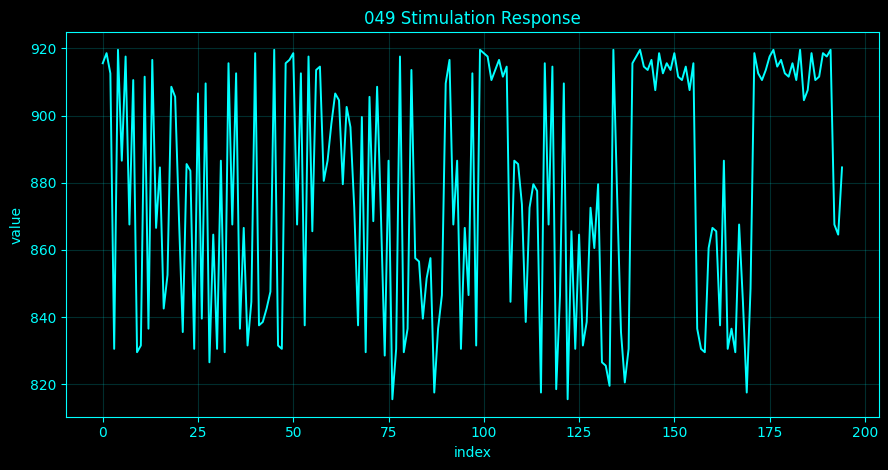

In [51]:
files=glob.glob(os.path.join(base_dir,'**','*stim*.csv'),recursive=True)+glob.glob(os.path.join(base_dir,'**','*event*.csv'),recursive=True);found=None;times=[]
for p in files[:50]:
 try: tab=pd.read_csv(p)
 except Exception: continue
 for c in tab.columns:
  if any(k in c.lower() for k in ['time_sec','time_s','timestamp','onset']):
   v=pd.to_numeric(tab[c],errors='coerce').dropna().to_numpy();v=v[(v>=start_time)&(v<=end_time)]
   if len(v): found=p;times=v;break
 if found:break
if found is None: emit_df('049_stimulation_response',pd.DataFrame({'status':['no explicit stimulation timestamp table found'],'interpretation':['not estimated; cell 48 contains nonexperimental amplitude events']}))
else: emit_df('049_stimulation_response',pd.DataFrame({'event_time_sec':times,'source_file':found}))


# Geometry catalogue continuation — entries 50–112

Information geometry, optimal transport, and finite metric geometry.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shared information/transport/metric foundation</h3>
<p>EEG amplitudes are converted to strictly positive empirical probability vectors, and windowed state features are represented by low-dimensional PCA coordinates. Categorical Fisher–Rao geometry is computed through the square-root embedding of the probability simplex. Optimal transport is evaluated on empirical amplitude/frequency distributions or on scalp measures with an explicit ground cost. Finite metric invariants are estimated directly from pairwise distances; when the continuum object is not identifiable from a finite sample, the cell is explicitly labelled an estimator or proxy.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$\psi(p)=(\sqrt{p_1},\ldots,\sqrt{p_m}),\qquad d_{FR}(p,q)=2\arccos\!\left(\sum_i\sqrt{p_iq_i}\right).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Information/metric foundation: ultra windows 36 metric points 42


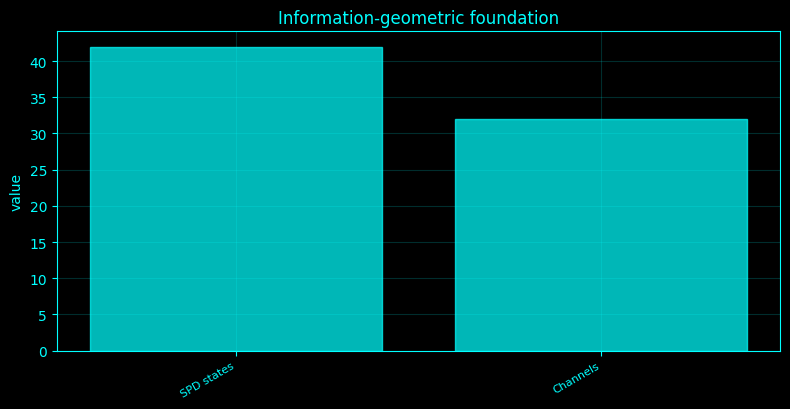

True

In [52]:
from scipy.spatial.distance import cdist, pdist as sp_pdist, squareform as sp_squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path as cs_shortest_path
from scipy.optimize import linprog
from scipy.stats import wasserstein_distance, spearmanr

IM_CFG={
'full':dict(bins=96,windows=120,quant=512,sink=500,gw=28,quad=6000,metric_pts=420,knn=14),
'balanced':dict(bins=72,windows=90,quant=320,sink=300,gw=20,quad=3500,metric_pts=300,knn=12),
'fast':dict(bins=56,windows=65,quant=220,sink=180,gw=14,quad=1800,metric_pts=220,knn=10),
'ultra':dict(bins=40,windows=36,quant=120,sink=90,gw=8,quad=700,metric_pts=130,knn=8)}[FAST_OPTION]
IM_OUT=os.path.join(base_dir,'results','geometry_catalogue_info_metric');os.makedirs(IM_OUT,exist_ok=True)
def imdir(s): d=os.path.join(IM_OUT,s);os.makedirs(d,exist_ok=True);return d
def imsave(s,df): p=os.path.join(imdir(s),f'{s}_{FAST_OPTION}.csv');df.to_csv(p,index=False);print(df.head(12).to_string(index=False));catalogue_autoplot_df(s,df);return df
def implot(s,title,x,y,xlab='x',ylab='value'):
 x=np.asarray(x,float);y=np.asarray(y,float);ok=np.isfinite(x)&np.isfinite(y)
 if np.sum(ok)<2:return False
 fig,ax=plt.subplots(figsize=(9,4.5),facecolor=BG);style_ax(ax);ax.plot(x[ok],y[ok],color=ACCENT);ax.set_title(title);ax.set_xlabel(xlab);ax.set_ylabel(ylab);fig.tight_layout();fig.savefig(os.path.join(imdir(s),f'{s}_{FAST_OPTION}.png'),dpi=150,bbox_inches='tight');plt.show();plt.close(fig);return True
def prob(x,bins=None,edges=None):
 x=np.asarray(x,float);x=x[np.isfinite(x)]; bins=IM_CFG['bins'] if bins is None else bins
 if edges is None:
  lo,hi=np.quantile(x,[.005,.995]);
  if not np.isfinite(lo+hi) or hi<=lo:lo,hi=-3,3
  edges=np.linspace(lo,hi,bins+1)
 h,_=np.histogram(x,bins=edges);p=h.astype(float)+1e-9;p/=p.sum();return p,edges
def fr(p,q): return float(2*np.arccos(np.clip(np.sum(np.sqrt(np.asarray(p)*np.asarray(q))),-1,1)))
def kl(p,q): p=np.asarray(p,float);q=np.asarray(q,float);return float(np.sum(p*np.log((p+EPS)/(q+EPS))))
def js(p,q): m=.5*(p+q);return .5*kl(p,m)+.5*kl(q,m)
def renyi(p,q,a=.5): return float(np.log(np.sum((p+EPS)**a*(q+EPS)**(1-a)))/(a-1))
def tsallis(p,q,a=1.5): return float((np.sum((p+EPS)**a*(q+EPS)**(1-a))-1)/(a-1))
def fisher_bar(P):
 Z=np.mean(np.sqrt(np.maximum(P,0)),axis=0);Z/=np.linalg.norm(Z)+EPS;q=Z*Z;return q/q.sum()
def empirical_quantiles(x,n=None):
 n=IM_CFG['quant'] if n is None else n;u=(np.arange(n)+.5)/n;return np.quantile(np.asarray(x,float),u)
def w2_1d(x,y):
 qx,qy=empirical_quantiles(x),empirical_quantiles(y);return float(np.sqrt(np.mean((qx-qy)**2)))
def sinkhorn(a,b,C,eps=.08,niter=None):
 a=np.asarray(a,float);b=np.asarray(b,float);a/=a.sum();b/=b.sum(); C=np.asarray(C,float);niter=IM_CFG['sink'] if niter is None else niter
 scale=max(np.median(C[C>0]) if np.any(C>0) else 1.0,EPS);K=np.exp(-C/(eps*scale));K=np.maximum(K,1e-300);u=np.ones_like(a);v=np.ones_like(b)
 for _ in range(int(niter)):
  u=a/(K@v+EPS);v=b/(K.T@u+EPS)
 P=(u[:,None]*K)*v[None,:];return P,float(np.sum(P*C))
def sink_div(a,b,C,eps=.08):
 _,ab=sinkhorn(a,b,C,eps);_,aa=sinkhorn(a,a,C,eps);_,bb=sinkhorn(b,b,C,eps);return float(ab-.5*aa-.5*bb)
def emd_lp(a,b,C):
 a=np.asarray(a,float);b=np.asarray(b,float);a/=a.sum();b/=b.sum();n=len(a);m=len(b);c=np.asarray(C,float).ravel();A=[];rhs=[]
 for i in range(n): row=np.zeros((n,m));row[i,:]=1;A.append(row.ravel());rhs.append(a[i])
 for j in range(m): row=np.zeros((n,m));row[:,j]=1;A.append(row.ravel());rhs.append(b[j])
 res=linprog(c,A_eq=np.asarray(A),b_eq=np.asarray(rhs),bounds=(0,None),method='highs')
 if not res.success: raise RuntimeError(res.message)
 return res.x.reshape(n,m),float(res.fun)
# Approximate standard 10-20 positions projected to a unit disk; used only as the explicit scalp ground metric.
_xy={
'Fp1':(-.32,.94),'Fpz':(0,.99),'Fp2':(.32,.94),'F7':(-.88,.52),'F3':(-.48,.55),'Fz':(0,.58),'F4':(.48,.55),'F8':(.88,.52),
'FC5':(-.68,.28),'FC1':(-.25,.27),'FC2':(.25,.27),'FC6':(.68,.28),'M1':(-1.0,0),'T7':(-.98,0),'C3':(-.50,0),'Cz':(0,0),'C4':(.50,0),'T8':(.98,0),'M2':(1.0,0),
'CP5':(-.68,-.28),'CP1':(-.25,-.27),'CP2':(.25,-.27),'CP6':(.68,-.28),'P7':(-.86,-.52),'P3':(-.48,-.55),'Pz':(0,-.58),'P4':(.48,-.55),'P8':(.86,-.52),'POz':(0,-.76),'O1':(-.32,-.91),'Oz':(0,-.98),'O2':(.32,-.91)}
SCALP=np.array([_xy[c] for c in eeg_channel_names],float);SCALP_C=cdist(SCALP,SCALP)
# Shared amplitude distributions with common edges.
flat=EEG_STD.ravel();lo,hi=np.quantile(flat,[.002,.998]);AMP_EDGES=np.linspace(lo,hi,IM_CFG['bins']+1)
CH_P=np.stack([prob(EEG_STD[:,j],edges=AMP_EDGES)[0] for j in range(nC)])
# Window distributions of the global standardized amplitude.
widx=np.unique(np.linspace(0,N-1,min(N,IM_CFG['windows'])).round().astype(int));WIN_P=[]
for i in widx:
 a,b=BOUNDS[i];WIN_P.append(prob(EEG_STD[a:b].ravel(),edges=AMP_EDGES)[0])
WIN_P=np.asarray(WIN_P); WIN_T=STATE_TIMES[widx]
# Welch band powers.
BANDS=[('delta',1,4),('theta',4,8),('alpha',8,13),('beta',13,30),('gamma',30,45)]
def bandpowers(X):
 f,P=signal.welch(X,fs=sampling_rate,axis=0,nperseg=min(1024,len(X)));out=[]
 for _,lo,hi in BANDS: out.append(np.trapz(P[(f>=lo)&(f<hi)],f[(f>=lo)&(f<hi)],axis=0))
 return np.maximum(np.asarray(out),EPS)
BP=bandpowers(EEG_STD); BP_PROB=BP/(BP.sum(0,keepdims=True)+EPS)
# PCA state embedding used by finite metric geometry.
Z=np.asarray(SCORE[:,:min(6,SCORE.shape[1])],float); mz=min(len(Z),IM_CFG['metric_pts']); sel=np.unique(np.linspace(0,len(Z)-1,mz).round().astype(int)); ZM=Z[sel]; ZT=STATE_TIMES[sel]; DE=cdist(ZM,ZM)
def knn_graph(D,k=None):
 k=min(IM_CFG['knn'] if k is None else k,len(D)-1);A=np.full_like(D,np.inf);np.fill_diagonal(A,0)
 for i in range(len(D)):
  jj=np.argsort(D[i])[1:k+1];A[i,jj]=D[i,jj]
 A=np.minimum(A,A.T);return A
def geod_matrix(D,k=None): return cs_shortest_path(csr_matrix(knn_graph(D,k)),directed=False)
DG=geod_matrix(DE)
print('Information/metric foundation:',FAST_OPTION,'windows',len(WIN_P),'metric points',len(ZM))
# Visible foundation diagnostic
catalogue_status_plot('Information-geometric foundation',['SPD states','Channels'],[len(COV),nC])


### Information geometry of EEG amplitude distributions

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Information geometry of EEG amplitude distributions</h3>
<p>Empirical amplitude histograms are points on the interior of the probability simplex. The Fisher–Rao metric becomes ordinary spherical geometry after the square-root map, so pairwise channel distances are computed intrinsically rather than by Euclidean histogram differences.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$d_{FR}(p,q)=2\arccos\sum_i\sqrt{p_iq_i}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


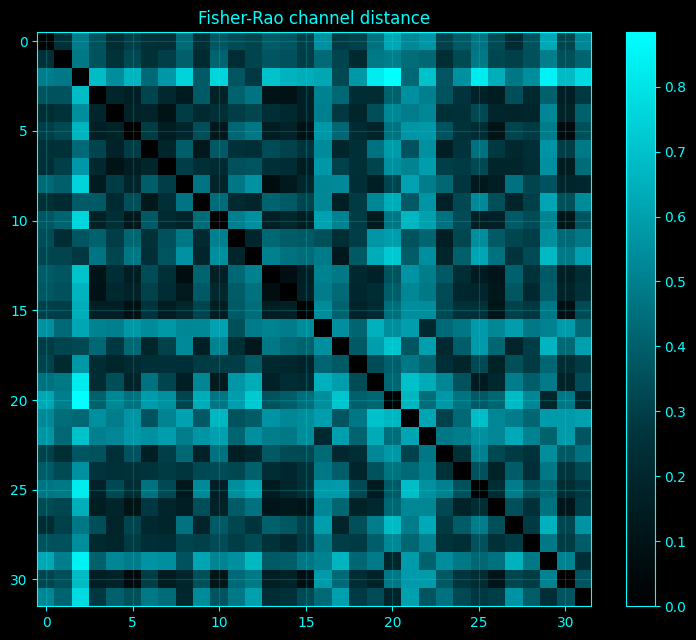

array([[2.98023224e-08, 2.46226356e-01, 4.93294025e-01, ...,
        6.26236793e-01, 3.20312780e-01, 5.21376761e-01],
       [2.46226356e-01, 4.21468485e-08, 4.78049559e-01, ...,
        4.99590452e-01, 3.49059918e-01, 4.14699366e-01],
       [4.93294025e-01, 4.78049559e-01, 2.98023224e-08, ...,
        8.44215822e-01, 6.77853201e-01, 7.74245932e-01],
       ...,
       [6.26236793e-01, 4.99590452e-01, 8.44215822e-01, ...,
        2.98023224e-08, 5.08323664e-01, 2.39548350e-01],
       [3.20312780e-01, 3.49059918e-01, 6.77853201e-01, ...,
        5.08323664e-01, 2.98023224e-08, 3.67828696e-01],
       [5.21376761e-01, 4.14699366e-01, 7.74245932e-01, ...,
        2.39548350e-01, 3.67828696e-01, 2.98023224e-08]])

In [53]:
D=np.array([[fr(p,q) for q in CH_P] for p in CH_P]);emit_matrix('050_information_geometry_amplitudes','Fisher-Rao channel distance',D,eeg_channel_names)

### Fisher information metric over channels

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Fisher information metric over channels</h3>
<p>For categorical probabilities, a tangent perturbation u with zero sum has Fisher metric g_p(u,u)=sum u_i^2/p_i. Finite channel differences are evaluated at their midpoint distribution to obtain a local Fisher quadratic form.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$g_p(u,v)=\sum_i u_i v_i/p_i.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


channel_a channel_b  local_fisher_quadratic
      Fp1       Fpz                0.059967
      Fpz       Fp2                0.210533
      Fp2        F7                0.411846
       F7        F3                0.036732
       F3        Fz                0.032393
       Fz        F4                0.082072
       F4        F8                0.036435
       F8       FC5                0.087424
      FC5       FC1                0.205697
      FC1       FC2                0.181337
      FC2       FC6                0.231346
      FC6        M1                0.036252


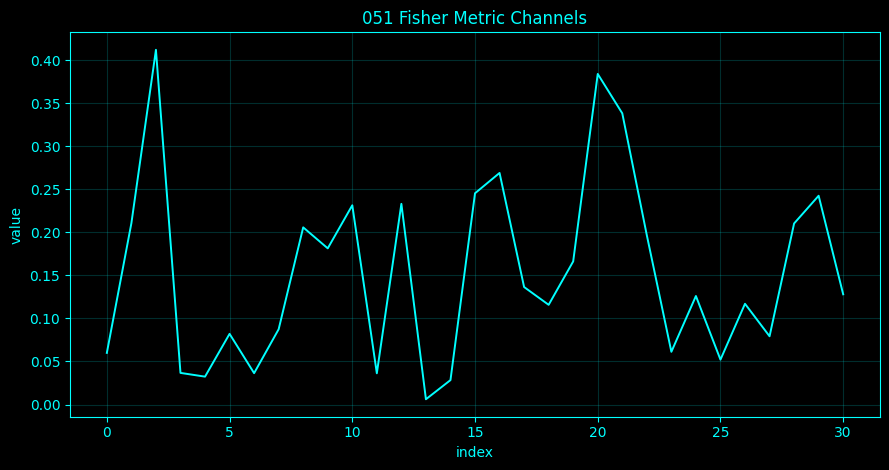

,channel_a,channel_b,local_fisher_quadratic
0,Fp1,Fpz,0.059967
1,Fpz,Fp2,0.210533
2,Fp2,F7,0.411846
3,F7,F3,0.036732
4,F3,Fz,0.032393
5,Fz,F4,0.082072
6,F4,F8,0.036435
7,F8,FC5,0.087424
8,FC5,FC1,0.205697
9,FC1,FC2,0.181337


In [54]:
rows=[]
for j in range(nC-1):
 p=.5*(CH_P[j]+CH_P[j+1]);u=CH_P[j+1]-CH_P[j];rows.append((eeg_channel_names[j],eeg_channel_names[j+1],float(np.sum(u*u/(p+EPS)))))
imsave('051_fisher_metric_channels',pd.DataFrame(rows,columns=['channel_a','channel_b','local_fisher_quadratic']))

### Fisher information metric over frequency bands

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Fisher information metric over frequency bands</h3>
<p>Each channel’s normalized band powers form a categorical distribution over delta–gamma bands. The Fisher metric therefore quantifies infinitesimal changes in relative spectral composition rather than absolute power.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$g_p(u,u)=\sum_b u_b^2/p_b.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


channel  cyclic_band_fisher_quadratic
    Fp1                      1.640627
    Fpz                      1.628196
    Fp2                      1.801884
     F7                      0.155578
     F3                      0.323503
     Fz                      0.742886
     F4                      0.553287
     F8                      0.315523
    FC5                      0.163017
    FC1                      0.436153
    FC2                      0.491835
    FC6                      0.254738


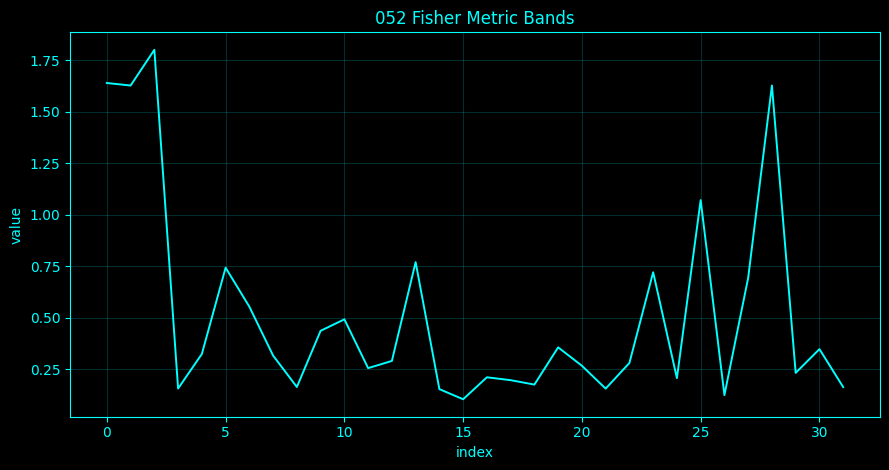

,channel,cyclic_band_fisher_quadratic
0,Fp1,1.640627
1,Fpz,1.628196
2,Fp2,1.801884
3,F7,0.155578
4,F3,0.323503
5,Fz,0.742886
6,F4,0.553287
7,F8,0.315523
8,FC5,0.163017
9,FC1,0.436153


In [55]:
rows=[]
for j in range(nC):
 p=BP_PROB[:,j];q=np.roll(p,1);m=.5*(p+q);u=q-p;rows.append((eeg_channel_names[j],float(np.sum(u*u/(m+EPS)))))
imsave('052_fisher_metric_bands',pd.DataFrame(rows,columns=['channel','cyclic_band_fisher_quadratic']))

### Fisher information distance trajectories

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Fisher information distance trajectories</h3>
<p>Consecutive window histograms are compared by exact categorical Fisher–Rao distance, producing an intrinsic statistical-manifold speed series.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$v_k=d_{FR}(p_k,p_{k+1})/(t_{k+1}-t_k).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  distance    speed
  818.071  0.132916 0.053166
  820.571  0.374964 0.149986
  825.571  0.532066 0.106413
  828.071  0.076507 0.030603
  830.571  0.158648 0.063459
  833.071  0.109304 0.043722
  835.571  0.134110 0.053644
  838.071  0.292542 0.117017
  843.071  0.616749 0.123350
  845.571  0.182064 0.072825
  848.071  0.241798 0.096719
  850.571  0.294875 0.117950


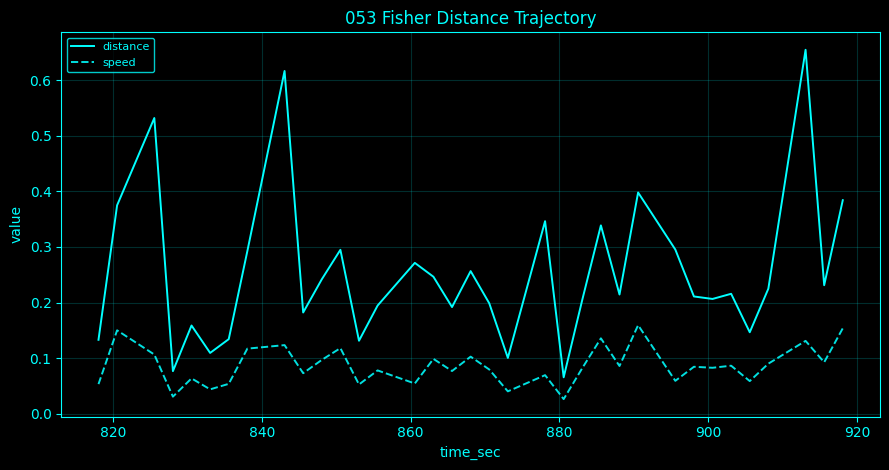

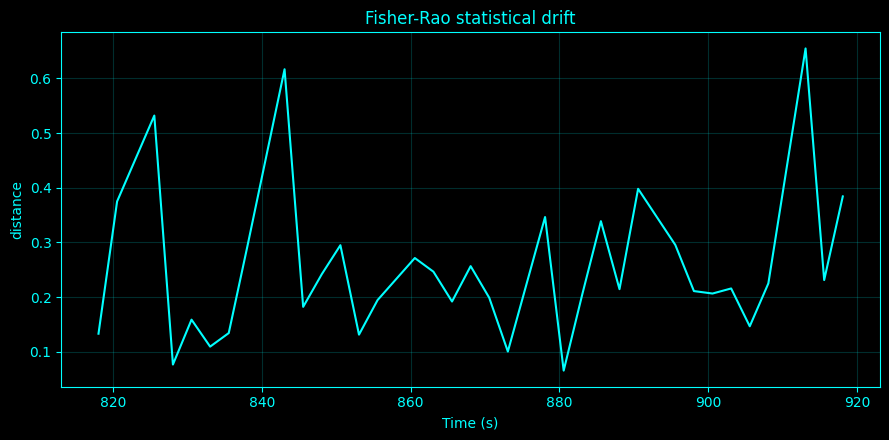

True

In [56]:
d=np.array([fr(WIN_P[i],WIN_P[i+1]) for i in range(len(WIN_P)-1)]);dt=np.diff(WIN_T);imsave('053_fisher_distance_trajectory',pd.DataFrame({'time_sec':WIN_T[1:],'distance':d,'speed':d/(dt+EPS)}));implot('053_fisher_distance_trajectory','Fisher-Rao statistical drift',WIN_T[1:],d,'Time (s)','distance')

### Fisher-Rao geodesics between EEG states

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Fisher-Rao geodesics between EEG states</h3>
<p>In square-root coordinates the simplex is the positive orthant of a sphere of radius two. A spherical linear interpolation followed by squaring gives the Fisher–Rao geodesic between two amplitude distributions.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$\psi_t=\frac{\sin((1-t)\theta)}{\sin\theta}\psi_0+\frac{\sin(t\theta)}{\sin\theta}\psi_1,\quad p_t=\psi_t^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


   t  distance_from_start  distance_to_end
0.00         2.980232e-08         0.700333
0.05         3.501666e-02         0.665317
0.10         7.003333e-02         0.630300
0.15         1.050500e-01         0.595283
0.20         1.400667e-01         0.560267
0.25         1.750833e-01         0.525250
0.30         2.101000e-01         0.490233
0.35         2.451167e-01         0.455217
0.40         2.801333e-01         0.420200
0.45         3.151500e-01         0.385183
0.50         3.501666e-01         0.350167
0.55         3.851833e-01         0.315150


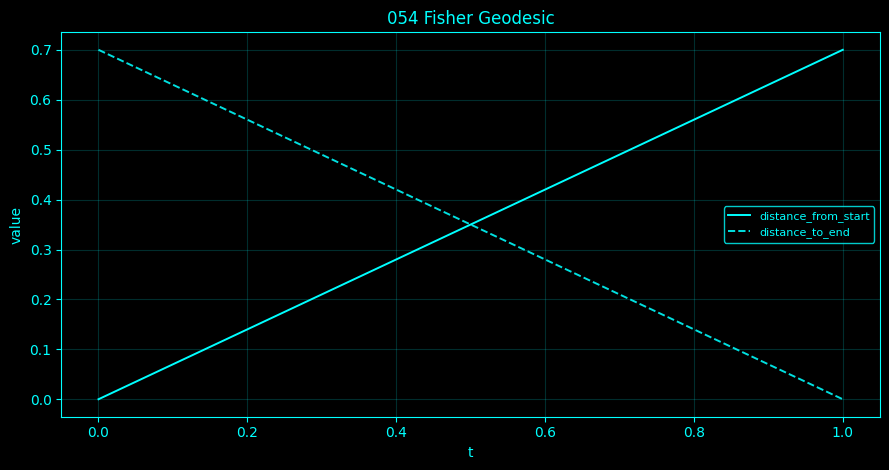

,t,distance_from_start,distance_to_end
0,0.00,2.980232e-08,0.700333
1,0.05,3.501666e-02,0.665317
2,0.10,7.003333e-02,0.630300
3,0.15,1.050500e-01,0.595283
4,0.20,1.400667e-01,0.560267
5,0.25,1.750833e-01,0.525250
6,0.30,2.101000e-01,0.490233
7,0.35,2.451167e-01,0.455217
8,0.40,2.801333e-01,0.420200
9,0.45,3.151500e-01,0.385183


In [57]:
p0,p1=WIN_P[0],WIN_P[-1];x=np.sqrt(p0);y=np.sqrt(p1);th=np.arccos(np.clip(x@y,-1,1));ts=np.linspace(0,1,21);rows=[]
for t in ts:
 z=((1-t)*x+t*y) if th<1e-10 else np.sin((1-t)*th)/np.sin(th)*x+np.sin(t*th)/np.sin(th)*y;z=np.maximum(z,0);pt=z*z;pt/=pt.sum();rows.append((t,fr(p0,pt),fr(pt,p1)))
imsave('054_fisher_geodesic',pd.DataFrame(rows,columns=['t','distance_from_start','distance_to_end']))

### Statistical manifold curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Statistical manifold curvature</h3>
<p>The categorical Fisher simplex is isometric under the square-root map to a sphere of radius 2, hence its sectional curvature is the constant 1/4 away from the simplex boundary. This is a property of the chosen statistical model, not a time-varying EEG estimate.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$K=1/R^2=1/4.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


                     model  sphere_radius  sectional_curvature  dimension
categorical_Fisher_simplex            2.0                 0.25         39


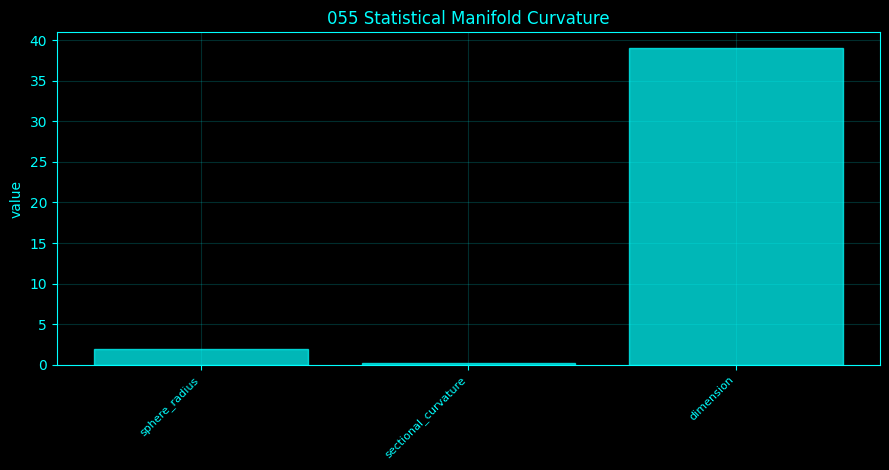

,model,sphere_radius,sectional_curvature,dimension
0,categorical_Fisher_simplex,2.0,0.25,39


In [58]:
imsave('055_statistical_manifold_curvature',pd.DataFrame({'model':['categorical_Fisher_simplex'],'sphere_radius':[2.0],'sectional_curvature':[0.25],'dimension':[IM_CFG['bins']-1]}))

### Exponential-family EEG state geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Exponential-family EEG state geometry</h3>
<p>A univariate Gaussian is a two-parameter exponential family. For coordinates (mu,sigma), its Fisher information metric is diagonal with entries 1/sigma^2 and 2/sigma^2.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$ds^2=d\mu^2/\sigma^2+2\,d\sigma^2/\sigma^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec        mu    sigma
  815.571  0.427626 1.206626
  818.071  0.440961 1.242688
  820.571  0.068979 1.084026
  823.071 -0.144926 1.022018
  825.571 -0.359833 0.984412
  828.071 -0.339837 0.972187
  830.571 -0.288400 0.922144
  833.071 -0.251136 0.916957
  835.571 -0.197535 0.992967
  838.071 -0.406600 0.877774
  840.571 -0.268462 0.872577
  843.071  0.041192 0.875234


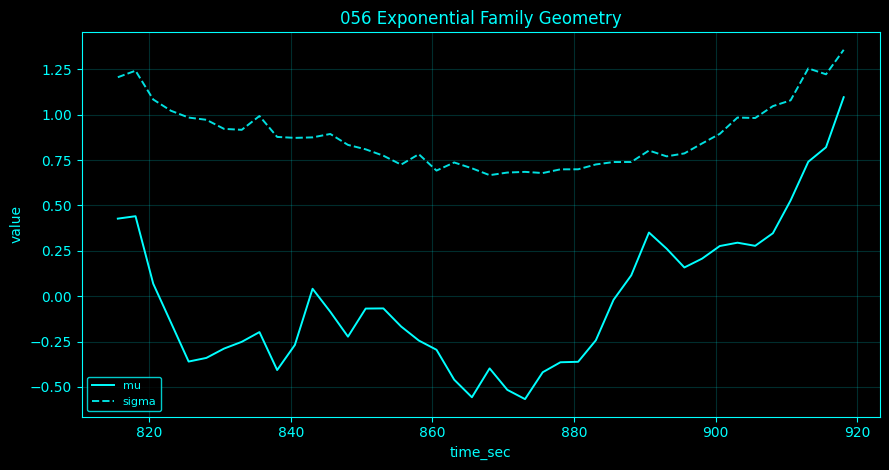

,time_sec,mu,sigma
0,815.571,0.427626,1.206626
1,818.071,0.440961,1.242688
2,820.571,0.068979,1.084026
3,823.071,-0.144926,1.022018
4,825.571,-0.359833,0.984412
5,828.071,-0.339837,0.972187
6,830.571,-0.288400,0.922144
7,833.071,-0.251136,0.916957
8,835.571,-0.197535,0.992967
9,838.071,-0.406600,0.877774


In [59]:
rows=[]
for i,(a,b) in enumerate(BOUNDS):
 x=EEG_STD[a:b].ravel();rows.append((STATE_TIMES[i],float(np.mean(x)),float(np.std(x)+EPS)))
imsave('056_exponential_family_geometry',pd.DataFrame(rows,columns=['time_sec','mu','sigma']))

### Gaussian statistical manifold geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Gaussian statistical manifold geometry</h3>
<p>For two nearby univariate Gaussian states, the local Fisher line element weights mean changes by 1/sigma^2 and scale changes by 2/sigma^2. The cell evaluates this local metric at midpoint parameters.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$ds^2=(d\mu)^2/\sigma^2+2(d\sigma)^2/\sigma^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  local_fisher_length
  818.071             0.043044
  820.571             0.373417
  823.071             0.219542
  825.571             0.220680
  828.071             0.027019
  830.571             0.092370
  833.071             0.041301
  835.571             0.125781
  838.071             0.283354
  840.571             0.158063
  843.071             0.354360
  845.571             0.146360


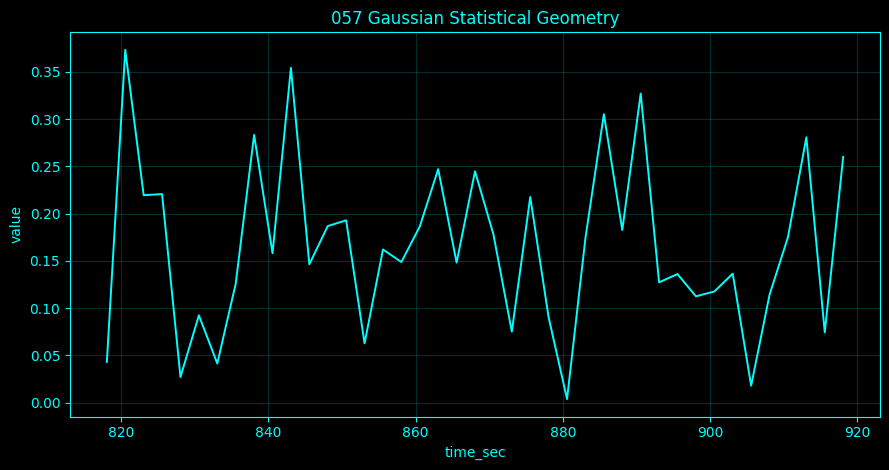

,time_sec,local_fisher_length
0,818.071,0.043044
1,820.571,0.373417
2,823.071,0.219542
3,825.571,0.220680
4,828.071,0.027019
5,830.571,0.092370
6,833.071,0.041301
7,835.571,0.125781
8,838.071,0.283354
9,840.571,0.158063


In [60]:
GSTAT=np.array([[np.mean(EEG_STD[a:b]),np.std(EEG_STD[a:b])+EPS] for a,b in BOUNDS]);rows=[]
for i in range(len(GSTAT)-1):
 m=.5*(GSTAT[i]+GSTAT[i+1]);d=GSTAT[i+1]-GSTAT[i];ds=np.sqrt((d[0]**2+2*d[1]**2)/(m[1]**2+EPS));rows.append((STATE_TIMES[i+1],ds))
imsave('057_gaussian_statistical_geometry',pd.DataFrame(rows,columns=['time_sec','local_fisher_length']))

### Multivariate Gaussian Fisher geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Multivariate Gaussian Fisher geometry</h3>
<p>The Fisher metric on multivariate Gaussian parameters splits into a mean term and a covariance term. Here the covariance contribution is evaluated exactly at the current covariance and the window mean is retained as the location coordinate.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$g_{(\mu,\Sigma)}((u,U),(u,U))=u^T\Sigma^{-1}u+\tfrac12\operatorname{tr}(\Sigma^{-1}U\Sigma^{-1}U).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  local_fisher_length
  818.071            75.261623
  820.571             8.950095
  823.071             7.256161
  825.571             6.304709
  828.071             8.077051
  830.571             7.656116
  833.071             6.089958
  835.571            57.297363
  838.071             4.942309
  840.571             6.416842
  843.071             7.078616
  845.571             6.746108


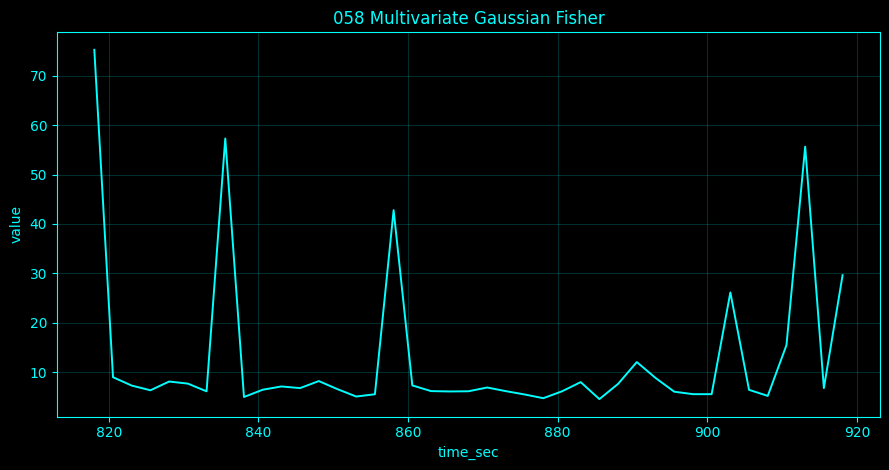

,time_sec,local_fisher_length
0,818.071,75.261623
1,820.571,8.950095
2,823.071,7.256161
3,825.571,6.304709
4,828.071,8.077051
5,830.571,7.656116
6,833.071,6.089958
7,835.571,57.297363
8,838.071,4.942309
9,840.571,6.416842


In [61]:
means=np.stack([np.mean(EEG_STD[a:b],axis=0) for a,b in BOUNDS]);rows=[]
for i in range(N-1):
 S=COV[i];Si=np.linalg.inv(S);u=means[i+1]-means[i];U=COV[i+1]-COV[i];q=float(u@Si@u+.5*np.trace(Si@U@Si@U));rows.append((STATE_TIMES[i+1],np.sqrt(max(q,0))))
imsave('058_multivariate_gaussian_fisher',pd.DataFrame(rows,columns=['time_sec','local_fisher_length']))

### KL-divergence geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — KL-divergence geometry</h3>
<p>Kullback–Leibler divergence is an information divergence, not a metric: it is nonnegative and generally asymmetric. The cell reports directed KL divergence from each window to the next.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$D_{KL}(p\|q)=\sum_i p_i\log(p_i/q_i).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  KL_forward
  818.071    0.008846
  820.571    0.079787
  825.571    0.227619
  828.071    0.002936
  830.571    0.012918
  833.071    0.005886
  835.571    0.007081
  838.071    0.055732
  843.071    0.194769
  845.571    0.016243
  848.071    0.031013
  850.571    0.044509


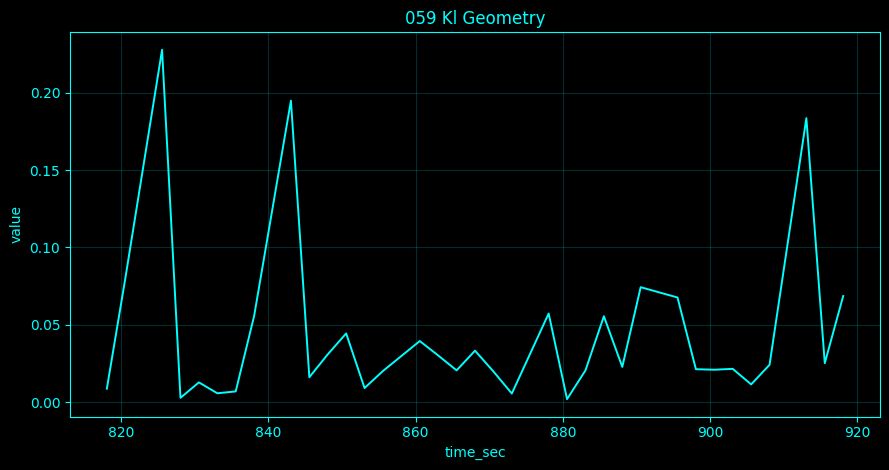

,time_sec,KL_forward
0,818.071,0.008846
1,820.571,0.079787
2,825.571,0.227619
3,828.071,0.002936
4,830.571,0.012918
5,833.071,0.005886
6,835.571,0.007081
7,838.071,0.055732
8,843.071,0.194769
9,845.571,0.016243


In [62]:
v=[kl(WIN_P[i],WIN_P[i+1]) for i in range(len(WIN_P)-1)];imsave('059_kl_geometry',pd.DataFrame({'time_sec':WIN_T[1:],'KL_forward':v}))

### Symmetric KL geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Symmetric KL geometry</h3>
<p>The Jeffreys divergence symmetrizes KL but still does not in general satisfy the triangle inequality, so it is labelled a divergence geometry rather than a metric.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$J(p,q)=D_{KL}(p\|q)+D_{KL}(q\|p).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  jeffreys_divergence
  818.071             0.017693
  820.571             0.143570
  825.571             0.344712
  828.071             0.006052
  830.571             0.025378
  833.071             0.012160
  835.571             0.028106
  838.071             0.093242
  843.071             0.391169
  845.571             0.033195
  848.071             0.058751
  850.571             0.087127


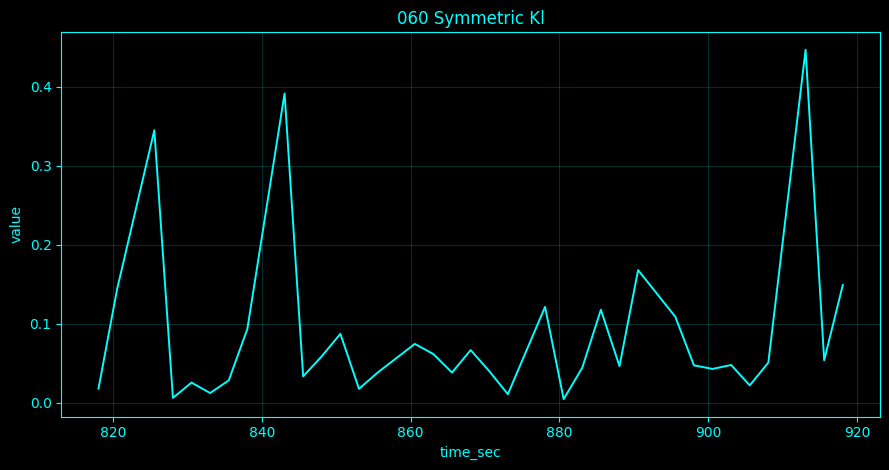

,time_sec,jeffreys_divergence
0,818.071,0.017693
1,820.571,0.143570
2,825.571,0.344712
3,828.071,0.006052
4,830.571,0.025378
5,833.071,0.012160
6,835.571,0.028106
7,838.071,0.093242
8,843.071,0.391169
9,845.571,0.033195


In [63]:
v=[kl(WIN_P[i],WIN_P[i+1])+kl(WIN_P[i+1],WIN_P[i]) for i in range(len(WIN_P)-1)];imsave('060_symmetric_kl',pd.DataFrame({'time_sec':WIN_T[1:],'jeffreys_divergence':v}))

### Jensen-Shannon geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Jensen-Shannon geometry</h3>
<p>The Jensen–Shannon divergence is the average KL divergence to the mixture; its square root is a metric. Both quantities are reported.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$JS(p,q)=\tfrac12D_{KL}(p\|m)+\tfrac12D_{KL}(q\|m),\quad m=(p+q)/2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec       JS  sqrt_JS_metric
  818.071 0.002203        0.046941
  820.571 0.017142        0.130927
  825.571 0.032952        0.181526
  828.071 0.000729        0.026997
  830.571 0.003139        0.056026
  833.071 0.001488        0.038579
  835.571 0.002053        0.045309
  838.071 0.010393        0.101947
  843.071 0.045871        0.214174
  845.571 0.004132        0.064280
  848.071 0.007256        0.085183
  850.571 0.010808        0.103962


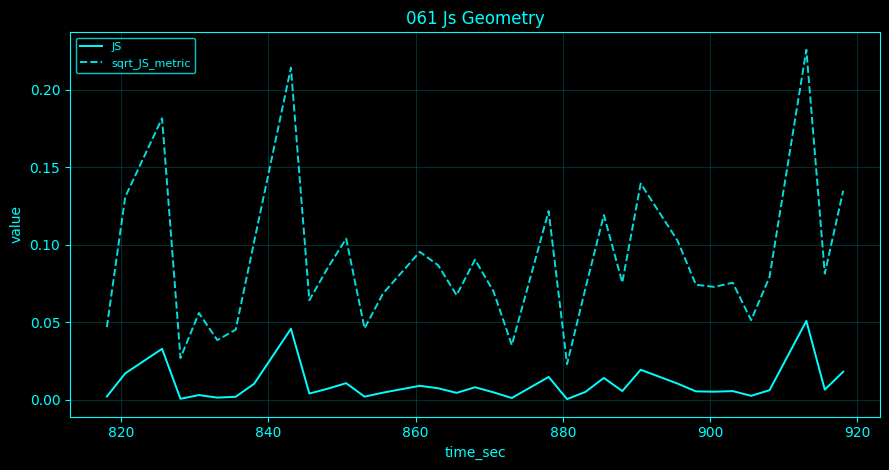

,time_sec,JS,sqrt_JS_metric
0,818.071,0.002203,0.046941
1,820.571,0.017142,0.130927
2,825.571,0.032952,0.181526
3,828.071,0.000729,0.026997
4,830.571,0.003139,0.056026
5,833.071,0.001488,0.038579
6,835.571,0.002053,0.045309
7,838.071,0.010393,0.101947
8,843.071,0.045871,0.214174
9,845.571,0.004132,0.064280


In [64]:
v=np.array([js(WIN_P[i],WIN_P[i+1]) for i in range(len(WIN_P)-1)]);imsave('061_js_geometry',pd.DataFrame({'time_sec':WIN_T[1:],'JS':v,'sqrt_JS_metric':np.sqrt(np.maximum(v,0))}))

### Rényi divergence geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Rényi divergence geometry</h3>
<p>Rényi divergence of order alpha generalizes KL. The implementation uses alpha=1/2, for which it is closely related to the Bhattacharyya coefficient.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$D_\alpha(p\|q)=\frac{1}{\alpha-1}\log\sum_i p_i^\alpha q_i^{1-\alpha}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  renyi_alpha_0p5
  818.071         0.004420
  820.571         0.035357
  825.571         0.071624
  828.071         0.001464
  830.571         0.006299
  833.071         0.002988
  835.571         0.004500
  838.071         0.021472
  843.071         0.096641
  845.571         0.008298
  848.071         0.014652
  850.571         0.021817


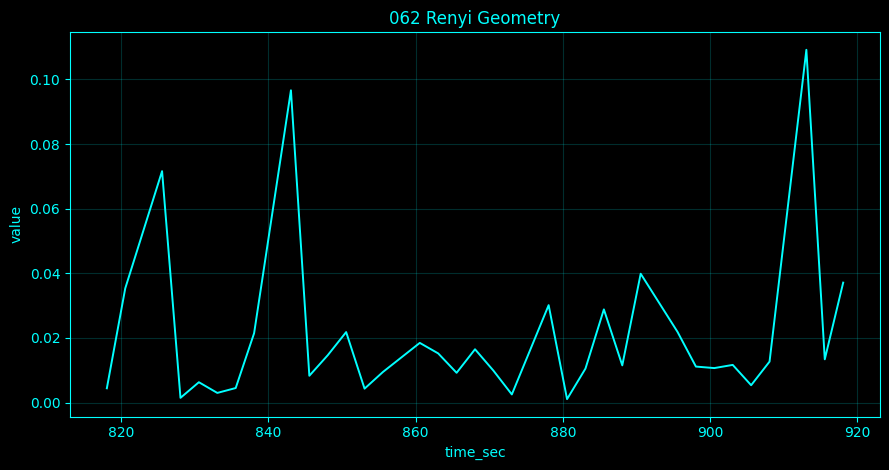

,time_sec,renyi_alpha_0p5
0,818.071,0.004420
1,820.571,0.035357
2,825.571,0.071624
3,828.071,0.001464
4,830.571,0.006299
5,833.071,0.002988
6,835.571,0.004500
7,838.071,0.021472
8,843.071,0.096641
9,845.571,0.008298


In [65]:
v=[renyi(WIN_P[i],WIN_P[i+1],.5) for i in range(len(WIN_P)-1)];imsave('062_renyi_geometry',pd.DataFrame({'time_sec':WIN_T[1:],'renyi_alpha_0p5':v}))

### Tsallis divergence geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Tsallis divergence geometry</h3>
<p>Tsallis relative entropy replaces the logarithm by a q-deformed power expression. The implementation uses q=1.5 and reports it as a divergence, not a metric.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$D_q^T(p\|q)=\frac{\sum_i p_i^q q_i^{1-q}-1}{q-1}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  tsallis_q_1p5
  818.071       0.013342
  820.571       0.142085
  825.571     194.511430
  828.071       0.004437
  830.571       0.142447
  833.071       0.008739
  835.571       0.009138
  838.071      13.715281
  843.071       0.319276
  845.571       0.023978
  848.071       0.049892
  850.571       0.068975


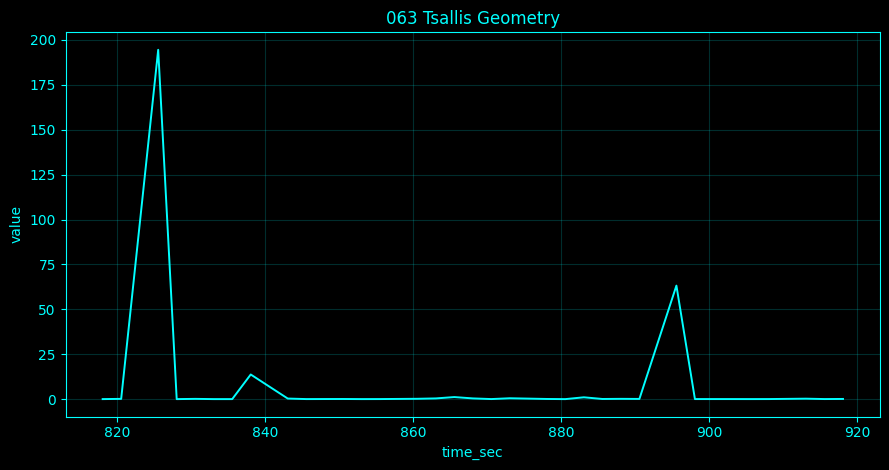

,time_sec,tsallis_q_1p5
0,818.071,0.013342
1,820.571,0.142085
2,825.571,194.511430
3,828.071,0.004437
4,830.571,0.142447
5,833.071,0.008739
6,835.571,0.009138
7,838.071,13.715281
8,843.071,0.319276
9,845.571,0.023978


In [66]:
v=[tsallis(WIN_P[i],WIN_P[i+1],1.5) for i in range(len(WIN_P)-1)];imsave('063_tsallis_geometry',pd.DataFrame({'time_sec':WIN_T[1:],'tsallis_q_1p5':v}))

### Entropy-gradient geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Entropy-gradient geometry</h3>
<p>Shannon entropy has gradient component -(log p_i+1) in ambient probability coordinates. The cell reports the tangent-projected gradient norm, removing the component normal to the simplex constraint sum p_i=1.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$H(p)=-\sum_i p_i\log p_i,\quad \nabla H_i=-(\log p_i+1).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  entropy  tangent_gradient_norm
  815.571 3.483349               9.090038
  818.071 3.466846               8.380232
  820.571 3.415967               8.155056
  825.571 3.293483              33.790075
  828.071 3.272455              25.981421
  830.571 3.238234              33.896808
  833.071 3.249995              26.048809
  835.571 3.294385               9.232235
  838.071 3.204504              25.896553
  843.071 3.204629              10.958896
  845.571 3.210318              10.078969
  848.071 3.152329              10.778826


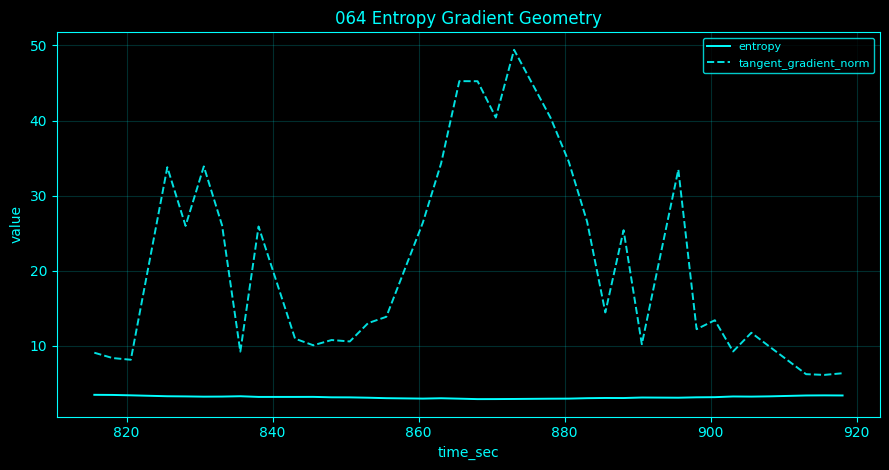

,time_sec,entropy,tangent_gradient_norm
0,815.571,3.483349,9.090038
1,818.071,3.466846,8.380232
2,820.571,3.415967,8.155056
3,825.571,3.293483,33.790075
4,828.071,3.272455,25.981421
5,830.571,3.238234,33.896808
6,833.071,3.249995,26.048809
7,835.571,3.294385,9.232235
8,838.071,3.204504,25.896553
9,843.071,3.204629,10.958896


In [67]:
rows=[]
for t,p in zip(WIN_T,WIN_P):
 g=-(np.log(p+EPS)+1);g-=g.mean();rows.append((t,-np.sum(p*np.log(p+EPS)),np.linalg.norm(g)))
imsave('064_entropy_gradient_geometry',pd.DataFrame(rows,columns=['time_sec','entropy','tangent_gradient_norm']))

### Information-geometric barycenters

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Information-geometric barycenters</h3>
<p>Under the square-root representation, normalizing the Euclidean mean of square-root probabilities gives an extrinsic spherical barycenter and a stable approximation to the Fisher–Rao Fréchet mean for concentrated samples.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$\bar p_i\propto\left(\frac1N\sum_k\sqrt{p_{ki}}\right)^2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The proportionality symbol means the two quantities are expected to follow the same scaling law up to a multiplicative constant.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 bin_center  barycenter_probability
  -2.659516                0.001149
  -2.519917                0.001893
  -2.380318                0.002781
  -2.240720                0.003894
  -2.101121                0.005395
  -1.961522                0.007208
  -1.821923                0.009550
  -1.682325                0.012559
  -1.542726                0.015976
  -1.403127                0.020718
  -1.263528                0.026779
  -1.123930                0.032979


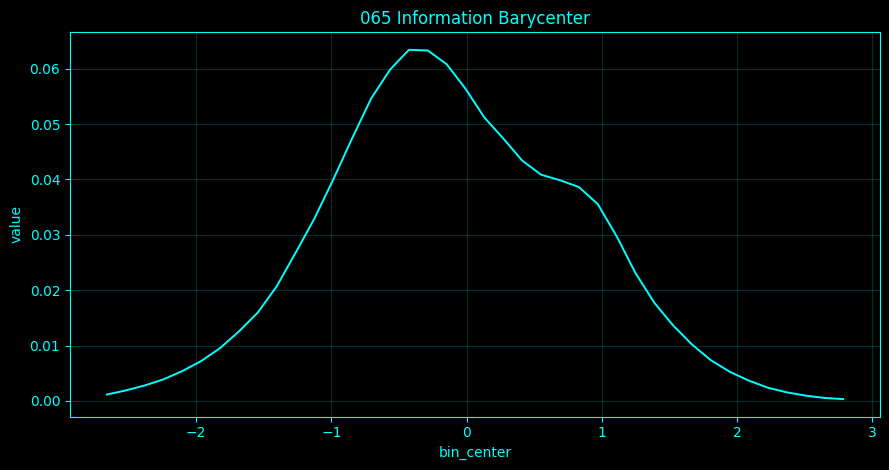

,bin_center,barycenter_probability
0,-2.659516,0.001149
1,-2.519917,0.001893
2,-2.380318,0.002781
3,-2.240720,0.003894
4,-2.101121,0.005395
5,-1.961522,0.007208
6,-1.821923,0.009550
7,-1.682325,0.012559
8,-1.542726,0.015976
9,-1.403127,0.020718


In [68]:
b=fisher_bar(WIN_P);imsave('065_information_barycenter',pd.DataFrame({'bin_center':.5*(AMP_EDGES[:-1]+AMP_EDGES[1:]),'barycenter_probability':b}))

### Information-geometric clustering

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Information-geometric clustering</h3>
<p>Channels are clustered from their exact Fisher–Rao distance matrix using average-linkage hierarchical clustering. Linkage acts on intrinsic pairwise distances rather than raw histogram bins.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$d_{FR}(p_i,p_j)=2\arccos\langle\sqrt{p_i},\sqrt{p_j}\rangle.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


channel  cluster
    Fp1        2
    Fpz        2
    Fp2        1
     F7        2
     F3        2
     Fz        2
     F4        2
     F8        2
    FC5        2
    FC1        2
    FC2        2
    FC6        2


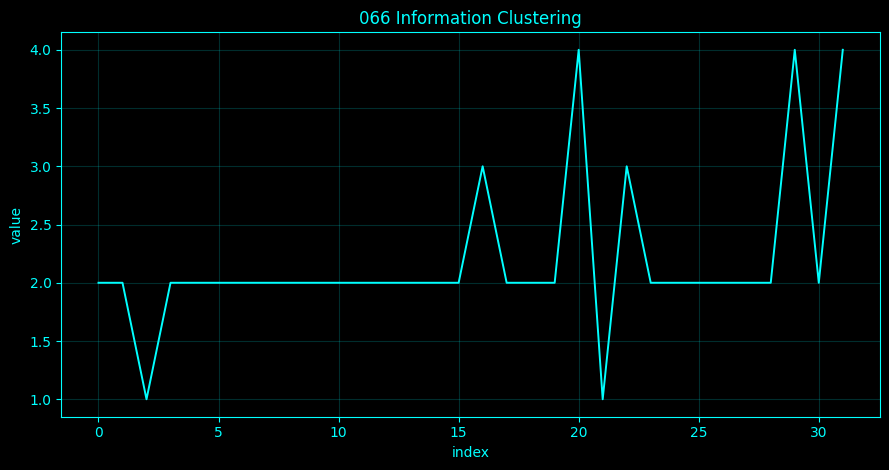

,channel,cluster
0,Fp1,2
1,Fpz,2
2,Fp2,1
3,F7,2
4,F3,2
5,Fz,2
6,F4,2
7,F8,2
8,FC5,2
9,FC1,2


In [69]:
D=np.array([[fr(p,q) for q in CH_P] for p in CH_P]);L=linkage(sp_squareform(D,checks=False),method='average');lab=fcluster(L,t=4,criterion='maxclust');imsave('066_information_clustering',pd.DataFrame({'channel':eeg_channel_names,'cluster':lab}))

### Information-geometric channel fingerprints

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Information-geometric channel fingerprints</h3>
<p>A channel fingerprint combines its Fisher–Rao distance to the global barycenter, Shannon entropy, and normalized band-power composition. These are invariant to the original sample ordering inside the amplitude histogram.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$f_c=(d_{FR}(p_c,\bar p),H(p_c),b_{1c},\ldots,b_{5c}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


channel  FR_to_barycenter  entropy    delta    theta    alpha     beta    gamma
    Fp1          0.268316 3.197951 0.629090 0.188075 0.063799 0.075944 0.043093
    Fpz          0.217621 3.276247 0.625408 0.198660 0.076659 0.064687 0.034586
    Fp2          0.538688 3.163330 0.656509 0.195492 0.063702 0.055630 0.028667
     F7          0.169522 3.356994 0.259745 0.137961 0.171969 0.247558 0.182766
     F3          0.131237 3.347368 0.314234 0.153825 0.176391 0.224297 0.131253
     Fz          0.187864 3.325680 0.415880 0.181083 0.187379 0.145983 0.069676
     F4          0.193959 3.324387 0.360586 0.180548 0.211958 0.166764 0.080144
     F8          0.179619 3.338090 0.306688 0.167335 0.216822 0.195019 0.114136
    FC5          0.233075 3.352086 0.205488 0.129756 0.198237 0.292040 0.174479
    FC1          0.248462 3.311587 0.303273 0.168877 0.247009 0.193179 0.087662
    FC2          0.266989 3.331597 0.302360 0.163657 0.261383 0.191139 0.081461
    FC6          0.258937 3.314776 0.237

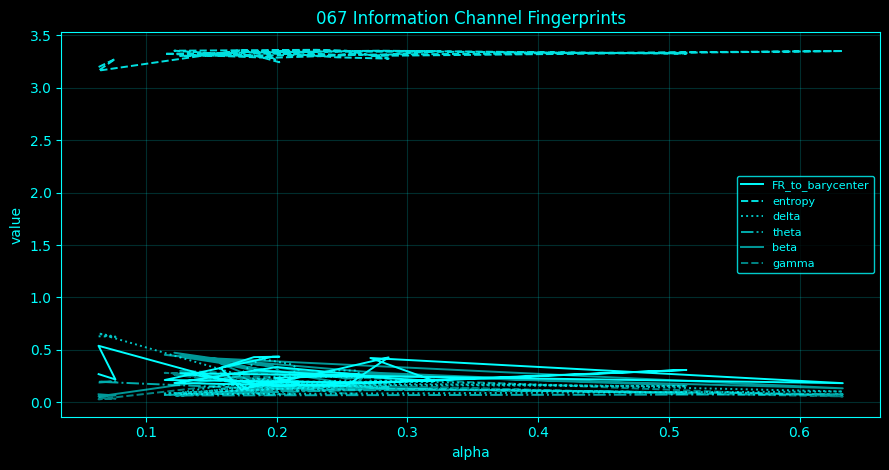

,channel,FR_to_barycenter,entropy,delta,theta,alpha,beta,gamma
0,Fp1,0.268316,3.197951,0.629090,0.188075,0.063799,0.075944,0.043093
1,Fpz,0.217621,3.276247,0.625408,0.198660,0.076659,0.064687,0.034586
2,Fp2,0.538688,3.163330,0.656509,0.195492,0.063702,0.055630,0.028667
3,F7,0.169522,3.356994,0.259745,0.137961,0.171969,0.247558,0.182766
4,F3,0.131237,3.347368,0.314234,0.153825,0.176391,0.224297,0.131253
5,Fz,0.187864,3.325680,0.415880,0.181083,0.187379,0.145983,0.069676
6,F4,0.193959,3.324387,0.360586,0.180548,0.211958,0.166764,0.080144
7,F8,0.179619,3.338090,0.306688,0.167335,0.216822,0.195019,0.114136
8,FC5,0.233075,3.352086,0.205488,0.129756,0.198237,0.292040,0.174479
9,FC1,0.248462,3.311587,0.303273,0.168877,0.247009,0.193179,0.087662


In [70]:
b=fisher_bar(CH_P);rows=[]
for j,p in enumerate(CH_P): rows.append([eeg_channel_names[j],fr(p,b),-np.sum(p*np.log(p+EPS)),*BP_PROB[:,j]])
imsave('067_information_channel_fingerprints',pd.DataFrame(rows,columns=['channel','FR_to_barycenter','entropy']+[x[0] for x in BANDS]))

### Information-geometric phase transition detection

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Information-geometric phase transition detection</h3>
<p>Large intrinsic jumps between consecutive statistical states are candidate change points. The robust z-score uses median absolute deviation; these are data-driven transitions, not physical thermodynamic phase transitions.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$z_k=0.67449\,(d_k-\operatorname{median}d)/\operatorname{MAD}(d).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Standardization subtracts a reference mean and divides by a reference standard deviation. After this transformation, a value of zero corresponds to the reference mean and a value of +1 is one standard deviation above it. This is useful when channels or features have different numerical scales, but it also removes absolute amplitude information. The reference population used to compute the mean and standard deviation therefore matters for interpretation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  FR_jump  robust_z  candidate
  818.071 0.132916 -0.727031      False
  820.571 0.374964  1.398150      False
  825.571 0.532066  2.777514      False
  828.071 0.076507 -1.222303      False
  830.571 0.158648 -0.501107      False
  833.071 0.109304 -0.934346      False
  835.571 0.134110 -0.716553      False
  838.071 0.292542  0.674490      False
  843.071 0.616749  3.521023       True
  845.571 0.182064 -0.295516      False
  848.071 0.241798  0.228956      False
  850.571 0.294875  0.694970      False


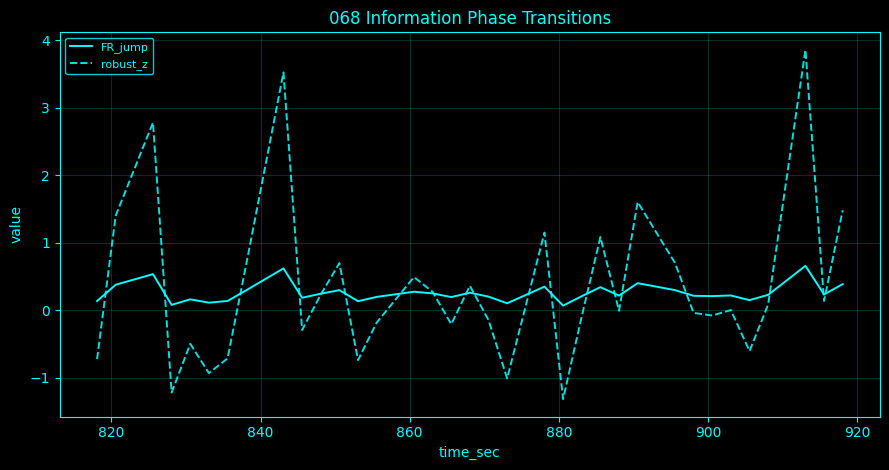

,time_sec,FR_jump,robust_z,candidate
0,818.071,0.132916,-0.727031,False
1,820.571,0.374964,1.398150,False
2,825.571,0.532066,2.777514,False
3,828.071,0.076507,-1.222303,False
4,830.571,0.158648,-0.501107,False
5,833.071,0.109304,-0.934346,False
6,835.571,0.134110,-0.716553,False
7,838.071,0.292542,0.674490,False
8,843.071,0.616749,3.521023,True
9,845.571,0.182064,-0.295516,False


In [71]:
d=np.array([fr(WIN_P[i],WIN_P[i+1]) for i in range(len(WIN_P)-1)]);z=robustz(d);imsave('068_information_phase_transitions',pd.DataFrame({'time_sec':WIN_T[1:],'FR_jump':d,'robust_z':z,'candidate':np.abs(z)>3.5}))

### Optimal transport geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Optimal transport geometry</h3>
<p>Optimal transport compares probability measures while respecting a ground cost. The discrete Kantorovich problem minimizes transport cost over couplings with prescribed marginals.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$W_C(a,b)=\min_{P\ge0}\langle P,C\rangle,\quad P\mathbf1=a,\ P^T\mathbf1=b.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [72]:
p,q=CH_P[0],CH_P[-1];x=.5*(AMP_EDGES[:-1]+AMP_EDGES[1:]);C=np.abs(x[:,None]-x[None,:]);_,v=emd_lp(p,q,C);imsave('069_optimal_transport_geometry',pd.DataFrame({'channel_a':[eeg_channel_names[0]],'channel_b':[eeg_channel_names[-1]],'W1_discrete_LP':[v]}))

channel_a channel_b  W1_discrete_LP
      Fp1        O2        0.232599


,channel_a,channel_b,W1_discrete_LP
0,Fp1,O2,0.232599


### Wasserstein distance between channel distributions

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Wasserstein distance between channel distributions</h3>
<p>For one-dimensional empirical amplitudes, the 1-Wasserstein distance has the exact quantile/CDF interpretation and SciPy evaluates it without histogram discretization.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$W_1(\mu,\nu)=\int_0^1|F_\mu^{-1}(u)-F_\nu^{-1}(u)|du.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


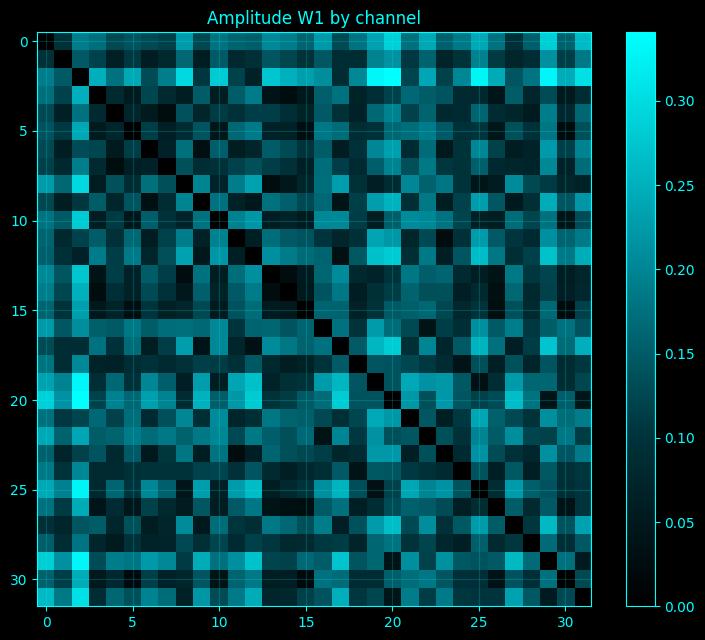

array([[0.        , 0.09615451, 0.19007919, ..., 0.2845782 , 0.15608603,
        0.26221835],
       [0.09615451, 0.        , 0.14714688, ..., 0.21304788, 0.11505619,
        0.18549761],
       [0.19007919, 0.14714688, 0.        , ..., 0.33110538, 0.24564176,
        0.3053691 ],
       ...,
       [0.2845782 , 0.21304788, 0.33110538, ..., 0.        , 0.17488391,
        0.05503022],
       [0.15608603, 0.11505619, 0.24564176, ..., 0.17488391, 0.        ,
        0.12801737],
       [0.26221835, 0.18549761, 0.3053691 , ..., 0.05503022, 0.12801737,
        0.        ]])

In [73]:
D=np.zeros((nC,nC))
for i in range(nC):
 for j in range(i+1,nC):D[i,j]=D[j,i]=wasserstein_distance(EEG_STD[:,i],EEG_STD[:,j])
emit_matrix('070_wasserstein_channel_distributions','Amplitude W1 by channel',D,eeg_channel_names)

### Wasserstein barycenters of EEG states

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Wasserstein barycenters of EEG states</h3>
<p>In one dimension the squared-Wasserstein barycenter has quantile function equal to the weighted mean of the input quantile functions. Equal window weights are used here.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$F_{\bar\mu}^{-1}(u)=N^{-1}\sum_kF_{\mu_k}^{-1}(u).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 quantile_u  barycenter_quantile
   0.004167            -2.462290
   0.012500            -2.104667
   0.020833            -1.905434
   0.029167            -1.767637
   0.037500            -1.657987
   0.045833            -1.563939
   0.054167            -1.484952
   0.062500            -1.415110
   0.070833            -1.352510
   0.079167            -1.295509
   0.087500            -1.242617
   0.095833            -1.192640


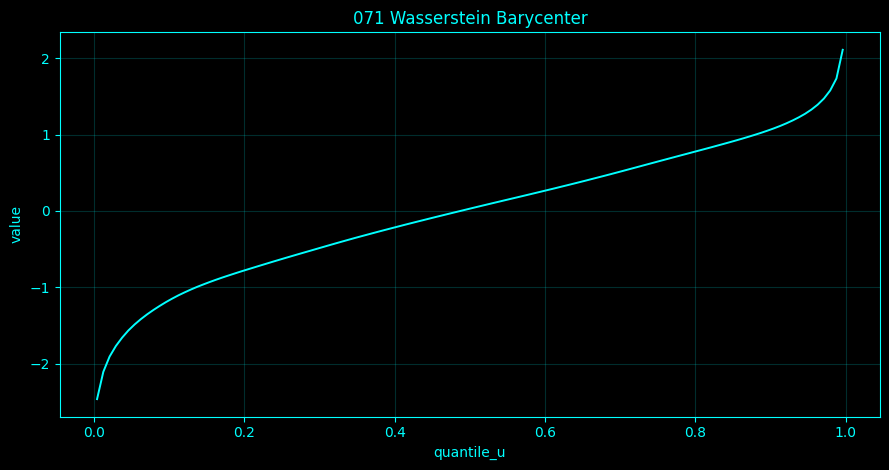

,quantile_u,barycenter_quantile
0,0.004167,-2.462290
1,0.012500,-2.104667
2,0.020833,-1.905434
3,0.029167,-1.767637
4,0.037500,-1.657987
...,...,...
115,0.962500,1.390441
116,0.970833,1.470586
117,0.979167,1.576303
118,0.987500,1.733181


In [74]:
Q=np.stack([empirical_quantiles(EEG_STD[a:b].ravel()) for a,b in np.array(BOUNDS)[widx]]);qb=Q.mean(0);imsave('071_wasserstein_barycenter',pd.DataFrame({'quantile_u':(np.arange(len(qb))+.5)/len(qb),'barycenter_quantile':qb}))

### Wasserstein geodesics between EEG states

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Wasserstein geodesics between EEG states</h3>
<p>For one-dimensional squared-Wasserstein geometry, displacement interpolation is linear in quantile functions and moves at constant W2 speed.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$F_t^{-1}(u)=(1-t)F_0^{-1}(u)+tF_1^{-1}(u).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


   t  W2_from_start  expected_constant_speed
0.00       0.000000                 0.000000
0.05       0.039124                 0.039124
0.10       0.078248                 0.078248
0.15       0.117372                 0.117372
0.20       0.156496                 0.156496
0.25       0.195620                 0.195620
0.30       0.234744                 0.234744
0.35       0.273868                 0.273868
0.40       0.312992                 0.312992
0.45       0.352116                 0.352116
0.50       0.391240                 0.391240
0.55       0.430364                 0.430364


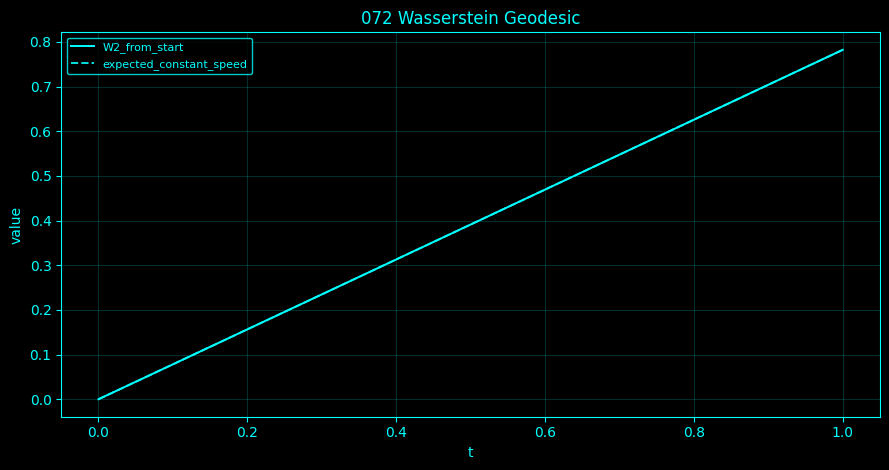

,t,W2_from_start,expected_constant_speed
0,0.00,0.000000,0.000000
1,0.05,0.039124,0.039124
2,0.10,0.078248,0.078248
3,0.15,0.117372,0.117372
4,0.20,0.156496,0.156496
5,0.25,0.195620,0.195620
6,0.30,0.234744,0.234744
7,0.35,0.273868,0.273868
8,0.40,0.312992,0.312992
9,0.45,0.352116,0.352116


In [75]:
q0=Q[0];q1=Q[-1];ts=np.linspace(0,1,21);D=np.sqrt(np.mean((q1-q0)**2));rows=[]
for t in ts: qt=(1-t)*q0+t*q1;rows.append((t,np.sqrt(np.mean((qt-q0)**2)),t*D))
imsave('072_wasserstein_geodesic',pd.DataFrame(rows,columns=['t','W2_from_start','expected_constant_speed']))

### Wasserstein displacement interpolation

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Wasserstein displacement interpolation</h3>
<p>Displacement interpolation transports quantiles rather than linearly mixing probability densities. The cell stores representative interpolated quantiles at several geodesic times.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$Q_t=(1-t)Q_0+tQ_1.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


       u    t_0.00    t_0.20    t_0.40    t_0.60    t_0.80    t_1.00
0.004167 -2.083648 -2.145208 -2.206768 -2.268329 -2.329889 -2.391449
0.012500 -1.781677 -1.831358 -1.881038 -1.930719 -1.980399 -2.030080
0.020833 -1.638656 -1.672141 -1.705625 -1.739110 -1.772594 -1.806079
0.029167 -1.551026 -1.583693 -1.616360 -1.649027 -1.681695 -1.714362
0.037500 -1.478209 -1.513615 -1.549021 -1.584427 -1.619833 -1.655239
0.045833 -1.413012 -1.449642 -1.486272 -1.522902 -1.559533 -1.596163
0.054167 -1.357226 -1.392798 -1.428371 -1.463943 -1.499516 -1.535089
0.062500 -1.309587 -1.342407 -1.375227 -1.408047 -1.440867 -1.473687
0.070833 -1.263815 -1.293474 -1.323133 -1.352792 -1.382451 -1.412110
0.079167 -1.217474 -1.240831 -1.264187 -1.287543 -1.310899 -1.334255
0.087500 -1.175655 -1.186127 -1.196598 -1.207070 -1.217541 -1.228013
0.095833 -1.132002 -1.128589 -1.125176 -1.121764 -1.118351 -1.114939


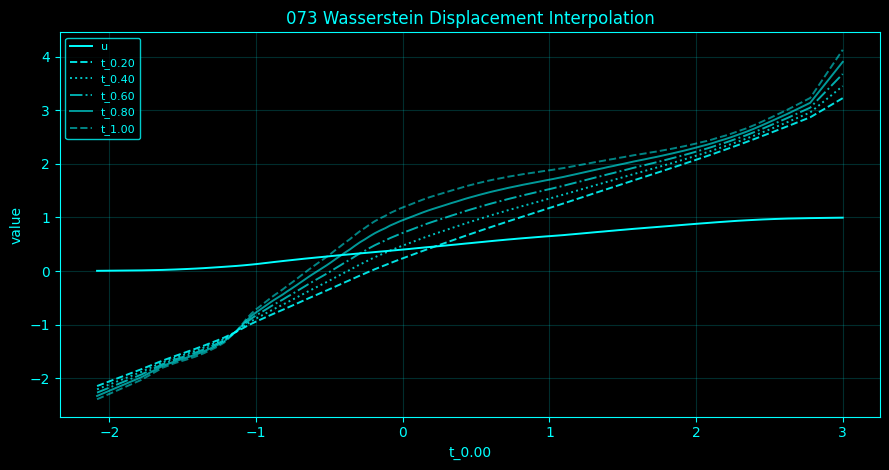

,u,t_0.00,t_0.20,t_0.40,t_0.60,t_0.80,t_1.00
0,0.004167,-2.083648,-2.145208,-2.206768,-2.268329,-2.329889,-2.391449
1,0.012500,-1.781677,-1.831358,-1.881038,-1.930719,-1.980399,-2.030080
2,0.020833,-1.638656,-1.672141,-1.705625,-1.739110,-1.772594,-1.806079
3,0.029167,-1.551026,-1.583693,-1.616360,-1.649027,-1.681695,-1.714362
4,0.037500,-1.478209,-1.513615,-1.549021,-1.584427,-1.619833,-1.655239
...,...,...,...,...,...,...,...
115,0.962500,2.456657,2.524471,2.592285,2.660098,2.727912,2.795725
116,0.970833,2.535829,2.608078,2.680327,2.752576,2.824825,2.897074
117,0.979167,2.628497,2.706400,2.784303,2.862206,2.940109,3.018012
118,0.987500,2.777822,2.867983,2.958145,3.048306,3.138467,3.228628


In [76]:
ts=np.linspace(0,1,6);df=pd.DataFrame({'u':(np.arange(len(q0))+.5)/len(q0)});[df.__setitem__(f't_{t:.2f}',(1-t)*q0+t*q1) for t in ts];imsave('073_wasserstein_displacement_interpolation',df)

### Wasserstein distance matrix by channel

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Wasserstein distance matrix by channel</h3>
<p>The matrix contains exact empirical one-dimensional W2 distances computed from equally sampled quantile functions. It is symmetric, nonnegative, and has zero diagonal.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$W_2^2(\mu,\nu)=\int_0^1|F_\mu^{-1}(u)-F_\nu^{-1}(u)|^2du.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


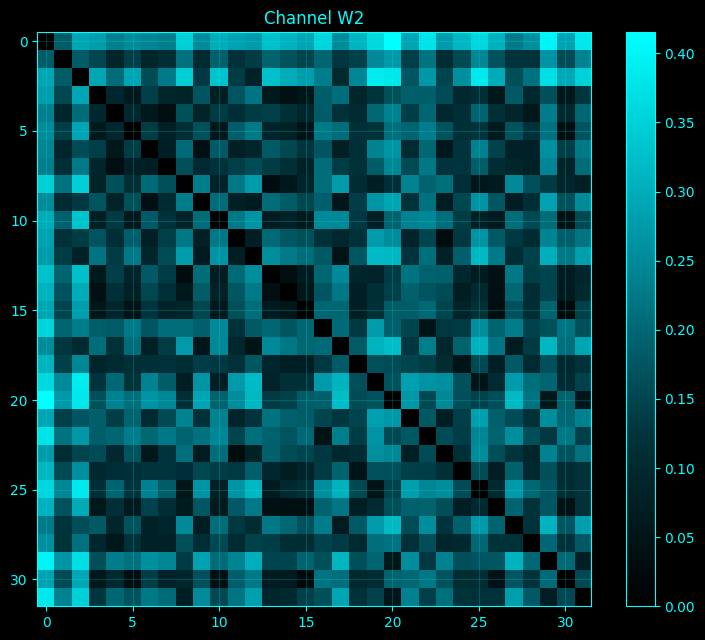

array([[0.        , 0.1848003 , 0.29149374, ..., 0.3995131 , 0.28412794,
        0.38287207],
       [0.1848003 , 0.        , 0.18176618, ..., 0.26464891, 0.15958632,
        0.23881531],
       [0.29149374, 0.18176618, 0.        , ..., 0.37115964, 0.29408567,
        0.35143358],
       ...,
       [0.3995131 , 0.26464891, 0.37115964, ..., 0.        , 0.20446205,
        0.07436286],
       [0.28412794, 0.15958632, 0.29408567, ..., 0.20446205, 0.        ,
        0.15496841],
       [0.38287207, 0.23881531, 0.35143358, ..., 0.07436286, 0.15496841,
        0.        ]])

In [77]:
CQ=np.stack([empirical_quantiles(EEG_STD[:,j]) for j in range(nC)]);D=np.sqrt(np.mean((CQ[:,None,:]-CQ[None,:,:])**2,axis=2));emit_matrix('074_wasserstein_matrix_channel','Channel W2',D,eeg_channel_names)

### Wasserstein distance matrix by region

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Wasserstein distance matrix by region</h3>
<p>Regional amplitude measures pool channels within left, right, and midline sets before computing exact one-dimensional W2 distances.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$W_2^2=\int_0^1(Q_R-Q_S)^2du.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


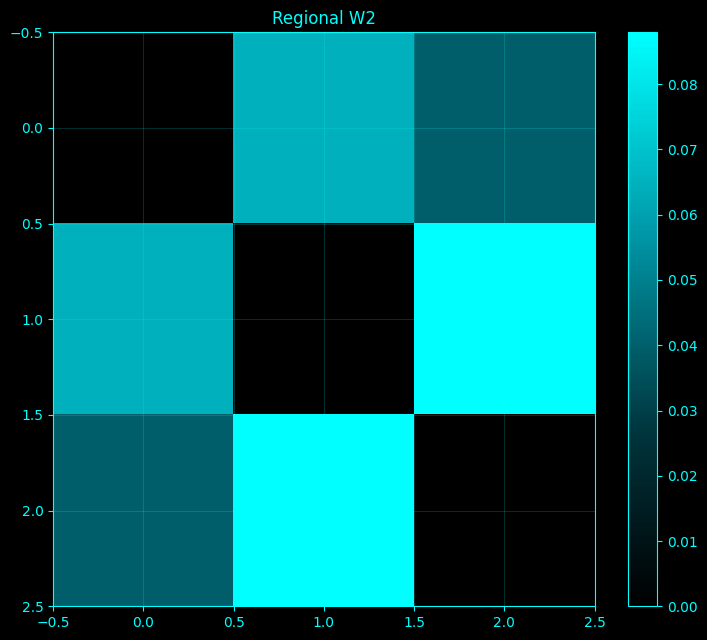

array([[0.        , 0.06463163, 0.03956247],
       [0.06463163, 0.        , 0.08794917],
       [0.03956247, 0.08794917, 0.        ]])

In [78]:
REG={'left':LEFT,'right':RIGHT,'midline':MID};rq={k:empirical_quantiles(EEG_STD[:,v].ravel()) for k,v in REG.items()};labs=list(rq);D=np.array([[np.sqrt(np.mean((rq[a]-rq[b])**2)) for b in labs] for a in labs]);emit_matrix('075_wasserstein_matrix_region','Regional W2',D,labs)

### Wasserstein distance matrix by frequency band

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Wasserstein distance matrix by frequency band</h3>
<p>Each band is represented by the distribution of log band powers across channels. W2 compares those empirical distributions without assuming Gaussianity.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$W_2^2(B_i,B_j)=\int_0^1(Q_i-Q_j)^2du.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


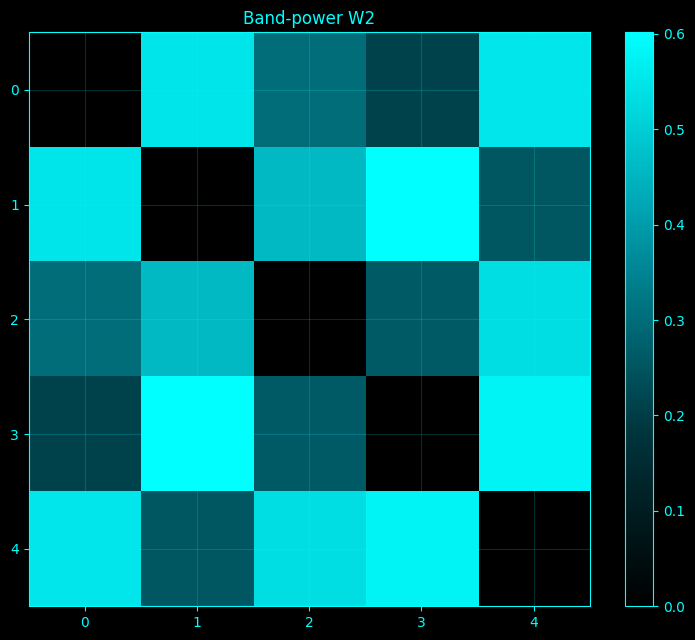

array([[0.        , 0.54773865, 0.30250583, 0.21216632, 0.5514472 ],
       [0.54773865, 0.        , 0.46010864, 0.60162659, 0.25501348],
       [0.30250583, 0.46010864, 0.        , 0.26320376, 0.53551015],
       [0.21216632, 0.60162659, 0.26320376, 0.        , 0.58000365],
       [0.5514472 , 0.25501348, 0.53551015, 0.58000365, 0.        ]])

In [79]:
bq=np.stack([empirical_quantiles(np.log(BP[i]+EPS)) for i in range(len(BANDS))]);D=np.sqrt(np.mean((bq[:,None,:]-bq[None,:,:])**2,axis=2));emit_matrix('076_wasserstein_matrix_band','Band-power W2',D,[b[0] for b in BANDS])

### Wasserstein temporal drift

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Wasserstein temporal drift</h3>
<p>Window-to-window temporal drift is the W2 distance between pooled EEG amplitude measures in consecutive windows.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$\Delta_W(t_k)=W_2(\mu_k,\mu_{k+1}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 time_sec  W2_drift
  818.071  0.084109
  820.571  0.399837
  825.571  0.444064
  828.071  0.026984
  830.571  0.074800
  833.071  0.044770
  835.571  0.090838
  838.071  0.230795
  843.071  0.449339
  845.571  0.131170
  848.071  0.155547
  850.571  0.158970


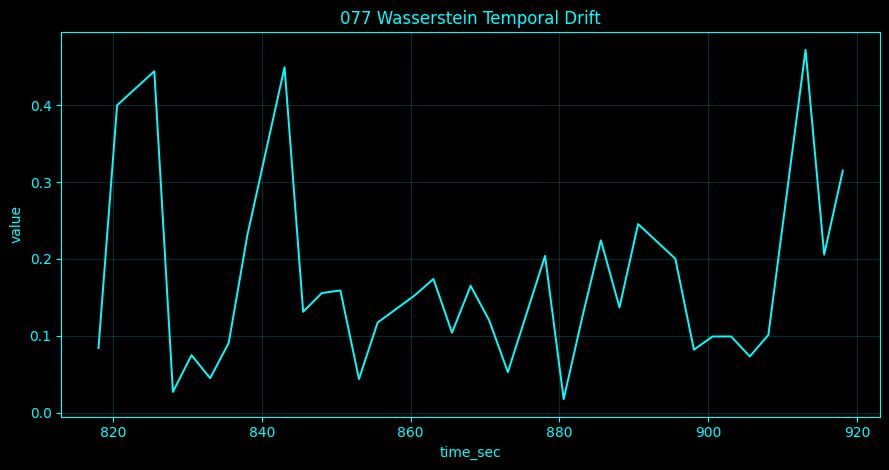

,time_sec,W2_drift
0,818.071,0.084109
1,820.571,0.399837
2,825.571,0.444064
3,828.071,0.026984
4,830.571,0.074800
5,833.071,0.044770
6,835.571,0.090838
7,838.071,0.230795
8,843.071,0.449339
9,845.571,0.131170


In [80]:
v=[w2_1d(EEG_STD[BOUNDS[widx[i]][0]:BOUNDS[widx[i]][1]].ravel(),EEG_STD[BOUNDS[widx[i+1]][0]:BOUNDS[widx[i+1]][1]].ravel()) for i in range(len(widx)-1)];imsave('077_wasserstein_temporal_drift',pd.DataFrame({'time_sec':WIN_T[1:],'W2_drift':v}))

### Wasserstein curvature proxy

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Wasserstein curvature proxy</h3>
<p>A finite metric trajectory has no unique canonical curvature. This cell explicitly uses the turning angle of three consecutive quantile vectors divided by mean W2 step length as a discrete curvature proxy.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$\kappa_k^{proxy}=\theta_k/((\|v_{k-1}\|+\|v_k\|)/2).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  quantile_turning_curvature_proxy
  818.071                          0.719111
  820.571                          0.055060
  825.571                          0.850463
  828.071                          1.348545
  830.571                          1.205295
  833.071                          1.307813
  835.571                          1.444174
  838.071                          0.717994
  843.071                          0.902576
  845.571                          0.401111
  848.071                          1.428389
  850.571                          1.272879


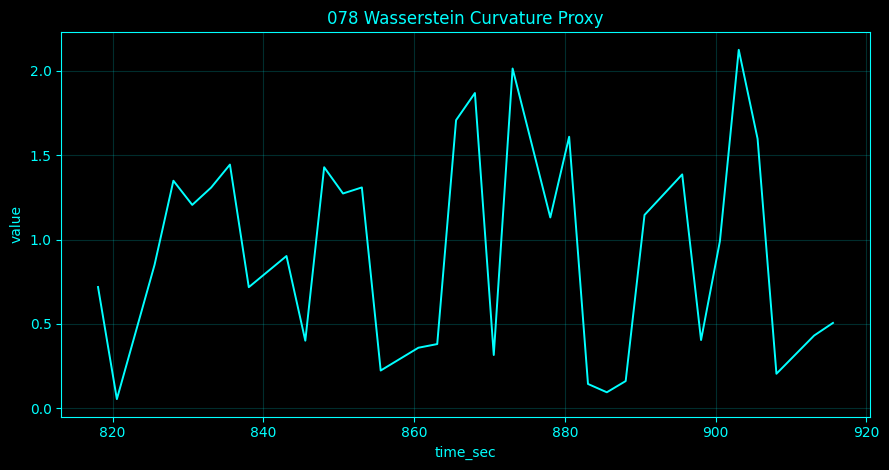

,time_sec,quantile_turning_curvature_proxy
0,818.071,0.719111
1,820.571,0.055060
2,825.571,0.850463
3,828.071,1.348545
4,830.571,1.205295
5,833.071,1.307813
6,835.571,1.444174
7,838.071,0.717994
8,843.071,0.902576
9,845.571,0.401111


In [81]:
QW=np.stack([empirical_quantiles(EEG_STD[a:b].ravel()) for a,b in np.array(BOUNDS)[widx]]);rows=[]
for i in range(1,len(QW)-1):
 u=QW[i]-QW[i-1];v=QW[i+1]-QW[i];ang=np.arccos(np.clip((u@v)/(np.linalg.norm(u)*np.linalg.norm(v)+EPS),-1,1));rows.append((WIN_T[i],ang/(.5*(np.linalg.norm(u)+np.linalg.norm(v))+EPS)))
imsave('078_wasserstein_curvature_proxy',pd.DataFrame(rows,columns=['time_sec','quantile_turning_curvature_proxy']))

### Sinkhorn divergence geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Sinkhorn divergence geometry</h3>
<p>Sinkhorn divergence debiases entropically regularized transport by subtracting the two self-costs. Unlike the raw regularized cost, it vanishes when the two measures are equal.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$S_\varepsilon(a,b)=OT_\varepsilon(a,b)-\tfrac12OT_\varepsilon(a,a)-\tfrac12OT_\varepsilon(b,b).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  sinkhorn_divergence
  818.071             0.007159
  820.571             0.236993
  825.571             0.320547
  828.071             0.002421
  830.571             0.018833
  833.071             0.007549
  835.571             0.011189
  838.071             0.110461
  843.071             0.339476
  845.571             0.057491
  848.071             0.070594
  850.571             0.079582


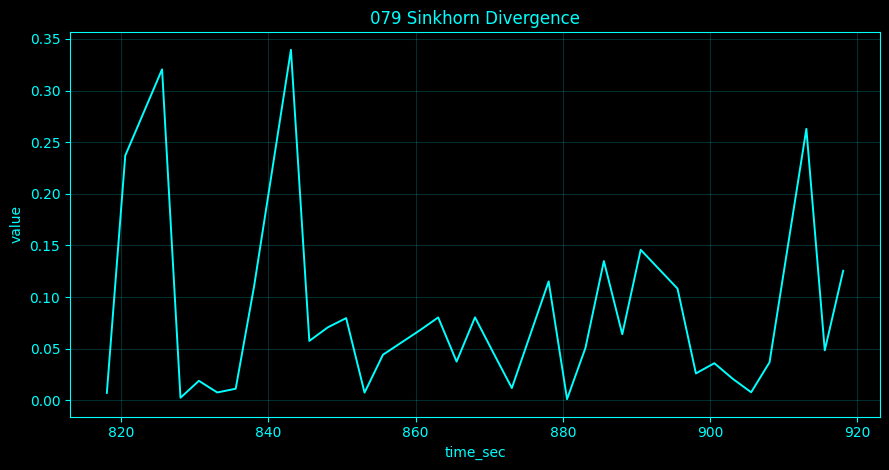

,time_sec,sinkhorn_divergence
0,818.071,0.007159
1,820.571,0.236993
2,825.571,0.320547
3,828.071,0.002421
4,830.571,0.018833
5,833.071,0.007549
6,835.571,0.011189
7,838.071,0.110461
8,843.071,0.339476
9,845.571,0.057491


In [82]:
x=.5*(AMP_EDGES[:-1]+AMP_EDGES[1:]);C=np.abs(x[:,None]-x[None,:]);v=[sink_div(WIN_P[i],WIN_P[i+1],C,.08) for i in range(len(WIN_P)-1)];imsave('079_sinkhorn_divergence',pd.DataFrame({'time_sec':WIN_T[1:],'sinkhorn_divergence':v}))

### Entropic optimal transport geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Entropic optimal transport geometry</h3>
<p>Entropic OT solves the Kantorovich problem with an entropy regularizer. It is computationally smoother but biased relative to unregularized Wasserstein cost, so the raw regularized cost is reported separately from Sinkhorn divergence.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$OT_\varepsilon=\min_P\langle P,C\rangle+\varepsilon\sum_{ij}P_{ij}(\log P_{ij}-1).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  regularized_transport_ground_cost
  818.071                           0.117656
  820.571                           0.347594
  825.571                           0.430956
  828.071                           0.112385
  830.571                           0.128666
  833.071                           0.117536
  835.571                           0.121443
  838.071                           0.220668
  843.071                           0.449397
  845.571                           0.167181
  848.071                           0.180072
  850.571                           0.189208


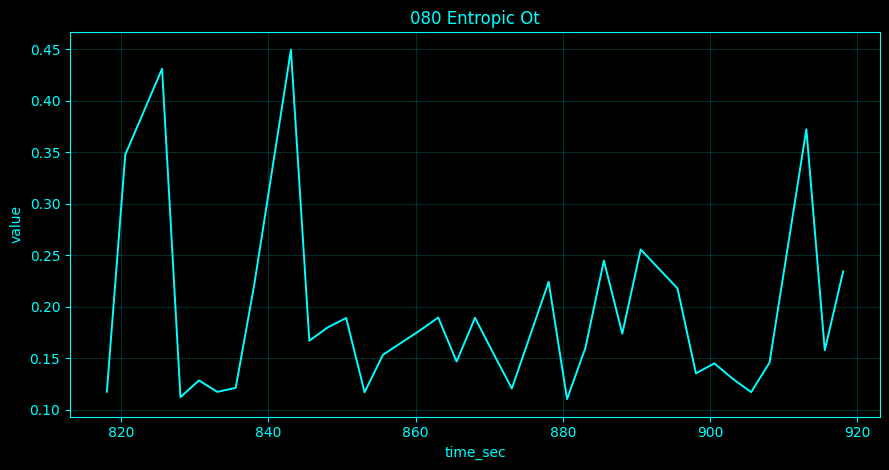

,time_sec,regularized_transport_ground_cost
0,818.071,0.117656
1,820.571,0.347594
2,825.571,0.430956
3,828.071,0.112385
4,830.571,0.128666
5,833.071,0.117536
6,835.571,0.121443
7,838.071,0.220668
8,843.071,0.449397
9,845.571,0.167181


In [83]:
vals=[]
for i in range(len(WIN_P)-1): _,c=sinkhorn(WIN_P[i],WIN_P[i+1],C,.08);vals.append(c)
imsave('080_entropic_ot',pd.DataFrame({'time_sec':WIN_T[1:],'regularized_transport_ground_cost':vals}))

### Gromov-Wasserstein geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Gromov-Wasserstein geometry</h3>
<p>Gromov–Wasserstein compares metric-measure spaces by matching their internal pairwise distances. The finite solver uses a stated Frank–Wolfe-style linearization with entropic transport updates, so the reported value is an optimization approximation rather than a certified global optimum.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$GW^2=\min_T\sum_{ii\prime jj\prime}|C^X_{ii\prime}-C^Y_{jj\prime}|^2T_{ij}T_{i\prime j\prime}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 GW_squared_approx  GW_approx
          0.097976   0.313011


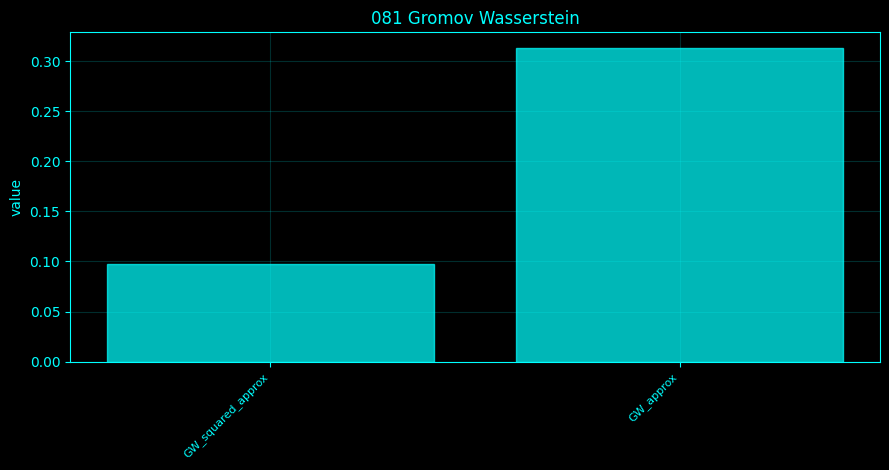

,GW_squared_approx,GW_approx
0,0.097976,0.313011


In [84]:
def gw_approx(C1,C2,a=None,b=None):
 n,m=len(C1),len(C2);a=np.ones(n)/n if a is None else np.asarray(a);b=np.ones(m)/m if b is None else np.asarray(b);T=np.outer(a,b)
 for _ in range(IM_CFG['gw']):
  # gradient of squared-loss GW up to terms independent of T
  const1=(C1*C1)@a;const2=(C2*C2)@b;M=const1[:,None]+const2[None,:]-2*C1@T@C2.T
  S,_=sinkhorn(a,b,np.maximum(M-M.min(),0),.05,niter=max(40,IM_CFG['sink']//2));T=.5*T+.5*S
 val=0.0
 # exact contraction of final coupling
 diff=C1[:,:,None,None]-C2[None,None,:,:];val=float(np.sum((diff*diff)*(T[:,None,:,None]*T[None,:,None,:])))
 return T,max(val,0.0)
# compare left/right regional scalp subspaces with band-power masses
LX=SCALP[LEFT];RX=SCALP[RIGHT];C1=cdist(LX,LX);C2=cdist(RX,RX);a=BP[:,LEFT].sum(0);b=BP[:,RIGHT].sum(0);a/=a.sum();b/=b.sum();_,gv=gw_approx(C1,C2,a,b);imsave('081_gromov_wasserstein',pd.DataFrame({'GW_squared_approx':[gv],'GW_approx':[np.sqrt(gv)]}))

### Fused Gromov-Wasserstein channel geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Fused Gromov-Wasserstein channel geometry</h3>
<p>Fused GW combines structural mismatch with feature mismatch. The implementation reports the final approximate structural GW term and the feature transport term under the same coupling, with an explicit alpha mixing weight.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$FGW_\alpha=(1-\alpha)\langle T,M_{feat}\rangle+\alpha\,GW(T).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Wasserstein distance between persistence diagrams also matches topological features, but it aggregates matching costs rather than keeping only the largest one. The order parameter determines how strongly large discrepancies are emphasized. As with the bottleneck distance, matching to the diagonal represents treating a short-lived feature in one diagram as absent in the other.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 alpha  feature_term  GW_squared_term  fused_objective_approx
   0.5      0.155935         0.097976                0.126956


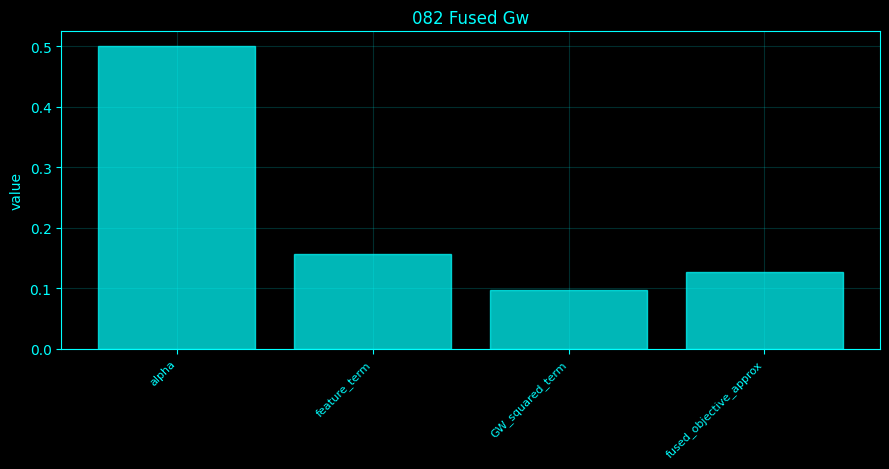

,alpha,feature_term,GW_squared_term,fused_objective_approx
0,0.5,0.155935,0.097976,0.126956


In [85]:
T,gv=gw_approx(C1,C2,a,b);feat=cdist(BP_PROB[:,LEFT].T,BP_PROB[:,RIGHT].T);fv=float(np.sum(T*feat));alpha=.5;imsave('082_fused_gw',pd.DataFrame({'alpha':[alpha],'feature_term':[fv],'GW_squared_term':[gv],'fused_objective_approx':[(1-alpha)*fv+alpha*gv]}))

### Optimal-transport topographic geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Optimal-transport topographic geometry</h3>
<p>A topomap is treated as nonnegative mass over electrode locations. Transport cost uses Euclidean distance in the explicitly defined 2-D scalp projection. Positive band power is used as mass, avoiding signed-potential transport ambiguities.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$W_1(a,b)=\min_T\sum_{ij}T_{ij}\|r_i-r_j\|_2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [86]:
aa=BP[2]/BP[2].sum();bb=BP[3]/BP[3].sum();_,v=emd_lp(aa,bb,SCALP_C);imsave('083_ot_topographic',pd.DataFrame({'map_a':['alpha_power'],'map_b':['beta_power'],'scalp_EMD':[v]}))

      map_a      map_b  scalp_EMD
alpha_power beta_power    0.28264


,map_a,map_b,scalp_EMD
0,alpha_power,beta_power,0.28264


### Optimal-transport spectrogram geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Optimal-transport spectrogram geometry</h3>
<p>Each time window is represented by a nonnegative Welch spectrum normalized over frequency. One-dimensional W1 on frequency gives the minimum frequency-axis work required to transform one spectrum into the next.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$W_1(S_t,S_{t+1})=\int|F_t(f)-F_{t+1}(f)|df.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  spectral_W1_Hz
  818.071        7.867544
  820.571        5.317008
  825.571        2.058537
  828.071        4.022239
  830.571        1.917629
  833.071        3.285809
  835.571        2.343256
  838.071        3.302680
  843.071        1.127175
  845.571        2.720547
  848.071        0.886994
  850.571        1.008264


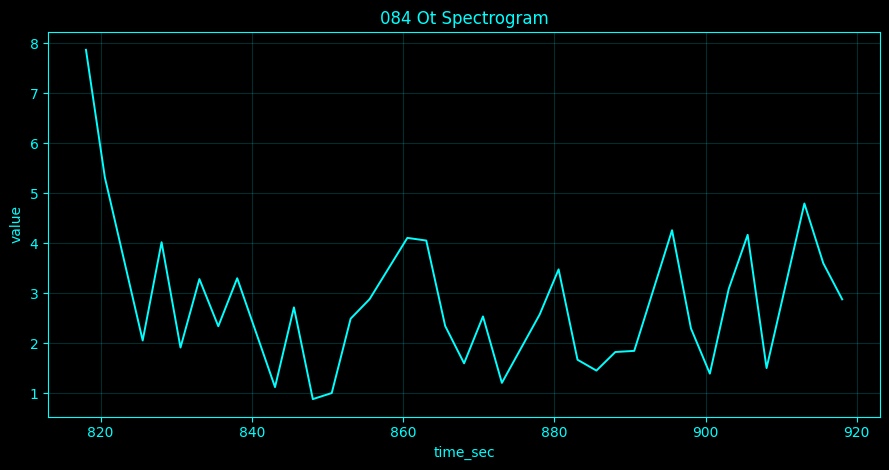

,time_sec,spectral_W1_Hz
0,818.071,7.867544
1,820.571,5.317008
2,825.571,2.058537
3,828.071,4.022239
4,830.571,1.917629
5,833.071,3.285809
6,835.571,2.343256
7,838.071,3.302680
8,843.071,1.127175
9,845.571,2.720547


In [87]:
spec=[];freq=None
for ii in widx:
 a,b=BOUNDS[ii];freq,P=signal.welch(EEG_STD[a:b].mean(1),fs=sampling_rate,nperseg=min(512,b-a));m=(freq>=1)&(freq<=45);pp=P[m]+EPS;pp/=pp.sum();spec.append(pp)
freq=freq[m];v=[wasserstein_distance(freq,freq,u_weights=spec[i],v_weights=spec[i+1]) for i in range(len(spec)-1)];imsave('084_ot_spectrogram',pd.DataFrame({'time_sec':WIN_T[1:],'spectral_W1_Hz':v}))

### Optimal-transport scalogram geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Optimal-transport scalogram geometry</h3>
<p>A wavelet scalogram is reduced to its nonnegative marginal mass across scales. Transport along log-scale compares where oscillatory energy is concentrated without assuming aligned peaks.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$W_1(\mu_s,\nu_s)=\min_T\sum_{ij}T_{ij}|\log s_i-\log s_j|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  log_scale_W1
  818.071      0.302934
  820.571      0.470101
  825.571      0.120469
  828.071      0.139714
  830.571      0.209301
  833.071      0.284980
  835.571      0.318431
  838.071      0.306915
  843.071      0.264194
  845.571      0.265737
  848.071      0.109418
  850.571      0.200902


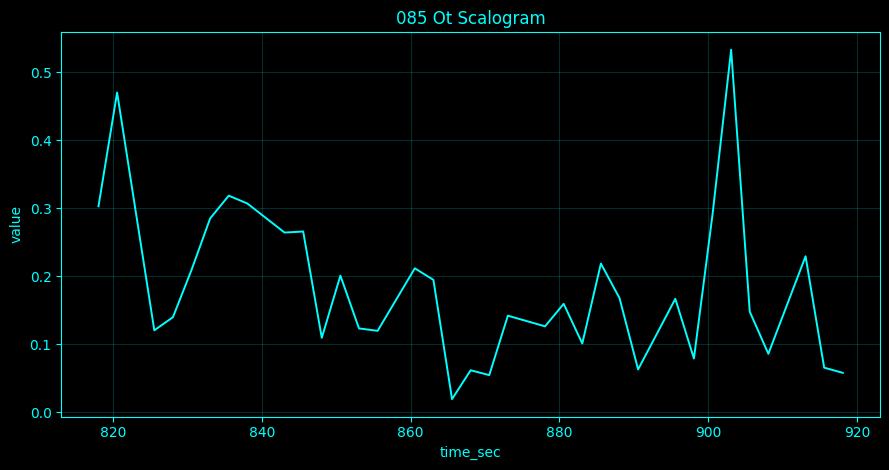

,time_sec,log_scale_W1
0,818.071,0.302934
1,820.571,0.470101
2,825.571,0.120469
3,828.071,0.139714
4,830.571,0.209301
5,833.071,0.284980
6,835.571,0.318431
7,838.071,0.306915
8,843.071,0.264194
9,845.571,0.265737


In [88]:
widths=np.arange(2,66);sc=[]
def _ricker_cwt_energy(x,widths):
 out=[]
 for w in widths:
  L=min(len(x) if len(x)%2 else len(x)-1,int(10*w+1));L=max(7,L|1);tt=np.arange(L)-L//2;z=tt/float(w);psi=(1-z*z)*np.exp(-.5*z*z);psi/=np.sqrt(np.sum(psi*psi)+EPS);cv=signal.fftconvolve(x,psi[::-1],mode='same');out.append(np.mean(cv*cv))
 return np.asarray(out)
for ii in widx:
 a,b=BOUNDS[ii];x=EEG_STD[a:b].mean(1);p=_ricker_cwt_energy(x,widths)+EPS;p/=p.sum();sc.append(p)
v=[wasserstein_distance(np.log(widths),np.log(widths),u_weights=sc[i],v_weights=sc[i+1]) for i in range(len(sc)-1)];imsave('085_ot_scalogram',pd.DataFrame({'time_sec':WIN_T[1:],'log_scale_W1':v}))

### Earth-mover geometry of bandpower topomaps

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Earth-mover geometry of bandpower topomaps</h3>
<p>Each canonical frequency band defines a positive scalp mass distribution. Exact balanced Earth-mover distance is solved by linear programming using the scalp ground metric.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$EMD(a,b)=\min_{T\mathbf1=a,T^T\mathbf1=b}\langle T,C_{scalp}\rangle.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


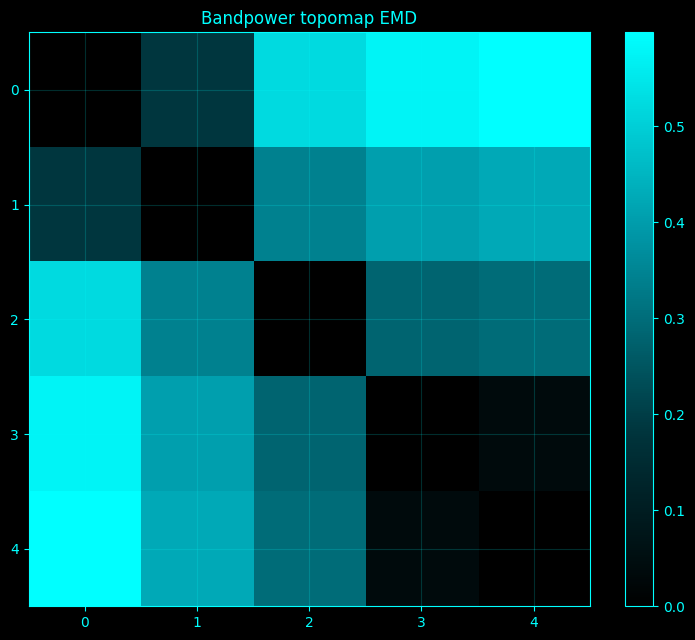

array([[0.        , 0.18472953, 0.52408051, 0.57635998, 0.59799277],
       [0.18472953, 0.        , 0.34181956, 0.40489677, 0.42682927],
       [0.52408051, 0.34181956, 0.        , 0.28263965, 0.29769783],
       [0.57635998, 0.40489677, 0.28263965, 0.        , 0.0390348 ],
       [0.59799277, 0.42682927, 0.29769783, 0.0390348 , 0.        ]])

In [89]:
labs=[b[0] for b in BANDS];D=np.zeros((len(labs),len(labs)))
for i in range(len(labs)):
 for j in range(i+1,len(labs)):
  _,D[i,j]=emd_lp(BP[i],BP[j],SCALP_C);D[j,i]=D[i,j]
emit_matrix('086_earth_mover_bandpower_topomaps','Bandpower topomap EMD',D,labs)

### Metric geometry of EEG embeddings

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Metric geometry of EEG embeddings</h3>
<p>The PCA state cloud is treated as a finite metric space with Euclidean distance. Subsequent finite-metric quantities depend only on this distance matrix unless explicitly stated otherwise.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$d_{ij}=\|z_i-z_j\|_2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  radius_from_centroid
  815.571              1.099473
  818.071              4.258038
  820.571              2.759894
  823.071              1.057414
  825.571              0.734068
  828.071              1.098782
  830.571              1.261275
  833.071              1.058828
  835.571              4.304536
  838.071              1.398826
  840.571              1.028923
  843.071              1.698878


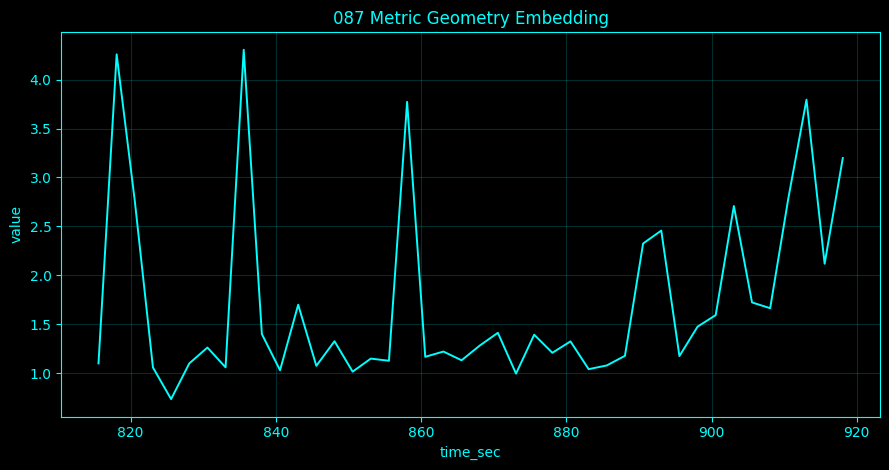

,time_sec,radius_from_centroid
0,815.571,1.099473
1,818.071,4.258038
2,820.571,2.759894
3,823.071,1.057414
4,825.571,0.734068
5,828.071,1.098782
6,830.571,1.261275
7,833.071,1.058828
8,835.571,4.304536
9,838.071,1.398826


In [90]:
imsave('087_metric_geometry_embedding',pd.DataFrame({'time_sec':ZT,'radius_from_centroid':np.linalg.norm(ZM-ZM.mean(0),axis=1)}))

### Gromov hyperbolicity

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Gromov hyperbolicity</h3>
<p>For a finite metric space, four-point hyperbolicity is half the gap between the largest and second-largest of the three opposite-pair sums. The maximum over sampled quadruples estimates delta.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$\delta(a,b,c,d)=\tfrac12(S_{max}-S_{mid}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 delta_max_sampled  diameter  delta_over_diameter
          1.304057  7.890885             0.165261


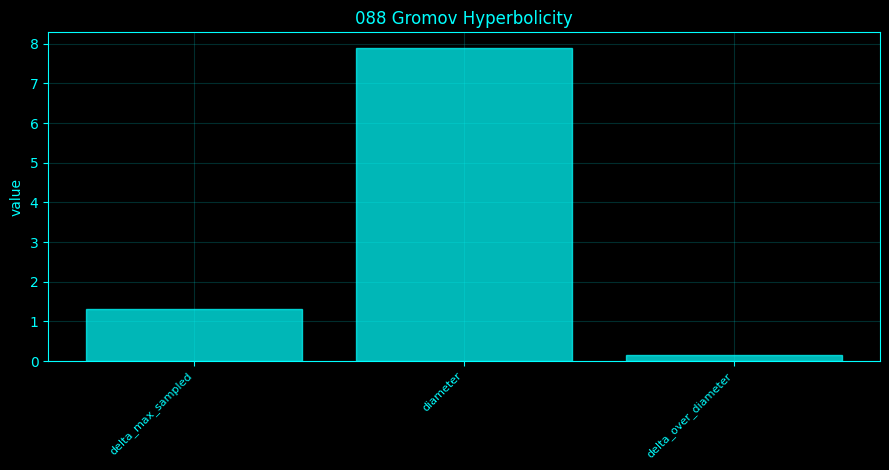

,delta_max_sampled,diameter,delta_over_diameter
0,1.304057,7.890885,0.165261


In [91]:
def delta4(D,quad=None):
 n=len(D);q=IM_CFG['quad'] if quad is None else quad;mx=0.;vals=[]
 for _ in range(q):
  a,b,c,d=RNG.choice(n,4,replace=False);s=sorted([D[a,b]+D[c,d],D[a,c]+D[b,d],D[a,d]+D[b,c]]);v=.5*(s[2]-s[1]);vals.append(v);mx=max(mx,v)
 return mx,np.asarray(vals)
delmax,delv=delta4(DG);imsave('088_gromov_hyperbolicity',pd.DataFrame({'delta_max_sampled':[delmax],'diameter':[np.nanmax(DG[np.isfinite(DG)])],'delta_over_diameter':[delmax/(np.nanmax(DG[np.isfinite(DG)])+EPS)]}))

### Four-point condition hyperbolicity

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Four-point condition hyperbolicity</h3>
<p>The four-point condition is the operational finite-metric definition used to estimate Gromov hyperbolicity. This cell reports its sampled distribution rather than only the maximum.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$2\delta=S_{max}-S_{mid}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 delta_four_point
         0.042072
         0.561961
         0.238242
         0.129012
         0.365418
         1.172398
         0.441180
         0.094889
         0.228635
         0.380100
         0.105639
         0.010703


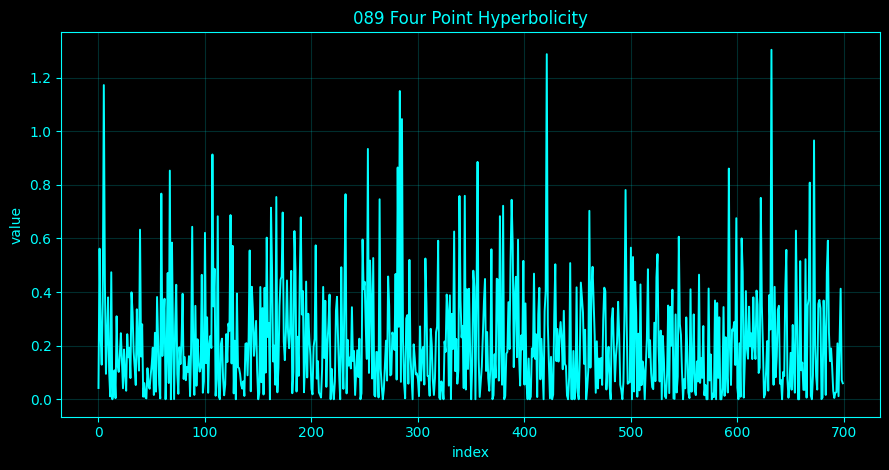

,delta_four_point
0,0.042072
1,0.561961
2,0.238242
3,0.129012
4,0.365418
...,...
695,0.011604
696,0.205263
697,0.412446
698,0.071047


In [92]:
imsave('089_four_point_hyperbolicity',pd.DataFrame({'delta_four_point':delv}))

### δ-hyperbolicity by channel

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — δ-hyperbolicity by channel</h3>
<p>Each channel is delay-embedded into three dimensions and its finite geodesic metric is tested with the same four-point delta estimator. Results are sample-resolution dependent.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$z_t=(x_t,x_{t-\tau},x_{t-2\tau}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


channel    delta  delta_over_diameter
    Fp1 0.617917             0.052536
    Fpz 0.429071             0.057407
    Fp2 0.303687             0.038467
     F7 0.942346             0.130155
     F3 0.971737             0.143028
     Fz 0.909872             0.125816
     F4 0.832124             0.106239
     F8 0.840697             0.101552
    FC5 0.986100             0.148893
    FC1 0.709756             0.096593
    FC2 1.120797             0.139075
    FC6 0.518600             0.068648


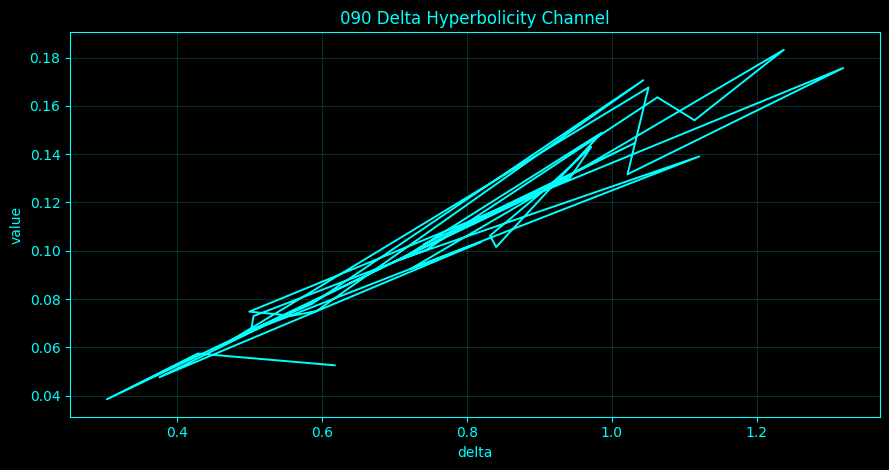

,channel,delta,delta_over_diameter
0,Fp1,0.617917,0.052536
1,Fpz,0.429071,0.057407
2,Fp2,0.303687,0.038467
3,F7,0.942346,0.130155
4,F3,0.971737,0.143028
5,Fz,0.909872,0.125816
6,F4,0.832124,0.106239
7,F8,0.840697,0.101552
8,FC5,0.986100,0.148893
9,FC1,0.709756,0.096593


In [93]:
rows=[];lag=max(2,int(.01*sampling_rate));take=min(180,IM_CFG['metric_pts'])
for j in range(nC):
 x=EEG_STD[:,j];idxc=np.linspace(2*lag,len(x)-1,take).astype(int);Zc=np.c_[x[idxc],x[idxc-lag],x[idxc-2*lag]];Dc=cdist(Zc,Zc);Gc=geod_matrix(Dc,min(8,len(Dc)-1));dd,_=delta4(Gc,min(250,IM_CFG['quad']));diam=np.nanmax(Gc[np.isfinite(Gc)]);rows.append((eeg_channel_names[j],dd,dd/(diam+EPS)))
imsave('090_delta_hyperbolicity_channel',pd.DataFrame(rows,columns=['channel','delta','delta_over_diameter']))

### Metric tree-likeness

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Metric tree-likeness</h3>
<p>Trees are 0-hyperbolic, so normalized four-point delta provides a scale-free finite-sample tree-likeness diagnostic: smaller delta/diameter means closer to a tree metric.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$T=1-\delta/\operatorname{diam}(X).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 delta_over_diameter  tree_likeness_score
            0.165261             0.834739


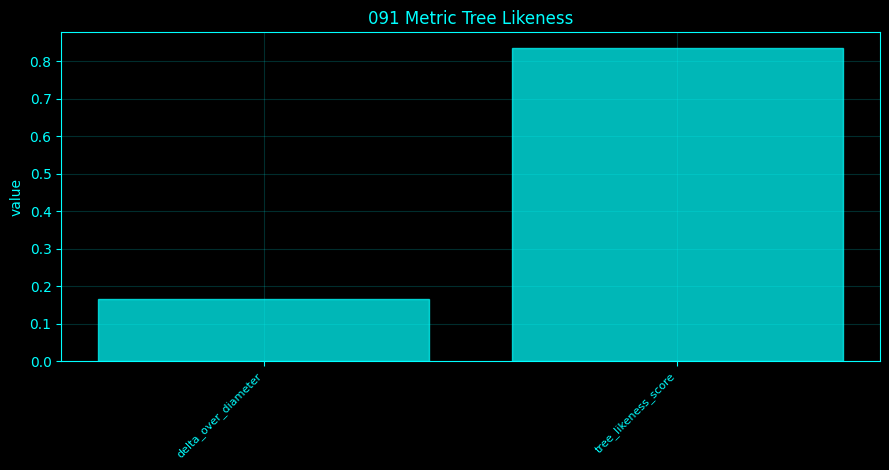

,delta_over_diameter,tree_likeness_score
0,0.165261,0.834739


In [94]:
diam=np.nanmax(DG[np.isfinite(DG)]);imsave('091_metric_tree_likeness',pd.DataFrame({'delta_over_diameter':[delmax/(diam+EPS)],'tree_likeness_score':[1-delmax/(diam+EPS)]}))

### Metric ultrametricity

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Metric ultrametricity</h3>
<p>In an ultrametric triangle, the two largest side lengths are equal. The cell samples triangles and reports one minus their relative largest-side mismatch, bounded near one for strongly ultrametric data.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$u=1-(d_{(3)}-d_{(2)})/(d_{(3)}+\epsilon).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 ultrametricity_score
             0.755143
             0.876964
             0.937952
             0.987832
             0.976998
             0.914443
             0.976406
             0.767382
             0.996368
             0.554661
             0.969638
             0.699026


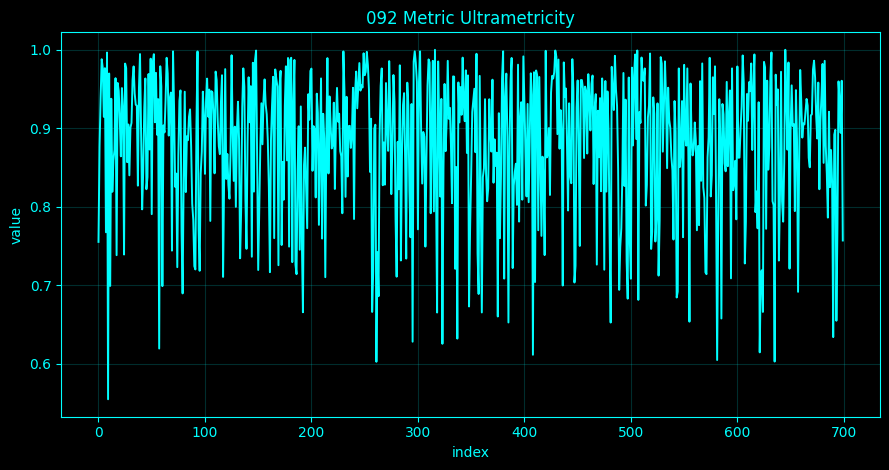

,ultrametricity_score
0,0.755143
1,0.876964
2,0.937952
3,0.987832
4,0.976998
...,...
695,0.959583
696,0.934568
697,0.894000
698,0.960368


In [95]:
u=[]
for _ in range(IM_CFG['quad']):
 a,b,c=RNG.choice(len(DE),3,replace=False);s=sorted([DE[a,b],DE[a,c],DE[b,c]]);u.append(1-(s[2]-s[1])/(s[2]+EPS))
imsave('092_metric_ultrametricity',pd.DataFrame({'ultrametricity_score':u}))

### Metric doubling dimension

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Metric doubling dimension</h3>
<p>A doubling-dimension estimate uses the maximum local ratio of covering numbers between radius r and r/2. Finite sampling makes this an empirical estimate, not an exact manifold dimension.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$d_{dbl}=\log_2\sup_{x,r} N(B(x,r),r/2).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


  radius  doubling_dimension_estimate
1.011893                     3.584963
1.308827                     3.906891
1.748434                     3.584963


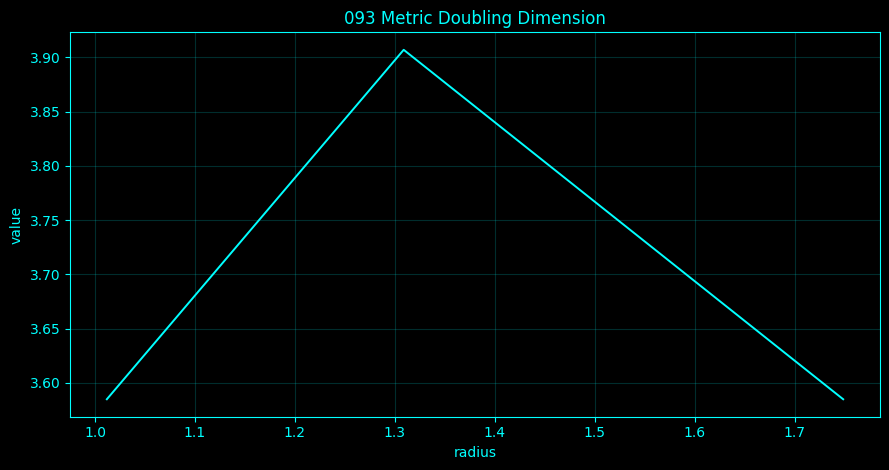

,radius,doubling_dimension_estimate
0,1.011893,3.584963
1,1.308827,3.906891
2,1.748434,3.584963


In [96]:
radii=np.quantile(DE[DE>0],[.15,.25,.4]);vals=[]
for r in radii:
 counts=[]
 for i in range(len(DE)):
  ids=np.where(DE[i]<=r)[0];chosen=[]
  for q in ids:
   if all(DE[q,c]>r/2 for c in chosen):chosen.append(q)
  counts.append(max(1,len(chosen)))
 vals.append(np.log2(max(counts)))
imsave('093_metric_doubling_dimension',pd.DataFrame({'radius':radii,'doubling_dimension_estimate':vals}))

### Metric entropy curves

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Metric entropy curves</h3>
<p>Metric entropy is the logarithm of a covering number. A greedy epsilon-net provides an upper-bound style finite-sample covering estimate across scales.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$H_\epsilon(X)=\log N_\epsilon(X).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 epsilon  covering_number  metric_entropy_logN
0.687809               28             3.332205
0.804531               26             3.258097
0.941061               22             3.091042
1.100761               19             2.944439
1.287561               15             2.708050
1.506062               14             2.639057
1.761642               11             2.397895
2.060595                7             1.945910
2.410281                6             1.791759
2.819309                4             1.386294
3.297749                2             0.693147
3.857381                2             0.693147


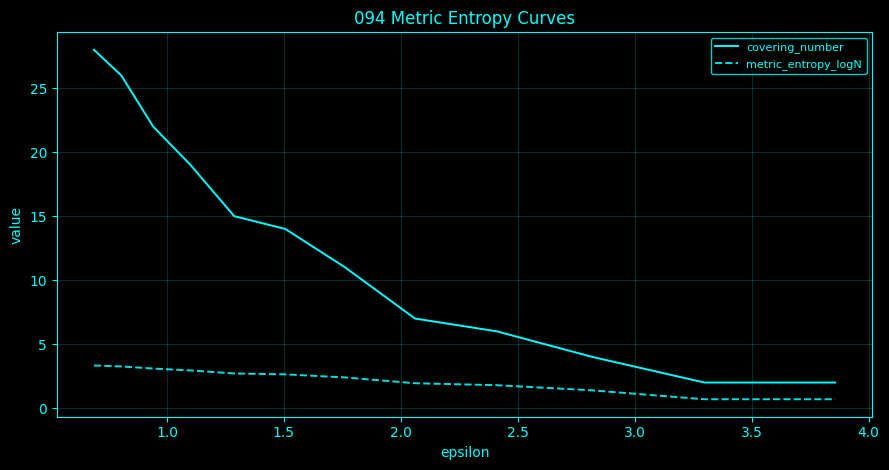

,epsilon,covering_number,metric_entropy_logN
0,0.687809,28,3.332205
1,0.804531,26,3.258097
2,0.941061,22,3.091042
3,1.100761,19,2.944439
4,1.287561,15,2.708050
5,1.506062,14,2.639057
6,1.761642,11,2.397895
7,2.060595,7,1.945910
8,2.410281,6,1.791759
9,2.819309,4,1.386294


In [97]:
def greedy_cover(D,eps):
 uncovered=set(range(len(D)));cent=[]
 while uncovered:
  i=next(iter(uncovered));cent.append(i);uncovered.difference_update(np.where(D[i]<=eps)[0].tolist())
 return cent
rr=np.geomspace(max(np.quantile(DE[DE>0],.05),1e-6),np.quantile(DE[DE>0],.8),12);nn=[len(greedy_cover(DE,r)) for r in rr];imsave('094_metric_entropy_curves',pd.DataFrame({'epsilon':rr,'covering_number':nn,'metric_entropy_logN':np.log(nn)}))

### Covering number geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Covering number geometry</h3>
<p>The epsilon-covering number is the minimum number of radius-epsilon balls needed to cover the set. Exact minimum set cover is expensive, so the cell clearly reports the greedy covering count.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$N_\epsilon(X)=\min\{m:X\subset\cup_{i=1}^mB(x_i,\epsilon)\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 epsilon  greedy_covering_number
0.687809                      28
0.804531                      26
0.941061                      22
1.100761                      19
1.287561                      15
1.506062                      14
1.761642                      11
2.060595                       7
2.410281                       6
2.819309                       4
3.297749                       2
3.857381                       2


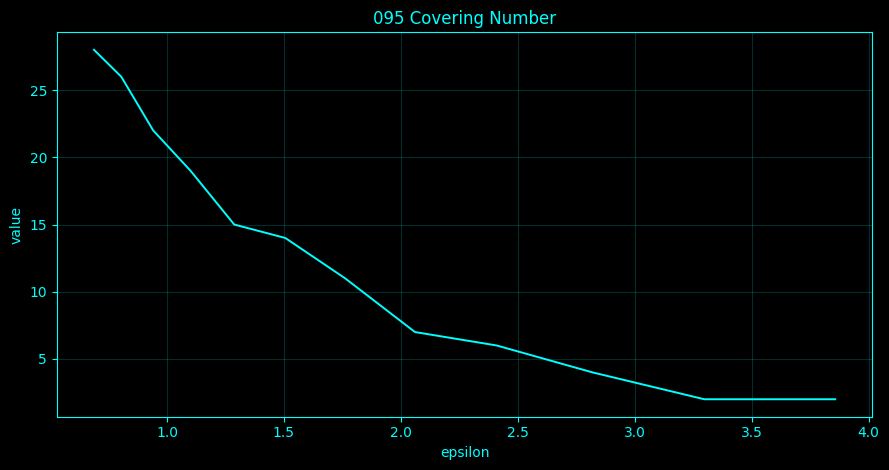

,epsilon,greedy_covering_number
0,0.687809,28
1,0.804531,26
2,0.941061,22
3,1.100761,19
4,1.287561,15
5,1.506062,14
6,1.761642,11
7,2.060595,7
8,2.410281,6
9,2.819309,4


In [98]:
imsave('095_covering_number',pd.DataFrame({'epsilon':rr,'greedy_covering_number':nn}))

### Packing number geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Packing number geometry</h3>
<p>A greedy epsilon-separated set gives a maximal packing: every selected pair is farther than epsilon. Maximal is not necessarily maximum, so the finite algorithm is labelled accordingly.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$P_\epsilon(X)=\max\{|S|:d(x,y)>\epsilon\;\forall x\ne y\in S\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 epsilon  greedy_maximal_packing
0.687809                      28
0.804531                      26
0.941061                      22
1.100761                      19
1.287561                      15
1.506062                      14
1.761642                      11
2.060595                       7
2.410281                       6
2.819309                       4
3.297749                       2
3.857381                       2


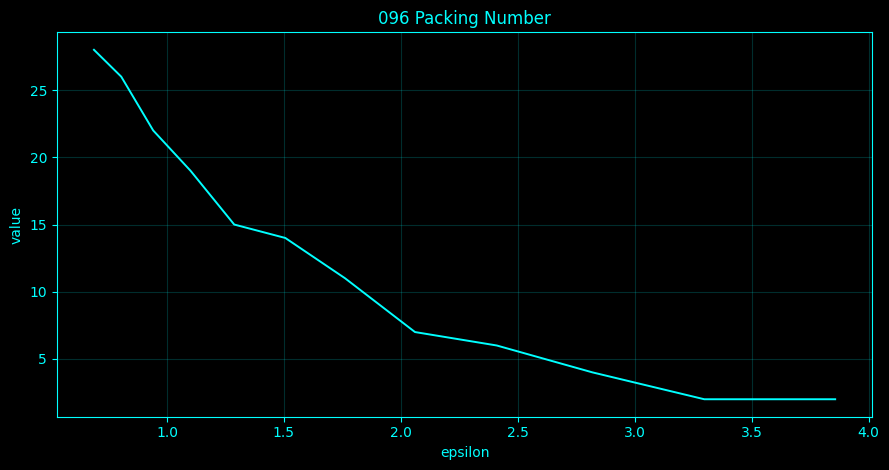

,epsilon,greedy_maximal_packing
0,0.687809,28
1,0.804531,26
2,0.941061,22
3,1.100761,19
4,1.287561,15
5,1.506062,14
6,1.761642,11
7,2.060595,7
8,2.410281,6
9,2.819309,4


In [99]:
def greedy_pack(D,e):
 chosen=[]
 for i in range(len(D)):
  if all(D[i,j]>e for j in chosen):chosen.append(i)
 return chosen
imsave('096_packing_number',pd.DataFrame({'epsilon':rr,'greedy_maximal_packing': [len(greedy_pack(DE,r)) for r in rr]}))

### Reach estimation

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Reach estimation</h3>
<p>Reach is the distance from a set to its medial axis and is not exactly identifiable from a sparse point cloud. The cell reports an explicitly labelled local-curvature/self-approach proxy based on nonadjacent near-neighbours of the ordered trajectory.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$\operatorname{reach}(M)=\inf_{y\in Med(M)}d(y,M).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [100]:
adj=3;mins=[]
for i in range(len(ZM)):
 valid=np.r_[np.arange(0,max(0,i-adj)),np.arange(min(len(ZM),i+adj+1),len(ZM))];
 if len(valid):mins.append(np.min(DE[i,valid]))
reach_proxy=.5*np.quantile(mins,.1);imsave('097_reach_estimation',pd.DataFrame({'reach_proxy':[reach_proxy],'definition':['half 10th-percentile nonlocal self-approach']}))

 reach_proxy                                  definition
    0.168849 half 10th-percentile nonlocal self-approach


,reach_proxy,definition
0,0.168849,half 10th-percentile nonlocal self-approach


### Condition number of manifold

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Condition number of manifold</h3>
<p>Federer’s geometric condition number is the reciprocal of reach. Because reach is only estimated from the finite EEG state cloud, this cell reports the reciprocal of the stated reach proxy.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$\kappa_M=1/\operatorname{reach}(M).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 reach_proxy  condition_number_proxy
    0.168849                5.922445


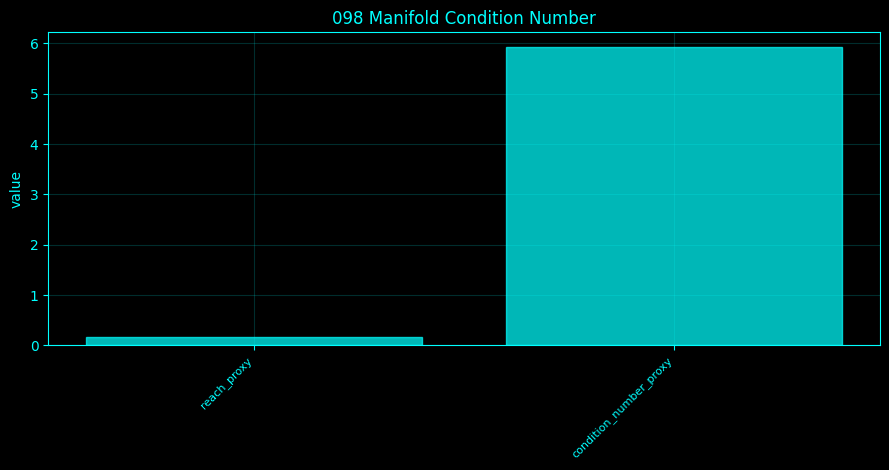

,reach_proxy,condition_number_proxy
0,0.168849,5.922445


In [101]:
imsave('098_manifold_condition_number',pd.DataFrame({'reach_proxy':[reach_proxy],'condition_number_proxy':[1/(reach_proxy+EPS)]}))

### Local injectivity radius proxy

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Local injectivity radius proxy</h3>
<p>Injectivity radius is a smooth-manifold invariant. From a finite trajectory, half the nearest nonlocal self-approach is used only as a conservative local proxy for where distinct trajectory branches begin to collide.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$r_{inj}^{proxy}(x_i)=\tfrac12\min_{|j-i|>m}d(x_i,x_j).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  injectivity_radius_proxy
  815.571                  0.097582
  818.071                  0.798570
  820.571                  1.400373
  823.071                  0.358604
  825.571                  0.344114
  828.071                  0.245025
  830.571                  0.412699
  833.071                  0.097582
  835.571                  0.726828
  838.071                  0.666020
  840.571                  0.588536
  843.071                  0.602614


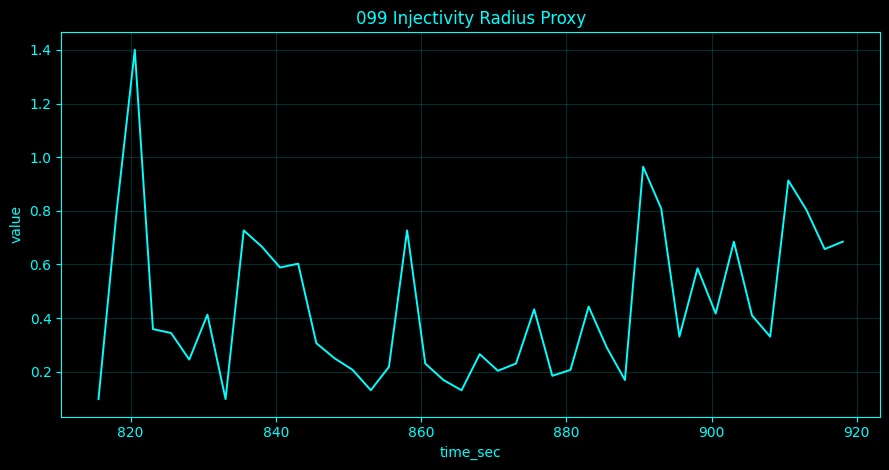

,time_sec,injectivity_radius_proxy
0,815.571,0.097582
1,818.071,0.798570
2,820.571,1.400373
3,823.071,0.358604
4,825.571,0.344114
5,828.071,0.245025
6,830.571,0.412699
7,833.071,0.097582
8,835.571,0.726828
9,838.071,0.666020


In [102]:
vals=[]
for i in range(len(ZM)):
 valid=np.r_[np.arange(0,max(0,i-adj)),np.arange(min(len(ZM),i+adj+1),len(ZM))];vals.append(.5*np.min(DE[i,valid]) if len(valid) else np.nan)
imsave('099_injectivity_radius_proxy',pd.DataFrame({'time_sec':ZT,'injectivity_radius_proxy':vals}))

### Local convexity radius proxy

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Local convexity radius proxy</h3>
<p>On a general manifold the convexity radius is at most the injectivity radius. With only a finite cloud, the implementation reports half of the local injectivity proxy as an explicitly conservative scale, not an exact convexity radius.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$r_{conv}^{proxy}=\tfrac12r_{inj}^{proxy}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  convexity_radius_proxy
  815.571                0.048791
  818.071                0.399285
  820.571                0.700186
  823.071                0.179302
  825.571                0.172057
  828.071                0.122512
  830.571                0.206350
  833.071                0.048791
  835.571                0.363414
  838.071                0.333010
  840.571                0.294268
  843.071                0.301307


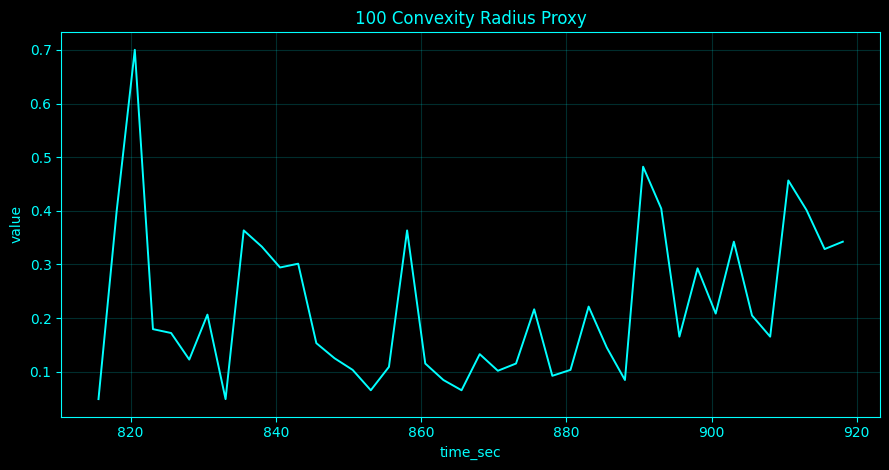

,time_sec,convexity_radius_proxy
0,815.571,0.048791
1,818.071,0.399285
2,820.571,0.700186
3,823.071,0.179302
4,825.571,0.172057
5,828.071,0.122512
6,830.571,0.206350
7,833.071,0.048791
8,835.571,0.363414
9,838.071,0.333010


In [103]:
imsave('100_convexity_radius_proxy',pd.DataFrame({'time_sec':ZT,'convexity_radius_proxy':.5*np.asarray(vals)}))

### Geodesic distortion analysis

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geodesic distortion analysis</h3>
<p>The kNN shortest-path metric approximates intrinsic geodesic distance. Distortion is summarized by ratios d_G/d_E on connected pairs; values near one indicate locally flat, well-sampled geometry.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$\rho_{ij}=d_G(i,j)/d_E(i,j).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 geodesic_over_euclidean
                1.065242
                1.076861
                1.334777
                1.212404
                1.433540
                1.000000
                1.000000
                1.065020
                1.000000
                1.000000
                1.237755
                1.000000


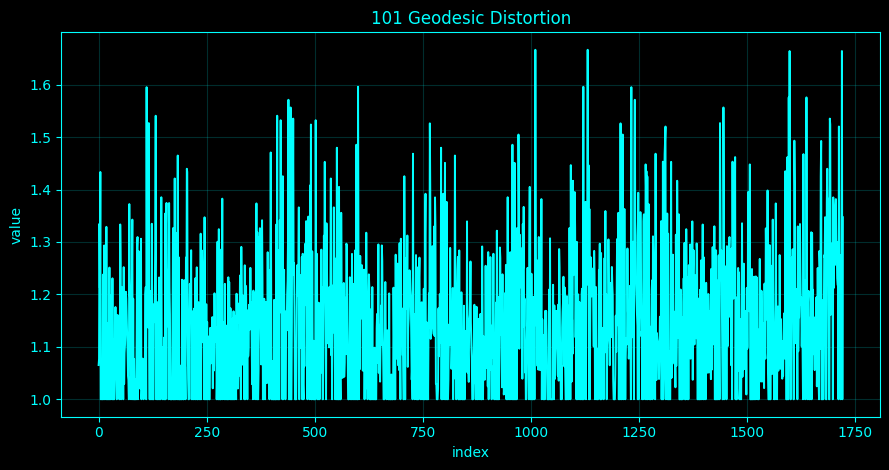

,geodesic_over_euclidean
0,1.065242
1,1.076861
2,1.334777
3,1.212404
4,1.433540
...,...
1717,1.233812
1718,1.254691
1719,1.664281
1720,1.000000


In [104]:
mask=np.isfinite(DG)&(DE>0);rat=DG[mask]/DE[mask];imsave('101_geodesic_distortion',pd.DataFrame({'geodesic_over_euclidean':rat}))

### Euclidean-vs-geodesic distortion

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Euclidean-vs-geodesic distortion</h3>
<p>This cell summarizes multiplicative and relative error between ambient Euclidean distance and graph-geodesic distance over the same finite state cloud.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$e_{ij}=|d_G-d_E|/(d_G+\epsilon).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 relative_distortion    ratio
            0.061246 1.065242
            0.071375 1.076861
            0.250811 1.334777
            0.175192 1.212404
            0.302426 1.433540
            0.000000 1.000000
            0.000000 1.000000
            0.061051 1.065020
            0.000000 1.000000
            0.000000 1.000000
            0.192086 1.237755
            0.000000 1.000000


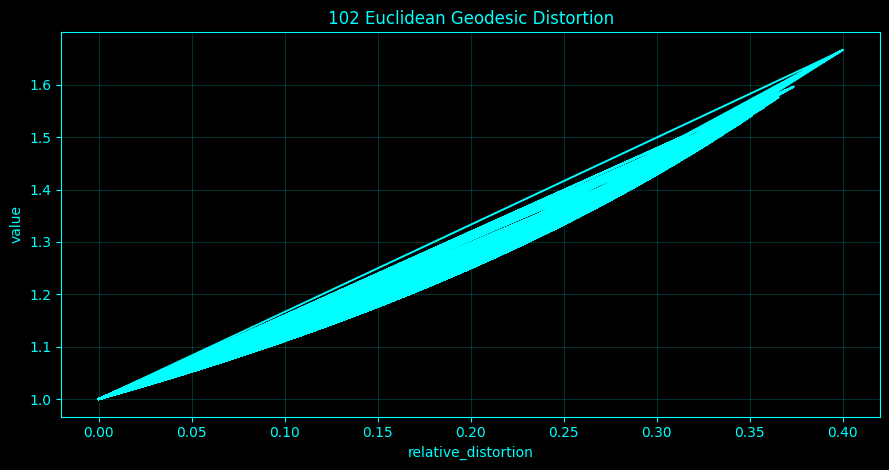

,relative_distortion,ratio
0,0.061246,1.065242
1,0.071375,1.076861
2,0.250811,1.334777
3,0.175192,1.212404
4,0.302426,1.433540
...,...,...
1717,0.189504,1.233812
1718,0.202991,1.254691
1719,0.399140,1.664281
1720,0.000000,1.000000


In [105]:
rel=np.abs(DG[mask]-DE[mask])/(DG[mask]+EPS);imsave('102_euclidean_geodesic_distortion',pd.DataFrame({'relative_distortion':rel,'ratio':rat}))

### Shortest-path metric distortion

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shortest-path metric distortion</h3>
<p>Shortest-path distortion is evaluated against direct Euclidean chord distance. The maximum is sensitive to graph connectivity, so median and high quantiles are reported alongside it.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$\operatorname{distortion}=\sup_{i\ne j}d_G(i,j)/d_E(i,j).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


  median      q95      max
1.123218 1.385341 1.666609


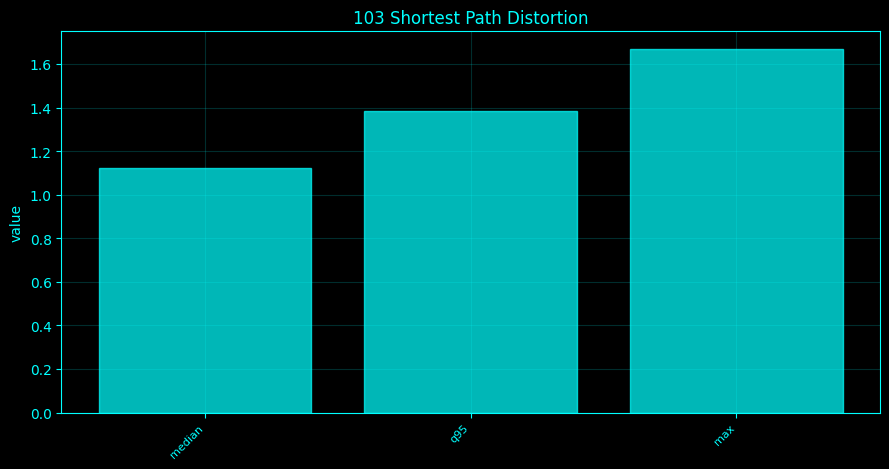

,median,q95,max
0,1.123218,1.385341,1.666609


In [106]:
imsave('103_shortest_path_distortion',pd.DataFrame({'median':[np.median(rat)],'q95':[np.quantile(rat,.95)],'max':[np.max(rat)]}))

### Neighborhood metric distortion

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Neighborhood metric distortion</h3>
<p>For each point, the cell compares Euclidean and graph-geodesic distances only within its Euclidean k-nearest neighborhood, isolating local metric deformation from long-range graph detours.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$e_i^{local}=k^{-1}\sum_{j\in N_k(i)}|d_G-d_E|/(d_E+\epsilon).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ε (epsilon) usually represents a small threshold or radius. Changing it changes what the method counts as sufficiently close or similar.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  local_relative_distortion
  815.571                        0.0
  818.071                        0.0
  820.571                        0.0
  823.071                        0.0
  825.571                        0.0
  828.071                        0.0
  830.571                        0.0
  833.071                        0.0
  835.571                        0.0
  838.071                        0.0
  840.571                        0.0
  843.071                        0.0


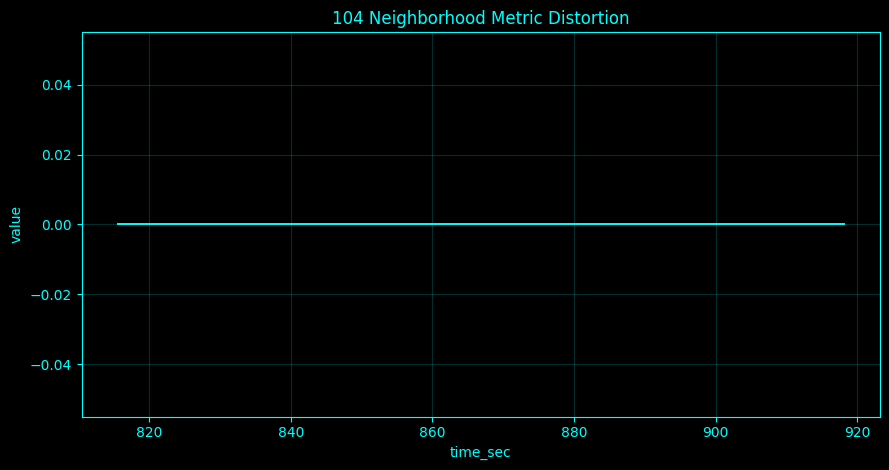

,time_sec,local_relative_distortion
0,815.571,0.0
1,818.071,0.0
2,820.571,0.0
3,823.071,0.0
4,825.571,0.0
5,828.071,0.0
6,830.571,0.0
7,833.071,0.0
8,835.571,0.0
9,838.071,0.0


In [107]:
k=min(IM_CFG['knn'],len(DE)-1);lv=[]
for i in range(len(DE)):
 jj=np.argsort(DE[i])[1:k+1];lv.append(np.nanmean(np.abs(DG[i,jj]-DE[i,jj])/(DE[i,jj]+EPS)))
imsave('104_neighborhood_metric_distortion',pd.DataFrame({'time_sec':ZT,'local_relative_distortion':lv}))

### Manifold trustworthiness geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Manifold trustworthiness geometry</h3>
<p>Trustworthiness penalizes points that appear as neighbors in an embedding despite being distant in the reference metric. The implementation follows the standard rank-based definition with PCA-to-2D as the tested embedding.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$T(k)=1-\frac{2}{nk(2n-3k-1)}\sum_i\sum_{j\in U_k(i)}(r_{ij}-k).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [108]:
Y=Z[:len(ZM),:2] if Z.shape[1]>=2 else np.c_[Z[:len(ZM),0],np.zeros(len(ZM))];DY=cdist(Y,Y)
def trust_cont(D0,D1,k):
 n=len(D0);r0=np.argsort(np.argsort(D0,axis=1),axis=1);r1=np.argsort(np.argsort(D1,axis=1),axis=1);su=sc=0
 for i in range(n):
  N0=set(np.argsort(D0[i])[1:k+1]);N1=set(np.argsort(D1[i])[1:k+1]);su+=sum(r0[i,j]-k for j in N1-N0);sc+=sum(r1[i,j]-k for j in N0-N1)
 den=n*k*(2*n-3*k-1);return 1-2*su/(den+EPS),1-2*sc/(den+EPS)
tr,co=trust_cont(DE,DY,min(k,(len(DE)-2)//3));imsave('105_manifold_trustworthiness',pd.DataFrame({'trustworthiness':[tr]}))

 trustworthiness
        0.868846


,trustworthiness
0,0.868846


### Manifold continuity geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Manifold continuity geometry</h3>
<p>Continuity is the dual rank-preservation score: it penalizes reference neighbors that are lost in the lower-dimensional embedding.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$C(k)=1-\frac{2}{nk(2n-3k-1)}\sum_i\sum_{j\in V_k(i)}(\hat r_{ij}-k).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [109]:
imsave('106_manifold_continuity',pd.DataFrame({'continuity':[co]}))

 continuity
   0.914144


,continuity
0,0.914144


### Projection distortion geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Projection distortion geometry</h3>
<p>Projection distortion compares all pairwise distances before and after PCA projection. A least-squares scale factor is fitted before computing normalized stress so the score measures shape distortion rather than arbitrary global scale.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$stress=\sqrt{\sum(d-\alpha\hat d)^2/\sum d^2}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Regression fits a mathematical relationship between predictors and an outcome by choosing coefficients that minimize a loss, usually squared error. Ridge regression adds a penalty on large coefficients, which can stabilize estimates when predictors are correlated or data are limited. The coefficient of determination R² summarizes how much of the observed variance is explained by the fitted relationship within the analyzed data, but a high R² does not prove causality or guarantee good out-of-sample prediction.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 optimal_scale  normalized_stress
      1.122636           0.234655


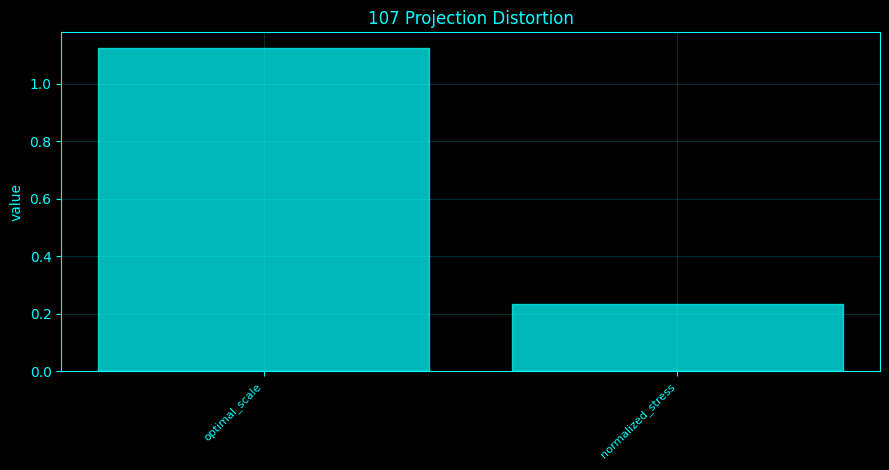

,optimal_scale,normalized_stress
0,1.122636,0.234655


In [110]:
a=DE[np.triu_indices(len(DE),1)];b=DY[np.triu_indices(len(DY),1)];alpha=float((a@b)/(b@b+EPS));stress=np.sqrt(np.sum((a-alpha*b)**2)/(np.sum(a*a)+EPS));imsave('107_projection_distortion',pd.DataFrame({'optimal_scale':[alpha],'normalized_stress':[stress]}))

### UMAP/PCA/t-SNE geometric distortion audit

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — UMAP/PCA/t-SNE geometric distortion audit</h3>
<p>PCA and t-SNE embeddings are audited with the same pairwise stress and neighborhood-preservation metrics. UMAP is included when the optional package is installed; otherwise its status is recorded rather than silently substituting another method.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$stress(Y)=\min_\alpha\|D-\alpha D_Y\|_F/\|D\|_F.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


/home/a/projects/Complete-Neural-Signal-Analysis/.conda-py310/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


method   stress  trustworthiness  continuity status
   PCA 0.234655         0.868846    0.914144     ok
 t-SNE 0.383131         0.872074    0.860876     ok
  UMAP 0.523158         0.837672    0.890638     ok


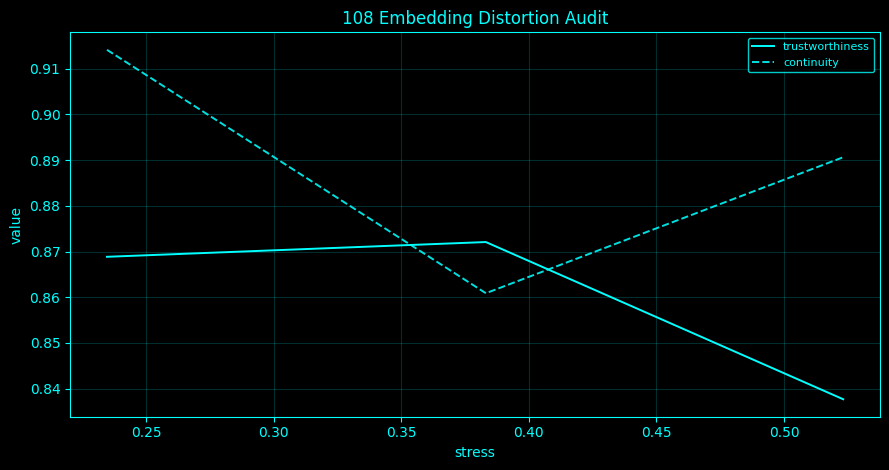

,method,stress,trustworthiness,continuity,status
0,PCA,0.234655,0.868846,0.914144,ok
1,t-SNE,0.383131,0.872074,0.860876,ok
2,UMAP,0.523158,0.837672,0.890638,ok


In [111]:
rows=[]
def audit(name,Y):
 DD=cdist(Y,Y);a=DE[np.triu_indices(len(DE),1)];b=DD[np.triu_indices(len(DD),1)];al=(a@b)/(b@b+EPS);st=np.sqrt(np.sum((a-al*b)**2)/(np.sum(a*a)+EPS));tt,cc=trust_cont(DE,DD,min(k,(len(DE)-2)//3));rows.append((name,st,tt,cc,'ok'))
audit('PCA',Y)
try:
 from sklearn.manifold import TSNE
 YY=TSNE(n_components=2,perplexity=min(20,max(5,(len(ZM)-1)//5)),init='pca',learning_rate='auto',max_iter={'full':1200,'balanced':800,'fast':500,'ultra':300}[FAST_OPTION],random_state=7).fit_transform(ZM);audit('t-SNE',YY)
except Exception as e:rows.append(('t-SNE',np.nan,np.nan,np.nan,'unavailable:'+type(e).__name__))
try:
 import umap
 YY=umap.UMAP(n_components=2,n_neighbors=min(15,len(ZM)-1),random_state=7).fit_transform(ZM);audit('UMAP',YY)
except Exception as e:rows.append(('UMAP',np.nan,np.nan,np.nan,'unavailable:'+type(e).__name__))
imsave('108_embedding_distortion_audit',pd.DataFrame(rows,columns=['method','stress','trustworthiness','continuity','status']))

### Geodesic preservation score

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Geodesic preservation score</h3>
<p>The score is the Spearman rank correlation between finite graph-geodesic distances and embedded Euclidean distances. It measures monotone preservation, not absolute isometry.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$G=\rho_S(\{d_G(i,j)\},\{d_Y(i,j)\}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [112]:
tri=np.triu_indices(len(DG),1);m=np.isfinite(DG[tri]);rho=spearmanr(DG[tri][m],DY[tri][m]).statistic;imsave('109_geodesic_preservation',pd.DataFrame({'spearman_geodesic_vs_embedding':[rho]}))

 spearman_geodesic_vs_embedding
                       0.901973


,spearman_geodesic_vs_embedding
0,0.901973


### Distance rank preservation

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Distance rank preservation</h3>
<p>Distance rank preservation is quantified by Spearman correlation between all original finite-state distances and projected distances. It is insensitive to a monotone rescaling.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$R=\rho_S(d_E,d_Y).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


In [113]:
rho=spearmanr(DE[tri],DY[tri]).statistic;imsave('110_distance_rank_preservation',pd.DataFrame({'spearman_distance_rank':[rho]}))

 spearman_distance_rank
               0.919257


,spearman_distance_rank
0,0.919257


### Local neighborhood preservation

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Local neighborhood preservation</h3>
<p>For each state, neighborhood preservation is the Jaccard overlap of its k nearest neighbors before and after projection.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$J_i=|N_k(i)\cap\hat N_k(i)|/|N_k(i)\cup\hat N_k(i)|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  jaccard_knn
  815.571     0.142857
  818.071     1.000000
  820.571     0.230769
  823.071     0.230769
  825.571     0.454545
  828.071     0.454545
  830.571     0.333333
  833.071     0.230769
  835.571     0.777778
  838.071     0.142857
  840.571     0.333333
  843.071     0.454545


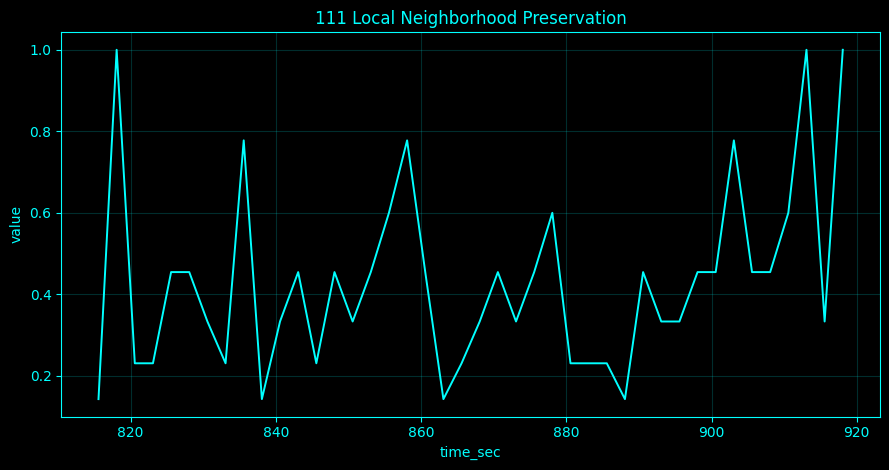

,time_sec,jaccard_knn
0,815.571,0.142857
1,818.071,1.000000
2,820.571,0.230769
3,823.071,0.230769
4,825.571,0.454545
5,828.071,0.454545
6,830.571,0.333333
7,833.071,0.230769
8,835.571,0.777778
9,838.071,0.142857


In [114]:
jj=[]
for i in range(len(DE)):
 a=set(np.argsort(DE[i])[1:k+1]);b=set(np.argsort(DY[i])[1:k+1]);jj.append(len(a&b)/max(1,len(a|b)))
imsave('111_local_neighborhood_preservation',pd.DataFrame({'time_sec':ZT,'jaccard_knn':jj}))

### Global geometry preservation

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;">
<h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Global geometry preservation</h3>
<p>Global preservation is summarized jointly by normalized distance stress, distance-rank correlation, and geodesic-rank correlation; no single scalar is presented as a universal manifold-quality invariant.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample counts, optimization iterations, or plotting resolution. It does not change the mathematical definition.</p></div>

$$stress,\quad\rho_S(d_E,d_Y),\quad\rho_S(d_G,d_Y).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol ρ (rho) is often used for a correlation, density, or similarity measure; its role is determined by the equation's definition.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 normalized_stress  euclidean_rank_preservation  geodesic_rank_preservation  mean_knn_jaccard
          0.234655                     0.919257                    0.901973          0.431587


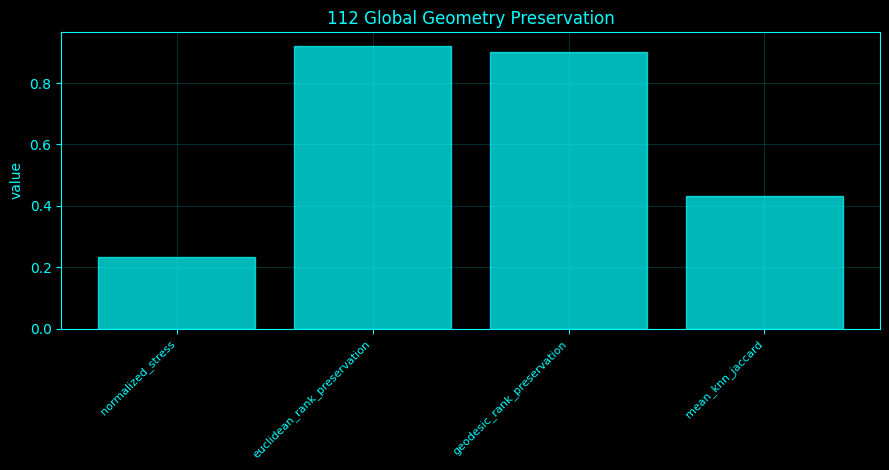

,normalized_stress,euclidean_rank_preservation,geodesic_rank_preservation,mean_knn_jaccard
0,0.234655,0.919257,0.901973,0.431587


In [115]:
rE=spearmanr(DE[tri],DY[tri]).statistic;m=np.isfinite(DG[tri]);rG=spearmanr(DG[tri][m],DY[tri][m]).statistic;imsave('112_global_geometry_preservation',pd.DataFrame({'normalized_stress':[stress],'euclidean_rank_preservation':[rE],'geodesic_rank_preservation':[rG],'mean_knn_jaccard':[np.mean(jj)]}))

# Geometry catalogue continuation — entries 113–155

Differential geometry of embedded EEG trajectories and statistical shape analysis.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shared trajectory and shape foundation</h3><p>The multichannel EEG state trajectory is represented by the first three PCA coordinates of the windowed covariance tangent vectors. Frenet quantities are evaluated with derivatives against physical time and, where needed, converted to arc-length form. Per-channel shapes use three-dimensional delay curves that are resampled by arc length, centered, and scaled to unit Frobenius norm. Shape distances distinguish ordinary Procrustes residuals, fixed-parameter SRV distances, and Kendall preshape-sphere geodesics.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$\kappa=\frac{\|r'\times r''\|}{\|r'\|^3},\qquad \tau=\frac{\det(r',r'',r''')}{\|r'\times r''\|^2}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Trajectory/shape foundation: ultra trajectory 42 shape points 80


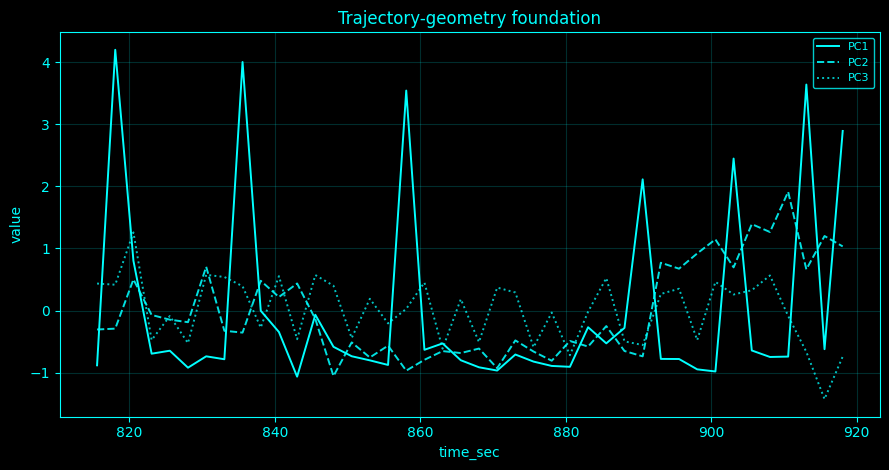

True

In [116]:
from scipy.interpolate import interp1d
from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import linkage,fcluster
from scipy.spatial.distance import squareform as _sqf
TR_CFG={'full':dict(points=480,shape=220,roll=15,events=20),'balanced':dict(points=340,shape=170,roll=13,events=16),'fast':dict(points=240,shape=120,roll=11,events=12),'ultra':dict(points=150,shape=80,roll=9,events=8)}[FAST_OPTION]
TR_OUT=os.path.join(base_dir,'results','geometry_catalogue_trajectory_shape');os.makedirs(TR_OUT,exist_ok=True)
def trdir(s):d=os.path.join(TR_OUT,s);os.makedirs(d,exist_ok=True);return d
def trsave(s,df):df.to_csv(os.path.join(trdir(s),f'{s}_{FAST_OPTION}.csv'),index=False);print(df.head(12).to_string(index=False));catalogue_autoplot_df(s,df);return df
def _safe_grad(x,t):return np.gradient(np.asarray(x,float),np.asarray(t,float),axis=0,edge_order=2 if len(x)>=3 else 1)
def frenet(R,t):
 R=np.asarray(R,float);t=np.asarray(t,float);v=_safe_grad(R,t);a=_safe_grad(v,t);j=_safe_grad(a,t);spd=np.linalg.norm(v,axis=1);cr=np.cross(v,a);cn=np.linalg.norm(cr,axis=1);kap=cn/(spd**3+EPS);tau=np.einsum('ij,ij->i',cr,j)/(cn**2+EPS);T=v/(spd[:,None]+EPS);kvec=_safe_grad(T,t)/(spd[:,None]+EPS);return v,a,j,spd,kap,tau,T,kvec
# global three-dimensional PCA trajectory
R0=np.asarray(SCORE[:,:3],float)
if R0.shape[1]<3:R0=np.pad(R0,((0,0),(0,3-R0.shape[1])))
rt=np.asarray(STATE_TIMES,float);take=min(len(R0),TR_CFG['points']);ii=np.unique(np.linspace(0,len(R0)-1,take).round().astype(int));R=R0[ii];RT=rt[ii]
V,A,J,SPD,KAP,TAU,TANV,KVE=frenet(R,RT)
DS=np.r_[0,np.linalg.norm(np.diff(R,axis=0),axis=1)];ARC=np.cumsum(DS)
def resample_curve(C,m=None,closed=False):
 C=np.asarray(C,float);m=TR_CFG['shape'] if m is None else int(m)
 if closed and np.linalg.norm(C[0]-C[-1])>1e-10:C=np.vstack([C,C[0]])
 s=np.r_[0,np.cumsum(np.linalg.norm(np.diff(C,axis=0),axis=1))]
 if s[-1]<EPS:return np.repeat(C[:1],m,axis=0)
 u=np.linspace(0,s[-1],m,endpoint=not closed);return np.c_[[np.interp(u,s,C[:,d]) for d in range(C.shape[1])]].T
def preshape(C):
 X=np.asarray(C,float)-np.mean(C,axis=0,keepdims=True);return X/(np.linalg.norm(X)+EPS)
def align_to(X,Y):
 # rotate Y onto X, allowing proper rotations only
 M=Y.T@X;U,_,Vt=np.linalg.svd(M);Q=U@Vt
 if np.linalg.det(Q)<0:U[:,-1]*=-1;Q=U@Vt
 return Y@Q,Q
def proc_dist(X,Y):
 X=preshape(X);Y=preshape(Y);Ya,_=align_to(X,Y);return float(np.linalg.norm(X-Ya))
def kendall_dist(X,Y):
 X=preshape(X);Y=preshape(Y);Ya,_=align_to(X,Y);return float(np.arccos(np.clip(np.sum(X*Ya),-1,1)))
def srv(C):
 C=np.asarray(C,float);d=np.gradient(C,axis=0);sp=np.linalg.norm(d,axis=1);return d/np.sqrt(sp[:,None]+EPS)
def slerp_shape(X,Y,t):
 X=preshape(X);Y=preshape(Y);Y,_=align_to(X,Y);th=np.arccos(np.clip(np.sum(X*Y),-1,1))
 if th<1e-10:return preshape((1-t)*X+t*Y)
 return np.sin((1-t)*th)/np.sin(th)*X+np.sin(t*th)/np.sin(th)*Y
# channel delay shapes; common delay and common arc-length sample count
lag=max(2,int(round(.01*sampling_rate)));raw_idx=np.unique(np.linspace(2*lag,len(EEG_STD)-1,min(TR_CFG['points']*3,len(EEG_STD)-2*lag)).round().astype(int));CH_SH=[]
for c in range(nC):
 x=EEG_STD[:,c];C=np.c_[x[raw_idx],x[raw_idx-lag],x[raw_idx-2*lag]];CH_SH.append(preshape(resample_curve(C)))
CH_SH=np.asarray(CH_SH)
# curvature sequences per channel on common sampled delay curves
CH_K=[]
for C in CH_SH:
 tt=np.linspace(0,1,len(C));CH_K.append(frenet(C,tt)[4])
CH_K=np.asarray(CH_K)
print('Trajectory/shape foundation:',FAST_OPTION,'trajectory',len(R),'shape points',CH_SH.shape[1])
# Visible foundation diagnostic
catalogue_autoplot_df('trajectory_geometry_foundation',pd.DataFrame({'time_sec':RT,'PC1':R[:,0],'PC2':R[:,1],'PC3':R[:,2]}),title='Trajectory-geometry foundation')


### Differential geometry of embedded trajectories

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Differential geometry of embedded trajectories</h3><p>A smooth curve in Euclidean state space is characterized locally by its tangent and higher derivatives. The cell reports arc length, mean speed, curvature and torsion for the three-dimensional PCA state trajectory.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$L=\int\|r'(t)\|dt,\quad \kappa=\|r'\times r''\|/\|r'\|^3.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 arc_length  mean_speed  mean_curvature  mean_abs_torsion
  76.187771    0.479413        6.428612          0.840931


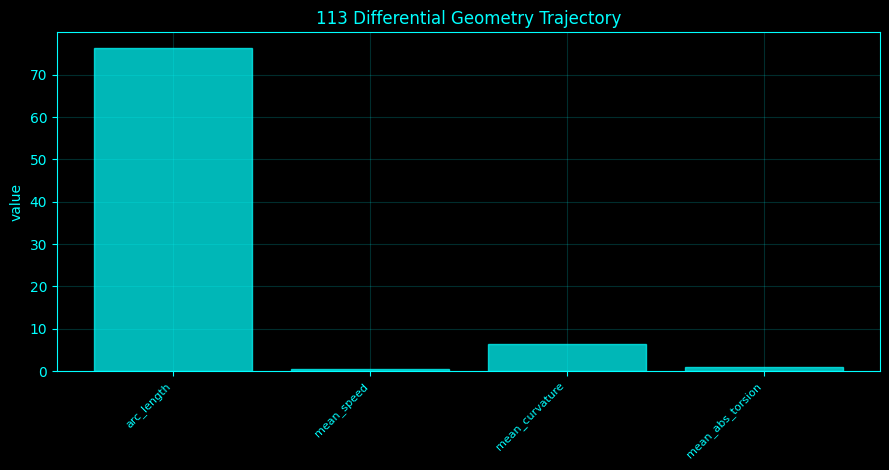

,arc_length,mean_speed,mean_curvature,mean_abs_torsion
0,76.187771,0.479413,6.428612,0.840931


In [117]:
trsave('113_differential_geometry_trajectory',pd.DataFrame({'arc_length':[ARC[-1]],'mean_speed':[np.mean(SPD)],'mean_curvature':[np.nanmean(KAP)],'mean_abs_torsion':[np.nanmean(np.abs(TAU))]}))

### Frenet-Serret curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Frenet-Serret curvature</h3><p>For a regular space curve, Frenet curvature is invariant to reparameterization and measures bending per unit arc length. Near-zero speeds are stabilized only numerically by epsilon.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$\kappa(t)=\frac{\|r'\times r''\|}{\|r'\|^3}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  curvature
  815.571   0.016823
  818.071   3.335798
  820.571   0.090693
  823.071   0.693139
  825.571  26.426537
  828.071   0.838039
  830.571   4.490270
  833.071   0.090746
  835.571   4.227574
  838.071   0.063371
  840.571   1.250458
  843.071   5.019992


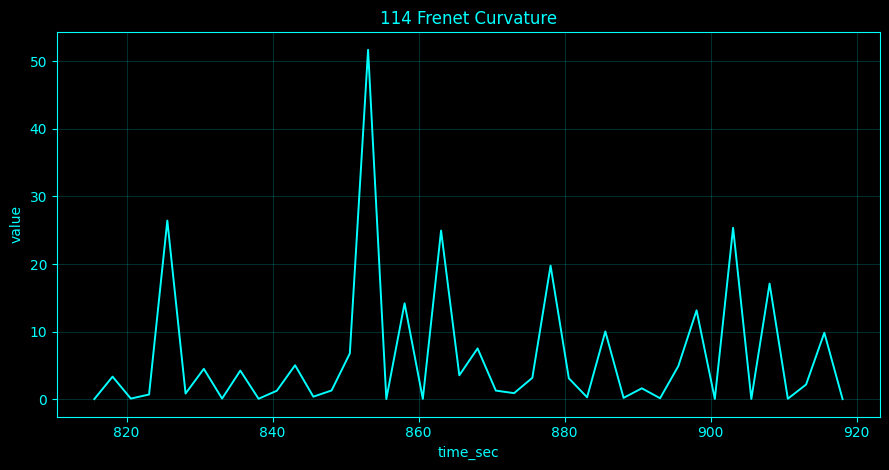

,time_sec,curvature
0,815.571,0.016823
1,818.071,3.335798
2,820.571,0.090693
3,823.071,0.693139
4,825.571,26.426537
5,828.071,0.838039
6,830.571,4.490270
7,833.071,0.090746
8,835.571,4.227574
9,838.071,0.063371


In [118]:
trsave('114_frenet_curvature',pd.DataFrame({'time_sec':RT,'curvature':KAP}))

### Frenet-Serret torsion

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Frenet-Serret torsion</h3><p>Torsion measures the rate at which a three-dimensional curve leaves its osculating plane. It is undefined at exactly zero curvature; those numerical locations are stabilized and should be interpreted cautiously.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$\tau=\frac{(r'\times r'')\cdot r'''}{\|r'\times r''\|^2}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec   torsion
  815.571 -0.024083
  818.071 -0.110991
  820.571 -0.265250
  823.071 -0.122073
  825.571  3.681054
  828.071  2.688006
  830.571  0.137526
  833.071  0.065966
  835.571  0.037289
  838.071 -0.060258
  840.571  0.219745
  843.071  7.450210


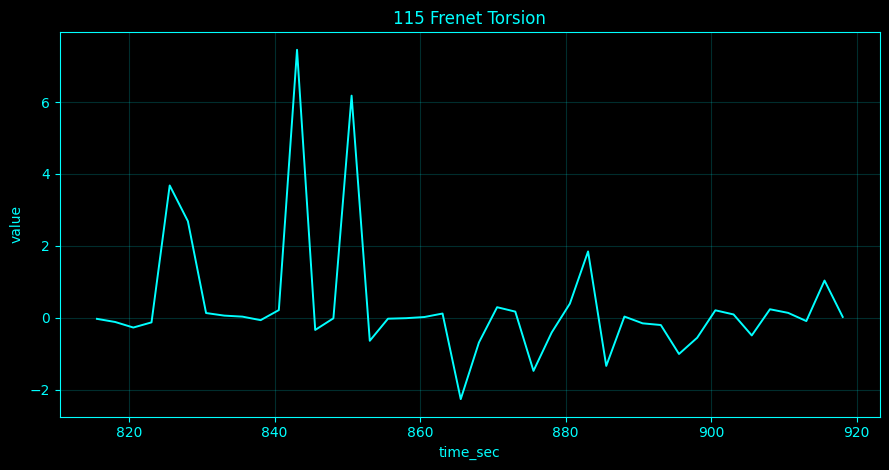

,time_sec,torsion
0,815.571,-0.024083
1,818.071,-0.110991
2,820.571,-0.265250
3,823.071,-0.122073
4,825.571,3.681054
5,828.071,2.688006
6,830.571,0.137526
7,833.071,0.065966
8,835.571,0.037289
9,838.071,-0.060258


In [119]:
trsave('115_frenet_torsion',pd.DataFrame({'time_sec':RT,'torsion':TAU}))

### Arc-length parameterization

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Arc-length parameterization</h3><p>Arc length is accumulated from Euclidean chord lengths of consecutive sampled trajectory points. The normalized parameter s/L allows comparison across trajectories with different durations or speeds.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$s(t)=\int_{t_0}^{t}\|r'(u)\|du.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  arc_length  normalized_arc_length
  815.571    0.000000               0.000000
  818.071    5.083878               0.066728
  820.571    8.675889               0.113875
  823.071   11.037713               0.144875
  825.571   11.436098               0.150104
  828.071   11.953077               0.156890
  830.571   13.382004               0.175645
  833.071   14.415038               0.189204
  835.571   19.206916               0.252100
  838.071   23.355162               0.306547
  840.571   24.290496               0.318824
  843.071   25.555045               0.335422


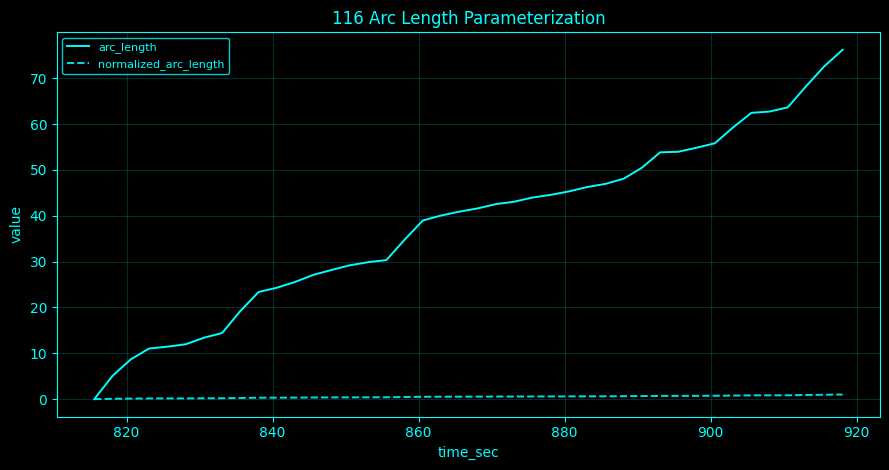

,time_sec,arc_length,normalized_arc_length
0,815.571,0.000000,0.000000
1,818.071,5.083878,0.066728
2,820.571,8.675889,0.113875
3,823.071,11.037713,0.144875
4,825.571,11.436098,0.150104
5,828.071,11.953077,0.156890
6,830.571,13.382004,0.175645
7,833.071,14.415038,0.189204
8,835.571,19.206916,0.252100
9,838.071,23.355162,0.306547


In [120]:
trsave('116_arc_length_parameterization',pd.DataFrame({'time_sec':RT,'arc_length':ARC,'normalized_arc_length':ARC/(ARC[-1]+EPS)}))

### Trajectory speed geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Trajectory speed geometry</h3><p>Speed is the norm of the first derivative with respect to physical time. Unlike curvature, it depends on the time parameterization and therefore captures dynamical rate rather than shape alone.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$v(t)=\|r'(t)\|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec    speed
  815.571 3.737722
  818.071 0.408180
  820.571 0.996394
  823.071 0.416353
  825.571 0.051710
  828.071 0.216796
  830.571 0.216589
  833.071 0.972585
  835.571 0.277603
  838.071 0.878225
  840.571 0.215823
  843.071 0.089990


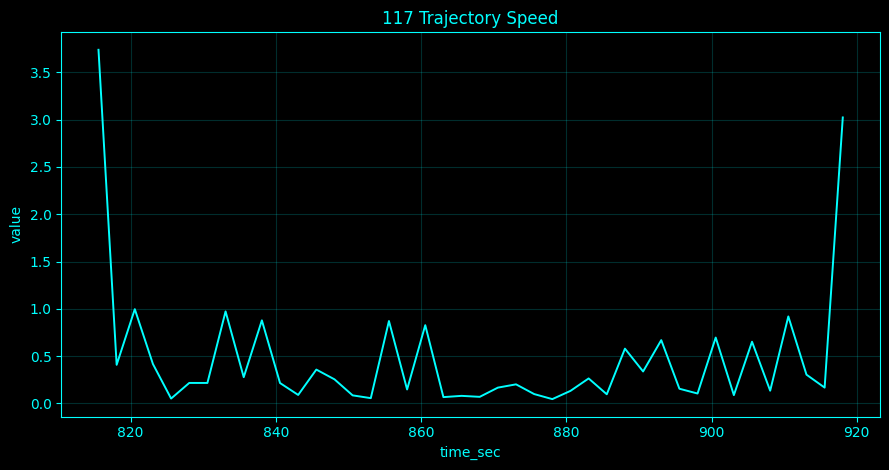

,time_sec,speed
0,815.571,3.737722
1,818.071,0.408180
2,820.571,0.996394
3,823.071,0.416353
4,825.571,0.051710
5,828.071,0.216796
6,830.571,0.216589
7,833.071,0.972585
8,835.571,0.277603
9,838.071,0.878225


In [121]:
trsave('117_trajectory_speed',pd.DataFrame({'time_sec':RT,'speed':SPD}))

### Trajectory acceleration geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Trajectory acceleration geometry</h3><p>Acceleration is the second time derivative of the embedded trajectory. Its decomposition into tangential and normal parts distinguishes speed changes from directional bending.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$a=r'',\quad a_T=(a\cdot T)T,\quad a_N=a-a_T.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  acceleration_norm  tangential_acceleration  normal_acceleration_norm
  815.571           1.806591                -1.791238                  0.235026
  818.071           0.942734                -0.761482                  0.555782
  820.571           0.163190                 0.136102                  0.090040
  823.071           0.190335                -0.147615                  0.120155
  825.571           0.114132                -0.089628                  0.070661
  828.071           0.046862                 0.025389                  0.039388
  830.571           0.210644                 0.000695                  0.210643
  833.071           0.088089                 0.019786                  0.085838
  835.571           0.369797                -0.174955                  0.325792
  838.071           0.085005                 0.069548                  0.048877
  840.571           0.188899                -0.179695                  0.058246
  843.071           0.094489            

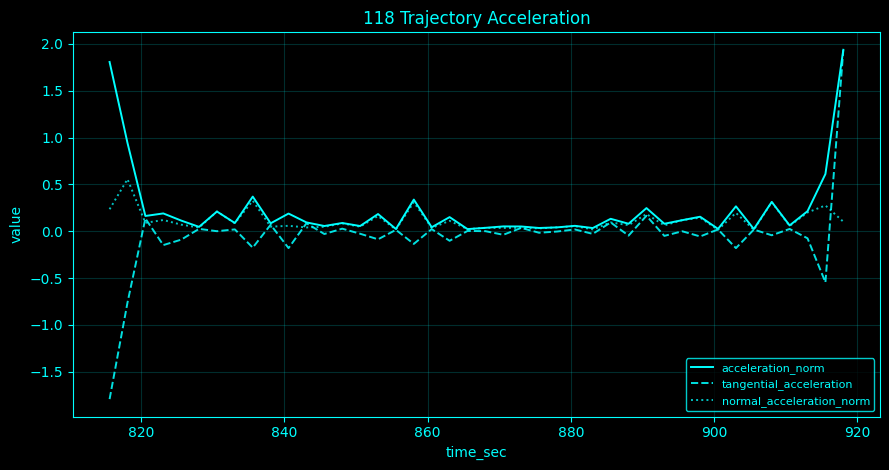

,time_sec,acceleration_norm,tangential_acceleration,normal_acceleration_norm
0,815.571,1.806591,-1.791238,0.235026
1,818.071,0.942734,-0.761482,0.555782
2,820.571,0.163190,0.136102,0.090040
3,823.071,0.190335,-0.147615,0.120155
4,825.571,0.114132,-0.089628,0.070661
5,828.071,0.046862,0.025389,0.039388
6,830.571,0.210644,0.000695,0.210643
7,833.071,0.088089,0.019786,0.085838
8,835.571,0.369797,-0.174955,0.325792
9,838.071,0.085005,0.069548,0.048877


In [122]:
aT=np.einsum('ij,ij->i',A,TANV);aN=np.linalg.norm(A-aT[:,None]*TANV,axis=1);trsave('118_trajectory_acceleration',pd.DataFrame({'time_sec':RT,'acceleration_norm':np.linalg.norm(A,axis=1),'tangential_acceleration':aT,'normal_acceleration_norm':aN}))

### Trajectory jerk geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Trajectory jerk geometry</h3><p>Jerk is the third physical-time derivative of position and quantifies rapid changes in acceleration. It is derivative-sensitive, so its interpretation is numerical and resolution dependent.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$j(t)=d^3r/dt^3.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  jerk_norm
  815.571   0.375811
  818.071   0.341677
  820.571   0.226095
  823.071   0.054492
  825.571   0.034635
  828.071   0.045184
  830.571   0.025286
  833.071   0.115356
  835.571   0.031719
  838.071   0.111734
  840.571   0.027715
  843.071   0.045734


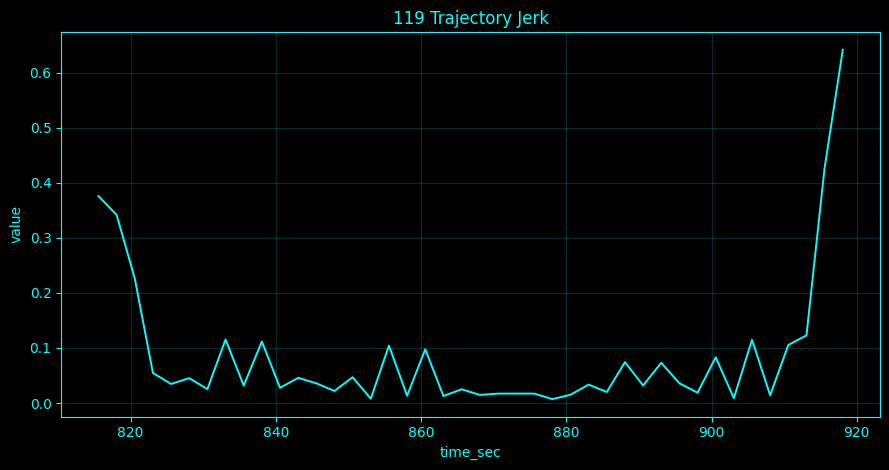

,time_sec,jerk_norm
0,815.571,0.375811
1,818.071,0.341677
2,820.571,0.226095
3,823.071,0.054492
4,825.571,0.034635
5,828.071,0.045184
6,830.571,0.025286
7,833.071,0.115356
8,835.571,0.031719
9,838.071,0.111734


In [123]:
trsave('119_trajectory_jerk',pd.DataFrame({'time_sec':RT,'jerk_norm':np.linalg.norm(J,axis=1)}))

### Curvature-torsion phase portraits

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature-torsion phase portraits</h3><p>The pair (curvature,torsion) summarizes local bending and twisting. Plotting or tabulating this pair forms a geometric phase portrait without claiming Hamiltonian phase-space structure.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$t\mapsto(\kappa(t),\tau(t)).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula.</p><p><b>How to interpret this cell.</b> The visualization is a way of displaying already-computed numbers. Color, ordering, or ranking can make patterns easier to see but does not create additional statistical evidence beyond the values and uncertainty measures being plotted.</p></div>


 time_sec  curvature   torsion
  815.571   0.016823 -0.024083
  818.071   3.335798 -0.110991
  820.571   0.090693 -0.265250
  823.071   0.693139 -0.122073
  825.571  26.426537  3.681054
  828.071   0.838039  2.688006
  830.571   4.490270  0.137526
  833.071   0.090746  0.065966
  835.571   4.227574  0.037289
  838.071   0.063371 -0.060258
  840.571   1.250458  0.219745
  843.071   5.019992  7.450210


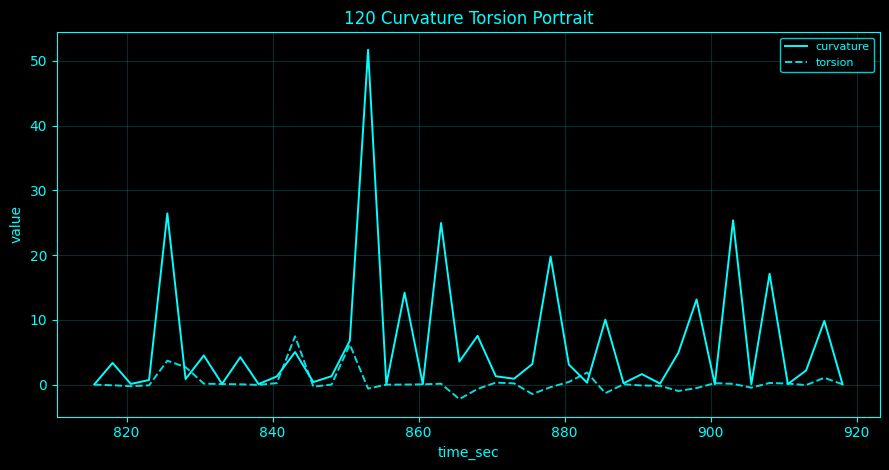

,time_sec,curvature,torsion
0,815.571,0.016823,-0.024083
1,818.071,3.335798,-0.110991
2,820.571,0.090693,-0.265250
3,823.071,0.693139,-0.122073
4,825.571,26.426537,3.681054
5,828.071,0.838039,2.688006
6,830.571,4.490270,0.137526
7,833.071,0.090746,0.065966
8,835.571,4.227574,0.037289
9,838.071,0.063371,-0.060258


In [124]:
trsave('120_curvature_torsion_portrait',pd.DataFrame({'time_sec':RT,'curvature':KAP,'torsion':TAU}))

### Curvature energy

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature energy</h3><p>Integrated squared curvature is a standard bending functional for curves. Numerical integration uses arc length rather than clock time so the result is geometric.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$E_\kappa=\int\kappa(s)^2\,ds.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [125]:
Ek=float(np.trapz(KAP*KAP,ARC));trsave('121_curvature_energy',pd.DataFrame({'curvature_energy':[Ek]}))

 curvature_energy
      6849.520915


,curvature_energy
0,6849.520915


### Bending energy

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Bending energy</h3><p>For an inextensible isotropic rod with unit bending stiffness, bending energy is one half the integral of squared curvature. This cell reports that normalized geometric functional.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$E_b=\tfrac12\int\kappa^2 ds.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [126]:
trsave('122_bending_energy',pd.DataFrame({'unit_stiffness_bending_energy':[.5*Ek]}))

 unit_stiffness_bending_energy
                   3424.760457


,unit_stiffness_bending_energy
0,3424.760457


### Elastic energy of EEG trajectories

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Elastic energy of EEG trajectories</h3><p>A simple unit-coefficient elastic-rod functional combines squared curvature and squared torsion integrated over arc length. It is a geometric feature, not a claim that EEG obeys an elastic-rod physical law.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$E=\tfrac12\int(\kappa^2+\tau^2)ds.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


In [127]:
Ee=float(.5*np.trapz(KAP*KAP+TAU*TAU,ARC));trsave('123_elastic_energy',pd.DataFrame({'normalized_elastic_curve_energy':[Ee]}))

 normalized_elastic_curve_energy
                      3495.22567


,normalized_elastic_curve_energy
0,3495.22567


### Trajectory geodesic curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Trajectory geodesic curvature</h3><p>Geodesic curvature requires an ambient surface. A local PCA plane fitted around each trajectory point provides an explicitly finite-data tangent-surface proxy; the curvature vector is decomposed into components tangent and normal to that plane.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$\kappa_g=\|k-(k\cdot n)n\|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  geodesic_curvature_local_surface_proxy
  815.571                                0.146120
  818.071                                0.973555
  820.571                                0.394466
  823.071                                0.132242
  825.571                                6.680666
  828.071                                1.447597
  830.571                                1.392892
  833.071                                0.282880
  835.571                                1.435115
  838.071                                0.389969
  840.571                                1.696699
  843.071                                3.592634


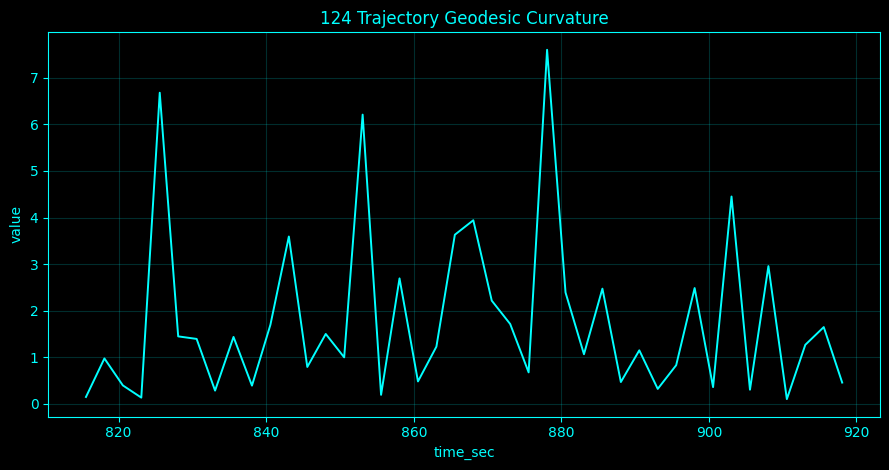

,time_sec,geodesic_curvature_local_surface_proxy
0,815.571,0.146120
1,818.071,0.973555
2,820.571,0.394466
3,823.071,0.132242
4,825.571,6.680666
5,828.071,1.447597
6,830.571,1.392892
7,833.071,0.282880
8,835.571,1.435115
9,838.071,0.389969


In [128]:
kg=[];kn=[];rad=max(3,min(7,len(R)//10))
for i in range(len(R)):
 lo=max(0,i-rad);hi=min(len(R),i+rad+1);X=R[lo:hi]-R[lo:hi].mean(0);_,_,vt=np.linalg.svd(X,full_matrices=False);n=vt[-1];nv=float(KVE[i]@n);kn.append(abs(nv));kg.append(np.linalg.norm(KVE[i]-nv*n))
trsave('124_trajectory_geodesic_curvature',pd.DataFrame({'time_sec':RT,'geodesic_curvature_local_surface_proxy':kg}))

### Trajectory normal curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Trajectory normal curvature</h3><p>Normal curvature is the component of the curve curvature vector along the locally fitted surface normal. Because the ambient surface is inferred from a one-dimensional sampled trajectory, this is explicitly a local-surface proxy.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$\kappa_n=k\cdot n.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  absolute_normal_curvature_local_surface_proxy
  815.571                                       0.045196
  818.071                                       0.007559
  820.571                                       0.047108
  823.071                                       0.204681
  825.571                                       1.655347
  828.071                                       0.102686
  830.571                                       0.485519
  833.071                                       0.231939
  835.571                                       0.112016
  838.071                                       0.031479
  840.571                                       0.251485
  843.071                                       0.274577


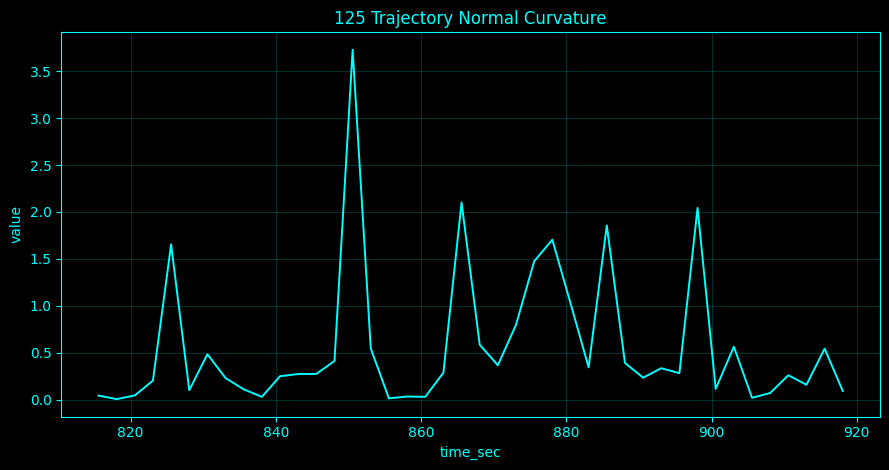

,time_sec,absolute_normal_curvature_local_surface_proxy
0,815.571,0.045196
1,818.071,0.007559
2,820.571,0.047108
3,823.071,0.204681
4,825.571,1.655347
5,828.071,0.102686
6,830.571,0.485519
7,833.071,0.231939
8,835.571,0.112016
9,838.071,0.031479


In [129]:
trsave('125_trajectory_normal_curvature',pd.DataFrame({'time_sec':RT,'absolute_normal_curvature_local_surface_proxy':kn}))

### Trajectory torsion asymmetry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Trajectory torsion asymmetry</h3><p>Torsion changes sign under orientation reversal/reflection. The cell reports the normalized imbalance between positive and negative signed torsion magnitudes.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$A_\tau=(\int\tau_+ds-\int|\tau_-|ds)/(\int|\tau|ds).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. The symbol τ (tau) commonly denotes a time delay, scale, or characteristic time. Here it should be read according to the definition immediately preceding the formula.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [130]:
pos=np.trapz(np.maximum(TAU,0),ARC);neg=np.trapz(np.maximum(-TAU,0),ARC);trsave('126_torsion_asymmetry',pd.DataFrame({'signed_torsion_asymmetry':[(pos-neg)/(pos+neg+EPS)]}))

 signed_torsion_asymmetry
                 0.468752


,signed_torsion_asymmetry
0,0.468752


### Trajectory curvature entropy

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Trajectory curvature entropy</h3><p>Curvature values are converted to an empirical histogram and Shannon entropy quantifies dispersion of bending magnitudes. This is entropy of the curvature distribution, not a differential-geometric invariant.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$H_\kappa=-\sum_b p_b\log p_b.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Shannon entropy summarizes uncertainty in a probability distribution. Each outcome contributes according to both its probability and the information associated with that probability, so evenly distributed outcomes give larger entropy than a distribution concentrated on a few outcomes. An entropy rate extends this idea to a time process and asks how much new uncertainty is produced per time step after accounting for the past.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. A logarithm converts multiplicative scaling into additive differences. Its base changes the numerical units but not the ordering of values when used consistently. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


In [131]:
h,_=np.histogram(KAP[np.isfinite(KAP)],bins=min(32,max(8,int(np.sqrt(len(KAP))))));p=h[h>0]/max(h.sum(),1);trsave('127_curvature_entropy',pd.DataFrame({'curvature_histogram_entropy':[-np.sum(p*np.log(p+EPS))]}))

 curvature_histogram_entropy
                     1.01927


,curvature_histogram_entropy
0,1.01927


### Trajectory curvature spectra

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Trajectory curvature spectra</h3><p>The Welch power spectrum of the curvature time series identifies temporal modulation scales of bending. Frequency is in hertz because curvature is sampled at the state-window times.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$S_\kappa(f)=Welch\{\kappa(t)\}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A power spectral density describes how signal power is distributed over frequency. Welch's method divides the time series into overlapping segments, windows each segment to reduce edge discontinuities, computes a periodogram for each segment, and averages the results. Averaging reduces the variance of the spectral estimate at the cost of some frequency resolution. The area under the PSD over a frequency band corresponds to power in that band, subject to the normalization convention used by the implementation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 frequency_Hz  curvature_PSD
     0.000000      68.100493
     0.009524     350.813987
     0.019048     864.383964
     0.028571     422.078928
     0.038095     764.989412
     0.047619     282.411602
     0.057143      43.152152
     0.066667     420.033495
     0.076190    1042.310983
     0.085714    1137.438101
     0.095238     613.286018
     0.104762     256.281717


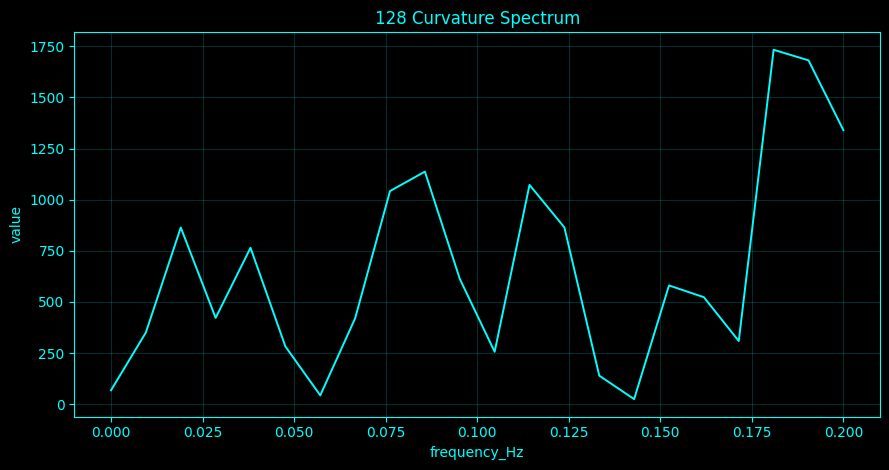

,frequency_Hz,curvature_PSD
0,0.000000,68.100493
1,0.009524,350.813987
2,0.019048,864.383964
3,0.028571,422.078928
4,0.038095,764.989412
5,0.047619,282.411602
6,0.057143,43.152152
7,0.066667,420.033495
8,0.076190,1042.310983
9,0.085714,1137.438101


In [132]:
dt=np.median(np.diff(RT));f,P=signal.welch(KAP,fs=1/(dt+EPS),nperseg=min(64,len(KAP)));trsave('128_curvature_spectrum',pd.DataFrame({'frequency_Hz':f,'curvature_PSD':P}))

### Rolling trajectory curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Rolling trajectory curvature</h3><p>A centered rolling mean of Frenet curvature summarizes slower bending trends without changing the underlying pointwise curvature definition.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$\bar\kappa_i=m^{-1}\sum_{|j-i|\le m/2}\kappa_j.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  curvature  rolling_curvature
  815.571   0.016823           6.112598
  818.071   3.335798           5.233505
  820.571   0.090693           5.127328
  823.071   0.693139           4.497755
  825.571  26.426537           4.467735
  828.071   0.838039           4.472907
  830.571   4.490270           4.241203
  833.071   0.090746           4.788903
  835.571   4.227574           4.753367
  838.071   0.063371           1.960345
  840.571   1.250458           2.618910
  843.071   5.019992           7.863951


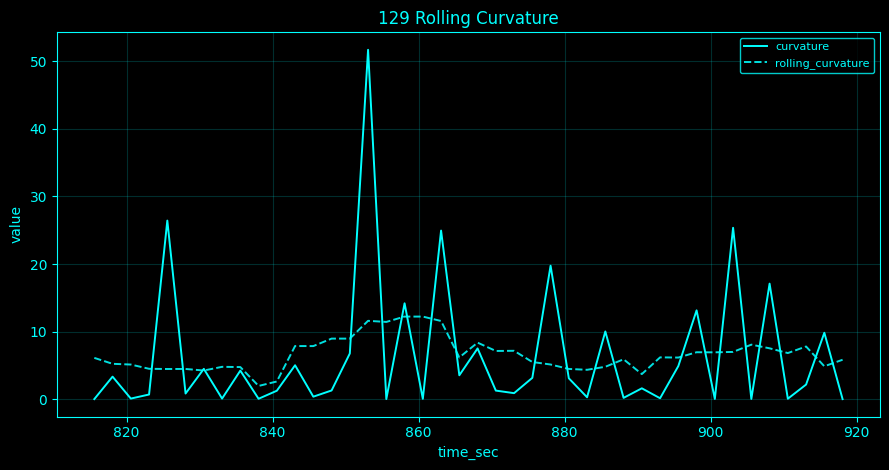

,time_sec,curvature,rolling_curvature
0,815.571,0.016823,6.112598
1,818.071,3.335798,5.233505
2,820.571,0.090693,5.127328
3,823.071,0.693139,4.497755
4,825.571,26.426537,4.467735
5,828.071,0.838039,4.472907
6,830.571,4.490270,4.241203
7,833.071,0.090746,4.788903
8,835.571,4.227574,4.753367
9,838.071,0.063371,1.960345


In [133]:
rk=pd.Series(KAP).rolling(TR_CFG['roll'],center=True,min_periods=1).mean().to_numpy();trsave('129_rolling_curvature',pd.DataFrame({'time_sec':RT,'curvature':KAP,'rolling_curvature':rk}))

### Event-locked trajectory curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Event-locked trajectory curvature</h3><p>Without external event markers, internal high-amplitude-envelope peaks are used only as candidate data-driven events. Curvature is aligned to the nearest state time around those peaks; the cell does not relabel them as experimental stimulation events.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$\kappa_e(\Delta t)=\kappa(t_e+\Delta t).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 internal_event_time_sec  nearest_state_time_sec  curvature_at_event
                 919.786                 918.071            0.011192
                 920.319                 918.071            0.011192
                 918.586                 918.071            0.011192
                 818.663                 818.071            3.335798
                 913.636                 913.071            2.166075
                 815.079                 815.571            0.016823
                 917.769                 918.071            0.011192
                 920.836                 918.071            0.011192


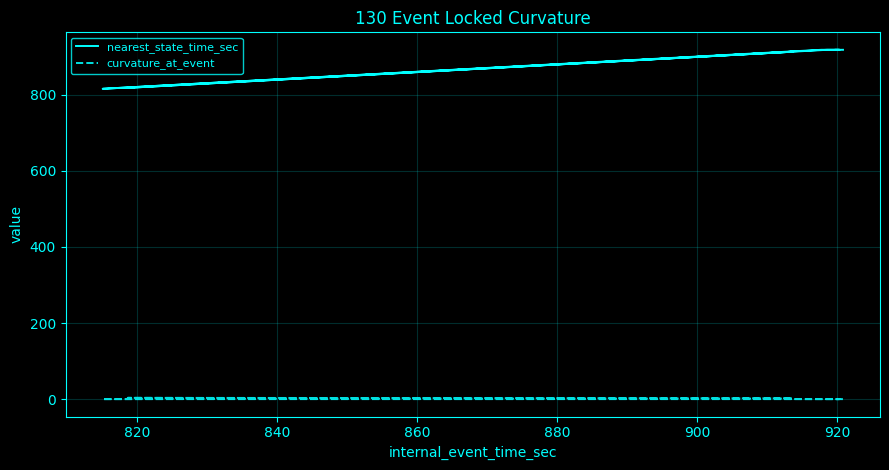

,internal_event_time_sec,nearest_state_time_sec,curvature_at_event
0,919.786,918.071,0.011192
1,920.319,918.071,0.011192
2,918.586,918.071,0.011192
3,818.663,818.071,3.335798
4,913.636,913.071,2.166075
5,815.079,815.571,0.016823
6,917.769,918.071,0.011192
7,920.836,918.071,0.011192


In [134]:
env=np.mean(np.abs(signal.hilbert(EEG_STD,axis=0)),axis=1);dist=max(1,int(.5*sampling_rate));pk,_=signal.find_peaks(env,distance=dist,prominence=np.std(env)*.5);pk=pk[np.argsort(env[pk])[-TR_CFG['events']:]] if len(pk) else np.array([],int);rows=[]
for p0 in pk:
 te=start_time+p0/sampling_rate;i=int(np.argmin(np.abs(RT-te)));rows.append((te,RT[i],KAP[i]))
trsave('130_event_locked_curvature',pd.DataFrame(rows,columns=['internal_event_time_sec','nearest_state_time_sec','curvature_at_event']))

### Band-limited trajectory curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Band-limited trajectory curvature</h3><p>For each canonical band, zero-phase Butterworth filtering is followed by the same window feature construction and three-dimensional PCA trajectory. The reported mean curvature therefore compares geometry after band isolation using the same definition.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$x_B=\mathcal F_Bx,\qquad \kappa_B=\|r_B'\times r_B''\|/\|r_B'\|^3.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 band  mean_curvature  median_curvature
delta       68.897712         26.923413
theta      611.599812        104.249786
alpha      446.019550        133.543234
 beta      715.452286        494.594398
gamma     1502.640590       1001.821347


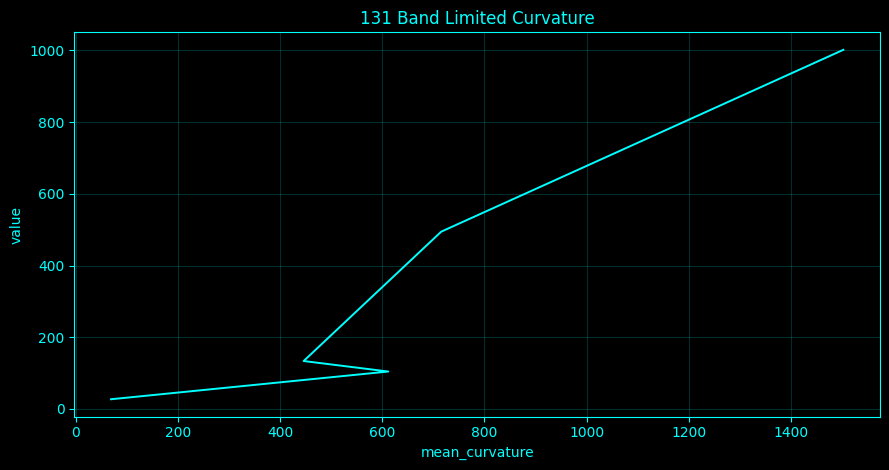

,band,mean_curvature,median_curvature
0,delta,68.897712,26.923413
1,theta,611.599812,104.249786
2,alpha,446.019550,133.543234
3,beta,715.452286,494.594398
4,gamma,1502.640590,1001.821347


In [135]:
rows=[]
for bn,lo,hi in BANDS:
 sos=signal.butter(4,[lo,hi],btype='bandpass',fs=sampling_rate,output='sos');xf=signal.sosfiltfilt(sos,EEG_STD,axis=0);F=np.stack([np.mean(xf[a:b],axis=0) for a,b in BOUNDS]);U,s,vt=np.linalg.svd(F-F.mean(0),full_matrices=False);Rb=U[:,:3]*s[:3];kb=frenet(Rb,STATE_TIMES)[4];rows.append((bn,np.nanmean(kb),np.nanmedian(kb)))
trsave('131_band_limited_curvature',pd.DataFrame(rows,columns=['band','mean_curvature','median_curvature']))

### Cross-channel curvature synchrony

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Cross-channel curvature synchrony</h3><p>Each channel has a delay-curve curvature sequence on a common normalized parameter. Pairwise Pearson correlation of those curvature sequences measures synchrony of geometric bending patterns, not signal-phase synchrony.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$S_{ij}=corr(\kappa_i(u),\kappa_j(u)).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


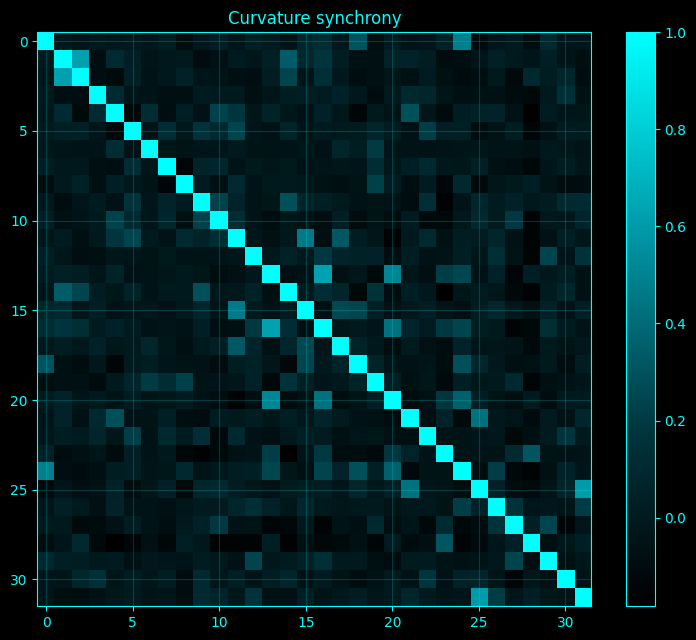

array([[ 1.        , -0.0046874 , -0.03623721, ...,  0.09420038,
        -0.03379546, -0.03343319],
       [-0.0046874 ,  1.        ,  0.62565567, ...,  0.03498634,
        -0.03532614, -0.08455237],
       [-0.03623721,  0.62565567,  1.        , ...,  0.01967947,
         0.07658498, -0.08658235],
       ...,
       [ 0.09420038,  0.03498634,  0.01967947, ...,  1.        ,
        -0.06172584, -0.02234522],
       [-0.03379546, -0.03532614,  0.07658498, ..., -0.06172584,
         1.        , -0.04420037],
       [-0.03343319, -0.08455237, -0.08658235, ..., -0.02234522,
        -0.04420037,  1.        ]])

In [136]:
CK=np.nan_to_num(CH_K,nan=0,posinf=0,neginf=0);S=np.corrcoef(CK);emit_matrix('132_cross_channel_curvature_synchrony','Curvature synchrony',S,eeg_channel_names)

### Curvature covariance matrix

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature covariance matrix</h3><p>The covariance matrix across channel curvature sequences retains scale information that correlation removes.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$C_{ij}=cov(\kappa_i,\kappa_j).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance measures how two variables vary together around their means. Positive covariance means they tend to deviate in the same direction; negative covariance means opposite directions. Correlation rescales covariance by the variables' standard deviations, making it dimensionless and bounded between -1 and 1 for ordinary Pearson correlation. Both are linear summaries and can miss nonlinear dependence.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


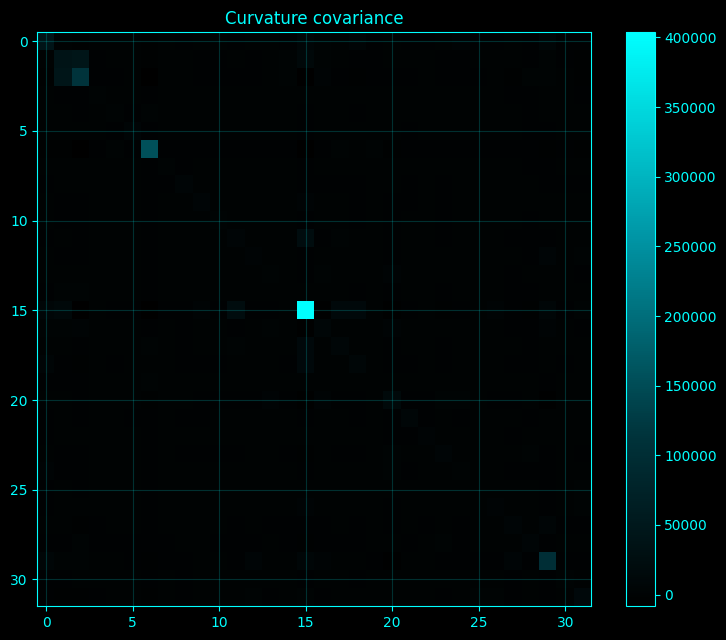

array([[ 41237.25082283,   -186.5894838 ,  -2500.50073867, ...,
          6169.11309002,   -320.61628596,   -802.56624026],
       [  -186.5894838 ,  38425.59479498,  41674.75080109, ...,
          2211.73979514,   -323.51086998,  -1959.26998549],
       [ -2500.50073867,  41674.75080109, 115466.14371337, ...,
          2156.58164294,   1215.77526988,  -3477.88236108],
       ...,
       [  6169.11309002,   2211.73979514,   2156.58164294, ...,
        104004.10636154,   -929.98219343,   -851.85990254],
       [  -320.61628596,   -323.51086998,   1215.77526988, ...,
          -929.98219343,   2182.55297591,   -244.0992894 ],
       [  -802.56624026,  -1959.26998549,  -3477.88236108, ...,
          -851.85990254,   -244.0992894 ,  13973.86115335]])

In [137]:
Ck=np.cov(CK);emit_matrix('133_curvature_covariance','Curvature covariance',Ck,eeg_channel_names)

### Curvature-based channel clustering

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature-based channel clustering</h3><p>Channels are clustered by Euclidean distance between z-scored curvature profiles using average linkage. This groups similar geometric bending trajectories.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$d_{ij}=\|z(\kappa_i)-z(\kappa_j)\|_2.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Standardization subtracts a reference mean and divides by a reference standard deviation. After this transformation, a value of zero corresponds to the reference mean and a value of +1 is one standard deviation above it. This is useful when channels or features have different numerical scales, but it also removes absolute amplitude information. The reference population used to compute the mean and standard deviation therefore matters for interpretation.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


channel  cluster
    Fp1        1
    Fpz        4
    Fp2        4
     F7        4
     F3        3
     Fz        4
     F4        2
     F8        4
    FC5        2
    FC1        4
    FC2        4
    FC6        4


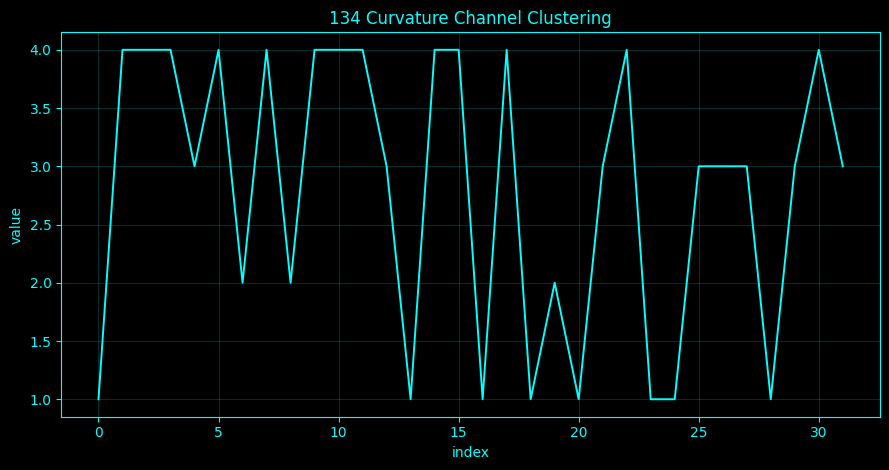

,channel,cluster
0,Fp1,1
1,Fpz,4
2,Fp2,4
3,F7,4
4,F3,3
5,Fz,4
6,F4,2
7,F8,4
8,FC5,2
9,FC1,4


In [138]:
KZ=(CK-CK.mean(1,keepdims=True))/(CK.std(1,keepdims=True)+EPS);D=cdist(KZ,KZ);lab=fcluster(linkage(_sqf(D,checks=False),method='average'),4,criterion='maxclust');trsave('134_curvature_channel_clustering',pd.DataFrame({'channel':eeg_channel_names,'cluster':lab}))

### Curvature burst detection

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature burst detection</h3><p>Curvature bursts are defined statistically as points above the median plus three median-absolute-deviation scales. This is a robust anomaly criterion, not a new differential-geometric invariant.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$threshold=median(\kappa)+3\,MAD(\kappa).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 time_sec  curvature  threshold  burst
  815.571   0.016823  10.088521  False
  818.071   3.335798  10.088521  False
  820.571   0.090693  10.088521  False
  823.071   0.693139  10.088521  False
  825.571  26.426537  10.088521   True
  828.071   0.838039  10.088521  False
  830.571   4.490270  10.088521  False
  833.071   0.090746  10.088521  False
  835.571   4.227574  10.088521  False
  838.071   0.063371  10.088521  False
  840.571   1.250458  10.088521  False
  843.071   5.019992  10.088521  False


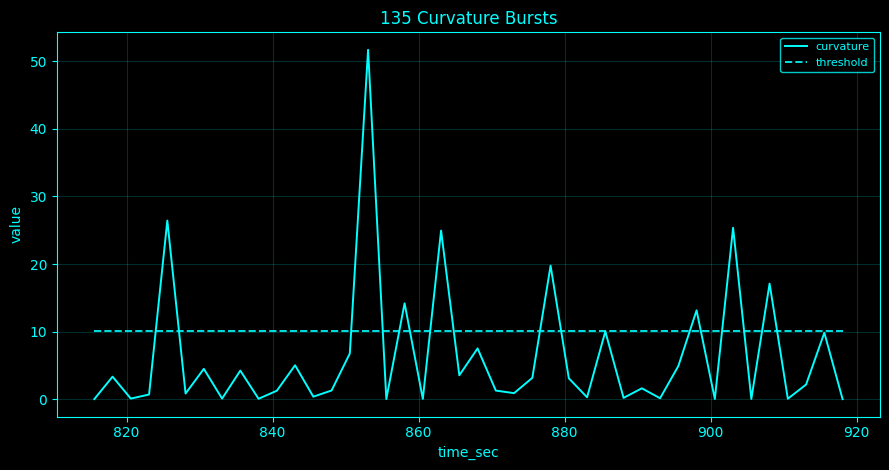

,time_sec,curvature,threshold,burst
0,815.571,0.016823,10.088521,False
1,818.071,3.335798,10.088521,False
2,820.571,0.090693,10.088521,False
3,823.071,0.693139,10.088521,False
4,825.571,26.426537,10.088521,True
5,828.071,0.838039,10.088521,False
6,830.571,4.490270,10.088521,False
7,833.071,0.090746,10.088521,False
8,835.571,4.227574,10.088521,False
9,838.071,0.063371,10.088521,False


In [139]:
med=np.nanmedian(KAP);mad=np.nanmedian(np.abs(KAP-med));thr=med+3*1.4826*mad;maskb=KAP>thr;trsave('135_curvature_bursts',pd.DataFrame({'time_sec':RT,'curvature':KAP,'threshold':thr,'burst':maskb}))

### Curvature hotspot duration analysis

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature hotspot duration analysis</h3><p>Contiguous above-threshold curvature samples are converted to durations using actual state times. This measures persistence of detected bending hotspots.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$duration=t_{end}-t_{start}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 start_sec  end_sec  duration_sec
   825.571  825.571           0.0
   853.071  853.071           0.0
   858.071  858.071           0.0
   863.071  863.071           0.0
   878.071  878.071           0.0
   898.071  898.071           0.0
   903.071  903.071           0.0
   908.071  908.071           0.0


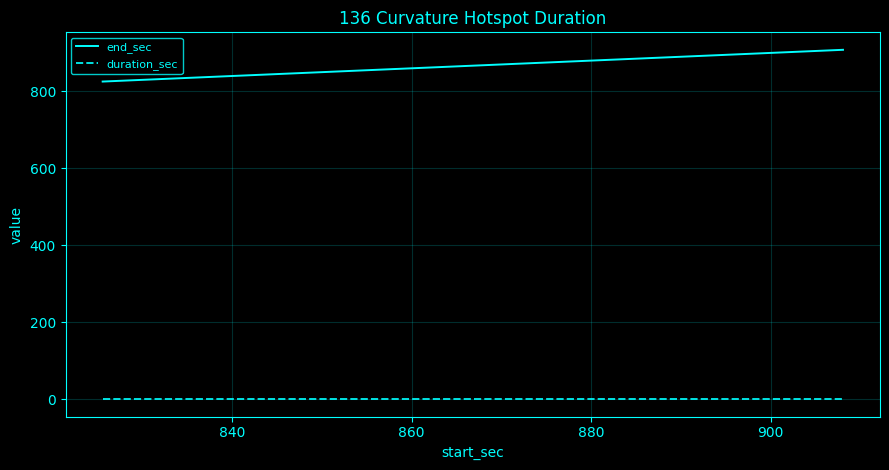

,start_sec,end_sec,duration_sec
0,825.571,825.571,0.0
1,853.071,853.071,0.0
2,858.071,858.071,0.0
3,863.071,863.071,0.0
4,878.071,878.071,0.0
5,898.071,898.071,0.0
6,903.071,903.071,0.0
7,908.071,908.071,0.0


In [140]:
runs=[];st=None
for i,b in enumerate(maskb):
 if b and st is None:st=i
 if st is not None and ((not b) or i==len(maskb)-1):
  en=i if b and i==len(maskb)-1 else i-1;runs.append((RT[st],RT[en],RT[en]-RT[st]));st=None
trsave('136_curvature_hotspot_duration',pd.DataFrame(runs,columns=['start_sec','end_sec','duration_sec']))

### Curvature persistence over time

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Curvature persistence over time</h3><p>Persistence is summarized by the survival curve of hotspot run durations: for each duration scale d, the fraction of runs lasting at least d is reported.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$S(d)=P(D\ge d).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 duration_threshold_sec  survival_fraction
                    0.0                1.0
                    0.0                1.0
                    0.0                1.0
                    0.0                1.0
                    0.0                1.0
                    0.0                1.0
                    0.0                1.0
                    0.0                1.0
                    0.0                1.0
                    0.0                1.0
                    0.0                1.0
                    0.0                1.0


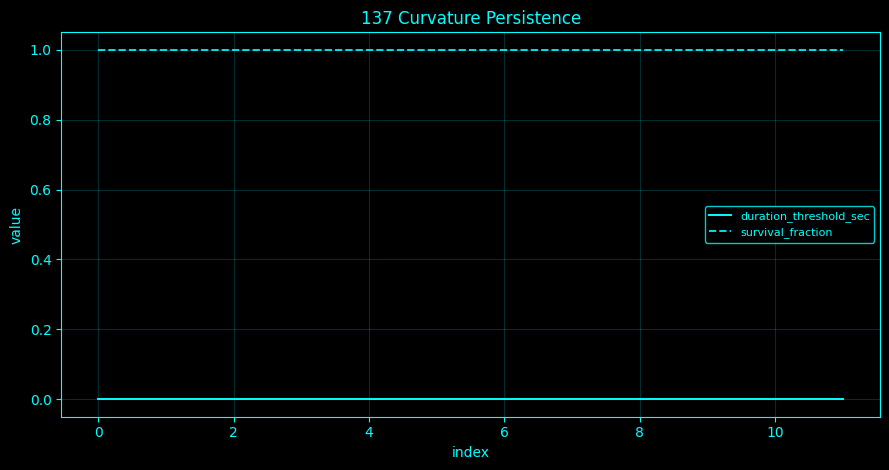

,duration_threshold_sec,survival_fraction
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
5,0.0,1.0
6,0.0,1.0
7,0.0,1.0
8,0.0,1.0
9,0.0,1.0


In [141]:
dur=np.array([r[2] for r in runs],float);grid=np.linspace(0,dur.max() if len(dur) else 0,12);surv=[np.mean(dur>=d) if len(dur) else 0 for d in grid];trsave('137_curvature_persistence',pd.DataFrame({'duration_threshold_sec':grid,'survival_fraction':surv}))

### Shape analysis of EEG trajectories

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shape analysis of EEG trajectories</h3><p>Per-channel delay trajectories are centered, arc-length resampled, and scaled to unit Frobenius norm. This removes translation and overall scale before shape comparisons.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$X\mapsto(X-\bar X)/\|X-\bar X\|_F.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


channel  centroid_norm  preshape_norm
    Fp1   4.270821e-18            1.0
    Fpz   4.539792e-18            1.0
    Fp2   1.672817e-17            1.0
     F7   8.931885e-18            1.0
     F3   6.348353e-18            1.0
     Fz   6.902069e-18            1.0
     F4   1.031233e-17            1.0
     F8   5.562623e-18            1.0
    FC5   4.821678e-18            1.0
    FC1   7.717083e-18            1.0
    FC2   3.069039e-18            1.0
    FC6   1.529339e-17            1.0


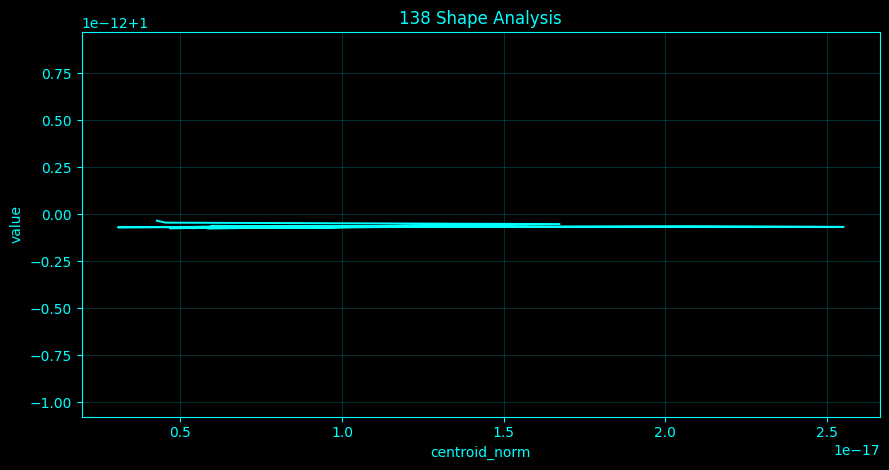

,channel,centroid_norm,preshape_norm
0,Fp1,4.270821e-18,1.0
1,Fpz,4.539792e-18,1.0
2,Fp2,1.672817e-17,1.0
3,F7,8.931885e-18,1.0
4,F3,6.348353e-18,1.0
5,Fz,6.902069e-18,1.0
6,F4,1.031233e-17,1.0
7,F8,5.562623e-18,1.0
8,FC5,4.821678e-18,1.0
9,FC1,7.717083e-18,1.0


In [142]:
trsave('138_shape_analysis',pd.DataFrame({'channel':eeg_channel_names,'centroid_norm':[np.linalg.norm(s.mean(0)) for s in CH_SH],'preshape_norm':[np.linalg.norm(s) for s in CH_SH]}))

### Procrustes shape distance

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Procrustes shape distance</h3><p>Full Procrustes alignment removes translation, scale and a proper orthogonal rotation. The residual Frobenius norm is reported as Procrustes shape distance.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$d_P(X,Y)=\min_{Q\in SO(3)}\|\tilde X-\tilde YQ\|_F.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


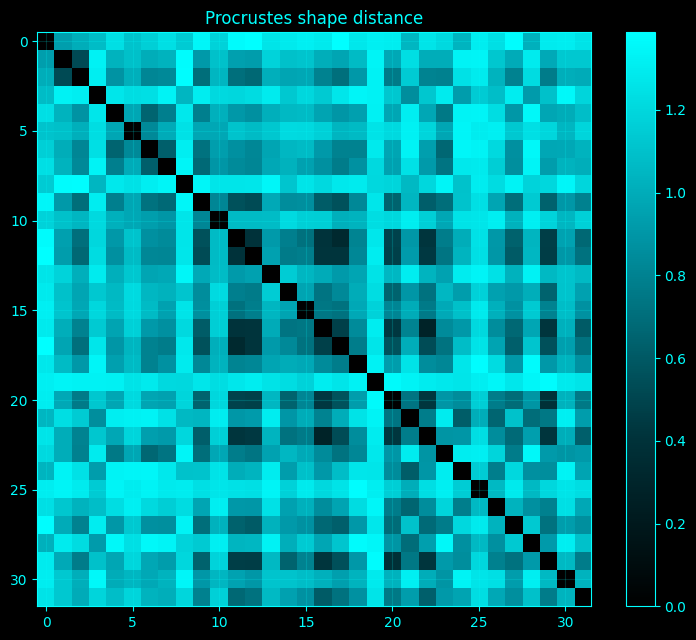

array([[0.        , 0.93671884, 1.00483634, ..., 1.29343075, 1.30388514,
        1.25307244],
       [0.93671884, 0.        , 0.52622798, ..., 0.98692212, 1.13168653,
        1.13108924],
       [1.00483634, 0.52622798, 0.        , ..., 0.77194819, 1.01334552,
        0.99512738],
       ...,
       [1.29343075, 0.98692212, 0.77194819, ..., 0.        , 1.05870206,
        0.7730924 ],
       [1.30388514, 1.13168653, 1.01334552, ..., 1.05870206, 0.        ,
        1.03115958],
       [1.25307244, 1.13108924, 0.99512738, ..., 0.7730924 , 1.03115958,
        0.        ]])

In [143]:
D=np.zeros((nC,nC))
for i in range(nC):
 for j in range(i+1,nC):D[i,j]=D[j,i]=proc_dist(CH_SH[i],CH_SH[j])
emit_matrix('139_procrustes_shape_distance','Procrustes shape distance',D,eeg_channel_names)

### Elastic shape analysis

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Elastic shape analysis</h3><p>Square-root velocity functions turn the first-order elastic metric into an L2 metric after alignment. The implementation uses common arc-length sampling and optimal rotation but does not optimize over nonlinear reparameterizations, which is stated explicitly.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$q(t)=r'(t)/\sqrt{\|r'(t)\|},\quad d_{SRV}=\|q_X-q_Y\|_{L^2}.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


channel  fixed_parameter_SRV_distance_to_Fp1
    Fp1                         4.504763e-17
    Fpz                         1.781202e-01
    Fp2                         1.553733e-01
     F7                         2.938481e-01
     F3                         3.021435e-01
     Fz                         2.793403e-01
     F4                         2.674446e-01
     F8                         2.801905e-01
    FC5                         2.923917e-01
    FC1                         2.668088e-01
    FC2                         3.023845e-01
    FC6                         2.745864e-01


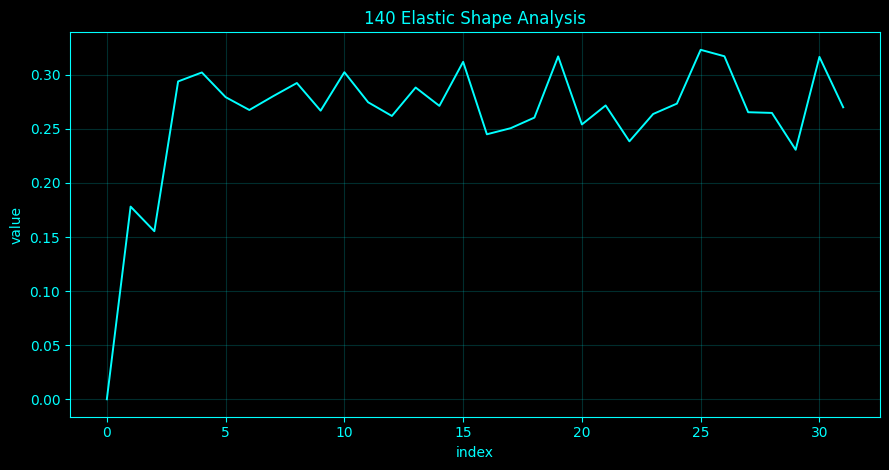

,channel,fixed_parameter_SRV_distance_to_Fp1
0,Fp1,4.504763e-17
1,Fpz,1.781202e-01
2,Fp2,1.553733e-01
3,F7,2.938481e-01
4,F3,3.021435e-01
5,Fz,2.793403e-01
6,F4,2.674446e-01
7,F8,2.801905e-01
8,FC5,2.923917e-01
9,FC1,2.668088e-01


In [144]:
rows=[]
ref=CH_SH[0]
for j in range(nC):
 Y,_=align_to(ref,CH_SH[j]);q1=srv(ref);q2=srv(Y);rows.append((eeg_channel_names[j],float(np.sqrt(np.mean(np.sum((q1-q2)**2,axis=1))))))
trsave('140_elastic_shape_analysis',pd.DataFrame(rows,columns=['channel','fixed_parameter_SRV_distance_to_Fp1']))

### Square-root velocity transform geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Square-root velocity transform geometry</h3><p>The SRV transform divides velocity by the square root of its speed. Its squared L2 norm equals curve length under the chosen normalized parameter up to discretization.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$q=r'/\sqrt{\|r'\|},\quad \int\|q\|^2dt=\int\|r'\|dt.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> An integral represents accumulation over a continuous variable; in sampled EEG code it is usually approximated by a numerical sum. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


channel  mean_squared_SRV_norm
    Fp1               0.042566
    Fpz               0.041004
    Fp2               0.030657
     F7               0.060120
     F3               0.053698
     Fz               0.057570
     F4               0.045197
     F8               0.050415
    FC5               0.068919
    FC1               0.040389
    FC2               0.067168
    FC6               0.028399


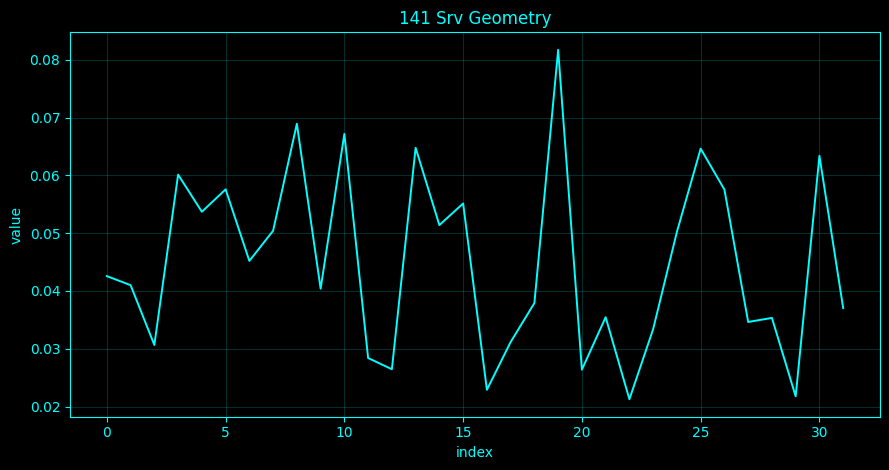

,channel,mean_squared_SRV_norm
0,Fp1,0.042566
1,Fpz,0.041004
2,Fp2,0.030657
3,F7,0.060120
4,F3,0.053698
5,Fz,0.057570
6,F4,0.045197
7,F8,0.050415
8,FC5,0.068919
9,FC1,0.040389


In [145]:
rows=[]
for j,C in enumerate(CH_SH):q=srv(C);rows.append((eeg_channel_names[j],np.mean(np.linalg.norm(q,axis=1)**2)))
trsave('141_srv_geometry',pd.DataFrame(rows,columns=['channel','mean_squared_SRV_norm']))

### Shape geodesics

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shape geodesics</h3><p>Kendall preshapes lie on a unit sphere after translation and scale removal. After optimal rotational alignment, the great-circle interpolation provides a geodesic in preshape space.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$X_t=\frac{\sin((1-t)\theta)}{\sin\theta}X+\frac{\sin(t\theta)}{\sin\theta}Y.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Greek phase symbols such as φ or θ represent angular position on a cycle. Because phase wraps around, differences are interpreted modulo one full cycle. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


   t  distance_from_start  expected
0.00             0.000002  0.000000
0.05             0.067710  0.067710
0.10             0.135420  0.135420
0.15             0.203130  0.203130
0.20             0.270840  0.270840
0.25             0.338551  0.338551
0.30             0.406261  0.406261
0.35             0.473971  0.473971
0.40             0.541681  0.541681
0.45             0.609391  0.609391
0.50             0.677101  0.677101
0.55             0.744811  0.744811


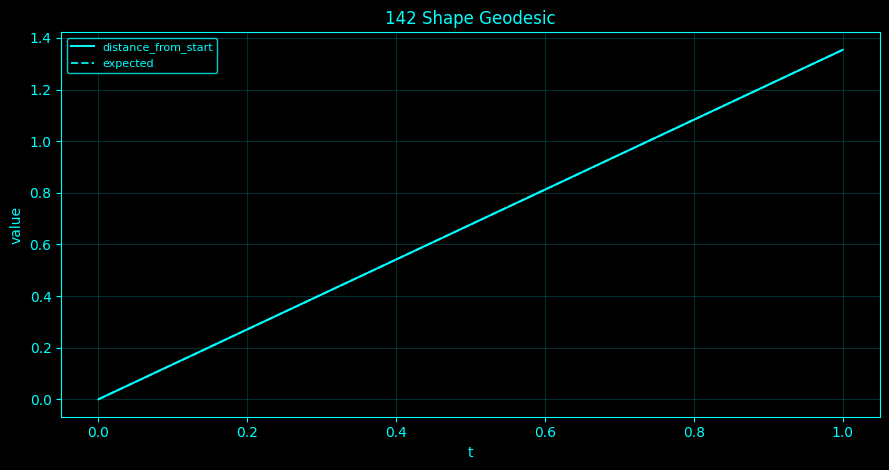

,t,distance_from_start,expected
0,0.00,0.000002,0.000000
1,0.05,0.067710,0.067710
2,0.10,0.135420,0.135420
3,0.15,0.203130,0.203130
4,0.20,0.270840,0.270840
5,0.25,0.338551,0.338551
6,0.30,0.406261,0.406261
7,0.35,0.473971,0.473971
8,0.40,0.541681,0.541681
9,0.45,0.609391,0.609391


In [146]:
X,Y=CH_SH[0],CH_SH[-1];theta=kendall_dist(X,Y);ts=np.linspace(0,1,21);rows=[]
for t in ts:Zs=slerp_shape(X,Y,t);rows.append((t,kendall_dist(X,Zs),t*theta))
trsave('142_shape_geodesic',pd.DataFrame(rows,columns=['t','distance_from_start','expected']))

### Shape barycenters

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shape barycenters</h3><p>An extrinsic preshape barycenter is obtained by iteratively aligning all shapes to the current mean, averaging, and renormalizing. It is a practical approximation to a Kendall Fréchet mean.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$\bar X\leftarrow normalize(N^{-1}\sum_i align_{\bar X}(X_i)).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Covariance matrices are not ordinary points in Euclidean space: valid covariance matrices are symmetric positive-definite matrices, which form a curved geometric space. Riemannian methods define distances and averages that remain consistent with this structure. This matters because simply subtracting or averaging matrix entries can distort relative changes, especially when eigenvalues differ strongly. A Riemannian or Fréchet mean is the point that minimizes the summed squared geometric distances to the observed covariance matrices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 point_index         x        y         z
           0  0.059114 0.065870 -0.090962
           1 -0.016219 0.130653 -0.025717
           2  0.004117 0.104375  0.006521
           3  0.020386 0.087155  0.010689
           4  0.010784 0.102204 -0.039606
           5 -0.004195 0.096023 -0.030022
           6  0.002066 0.083707 -0.013938
           7 -0.003319 0.115197 -0.044741
           8 -0.003898 0.117357 -0.079695
           9 -0.003178 0.112783 -0.080190
          10 -0.003499 0.119777 -0.062939
          11 -0.007389 0.101315 -0.057544


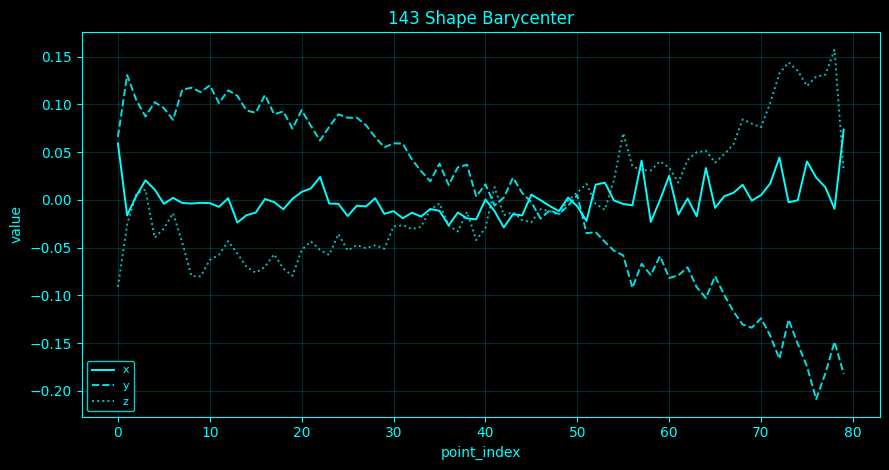

,point_index,x,y,z
0,0,0.059114,0.065870,-0.090962
1,1,-0.016219,0.130653,-0.025717
2,2,0.004117,0.104375,0.006521
3,3,0.020386,0.087155,0.010689
4,4,0.010784,0.102204,-0.039606
...,...,...,...,...
75,75,0.040207,-0.174258,0.119167
76,76,0.023303,-0.208625,0.129124
77,77,0.013232,-0.181820,0.130977
78,78,-0.009422,-0.148709,0.157049


In [147]:
M=CH_SH[0].copy()
for _ in range({'full':30,'balanced':20,'fast':12,'ultra':7}[FAST_OPTION]):
 AA=np.stack([align_to(M,X)[0] for X in CH_SH]);Mn=preshape(AA.mean(0));
 if np.linalg.norm(Mn-M)<1e-8:break
 M=Mn
trsave('143_shape_barycenter',pd.DataFrame({'point_index':np.arange(len(M)),'x':M[:,0],'y':M[:,1],'z':M[:,2]}))

### Shape principal components

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shape principal components</h3><p>After aligning channel preshapes to the barycenter, vectorized residuals are analyzed by ordinary tangent-like PCA. Variance fractions quantify dominant modes of channel-shape variation.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$X_i^{aligned}-\bar X\approx\sum_k a_{ik}e_k.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 component  explained_fraction
         1            0.253326
         2            0.149192
         3            0.064392
         4            0.058153
         5            0.053661
         6            0.044151
         7            0.042759
         8            0.033843
         9            0.033110
        10            0.031253


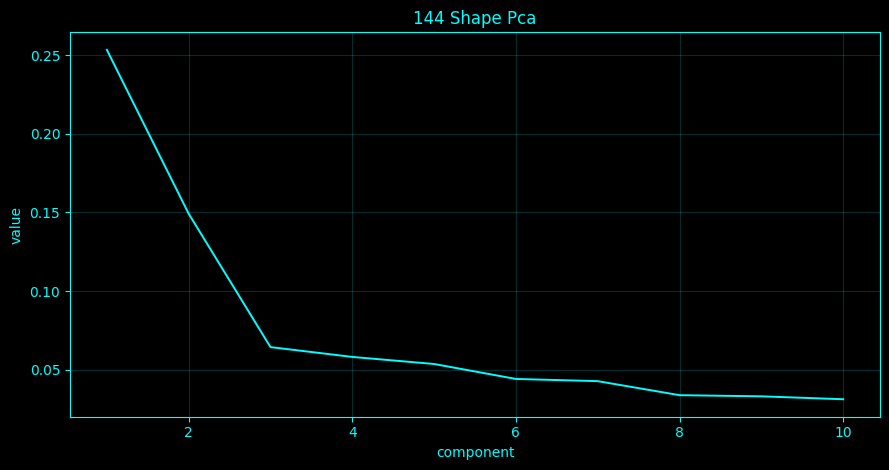

,component,explained_fraction
0,1,0.253326
1,2,0.149192
2,3,0.064392
3,4,0.058153
4,5,0.053661
5,6,0.044151
6,7,0.042759
7,8,0.033843
8,9,0.033110
9,10,0.031253


In [148]:
AA=np.stack([align_to(M,X)[0] for X in CH_SH]);F=AA.reshape(nC,-1);U,s,Vt=np.linalg.svd(F-F.mean(0),full_matrices=False);ev=s*s/(max(nC-1,1));trsave('144_shape_pca',pd.DataFrame({'component':np.arange(1,min(10,len(ev))+1),'explained_fraction':ev[:10]/(ev.sum()+EPS)}))

### Shape alignment across channels

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shape alignment across channels</h3><p>Optimal proper rotations align every channel shape to the common barycenter. The residual norm quantifies shape disagreement remaining after translation, scale and rotation removal.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$Q_i=argmin_{Q\in SO(3)}\|\bar X-X_iQ\|_F.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


channel  rotation_determinant  aligned_residual
    Fp1                   1.0          1.317748
    Fpz                   1.0          0.893056
    Fp2                   1.0          0.649676
     F7                   1.0          1.172847
     F3                   1.0          0.831107
     Fz                   1.0          1.030987
     F4                   1.0          0.779017
     F8                   1.0          0.752753
    FC5                   1.0          1.224101
    FC1                   1.0          0.439904
    FC2                   1.0          1.009655
    FC6                   1.0          0.358228


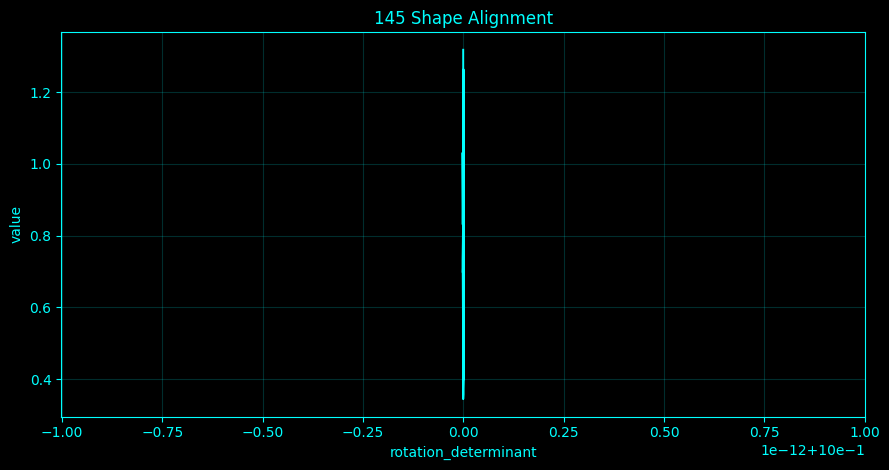

,channel,rotation_determinant,aligned_residual
0,Fp1,1.0,1.317748
1,Fpz,1.0,0.893056
2,Fp2,1.0,0.649676
3,F7,1.0,1.172847
4,F3,1.0,0.831107
5,Fz,1.0,1.030987
6,F4,1.0,0.779017
7,F8,1.0,0.752753
8,FC5,1.0,1.224101
9,FC1,1.0,0.439904


In [149]:
rows=[]
for j,X in enumerate(CH_SH):Xa,Q=align_to(M,X);rows.append((eeg_channel_names[j],np.linalg.det(Q),np.linalg.norm(M-Xa)))
trsave('145_shape_alignment',pd.DataFrame(rows,columns=['channel','rotation_determinant','aligned_residual']))

### Shape distance matrix

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shape distance matrix</h3><p>The matrix uses Kendall geodesic distance after optimal rotation. It is distinct from the Euclidean Procrustes residual even though both operate on the same preshapes.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$d_K(X,Y)=\arccos\langle X,YQ^*\rangle_F.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


/tmp/ipykernel_142206/2057821722.py:28: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.set_facecolor(BG); ax.grid(grid,alpha=.18,color=ACCENT); ax.tick_params(colors=ACCENT)


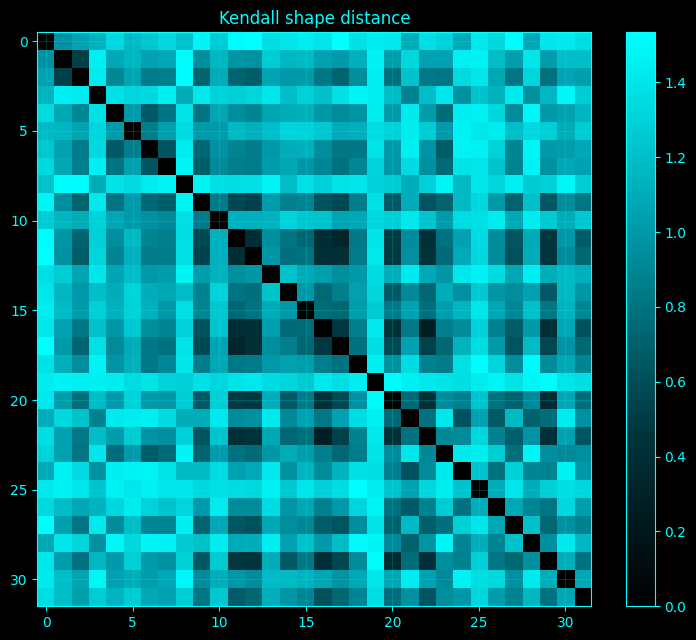

array([[0.        , 0.97486607, 1.0527866 , ..., 1.40654027, 1.42028695,
        1.35420204],
       [0.97486607, 0.        , 0.53249702, ..., 1.03212915, 1.20291128,
        1.20218695],
       [1.0527866 , 0.53249702, 0.        , ..., 0.79252701, 1.06264221,
        1.04157569],
       ...,
       [1.40654027, 1.03212915, 0.79252701, ..., 0.        , 1.11567091,
        0.7937675 ],
       [1.42028695, 1.20291128, 1.06264221, ..., 1.11567091, 0.        ,
        1.08336834],
       [1.35420204, 1.20218695, 1.04157569, ..., 0.7937675 , 1.08336834,
        0.        ]])

In [150]:
KD=np.zeros((nC,nC))
for i in range(nC):
 for j in range(i+1,nC):KD[i,j]=KD[j,i]=kendall_dist(CH_SH[i],CH_SH[j])
emit_matrix('146_shape_distance_matrix','Kendall shape distance',KD,eeg_channel_names)

### Shape clustering

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shape clustering</h3><p>Average-linkage clustering is performed on the intrinsic Kendall distance matrix, so clusters reflect delay-curve shape after removal of translation, scale and rotation.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$cluster=HC(d_K).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


channel  shape_cluster
    Fp1              2
    Fpz              1
    Fp2              1
     F7              2
     F3              1
     Fz              1
     F4              1
     F8              1
    FC5              3
    FC1              1
    FC2              1
    FC6              1


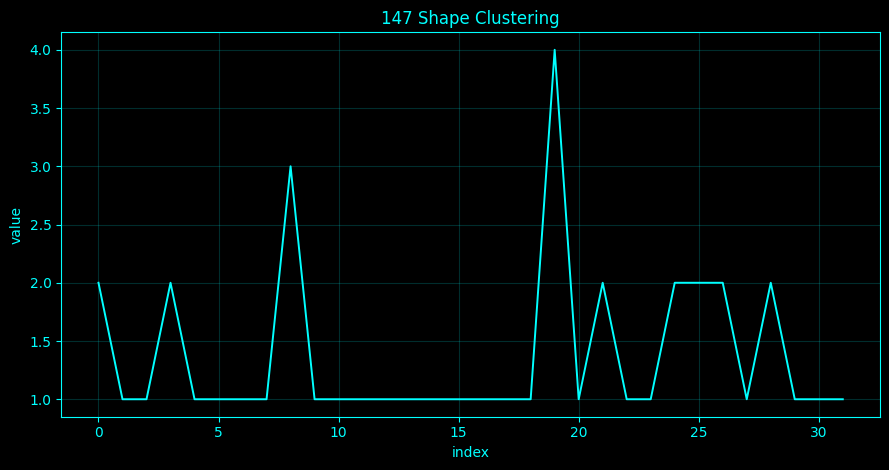

,channel,shape_cluster
0,Fp1,2
1,Fpz,1
2,Fp2,1
3,F7,2
4,F3,1
5,Fz,1
6,F4,1
7,F8,1
8,FC5,3
9,FC1,1


In [151]:
lab=fcluster(linkage(_sqf(KD,checks=False),method='average'),4,criterion='maxclust');trsave('147_shape_clustering',pd.DataFrame({'channel':eeg_channel_names,'shape_cluster':lab}))

### Shape asymmetry analysis

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shape asymmetry analysis</h3><p>Left-right homologous channel pairs are compared in Kendall shape space. This is geometric waveform-shape asymmetry rather than amplitude asymmetry.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$A_{LR}=d_K(X_L,X_R).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


left right  kendall_shape_distance
 Fp1   Fp2                1.052787
  F7    F8                1.454171
  F3    F4                0.665461
 FC5   FC6                1.368842
 FC1   FC2                0.848538
  T7    T8                0.951959
  C3    C4                0.749505
 CP5   CP6                1.414313
 CP1   CP2                0.754235
  P7    P8                0.790491
  P3    P4                0.806426
  O1    O2                0.793767


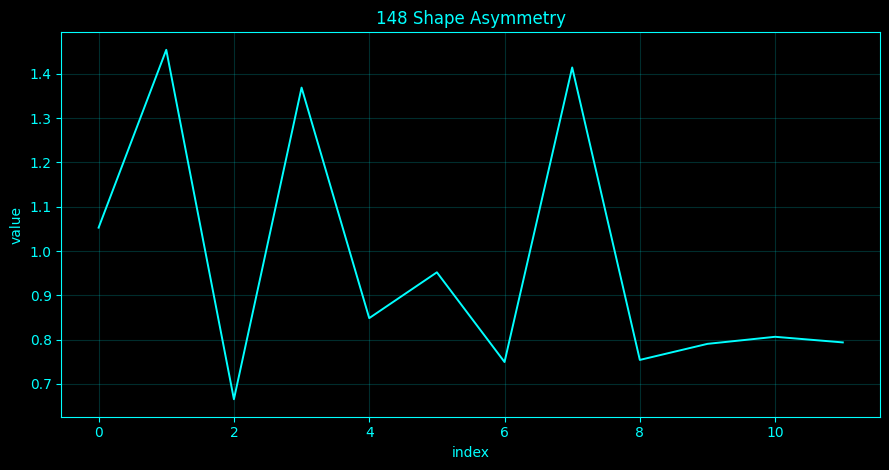

,left,right,kendall_shape_distance
0,Fp1,Fp2,1.052787
1,F7,F8,1.454171
2,F3,F4,0.665461
3,FC5,FC6,1.368842
4,FC1,FC2,0.848538
5,T7,T8,0.951959
6,C3,C4,0.749505
7,CP5,CP6,1.414313
8,CP1,CP2,0.754235
9,P7,P8,0.790491


In [152]:
pairs=[('Fp1','Fp2'),('F7','F8'),('F3','F4'),('FC5','FC6'),('FC1','FC2'),('T7','T8'),('C3','C4'),('CP5','CP6'),('CP1','CP2'),('P7','P8'),('P3','P4'),('O1','O2')];rows=[]
for a,b in pairs:rows.append((a,b,KD[CHANNEL_INDEX[a],CHANNEL_INDEX[b]]))
trsave('148_shape_asymmetry',pd.DataFrame(rows,columns=['left','right','kendall_shape_distance']))

### Event-locked shape deformation

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Event-locked shape deformation</h3><p>Internal envelope peaks define candidate events only. For each candidate, a short multichannel PCA trajectory around the event is compared by Procrustes distance with an equally long baseline trajectory preceding it.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$D_e=d_P(X_{pre},X_{event}).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


 internal_event_time_sec  procrustes_deformation_vs_pre
                 919.786                       0.985331
                 920.319                       0.985331
                 918.586                       0.985331
                 913.636                       1.107458
                 917.769                       0.985331
                 920.836                       0.985331


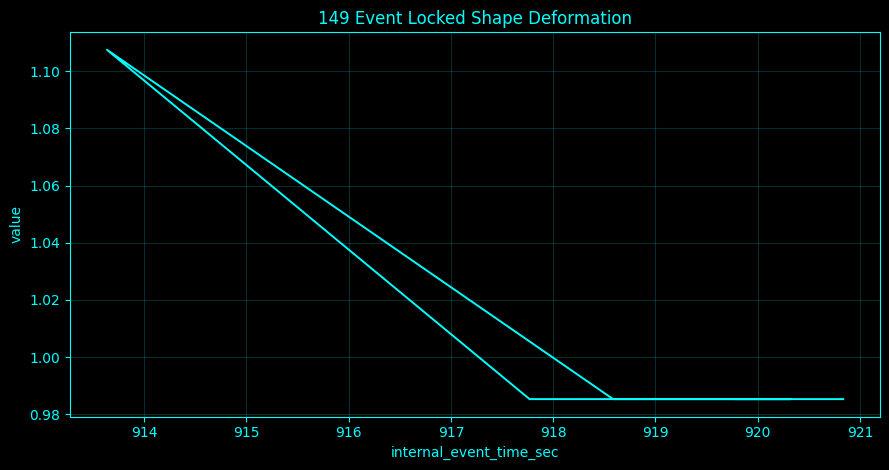

,internal_event_time_sec,procrustes_deformation_vs_pre
0,919.786,0.985331
1,920.319,0.985331
2,918.586,0.985331
3,913.636,1.107458
4,917.769,0.985331
5,920.836,0.985331


In [153]:
rows=[];half=max(4,min(10,len(R)//8))
for p0 in pk:
 te=start_time+p0/sampling_rate;i=int(np.argmin(np.abs(RT-te)));a=max(0,i-half);b=min(len(R),i+half+1);L=b-a
 if L>=6:
  pre_a=max(0,a-L);pre=R[pre_a:a]
  ev=R[a:b]
  if len(pre)>=4:rows.append((te,proc_dist(resample_curve(pre,40),resample_curve(ev,40))))
trsave('149_event_locked_shape_deformation',pd.DataFrame(rows,columns=['internal_event_time_sec','procrustes_deformation_vs_pre']))

### Band-limited shape deformation

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Band-limited shape deformation</h3><p>Each canonical band produces a three-dimensional PCA trajectory from window means. Shapes are resampled and compared with the broadband PCA trajectory using Procrustes distance.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$D_B=d_P(X_{broadband},X_B).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> Principal component analysis rotates the coordinate system so that the first axis captures the greatest sample variance, the second captures the greatest remaining variance subject to being orthogonal to the first, and so on. The directions are eigenvectors of the covariance matrix and their eigenvalues quantify variance along those directions. PCA is therefore a linear dimensionality-reduction method: it can summarize redundant channels or features, but it does not guarantee that the retained components correspond to distinct physiological sources.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 band  procrustes_distance_to_broadband
delta                          1.186166
theta                          1.203398
alpha                          1.210809
 beta                          1.258321
gamma                          1.250948


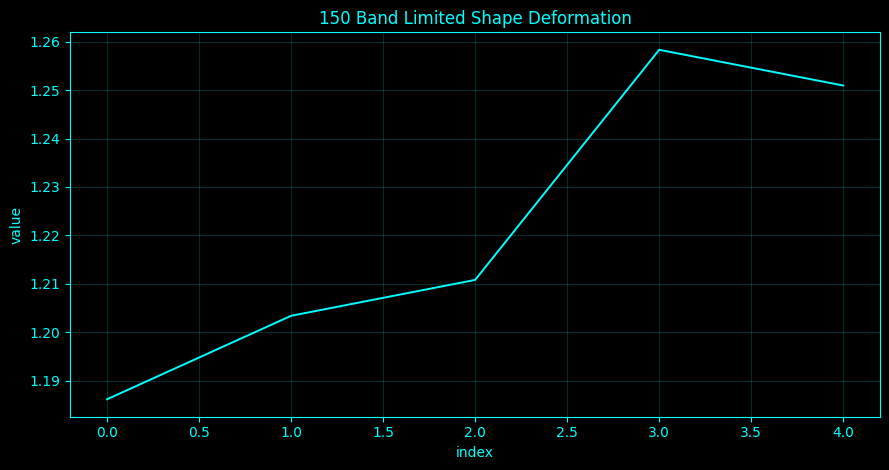

,band,procrustes_distance_to_broadband
0,delta,1.186166
1,theta,1.203398
2,alpha,1.210809
3,beta,1.258321
4,gamma,1.250948


In [154]:
ref=resample_curve(R0,TR_CFG['shape']);rows=[]
for bn,lo,hi in BANDS:
 sos=signal.butter(4,[lo,hi],btype='bandpass',fs=sampling_rate,output='sos');xf=signal.sosfiltfilt(sos,EEG_STD,axis=0);F=np.stack([np.mean(xf[a:b],axis=0) for a,b in BOUNDS]);U,s,vt=np.linalg.svd(F-F.mean(0),full_matrices=False);Rb=U[:,:3]*s[:3];rows.append((bn,proc_dist(ref,resample_curve(Rb,TR_CFG['shape']))))
trsave('150_band_limited_shape_deformation',pd.DataFrame(rows,columns=['band','procrustes_distance_to_broadband']))

### Trajectory loop-shape analysis

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Trajectory loop-shape analysis</h3><p>Loop tendency is quantified by closure ratio: endpoint separation divided by total arc length. A value near zero indicates near-closure; one indicates an almost straight open curve.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$c=\|r(T)-r(0)\|/L.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 closure_ratio  endpoint_distance  arc_length
      0.054804           4.175419   76.187771


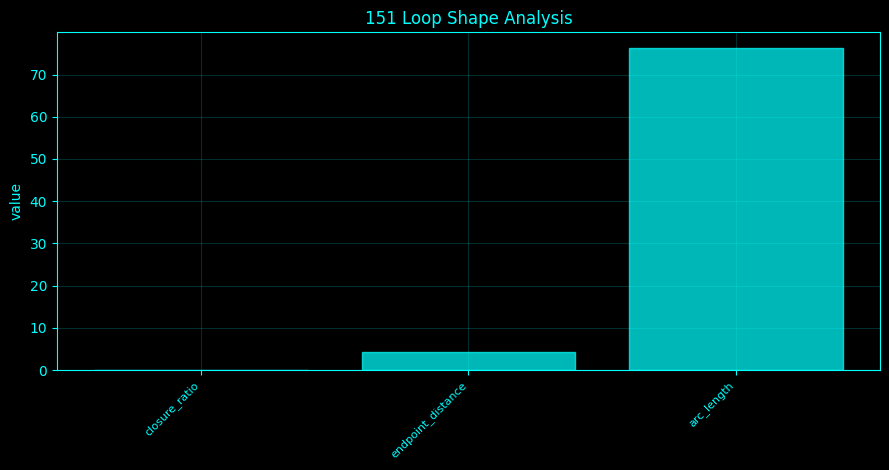

,closure_ratio,endpoint_distance,arc_length
0,0.054804,4.175419,76.187771


In [155]:
closure=np.linalg.norm(R[-1]-R[0])/(ARC[-1]+EPS);trsave('151_loop_shape_analysis',pd.DataFrame({'closure_ratio':[closure],'endpoint_distance':[np.linalg.norm(R[-1]-R[0])],'arc_length':[ARC[-1]]}))

### Closed-curve geometry of embeddings

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Closed-curve geometry of embeddings</h3><p>The sampled trajectory is explicitly closed by adding the segment from its endpoint back to its start. The cell reports the resulting closed length and projected signed areas in the three coordinate planes.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$L_{closed}=L+\|r_T-r_0\|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 closed_length  signed_area_xy  signed_area_yz  signed_area_zx
      80.36319        1.430191        0.014402        -1.95172


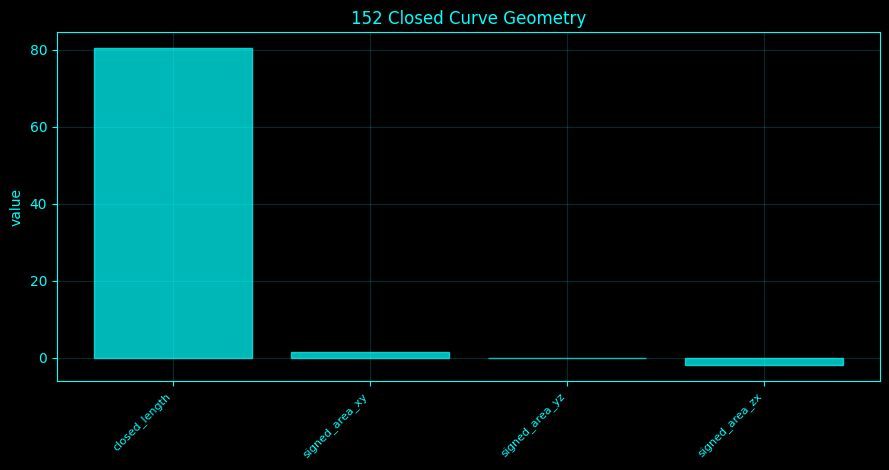

,closed_length,signed_area_xy,signed_area_yz,signed_area_zx
0,80.36319,1.430191,0.014402,-1.95172


In [156]:
Rc=np.vstack([R,R[0]]);areas=[]
for a,b in [(0,1),(1,2),(2,0)]:areas.append(.5*np.sum(Rc[:-1,a]*Rc[1:,b]-Rc[1:,a]*Rc[:-1,b]))
trsave('152_closed_curve_geometry',pd.DataFrame({'closed_length':[ARC[-1]+np.linalg.norm(R[-1]-R[0])],'signed_area_xy':[areas[0]],'signed_area_yz':[areas[1]],'signed_area_zx':[areas[2]]}))

### Open-curve geometry of embeddings

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Open-curve geometry of embeddings</h3><p>For the original open trajectory, chord length, arc length and tortuosity summarize deviation from a straight segment.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$tortuosity=L/\|r_T-r_0\|.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 arc_length  chord_length  tortuosity
  76.187771      4.175419   18.246738


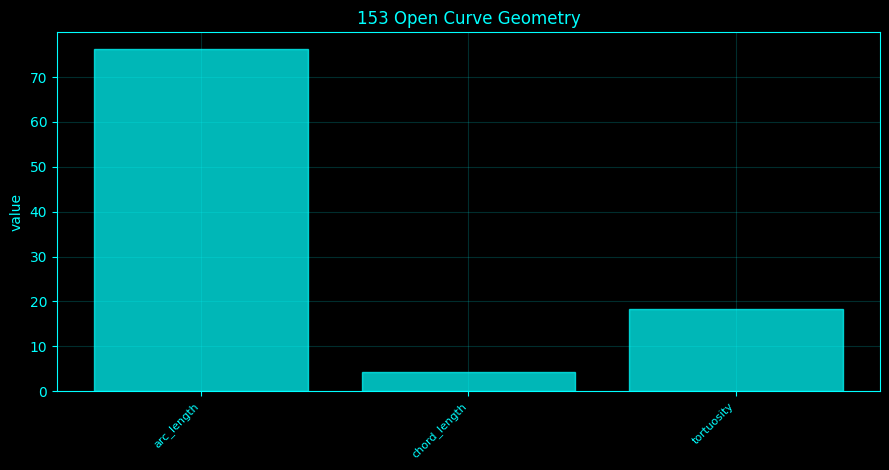

,arc_length,chord_length,tortuosity
0,76.187771,4.175419,18.246738


In [157]:
ch=np.linalg.norm(R[-1]-R[0]);trsave('153_open_curve_geometry',pd.DataFrame({'arc_length':[ARC[-1]],'chord_length':[ch],'tortuosity':[ARC[-1]/(ch+EPS)]}))

### Kendall shape-space analysis

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Kendall shape-space analysis</h3><p>Kendall preshape space removes translation and scale, then quotients out rotations. The implemented pairwise distance is the geodesic angle after optimal proper rotational alignment.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$d_K([X],[Y])=\arccos\max_{Q\in SO(3)}\langle X,YQ\rangle_F.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. Expectation or angle-bracket notation denotes an average with respect to a probability distribution or ensemble.</p><p><b>How to interpret this cell.</b> A useful practical check is dimensional consistency: ask what each input quantity represents, what units it has, and whether the final statistic is dimensional or dimensionless. This often makes the role of each term in the formula much easier to follow.</p></div>


 pairwise_kendall_distance
                  0.974866
                  1.052787
                  1.136463
                  1.338918
                  1.172336
                  1.241086
                  1.334460
                  1.219367
                  1.475317
                  1.258758
                  1.510727
                  1.533486


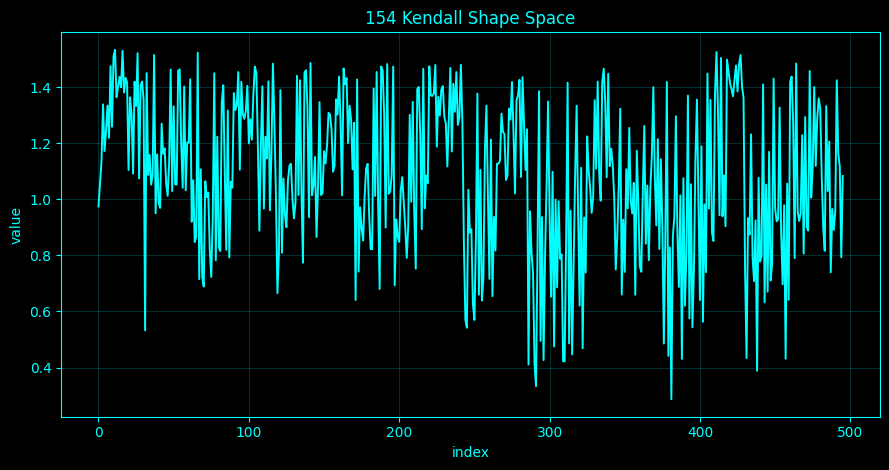

,pairwise_kendall_distance
0,0.974866
1,1.052787
2,1.136463
3,1.338918
4,1.172336
...,...
491,1.424687
492,1.163343
493,1.115671
494,0.793767


In [158]:
vals=KD[np.triu_indices(nC,1)];trsave('154_kendall_shape_space',pd.DataFrame({'pairwise_kendall_distance':vals}))

### Shape-space geodesic interpolation

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shape-space geodesic interpolation</h3><p>After optimal rotational alignment, great-circle interpolation in preshape space gives a constant-angular-speed path between two channel shapes. Endpoint and midpoint distance identities are reported as numerical checks.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only sample density, filter/resampling budgets, or clustering iterations; it does not change the defining geometry.</p></div>

$$d(X,X_t)=t\,d(X,Y).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


   t  distance_from_start  distance_to_end  endpoint_distance
0.00             0.000002         1.354202           1.354202
0.05             0.067710         1.286492           1.354202
0.10             0.135420         1.218782           1.354202
0.15             0.203130         1.151072           1.354202
0.20             0.270840         1.083362           1.354202
0.25             0.338551         1.015652           1.354202
0.30             0.406261         0.947941           1.354202
0.35             0.473971         0.880231           1.354202
0.40             0.541681         0.812521           1.354202
0.45             0.609391         0.744811           1.354202
0.50             0.677101         0.677101           1.354202
0.55             0.744811         0.609391           1.354202


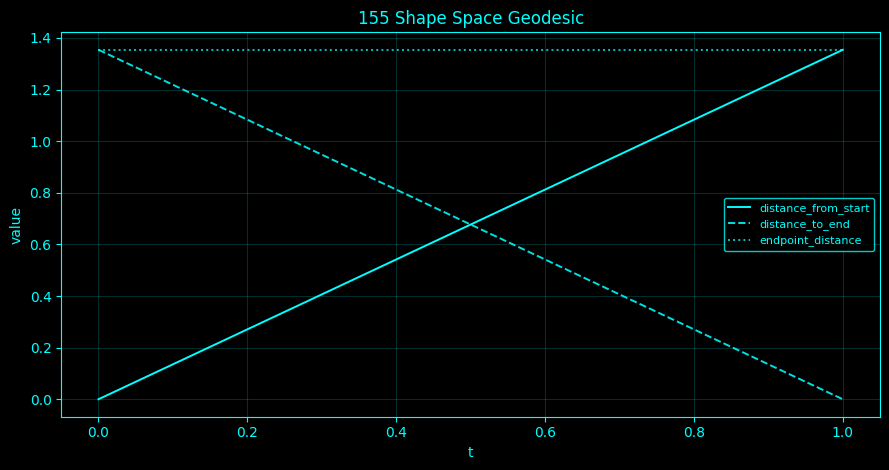

,t,distance_from_start,distance_to_end,endpoint_distance
0,0.00,0.000002,1.354202,1.354202
1,0.05,0.067710,1.286492,1.354202
2,0.10,0.135420,1.218782,1.354202
3,0.15,0.203130,1.151072,1.354202
4,0.20,0.270840,1.083362,1.354202
5,0.25,0.338551,1.015652,1.354202
6,0.30,0.406261,0.947941,1.354202
7,0.35,0.473971,0.880231,1.354202
8,0.40,0.541681,0.812521,1.354202
9,0.45,0.609391,0.744811,1.354202


In [159]:
X,Y=CH_SH[0],CH_SH[-1];th=kendall_dist(X,Y);ts=np.linspace(0,1,21);rows=[]
for t in ts:Zs=slerp_shape(X,Y,t);rows.append((t,kendall_dist(X,Zs),kendall_dist(Zs,Y),th))
trsave('155_shape_space_geodesic',pd.DataFrame(rows,columns=['t','distance_from_start','distance_to_end','endpoint_distance']))

# Geometry catalogue continuation — entries 156–200

Discrete curvature and graph geometry of EEG channel networks.

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values.</p></div>


<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Shared graph-curvature foundation</h3><p>Channels are graph vertices. A connected sparse functional graph is built from absolute Pearson correlation using a symmetric k-nearest-neighbour rule; edge lengths are inverse similarities and edge weights are conductances. Ollivier–Ricci curvature uses exact balanced optimal transport between lazy one-step neighborhood measures with graph shortest-path ground distance. Forman curvature uses the standard unweighted simple-graph formula. Bakry–Émery curvature is computed from the graph Markov generator by the Γ/Γ2 curvature-dimension inequality. Quantities with no unique canonical graph analogue are explicitly labelled proxies.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\kappa_{OR}(x,y)=1-\frac{W_1(m_x,m_y)}{d(x,y)},\qquad F(e)=4-\deg(x)-\deg(y).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> A Lyapunov exponent describes how quickly two initially nearby states separate or approach one another as the system evolves. A positive exponent means small differences grow on average, a negative exponent means they shrink, and a value near zero corresponds to a direction with little average exponential change. When several exponents are reported, they describe stretching and contraction along different directions of the reconstructed state space rather than separate EEG frequency bands. The numerical value also has units set by the time step used in the analysis, so comparisons are most meaningful when preprocessing and sampling are consistent.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance. A fraction should be read as a normalization or ratio: the numerator is the quantity of interest and the denominator sets the reference scale.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


Graph foundation: ultra edges 114 OR evaluated 70


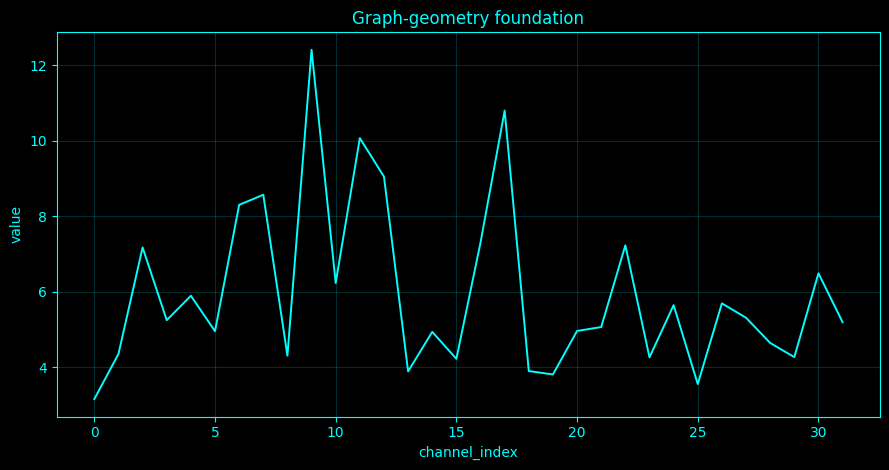

True

In [160]:
from scipy.linalg import expm,eigh
from scipy.sparse.csgraph import shortest_path as _gshort
from scipy.sparse import csr_matrix
GR_CFG={'full':dict(k=8,or_edges=180,time=60,flow=45,sparse_trials=10),'balanced':dict(k=7,or_edges=140,time=45,flow=30,sparse_trials=8),'fast':dict(k=6,or_edges=100,time=32,flow=20,sparse_trials=6),'ultra':dict(k=5,or_edges=70,time=20,flow=12,sparse_trials=4)}[FAST_OPTION]
GR_OUT=os.path.join(base_dir,'results','geometry_catalogue_graph');os.makedirs(GR_OUT,exist_ok=True)
def grdir(s):d=os.path.join(GR_OUT,s);os.makedirs(d,exist_ok=True);return d
def grsave(s,df):df.to_csv(os.path.join(grdir(s),f'{s}_{FAST_OPTION}.csv'),index=False);print(df.head(12).to_string(index=False));catalogue_autoplot_df(s,df);return df
def graph_from_similarity(S,k=None):
 S=np.asarray(S,float).copy();np.fill_diagonal(S,0);k=min(GR_CFG['k'] if k is None else k,len(S)-1);W=np.zeros_like(S)
 for i in range(len(S)):
  jj=np.argsort(S[i])[-k:];W[i,jj]=S[i,jj]
 W=np.maximum(W,W.T);W[W<0]=0;return W
def edge_list(W):return [(i,j,float(W[i,j])) for i in range(len(W)) for j in range(i+1,len(W)) if W[i,j]>0]
def lengths(W):
 L=np.full_like(W,np.inf,float);np.fill_diagonal(L,0);m=W>0;L[m]=1/(W[m]+1e-6);return L
def graph_dist(W):return _gshort(csr_matrix(lengths(W)),directed=False)
def lazy_measure(W,i,lazy=.5):
 n=len(W);p=np.zeros(n);p[i]=lazy;s=W[i].sum()
 if s>0:p+=(1-lazy)*W[i]/s
 else:p[i]=1
 return p
def _transport_cost(a,b,C):
 # support reduction keeps LP small
 ia=np.where(a>1e-14)[0];ib=np.where(b>1e-14)[0];aa=a[ia];bb=b[ib];CC=C[np.ix_(ia,ib)];P,c=emd_lp(aa,bb,CC);return c
def ollivier_edges(W,lazy=.5,max_edges=None):
 D=graph_dist(W);E=edge_list(W);E=sorted(E,key=lambda z:-z[2]);
 if max_edges is not None:E=E[:max_edges]
 rows=[]
 for i,j,w in E:
  d=D[i,j];a=lazy_measure(W,i,lazy);b=lazy_measure(W,j,lazy);ot=_transport_cost(a,b,D);rows.append((i,j,w,d,1-ot/(d+EPS)))
 return pd.DataFrame(rows,columns=['i','j','weight','distance','ollivier_ricci'])
def forman_edges(W):
 A=W>0;deg=A.sum(1);return pd.DataFrame([(i,j,4-int(deg[i])-int(deg[j])) for i,j,_ in edge_list(W)],columns=['i','j','forman_ricci'])
def markov_generator(W):
 d=W.sum(1);P=np.divide(W,d[:,None],out=np.zeros_like(W),where=d[:,None]>0);return P-np.eye(len(W))
def gamma_at(L,f,g,i):return .5*((L@(f*g))[i]-f[i]*(L@g)[i]-g[i]*(L@f)[i])
def gamma_vec(L,f,g):return np.array([gamma_at(L,f,g,i) for i in range(len(f))])
def gamma2_at(L,f,g,i):
 G=gamma_vec(L,f,g);return .5*((L@G)[i]-gamma_at(L,f,L@g,i)-gamma_at(L,g,L@f,i))
def bakry_node(W,i):
 L=markov_generator(W);n=len(W);ids=[j for j in range(n) if j!=i];m=len(ids);G=np.zeros((m,m));H=np.zeros((m,m));basis=[]
 for j in ids:
  f=np.zeros(n);f[j]=1;basis.append(f)
 for a in range(m):
  for b in range(a,m):
   G[a,b]=G[b,a]=gamma_at(L,basis[a],basis[b],i);H[a,b]=H[b,a]=gamma2_at(L,basis[a],basis[b],i)
 w,V=np.linalg.eigh((G+G.T)/2);keep=w>1e-9
 if not np.any(keep):return np.nan
 B=V[:,keep]/np.sqrt(w[keep])[None,:];M=B.T@((H+H.T)/2)@B;return float(np.linalg.eigvalsh((M+M.T)/2).min())
def menger(a,b,c):
 x=np.linalg.norm(a-b);y=np.linalg.norm(b-c);z=np.linalg.norm(c-a);s=.5*(x+y+z);area=np.sqrt(max(s*(s-x)*(s-y)*(s-z),0));return float(4*area/(x*y*z+EPS))
def haantjes(a,b,c):
 l=np.linalg.norm(a-b)+np.linalg.norm(b-c);d=np.linalg.norm(a-c);return float(np.sqrt(max(24*(l-d)/(d**3+EPS),0)))
# base graph from absolute correlation
COR=np.abs(np.corrcoef(EEG_STD,rowvar=False));W0=graph_from_similarity(COR);GD=graph_dist(W0);E0=edge_list(W0);OR0=ollivier_edges(W0,.5,GR_CFG['or_edges']);FR0=forman_edges(W0)
# coherence graph (8-30 Hz average coherence)
COH=np.eye(nC)
for i in range(nC):
 for j in range(i+1,nC):
  f,c=signal.coherence(EEG_STD[:,i],EEG_STD[:,j],fs=sampling_rate,nperseg=min(512,len(EEG_STD)));m=(f>=8)&(f<=30);COH[i,j]=COH[j,i]=float(np.mean(c[m]))
WCOH=graph_from_similarity(COH)
# PLV graph
PH=np.angle(signal.hilbert(EEG_STD,axis=0));PLV=np.abs(np.mean(np.exp(1j*(PH[:,:,None]-PH[:,None,:])),axis=0));WPLV=graph_from_similarity(PLV)
# linear-Gaussian one-lag transfer entropy approximation for directed network
step=max(1,len(EEG_STD)//6000);Xd=EEG_STD[::step];TE=np.zeros((nC,nC))
def _te_lin(x,y):
 yt=y[1:];yp=y[:-1];xp=x[:-1];A=np.c_[np.ones(len(yp)),yp];B=np.c_[A,xp];r1=yt-A@np.linalg.lstsq(A,yt,rcond=None)[0];r2=yt-B@np.linalg.lstsq(B,yt,rcond=None)[0];return max(0,.5*np.log((np.var(r1)+EPS)/(np.var(r2)+EPS)))
for i in range(nC):
 for j in range(nC):
  if i!=j:TE[i,j]=_te_lin(Xd[:,i],Xd[:,j])
print('Graph foundation:',FAST_OPTION,'edges',len(E0),'OR evaluated',len(OR0))
# Visible foundation diagnostic
catalogue_autoplot_df('graph_geometry_foundation',pd.DataFrame({'channel_index':np.arange(len(W0)),'weighted_degree':W0.sum(axis=1)}),title='Graph-geometry foundation')


### Discrete differential geometry

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Discrete differential geometry</h3><p>Discrete differential geometry transfers curvature and differential operators to meshes and graphs. Here the EEG channel network is the discrete object, with graph distances, Laplacian operators and edge curvatures computed from the same sparse functional graph.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$L=D-W,\qquad d_G(i,j)=\min_{path}\sum_{e\in path}\ell_e.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> The summation symbol means to add the indicated quantity over the stated index range; dividing such a sum by the number of terms produces an average. Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> For EEG, differences between channels should be interpreted as differences in the analyzed signal representation, not automatically as differences in underlying neural sources, because referencing, volume conduction, noise, and preprocessing can influence channel-level values. Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 nodes  edges  graph_diameter
    32    114         5.46426


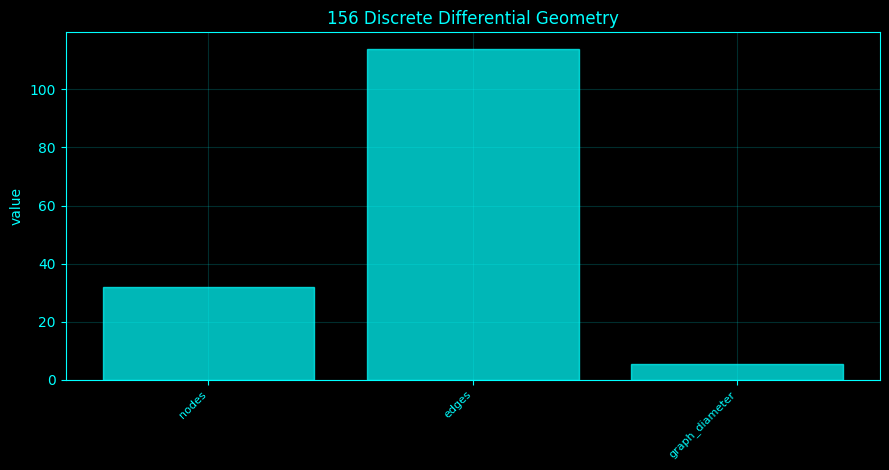

,nodes,edges,graph_diameter
0,32,114,5.46426


In [161]:
grsave('156_discrete_differential_geometry',pd.DataFrame({'nodes':[nC],'edges':[len(E0)],'graph_diameter':[np.max(GD[np.isfinite(GD)])]}))

### Discrete curvature on point clouds

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Discrete curvature on point clouds</h3><p>For triples of scalp locations connected through the functional graph, Menger curvature measures the reciprocal circumradius of the Euclidean triangle. This is an exact three-point curvature, not a graph-Ricci quantity.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\kappa_M=4A/(abc)=1/R_{circ}. $$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


  a vertex   c  menger_curvature
 F7    Fp1  Fz          2.259631
 Fz    Fp1  F4          1.583173
 F4    Fp1 FC5          1.677493
Fp2    Fpz FC1          2.237200
FC1    Fpz FC6          1.914526
FC6    Fpz  M1          1.174118
Fpz    Fp2 FC1          2.237200
FC1    Fp2 FC6          2.007581
FC6    Fp2  M1          1.165908
Fp1     F7 FC5          2.656798
FC5     F7 CP2          0.486464
CP2     F7  P3          1.450518


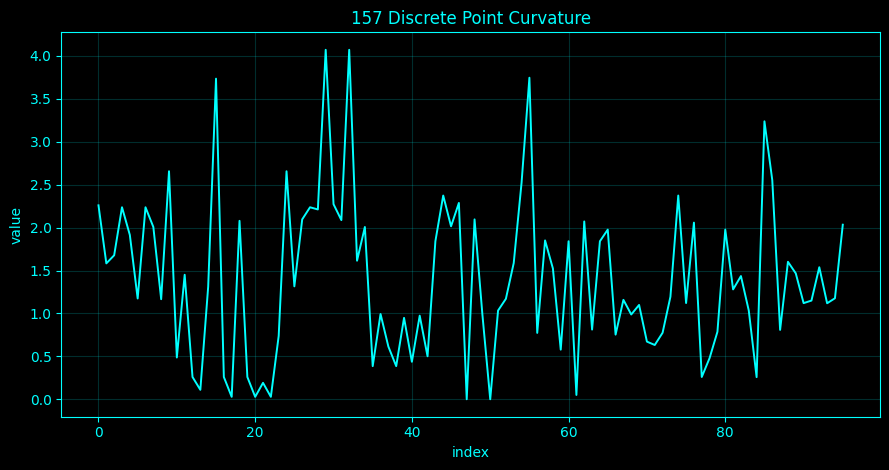

,a,vertex,c,menger_curvature
0,F7,Fp1,Fz,2.259631
1,Fz,Fp1,F4,1.583173
2,F4,Fp1,FC5,1.677493
3,Fp2,Fpz,FC1,2.237200
4,FC1,Fpz,FC6,1.914526
...,...,...,...,...
91,F8,Oz,FC1,1.149795
92,FC1,Oz,FC2,1.538462
93,FC6,O2,M1,1.118375
94,M1,O2,Cz,1.176805


In [162]:
rows=[]
for j in range(nC):
 nb=np.where(W0[j]>0)[0]
 for a in range(min(len(nb)-1,3)):
  if a+1<len(nb):rows.append((eeg_channel_names[nb[a]],eeg_channel_names[j],eeg_channel_names[nb[a+1]],menger(SCALP[nb[a]],SCALP[j],SCALP[nb[a+1]])))
grsave('157_discrete_point_curvature',pd.DataFrame(rows,columns=['a','vertex','c','menger_curvature']))

### Discrete Ricci curvature on kNN graphs

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Discrete Ricci curvature on kNN graphs</h3><p>The sparse functional graph supports two standard discrete Ricci notions used below: Ollivier curvature from optimal transport of neighborhood measures and Forman curvature from local degree incidence.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\kappa_{OR}=1-W_1(m_x,m_y)/d(x,y),\quad F(e)=4-d_x-d_y.$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>


 i  j   weight  distance  ollivier_ricci  forman_ricci
16 22 0.988999  1.011122        0.307151           -12
11 17 0.976188  1.024392        0.464580           -19
11 16 0.976185  1.024395        0.283593           -15
11 12 0.969705  1.031241        0.477454           -17
20 29 0.967428  1.033667       -0.127926            -7
12 17 0.966370  1.034799        0.421293           -18
11 22 0.965021  1.036246        0.118669           -15
 9 11 0.959376  1.042343        0.087536           -21
 9 17 0.951216  1.051285        0.142613           -22
12 16 0.948700  1.054073        0.242537           -14
 9 12 0.942244  1.061295        0.095739           -20
 6  7 0.938059  1.066030        0.400566           -16


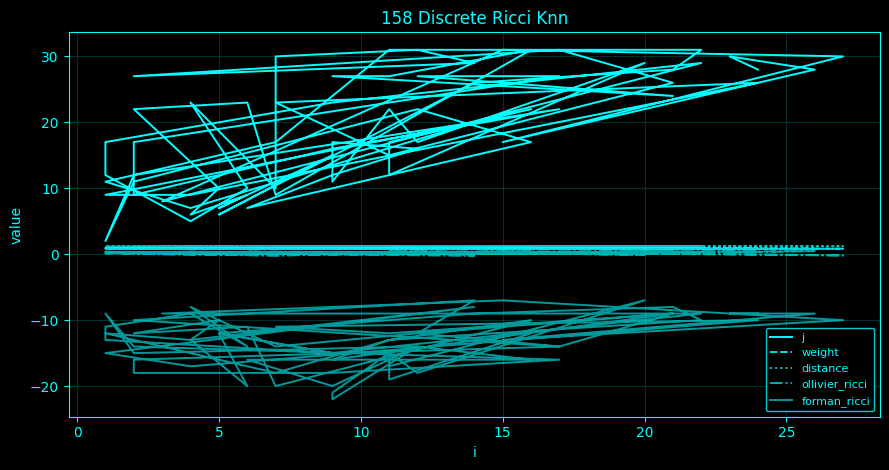

,i,j,weight,distance,ollivier_ricci,forman_ricci
0,16,22,0.988999,1.011122,0.307151,-12
1,11,17,0.976188,1.024392,0.464580,-19
2,11,16,0.976185,1.024395,0.283593,-15
3,11,12,0.969705,1.031241,0.477454,-17
4,20,29,0.967428,1.033667,-0.127926,-7
...,...,...,...,...,...,...
65,27,30,0.829405,1.205682,-0.190308,-10
66,15,17,0.826590,1.209788,0.250025,-13
67,26,28,0.826509,1.209907,0.470018,-9
68,23,30,0.826348,1.210143,0.263161,-9


In [163]:
z=OR0.merge(FR0,on=['i','j'],how='left');grsave('158_discrete_ricci_knn',z)

### Ollivier-Ricci curvature

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#181818;color:#D0D0D0;padding:18px;border-radius:8px;margin:10px;line-height:1.55;"><h3 style="color:#E8E8E8;margin-top:0;">Theory and method — Ollivier-Ricci curvature</h3><p>Lazy Ollivier–Ricci curvature compares one-step probability neighborhoods using the graph shortest-path metric. Positive values mean neighborhoods are closer than their base vertices; negative values signal transport expansion.</p><p><b>Runtime convention.</b> <code>full / balanced / fast / ultra</code> changes only graph density, transport solves, time windows, or iterative-flow steps; definitions are unchanged.</p></div>

$$\kappa(x,y)=1-W_1(m_x,m_y)/d(x,y).$$

<div style="font-size:13px;font-family:'Times New Roman',Times,serif;background-color:#202020;color:#D8D8D8;padding:14px 16px;border-radius:8px;margin:12px 10px;line-height:1.6;border-left:3px solid #777;"><p><b>Core idea.</b> The main reading strategy is to separate three things: the measured EEG samples, the mathematical representation constructed from those samples, and the final summary statistic. The statistic is not a direct physical quantity measured by the electrodes; it is the result of applying the stated assumptions and transformations to the recorded signal. When comparing channels or conditions, keep the preprocessing, sampling rate, window length, and estimator settings fixed so that numerical differences are interpretable rather than artifacts of different analysis choices.</p><p><b>How to read the mathematics.</b> Double vertical bars normally denote a vector or matrix norm, which is a measure of size or distance.</p><p><b>How to interpret this cell.</b> Because the calculation is performed on finite windows or segments, the reported value is a local summary of that selected data interval; a different interval can legitimately produce a different estimate if the EEG is nonstationary.</p></div>
